# ## 셀 1-1. 환경 설정

In [15]:
# 구글 drive 마운트하기
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'  # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name()  # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

# 음수 표현하는 코드 추가
plt.rcParams['axes.unicode_minus'] = False

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 17 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [ ]:
import ast
import gc
import os
import re
import shutil
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
import seaborn as sns
from IPython.display import Markdown, display


wd = "/content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data"
os.chdir(wd)
DATA_DIR = Path.cwd()

OUT_DIR = Path("/content/votes_hackle_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_fonts = ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]
selected_font = next((font for font in preferred_fonts if font in available_fonts), None)
if selected_font:
    plt.rcParams["font.family"] = selected_font
else:
    print("한글 폰트를 찾지 못했습니다. 그래프 한글이 깨지면 Colab에 NanumGothic을 설치한 뒤 다시 실행하세요.")
plt.rcParams["axes.unicode_minus"] = False

CHUNKSIZE = 1_000_000
TOP_N = 20

FILES = {
    "accounts_user": DATA_DIR / "accounts_user_master.csv",
    "attendance": DATA_DIR / "accounts_attendance_master.csv",
    "attendance_long": DATA_DIR / "accounts_attendance_long.csv",
    "payment": DATA_DIR / "accounts_paymenthistory_raw.csv",
    "question_record": DATA_DIR / "accounts_userquestionrecord_raw.csv",
    "friend_request": DATA_DIR / "accounts_friendrequest_raw.csv",
    "hackle_events": DATA_DIR / "hackle_events_raw.csv",
}

for name, path in FILES.items():
    print(f"{name:16s}", "OK" if path.exists() else "MISSING", path)

accounts_user    OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_user_master.csv
attendance       OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_attendance_master.csv
attendance_long  OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_attendance_long.csv
payment          OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_paymenthistory_raw.csv
question_record  OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_userquestionrecord_raw.csv
friend_request   OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_friendrequest_raw.csv
hackle_events    OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/hackle_events_raw.csv


In [ ]:
ls

accounts_attendance_long.csv         accounts_userquestionrecord_raw.csv
accounts_attendance_master.csv       accounts_userwithdraw_raw.csv
accounts_blockrecord_raw.csv         device_properties_raw.csv
accounts_failpaymenthistory_raw.csv  event_receipts_raw.csv
accounts_friendrequest_raw.csv       events_raw.csv
accounts_group_raw.csv               hackle_events_raw.csv
accounts_nearbyschool_raw.csv        hackle_properties_raw.csv
accounts_paymenthistory_raw.csv      main_repo/
accounts_pointhistory_raw.csv        polls_questionpiece_raw.csv
accounts_school_raw.csv              polls_question_raw.csv
accounts_timelinereport_raw.csv      polls_questionreport_raw.csv
accounts_user_contacts_long.csv      polls_questionset_long.csv
accounts_user_contacts_master.csv    polls_questionset_master.csv
accounts_user_long.csv               polls_usercandidate_raw.csv
accounts_user_master.csv             user_properties_raw.csv


In [ ]:
from google.colab import userdata
from pathlib import Path
import os

token = userdata.get("GITHUB_TOKEN")

Path("/root/.netrc").write_text(
    f"machine github.com\nlogin x-access-token\npassword {token}\n"
)
os.chmod("/root/.netrc", 0o600)
os.chdir("/content")

In [ ]:
!pwd
!rm -rf main_repo
!git clone https://github.com/codeit-DA12-final3/main_repo.git
%cd /content/main_repo
!git switch -c feature/suhyun-analysis


/content
Cloning into 'main_repo'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 86 (delta 8), reused 80 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 2.55 MiB | 30.32 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/main_repo
Switched to a new branch 'feature/suhyun-analysis'


In [ ]:
!git clone https://github.com/codeit-DA12-final3/main_repo.git

Cloning into 'main_repo'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 86 (delta 8), reused 80 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 2.55 MiB | 28.34 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [ ]:
%cd main_repo

/content/main_repo/main_repo


In [ ]:
!git switch -c feature/suhyun-analysis

Switched to a new branch 'feature/suhyun-analysis'


In [ ]:
for p in TABLE_DIR.glob("*.csv"):
    p.unlink()

_TABLE_NO = 0

In [ ]:
for p in FIG_DIR.glob("*.png"):
    p.unlink()

_FIG_NO = 0

# ## 셀 1-2. 공통 함수

In [ ]:
def as_user_id(series):
    """숫자형 user id를 merge 가능한 문자열 id로 통일합니다."""
    return pd.to_numeric(series, errors="coerce").astype("Int64").astype("string")


def parse_date_list(value):
    """attendance_date_list 문자열을 날짜 리스트로 변환합니다."""
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
    except Exception:
        return []
    if not isinstance(parsed, list):
        return []
    return [pd.to_datetime(x, errors="coerce").date() for x in parsed if pd.notna(x)]


def longest_consecutive_streak(dates):
    """날짜 리스트에서 최장 연속 활동일 수를 계산합니다."""
    dates = sorted(pd.to_datetime(pd.Series(dates), errors="coerce").dropna().dt.date.unique())
    if not dates:
        return 0
    best = current = 1
    for prev, cur in zip(dates, dates[1:]):
        if (pd.Timestamp(cur) - pd.Timestamp(prev)).days == 1:
            current += 1
        else:
            best = max(best, current)
            current = 1
    return max(best, current)


def attendance_metrics_from_value(value):
    """attendance_date_list를 한 번만 파싱해서 날짜 리스트/활동일/최장 연속일을 같이 계산합니다."""
    dates = parse_date_list(value)
    unique_dates = sorted(set(dates))
    if not unique_dates:
        return [], 0, 0

    best = current = 1
    for prev, cur in zip(unique_dates, unique_dates[1:]):
        if (pd.Timestamp(cur) - pd.Timestamp(prev)).days == 1:
            current += 1
        else:
            best = max(best, current)
            current = 1
    return unique_dates, len(unique_dates), max(best, current)


def note(title, condition, meaning):
    NOTES_FOR_README.append(
        {
            "title": title,
            "condition": condition,
            "meaning": meaning,
        }
    )
    display(Markdown(f"### {title}\n- **조건**: {condition}\n- **의미**: {meaning}"))


_FIG_NO = 0
_TABLE_NO = 0
NOTES_FOR_README = []


def make_slug(value, fallback):
    value = str(value or fallback)
    value = re.sub(r"[^\w가-힣]+", "_", value, flags=re.UNICODE).strip("_")
    return value[:80] or fallback


def count_fmt(value, decimals=0):
    if pd.isna(value):
        return ""
    if abs(float(value)) >= 1000:
        return f"{value:,.{decimals}f}"
    return f"{value:.{decimals}f}"


def add_bar_labels(ax, decimals=0, fontsize=8, padding=3):
    """막대 위에 값을 직접 표시해 GitHub PNG에서도 수치가 보이게 합니다."""
    for container in ax.containers:
        labels = []
        for bar in container:
            height = bar.get_height()
            labels.append("" if pd.isna(height) else count_fmt(height, decimals))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=fontsize)


def format_count_axis(ax, axis="y"):
    formatter = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
    if axis in ["y", "both"]:
        ax.yaxis.set_major_formatter(formatter)
    if axis in ["x", "both"]:
        ax.xaxis.set_major_formatter(formatter)


def rotate_xticks(ax, degrees=25):
    for label in ax.get_xticklabels():
        label.set_rotation(degrees)
        label.set_ha("right")


def pad_y_axis(ax, factor=1.18):
    ymin, ymax = ax.get_ylim()
    if ymax > 0:
        ax.set_ylim(ymin, ymax * factor)


def save_mpl_fig(title, filename=None, fig=None):
    """matplotlib/seaborn 그래프를 Colab에 표시하면서 GitHub 공유용 PNG로 저장합니다."""
    global _FIG_NO
    _FIG_NO += 1
    slug = make_slug(filename or title, f"figure_{_FIG_NO:02d}")
    path = FIG_DIR / f"{_FIG_NO:02d}_{slug}.png"
    fig = fig or plt.gcf()
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print(f"saved figure: {path}")
    plt.show()
    plt.close(fig)
    return path


def show_table(df, title, n=20):
    """표는 화면에는 일부만 보여주고, GitHub 공유용 preview CSV도 저장합니다."""
    global _TABLE_NO
    _TABLE_NO += 1
    preview = df.head(n).copy()
    slug = make_slug(title, f"table_{_TABLE_NO:02d}")
    path = TABLE_DIR / f"{_TABLE_NO:02d}_{slug}.csv"
    preview.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved table preview: {path}")
    display(Markdown(f"#### {title}"))
    display(preview)


def save_csv(df, filename):
    path = OUT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved: {path}")
    return path


def compact_numeric_fill(df, exclude=("user_id",)):
    numeric_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]
    df[numeric_cols] = df[numeric_cols].fillna(0)
    return df


def add_ratio_pct(df, count_col):
    """요약표에 전체 대비 비율을 붙입니다."""
    df = df.copy()
    total = df[count_col].sum()
    df["ratio_pct"] = np.where(total > 0, (df[count_col] / total * 100).round(2), 0)
    return df


def distribution_summary(df, value_col, group_col=None):
    """개별 id 목록 대신 분포 요약값을 만듭니다."""
    work = df.copy()
    work[value_col] = pd.to_numeric(work[value_col], errors="coerce").fillna(0)
    agg = dict(
        count=(value_col, "count"),
        mean=(value_col, "mean"),
        median=(value_col, "median"),
        p75=(value_col, lambda s: s.quantile(0.75)),
        p90=(value_col, lambda s: s.quantile(0.90)),
        max=(value_col, "max"),
    )
    if group_col:
        return work.groupby(group_col, as_index=False).agg(**agg)
    return work.agg(**agg).T.reset_index(names="metric").rename(columns={0: "value"})


def bucket_summary(df, value_col, bins, labels, count_name="count"):
    """연속형 값을 구간으로 나누어 현황 비교용 요약표를 만듭니다."""
    work = df[[value_col]].copy()
    work[value_col] = pd.to_numeric(work[value_col], errors="coerce").fillna(0)
    work["bucket"] = pd.cut(work[value_col], bins=bins, labels=labels, include_lowest=True, right=True)
    out = work.groupby("bucket", observed=False, as_index=False).size().rename(columns={"size": count_name})
    return add_ratio_pct(out, count_name)

# ## 셀 1-3. votes: 출석/결제/user id 집계

In [ ]:
# accounts_user.id가 다른 votes 테이블의 user_id와 연결되는 기준 id입니다.
print("파일 크기 확인")
for name, path in FILES.items():
    size_mb = path.stat().st_size / 1024 / 1024 if path.exists() else np.nan
    print(f"{name:16s} {size_mb:,.1f} MB  {path.name}")

print("1/5 accounts_user id 읽는 중...")
all_users = pd.read_csv(FILES["accounts_user"], usecols=["id"], dtype={"id": "string"})
all_users = all_users.rename(columns={"id": "user_id"})
all_users["user_id"] = all_users["user_id"].str.strip()
all_users = all_users.dropna().drop_duplicates()
print("accounts_user unique:", all_users["user_id"].nunique())

# 출석 기반 재방문/누적 활동일 수 집계
print("2/5 accounts_attendance_long 읽는 중...")
attendance_long = pd.read_csv(
    FILES["attendance_long"],
    usecols=["user_id", "attendance_date_list"],
    dtype={"user_id": "string"},
    parse_dates=["attendance_date_list"],
)
attendance_long = attendance_long.rename(columns={"attendance_date_list": "activity_date"})
attendance_long["user_id"] = attendance_long["user_id"].str.strip()
attendance_long = attendance_long.dropna(subset=["user_id", "activity_date"]).drop_duplicates()

print("3/5 출석일/연속 출석일 집계 중...")
attendance_sorted = attendance_long.sort_values(["user_id", "activity_date"]).copy()
attendance_sorted["prev_date"] = attendance_sorted.groupby("user_id")["activity_date"].shift()
attendance_sorted["gap_days"] = (attendance_sorted["activity_date"] - attendance_sorted["prev_date"]).dt.days
attendance_sorted["prev_user_id"] = attendance_sorted["user_id"].shift()
attendance_sorted["streak_group"] = (
    (attendance_sorted["user_id"].ne(attendance_sorted["prev_user_id"])) |
    (attendance_sorted["gap_days"].ne(1))
).cumsum()
streak_len = (
    attendance_sorted.groupby(["user_id", "streak_group"], as_index=False)
    .agg(streak_len=("activity_date", "size"))
)
attendance_user_agg = (
    attendance_sorted.groupby("user_id", as_index=False)
    .agg(attendance_days=("activity_date", "nunique"))
    .merge(
        streak_len.groupby("user_id", as_index=False).agg(attendance_longest_streak=("streak_len", "max")),
        on="user_id",
        how="left",
    )
)
attendance_user_agg["attendance_revisit_flag"] = attendance_user_agg["attendance_days"] >= 2

attendance_long = attendance_long.merge(
    attendance_user_agg[["user_id", "attendance_revisit_flag"]],
    on="user_id",
    how="left",
)
attendance_long["revisit_group"] = np.where(attendance_long["attendance_revisit_flag"], "출석 2일 이상", "출석 0~1일")

del attendance_sorted, streak_len
gc.collect()

attendance_daily = (
    attendance_long.groupby(["activity_date", "revisit_group"], as_index=False)
    .agg(user_count=("user_id", "nunique"))
    .sort_values("activity_date")
)

save_csv(attendance_user_agg, "votes_attendance_user_agg.csv")
save_csv(attendance_daily, "votes_attendance_daily.csv")

# 결제 집계
print("4/5 accounts_paymenthistory 읽는 중...")
payment = pd.read_csv(
    FILES["payment"],
    usecols=["user_id", "productId", "created_at"],
    dtype={"user_id": "string", "productId": "string"},
    parse_dates=["created_at"],
)
payment["user_id"] = payment["user_id"].str.strip()
payment["payment_date"] = payment["created_at"].dt.floor("D")

payment_user_agg = (
    payment.groupby("user_id", as_index=False)
    .agg(
        payment_rows=("created_at", "size"),
        payment_distinct_at=("created_at", "nunique"),
        payment_active_days=("payment_date", "nunique"),
        payment_product_count=("productId", "nunique"),
    )
)

payment_daily = (
    payment.groupby("payment_date", as_index=False)
    .agg(payment_count=("created_at", "size"), paid_user_count=("user_id", "nunique"))
    .sort_values("payment_date")
)

product_user = (
    payment.groupby(["productId", "user_id"], as_index=False)
    .agg(product_user_payment_rows=("created_at", "size"), product_user_distinct_at=("created_at", "nunique"))
)
product_summary = (
    product_user.groupby("productId", as_index=False)
    .agg(
        distinct_users=("user_id", "nunique"),
        user_product_pairs=("user_id", "size"),
        repeat_user_product_pairs=("product_user_distinct_at", lambda s: int((s >= 2).sum())),
        total_payment_rows=("product_user_payment_rows", "sum"),
    )
    .sort_values("total_payment_rows", ascending=False)
)

print("5/5 저장/미리보기 출력 중...")
save_csv(payment_user_agg, "votes_payment_user_agg.csv")
save_csv(payment_daily, "votes_payment_daily.csv")
save_csv(product_summary, "votes_product_summary.csv")

show_table(attendance_user_agg, "출석 user_id 단위 집계")
show_table(payment_user_agg, "결제 user_id 단위 집계")

파일 크기 확인
accounts_user    354.1 MB  accounts_user_master.csv
attendance       39.8 MB  accounts_attendance_master.csv
attendance_long  54.1 MB  accounts_attendance_long.csv
payment          4.2 MB  accounts_paymenthistory_raw.csv
question_record  101.7 MB  accounts_userquestionrecord_raw.csv
friend_request   1,078.2 MB  accounts_friendrequest_raw.csv
hackle_events    1,804.8 MB  hackle_events_raw.csv
1/5 accounts_user id 읽는 중...
accounts_user unique: 677085
2/5 accounts_attendance_long 읽는 중...
3/5 출석일/연속 출석일 집계 중...
saved: /content/votes_hackle_outputs/votes_attendance_user_agg.csv
saved: /content/votes_hackle_outputs/votes_attendance_daily.csv
4/5 accounts_paymenthistory 읽는 중...
5/5 저장/미리보기 출력 중...
saved: /content/votes_hackle_outputs/votes_payment_user_agg.csv
saved: /content/votes_hackle_outputs/votes_payment_daily.csv
saved: /content/votes_hackle_outputs/votes_product_summary.csv
saved table preview: /content/votes_hackle_outputs/tables/01_출석_user_id_단위_집계.csv


#### 출석 user_id 단위 집계

,user_id,attendance_days,attendance_longest_streak,attendance_revisit_flag
0,1000000,1,1,False
1,1000005,3,2,True
2,1000006,6,3,True
3,1000008,1,1,False
4,1000011,1,1,False
5,1000014,1,1,False
6,1000015,1,1,False
7,1000020,8,4,True
8,1000022,5,2,True
9,1000025,1,1,False


saved table preview: /content/votes_hackle_outputs/tables/02_결제_user_id_단위_집계.csv


#### 결제 user_id 단위 집계

,user_id,payment_rows,payment_distinct_at,payment_active_days,payment_product_count
0,1000001,1,1,1,1
1,1000014,4,4,2,2
2,1000017,1,1,1,1
3,1000022,1,1,1,1
4,1000023,1,1,1,1
5,1000040,1,1,1,1
6,1000042,1,1,1,1
7,1000054,1,1,1,1
8,1000061,3,3,2,2
9,1000083,1,1,1,1


# ## 셀 1-4. votes: 질문 기록 집계

In [ ]:
question = pd.read_csv(
    FILES["question_record"],
    usecols=["created_at", "user_id", "chosen_user_id", "has_read", "opened_times"],
    parse_dates=["created_at"],
)
question["user_id"] = as_user_id(question["user_id"])
question["chosen_user_id"] = as_user_id(question["chosen_user_id"])
question["question_date"] = question["created_at"].dt.floor("D")
question["has_read"] = pd.to_numeric(question["has_read"], errors="coerce").fillna(0).astype(int)
question["opened_times"] = pd.to_numeric(question["opened_times"], errors="coerce").fillna(0)

question_by_user = (
    question.groupby("user_id", as_index=False)
    .agg(
        question_user_record_count=("created_at", "size"),
        question_user_active_days=("question_date", "nunique"),
        question_user_has_read_sum=("has_read", "sum"),
        question_user_opened_times_sum=("opened_times", "sum"),
        question_user_opened_times_mean=("opened_times", "mean"),
    )
)

question_chosen_source = question[
    ["chosen_user_id", "created_at", "question_date", "has_read", "opened_times"]
].rename(columns={"chosen_user_id": "user_id"})

question_by_chosen = (
    question_chosen_source.groupby("user_id", as_index=False)
    .agg(
        question_chosen_record_count=("created_at", "size"),
        question_chosen_active_days=("question_date", "nunique"),
        question_chosen_has_read_sum=("has_read", "sum"),
        question_chosen_opened_times_sum=("opened_times", "sum"),
        question_chosen_opened_times_mean=("opened_times", "mean"),
    )
)

question_user_agg = question_by_user.merge(question_by_chosen, on="user_id", how="outer").drop_duplicates()

question_daily = (
    question.groupby("question_date", as_index=False)
    .agg(
        question_record_count=("created_at", "size"),
        question_user_count=("user_id", "nunique"),
        question_chosen_user_count=("chosen_user_id", "nunique"),
        has_read_count=("has_read", "sum"),
        opened_times_sum=("opened_times", "sum"),
    )
    .sort_values("question_date")
)

save_csv(question_user_agg, "votes_question_user_agg.csv")
save_csv(question_daily, "votes_question_daily.csv")
show_table(question_user_agg, "질문 기록 user_id 단위 집계")

del question
gc.collect()

saved: /content/votes_hackle_outputs/votes_question_user_agg.csv
saved: /content/votes_hackle_outputs/votes_question_daily.csv
saved table preview: /content/votes_hackle_outputs/tables/03_질문_기록_user_id_단위_집계.csv


#### 질문 기록 user_id 단위 집계

,user_id,question_user_record_count,question_user_active_days,question_user_has_read_sum,question_user_opened_times_sum,question_user_opened_times_mean,question_chosen_record_count,question_chosen_active_days,question_chosen_has_read_sum,question_chosen_opened_times_sum,question_chosen_opened_times_mean
0,1000071,NaN,NaN,NaN,NaN,NaN,8.0,7.0,1.0,1.0,0.125000
1,1000076,NaN,NaN,NaN,NaN,NaN,14.0,7.0,0.0,0.0,0.000000
2,1000118,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.000000
3,1000149,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.000000
4,1000206,NaN,NaN,NaN,NaN,NaN,8.0,6.0,1.0,0.0,0.000000
5,1000283,NaN,NaN,NaN,NaN,NaN,23.0,10.0,0.0,0.0,0.000000
6,1000294,NaN,NaN,NaN,NaN,NaN,13.0,7.0,13.0,9.0,0.692308
7,1000357,NaN,NaN,NaN,NaN,NaN,5.0,2.0,0.0,0.0,0.000000
8,1000497,NaN,NaN,NaN,NaN,NaN,5.0,4.0,1.0,0.0,0.000000
9,1000585,NaN,NaN,NaN,NaN,NaN,23.0,8.0,2.0,0.0,0.000000


31

# ## 셀 1-5. votes: 친구 요청 집계

In [ ]:
friend_file_mb = FILES["friend_request"].stat().st_size / (1024**2)
print(f"friend_request 파일 크기: {friend_file_mb:,.1f} MB")

friend_sent_parts = []
friend_received_parts = []
friend_pair_parts = []
friend_daily_count_parts = []
friend_daily_sender_parts = []
friend_daily_receiver_parts = []

friend_usecols = ["created_at", "status", "receive_user_id", "send_user_id"]
total_friend_rows = 0

for i, chunk in enumerate(pd.read_csv(FILES["friend_request"], usecols=friend_usecols, chunksize=CHUNKSIZE), start=1):
    total_friend_rows += len(chunk)
    print(f"{i}번째 chunk 처리 중... rows={len(chunk):,}, 누적={total_friend_rows:,}")

    chunk["created_at"] = pd.to_datetime(chunk["created_at"], errors="coerce")
    chunk["status"] = chunk["status"].astype("string").str.strip()
    chunk["send_user_id"] = as_user_id(chunk["send_user_id"])
    chunk["receive_user_id"] = as_user_id(chunk["receive_user_id"])
    chunk = chunk.dropna(subset=["send_user_id", "receive_user_id"])
    chunk["friend_date"] = chunk["created_at"].dt.floor("D")
    chunk["accepted_flag"] = (chunk["status"] == "A").astype("int8")

    friend_sent_parts.append(
        chunk.groupby("send_user_id", as_index=False)
        .agg(
            friend_sent_rows=("receive_user_id", "size"),
            friend_sent_accepted=("accepted_flag", "sum"),
        )
        .rename(columns={"send_user_id": "user_id"})
    )

    friend_received_parts.append(
        chunk.groupby("receive_user_id", as_index=False)
        .agg(
            friend_received_rows=("send_user_id", "size"),
            friend_received_accepted=("accepted_flag", "sum"),
        )
        .rename(columns={"receive_user_id": "user_id"})
    )

    friend_pair_parts.append(chunk[["send_user_id", "receive_user_id"]].drop_duplicates())

    friend_daily_count_parts.append(
        chunk.groupby(["friend_date", "status"], as_index=False)
        .agg(friend_request_count=("send_user_id", "size"))
    )
    friend_daily_sender_parts.append(chunk[["friend_date", "status", "send_user_id"]].drop_duplicates())
    friend_daily_receiver_parts.append(chunk[["friend_date", "status", "receive_user_id"]].drop_duplicates())

    del chunk
    gc.collect()

print("chunk별 집계를 하나로 합치는 중...")

friend_sent = (
    pd.concat(friend_sent_parts, ignore_index=True)
    .groupby("user_id", as_index=False)
    .agg(
        friend_sent_rows=("friend_sent_rows", "sum"),
        friend_sent_accepted=("friend_sent_accepted", "sum"),
    )
)

friend_received = (
    pd.concat(friend_received_parts, ignore_index=True)
    .groupby("user_id", as_index=False)
    .agg(
        friend_received_rows=("friend_received_rows", "sum"),
        friend_received_accepted=("friend_received_accepted", "sum"),
    )
)

friend_pairs = pd.concat(friend_pair_parts, ignore_index=True).drop_duplicates()
friend_sent_unique = (
    friend_pairs.groupby("send_user_id", as_index=False)
    .size()
    .rename(columns={"send_user_id": "user_id", "size": "friend_sent_unique_receivers"})
)
friend_received_unique = (
    friend_pairs.groupby("receive_user_id", as_index=False)
    .size()
    .rename(columns={"receive_user_id": "user_id", "size": "friend_received_unique_senders"})
)

friend_sent = friend_sent.merge(friend_sent_unique, on="user_id", how="left")
friend_received = friend_received.merge(friend_received_unique, on="user_id", how="left")
friend_user_agg = friend_sent.merge(friend_received, on="user_id", how="outer").drop_duplicates()

friend_daily_counts = (
    pd.concat(friend_daily_count_parts, ignore_index=True)
    .groupby(["friend_date", "status"], as_index=False)
    .agg(friend_request_count=("friend_request_count", "sum"))
)
friend_daily_senders = pd.concat(friend_daily_sender_parts, ignore_index=True).drop_duplicates()
friend_daily_receivers = pd.concat(friend_daily_receiver_parts, ignore_index=True).drop_duplicates()

friend_daily_sender_counts = (
    friend_daily_senders.groupby(["friend_date", "status"], as_index=False)
    .size()
    .rename(columns={"size": "send_user_count"})
)
friend_daily_receiver_counts = (
    friend_daily_receivers.groupby(["friend_date", "status"], as_index=False)
    .size()
    .rename(columns={"size": "receive_user_count"})
)

friend_daily = (
    friend_daily_counts.merge(friend_daily_sender_counts, on=["friend_date", "status"], how="left")
    .merge(friend_daily_receiver_counts, on=["friend_date", "status"], how="left")
    .sort_values("friend_date")
)

save_csv(friend_user_agg, "votes_friend_user_agg.csv")
save_csv(friend_daily, "votes_friend_daily.csv")

friend_prep_summary = pd.DataFrame(
    {
        "metric": [
            "친구 요청 row 수",
            "요청을 보낸 유저 수",
            "요청을 받은 유저 수",
            "서로 다른 발신자-수신자 쌍",
            "수락된 요청 수",
        ],
        "value": [
            total_friend_rows,
            friend_sent["user_id"].nunique(),
            friend_received["user_id"].nunique(),
            len(friend_pairs),
            friend_user_agg["friend_sent_accepted"].fillna(0).sum(),
        ],
    }
)
show_table(friend_prep_summary, "셀 05 요약: 친구 요청 현황")

del (
    friend_sent_parts,
    friend_received_parts,
    friend_pair_parts,
    friend_daily_count_parts,
    friend_daily_sender_parts,
    friend_daily_receiver_parts,
    friend_pairs,
    friend_daily_senders,
    friend_daily_receivers,
)
gc.collect()


friend_request 파일 크기: 1,078.2 MB
1번째 chunk 처리 중... rows=1,000,000, 누적=1,000,000
2번째 chunk 처리 중... rows=1,000,000, 누적=2,000,000
3번째 chunk 처리 중... rows=1,000,000, 누적=3,000,000
4번째 chunk 처리 중... rows=1,000,000, 누적=4,000,000
5번째 chunk 처리 중... rows=1,000,000, 누적=5,000,000
6번째 chunk 처리 중... rows=1,000,000, 누적=6,000,000
7번째 chunk 처리 중... rows=1,000,000, 누적=7,000,000
8번째 chunk 처리 중... rows=1,000,000, 누적=8,000,000
9번째 chunk 처리 중... rows=1,000,000, 누적=9,000,000
10번째 chunk 처리 중... rows=1,000,000, 누적=10,000,000
11번째 chunk 처리 중... rows=1,000,000, 누적=11,000,000
12번째 chunk 처리 중... rows=1,000,000, 누적=12,000,000
13번째 chunk 처리 중... rows=1,000,000, 누적=13,000,000
14번째 chunk 처리 중... rows=1,000,000, 누적=14,000,000
15번째 chunk 처리 중... rows=1,000,000, 누적=15,000,000
16번째 chunk 처리 중... rows=1,000,000, 누적=16,000,000
17번째 chunk 처리 중... rows=1,000,000, 누적=17,000,000
18번째 chunk 처리 중... rows=147,175, 누적=17,147,175
chunk별 집계를 하나로 합치는 중...
saved: /content/votes_hackle_outputs/votes_friend_user_agg.csv
saved: /content/vo

#### 셀 05 요약: 친구 요청 현황

,metric,value
0,친구 요청 row 수,17147175.0
1,요청을 보낸 유저 수,649072.0
2,요청을 받은 유저 수,660841.0
3,서로 다른 발신자-수신자 쌍,17038234.0
4,수락된 요청 수,12878407.0


31

# ## 셀 1-6. votes: user_id 단위 집계 결과 merge

In [ ]:
agg_frames = [
    all_users,
    attendance_user_agg,
    payment_user_agg,
    question_user_agg,
    friend_user_agg,
]

votes_user_summary = reduce(lambda left, right: left.merge(right, on="user_id", how="outer"), agg_frames)
votes_user_summary = votes_user_summary.drop_duplicates()
votes_user_summary = compact_numeric_fill(votes_user_summary)

votes_user_summary_path = save_csv(votes_user_summary, "votes_user_summary.csv")

coverage = pd.DataFrame(
    {
        "table": [
            "accounts_user",
            "accounts_attendance",
            "accounts_paymenthistory",
            "accounts_userquestionrecord",
            "accounts_friendrequest",
            "merged_votes_user_summary",
        ],
        "unique_user_count": [
            all_users["user_id"].nunique(),
            attendance_user_agg["user_id"].nunique(),
            payment_user_agg["user_id"].nunique(),
            question_user_agg["user_id"].nunique(),
            friend_user_agg["user_id"].nunique(),
            votes_user_summary["user_id"].nunique(),
        ],
    }
)

votes_metric_summary = pd.DataFrame(
    {
        "metric": [
            "전체 accounts_user 수",
            "출석 기록 유저 수",
            "출석 2일 이상 유저 수",
            "결제 유저 수",
            "질문 기록 관련 유저 수",
            "친구 요청 관련 유저 수",
        ],
        "value": [
            all_users["user_id"].nunique(),
            attendance_user_agg["user_id"].nunique(),
            int((attendance_user_agg["attendance_days"] >= 2).sum()),
            payment_user_agg["user_id"].nunique(),
            question_user_agg["user_id"].nunique(),
            friend_user_agg["user_id"].nunique(),
        ],
    }
)

display(Markdown("## votes 기초 집계 완료"))
print("votes_user_summary.shape =", votes_user_summary.shape)
print("votes_user_summary_path =", votes_user_summary_path)
show_table(coverage, "테이블별 user_id 커버리지")
show_table(votes_metric_summary, "votes 주요 지표 요약")

saved: /content/votes_hackle_outputs/votes_user_summary.csv


## votes 기초 집계 완료

votes_user_summary.shape = (677085, 24)
votes_user_summary_path = /content/votes_hackle_outputs/votes_user_summary.csv
saved table preview: /content/votes_hackle_outputs/tables/05_테이블별_user_id_커버리지.csv


#### 테이블별 user_id 커버리지

,table,unique_user_count
0,accounts_user,677085
1,accounts_attendance,328692
2,accounts_paymenthistory,59192
3,accounts_userquestionrecord,15452
4,accounts_friendrequest,673705
5,merged_votes_user_summary,677085


saved table preview: /content/votes_hackle_outputs/tables/06_votes_주요_지표_요약.csv


#### votes 주요 지표 요약

,metric,value
0,전체 accounts_user 수,677085
1,출석 기록 유저 수,328692
2,출석 2일 이상 유저 수,249825
3,결제 유저 수,59192
4,질문 기록 관련 유저 수,15452
5,친구 요청 관련 유저 수,673705


# ## 셀 1-7. hackle: merge 없이 session_id 기준 집계

In [ ]:
NOTICE_EVENT_KEYS = [
    "click_appbar_alarm_center",
    "click_bottom_navigation_timeline",
    "click_notice",
    "click_notice_detail",
    "view_timeline_tap",
]

SHARE_EVENT_KEYS = [
    "click_invite_friend",
    "click_friend_invite",
    "click_question_share",
]

CORE_EVENT_KEYS = ["click_question_open"]
ATTENDANCE_EVENT_KEYS = ["click_attendance"]

SELECTED_EVENT_KEYS = sorted(set(NOTICE_EVENT_KEYS + SHARE_EVENT_KEYS + CORE_EVENT_KEYS + ATTENDANCE_EVENT_KEYS))

daily_parts = []
session_day_parts = []
event_session_date_parts = []
core_session_parts = []

usecols = ["event_id", "event_datetime", "event_key", "session_id", "votes_count"]

for i, chunk in enumerate(pd.read_csv(FILES["hackle_events"], usecols=usecols, chunksize=CHUNKSIZE)):
    chunk["event_datetime"] = pd.to_datetime(chunk["event_datetime"], errors="coerce")
    chunk = chunk.dropna(subset=["event_datetime", "session_id"])
    chunk["event_date"] = chunk["event_datetime"].dt.floor("D")
    chunk["votes_count"] = pd.to_numeric(chunk["votes_count"], errors="coerce")

    daily_base = (
        chunk.groupby("event_date", as_index=False)
        .agg(total_events=("event_id", "count"))
    )
    daily_pivot = (
        chunk[chunk["event_key"].isin(SELECTED_EVENT_KEYS)]
        .pivot_table(index="event_date", columns="event_key", values="event_id", aggfunc="count", fill_value=0)
        .reset_index()
    )
    daily_parts.append(daily_base.merge(daily_pivot, on="event_date", how="left"))

    session_day_parts.append(
        chunk.groupby(["session_id", "event_date"], as_index=False)
        .agg(
            total_event_count=("event_id", "count"),
            click_attendance_count=("event_key", lambda s: int((s == "click_attendance").sum())),
        )
    )

    selected = chunk[chunk["event_key"].isin(SELECTED_EVENT_KEYS)]
    if not selected.empty:
        event_session_date_parts.append(
            selected.groupby(["session_id", "event_key", "event_date"], as_index=False)
            .agg(event_count=("event_id", "count"))
        )

    core_session_parts.append(
        chunk.groupby("session_id", as_index=False)
        .agg(
            votes_count_max=("votes_count", "max"),
            click_question_open_count=("event_key", lambda s: int((s == "click_question_open").sum())),
        )
    )

    if (i + 1) % 5 == 0:
        print(f"processed chunks: {i + 1}")

session_day = (
    pd.concat(session_day_parts, ignore_index=True)
    .groupby(["session_id", "event_date"], as_index=False)
    .agg(total_event_count=("total_event_count", "sum"), click_attendance_count=("click_attendance_count", "sum"))
)

hackle_daily = (
    pd.concat(daily_parts, ignore_index=True)
    .fillna(0)
    .groupby("event_date", as_index=False)
    .sum(numeric_only=True)
    .sort_values("event_date")
)
daily_sessions = session_day.groupby("event_date", as_index=False).agg(active_sessions=("session_id", "nunique"))
hackle_daily = hackle_daily.merge(daily_sessions, on="event_date", how="left")

event_session_date = (
    pd.concat(event_session_date_parts, ignore_index=True)
    .groupby(["session_id", "event_key", "event_date"], as_index=False)
    .agg(event_count=("event_count", "sum"))
)

event_session = (
    event_session_date.groupby(["session_id", "event_key"], as_index=False)
    .agg(event_count=("event_count", "sum"), active_days=("event_date", "nunique"))
)

core_session = (
    pd.concat(core_session_parts, ignore_index=True)
    .groupby("session_id", as_index=False)
    .agg(votes_count_max=("votes_count_max", "max"), click_question_open_count=("click_question_open_count", "sum"))
)

save_csv(hackle_daily, "hackle_daily.csv")
save_csv(session_day, "hackle_session_day.csv")
save_csv(event_session, "hackle_event_session.csv")
save_csv(core_session, "hackle_core_session.csv")

hackle_event_summary = (
    event_session.groupby("event_key", as_index=False)
    .agg(
        total_count=("event_count", "sum"),
        session_count=("session_id", "nunique"),
        avg_count_per_session=("event_count", "mean"),
        sessions_2plus_days=("active_days", lambda s: int((s >= 2).sum())),
    )
    .sort_values("total_count", ascending=False)
)

show_table(hackle_daily, "hackle 일별 집계")
show_table(hackle_event_summary, "hackle 선택 event_key 요약")

del daily_parts, session_day_parts, event_session_date_parts, core_session_parts
gc.collect()

processed chunks: 5
processed chunks: 10
saved: /content/votes_hackle_outputs/hackle_daily.csv
saved: /content/votes_hackle_outputs/hackle_session_day.csv
saved: /content/votes_hackle_outputs/hackle_event_session.csv
saved: /content/votes_hackle_outputs/hackle_core_session.csv
saved table preview: /content/votes_hackle_outputs/tables/07_hackle_일별_집계.csv


#### hackle 일별 집계

,event_date,total_events,click_appbar_alarm_center,click_attendance,click_bottom_navigation_timeline,click_friend_invite,click_invite_friend,click_notice_detail,click_question_open,click_question_share,view_timeline_tap,click_notice,active_sessions
0,2023-07-18,601647,16152,7688,31803,321,112,15867,49810,5998,154,1.0,37507
1,2023-07-19,432323,7280,6832,21502,144,48,7891,43146,5324,203,0.0,28536
2,2023-07-20,654795,18059,8914,37475,239,72,15989,53438,5188,3707,0.0,40601
3,2023-07-21,776150,19043,9252,38755,248,77,16890,53346,4931,105682,0.0,41398
4,2023-07-22,472335,7348,6470,21402,160,87,7593,37218,3531,58809,0.0,26653
5,2023-07-23,660058,16872,8104,34494,173,40,14911,48003,3887,90396,0.0,35480
6,2023-07-24,425333,6857,6621,19358,137,34,6889,34802,3323,52905,0.0,25937
7,2023-07-25,392567,5580,6080,16344,79,33,6040,30938,3260,45752,0.0,22856
8,2023-07-26,371971,4890,5681,14752,113,26,5464,27364,3014,41170,0.0,21566
9,2023-07-27,642616,16103,7227,29229,142,46,13684,39178,3894,77142,0.0,33098


saved table preview: /content/votes_hackle_outputs/tables/08_hackle_선택_event_key_요약.csv


#### hackle 선택 event_key 요약

,event_key,total_count,session_count,avg_count_per_session,sessions_2plus_days
9,view_timeline_tap,1194508,166495,7.174438,61986
7,click_question_open,816801,113699,7.183889,33109
2,click_bottom_navigation_timeline,536051,150463,3.562677,47969
0,click_appbar_alarm_center,253541,140284,1.807341,18144
6,click_notice_detail,229358,95541,2.400624,11506
1,click_attendance,157737,47834,3.297592,18485
8,click_question_share,69241,10283,6.733541,3623
3,click_friend_invite,3221,2118,1.520774,169
4,click_invite_friend,1054,653,1.614089,32
5,click_notice,1,1,1.000000,0


62

# ## 셀 1-7-1. 저장된 집계 CSV 빠른 로드

In [ ]:
# 셀 03~07을 이미 한 번 실행해서 `/content/votes_hackle_outputs`에 집계 CSV가 있는 경우에만 사용합니다.
# 이 셀을 실행하면 raw CSV를 다시 읽지 않고 셀 08~15 시각화/공유용 결과 저장만 다시 실행할 수 있습니다.
#
# 실행 순서:
# - 런타임이 살아 있고 변수들이 남아 있으면 이 셀도 생략하고 셀 08~15만 실행해도 됩니다.
# - 런타임이 끊겼거나 변수가 사라졌다면 `셀 01`, `셀 02`, `셀 07-1`, `셀 08~15` 순서로 실행하세요.
# - 이 경우 `셀 03~07`은 다시 실행하지 않습니다.

# %%
NOTICE_EVENT_KEYS = [
    "click_appbar_alarm_center",
    "click_bottom_navigation_timeline",
    "click_notice",
    "click_notice_detail",
    "view_timeline_tap",
]

SHARE_EVENT_KEYS = [
    "click_invite_friend",
    "click_friend_invite",
    "click_question_share",
]

CORE_EVENT_KEYS = ["click_question_open"]
ATTENDANCE_EVENT_KEYS = ["click_attendance"]
SELECTED_EVENT_KEYS = sorted(set(NOTICE_EVENT_KEYS + SHARE_EVENT_KEYS + CORE_EVENT_KEYS + ATTENDANCE_EVENT_KEYS))


def load_output_csv(filename, parse_dates=None, dtype=None):
    path = OUT_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"{path} 파일이 없습니다. 셀 03~07을 한 번 실행해서 집계 CSV를 먼저 만들어주세요."
        )
    return pd.read_csv(path, parse_dates=parse_dates, dtype=dtype)


# 그래프/표 저장 폴더는 이번 실행 결과만 남기도록 초기화합니다.
for output_dir in [FIG_DIR, TABLE_DIR]:
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

_FIG_NO = 0
_TABLE_NO = 0

# 이미 만들어진 집계 CSV만 읽습니다. raw_data 원본 CSV는 다시 읽지 않습니다.
attendance_user_agg = load_output_csv("votes_attendance_user_agg.csv", dtype={"user_id": "string"})
attendance_daily = load_output_csv("votes_attendance_daily.csv", parse_dates=["activity_date"])
attendance_daily["revisit_group"] = attendance_daily["revisit_group"].replace({"출석 0~1일": "출석 1일"})

payment_user_agg = load_output_csv("votes_payment_user_agg.csv", dtype={"user_id": "string"})
payment_daily = load_output_csv("votes_payment_daily.csv", parse_dates=["payment_date"])
product_summary = load_output_csv("votes_product_summary.csv", dtype={"productId": "string"})

question_user_agg = load_output_csv("votes_question_user_agg.csv", dtype={"user_id": "string"})
question_daily = load_output_csv("votes_question_daily.csv", parse_dates=["question_date"])

friend_user_agg = load_output_csv("votes_friend_user_agg.csv", dtype={"user_id": "string"})
friend_daily = load_output_csv("votes_friend_daily.csv", parse_dates=["friend_date"])

votes_user_summary = load_output_csv("votes_user_summary.csv", dtype={"user_id": "string"})
all_users = votes_user_summary[["user_id"]].drop_duplicates()

hackle_daily = load_output_csv("hackle_daily.csv", parse_dates=["event_date"])
session_day = load_output_csv("hackle_session_day.csv", parse_dates=["event_date"])
event_session = load_output_csv("hackle_event_session.csv")
core_session = load_output_csv("hackle_core_session.csv")

hackle_event_summary = (
    event_session.groupby("event_key", as_index=False)
    .agg(
        total_count=("event_count", "sum"),
        session_count=("session_id", "nunique"),
        avg_count_per_session=("event_count", "mean"),
        sessions_2plus_days=("active_days", lambda s: int((s >= 2).sum())),
    )
    .sort_values("total_count", ascending=False)
)

print("빠른 로드 완료: 이제 셀 08~15만 실행하면 됩니다.")
print("votes_user_summary.shape =", votes_user_summary.shape)
print("hackle_daily.shape =", hackle_daily.shape)
show_table(hackle_event_summary, "빠른 로드 확인: hackle 선택 event_key 요약")

빠른 로드 완료: 이제 셀 08~15만 실행하면 됩니다.
votes_user_summary.shape = (677085, 24)
hackle_daily.shape = (24, 13)
saved table preview: /content/votes_hackle_outputs/tables/01_빠른_로드_확인_hackle_선택_event_key_요약.csv


#### 빠른 로드 확인: hackle 선택 event_key 요약

,event_key,total_count,session_count,avg_count_per_session,sessions_2plus_days
9,view_timeline_tap,1194508,166495,7.174438,61986
7,click_question_open,816801,113699,7.183889,33109
2,click_bottom_navigation_timeline,536051,150463,3.562677,47969
0,click_appbar_alarm_center,253541,140284,1.807341,18144
6,click_notice_detail,229358,95541,2.400624,11506
1,click_attendance,157737,47834,3.297592,18485
8,click_question_share,69241,10283,6.733541,3623
3,click_friend_invite,3221,2118,1.520774,169
4,click_invite_friend,1054,653,1.614089,32
5,click_notice,1,1,1.000000,0


# ## 셀 1-8. 우선 지표: votes/hackle 시계열

### votes 시계열 지표
- **조건**: 출석, 결제, 질문 기록, 친구 요청을 날짜 단위로 집계
- **의미**: votes DB에서 주요 행동이 시간에 따라 언제 많아졌는지 비교합니다.

saved figure: /content/votes_hackle_outputs/figures/01_votes_attendance_daily.png


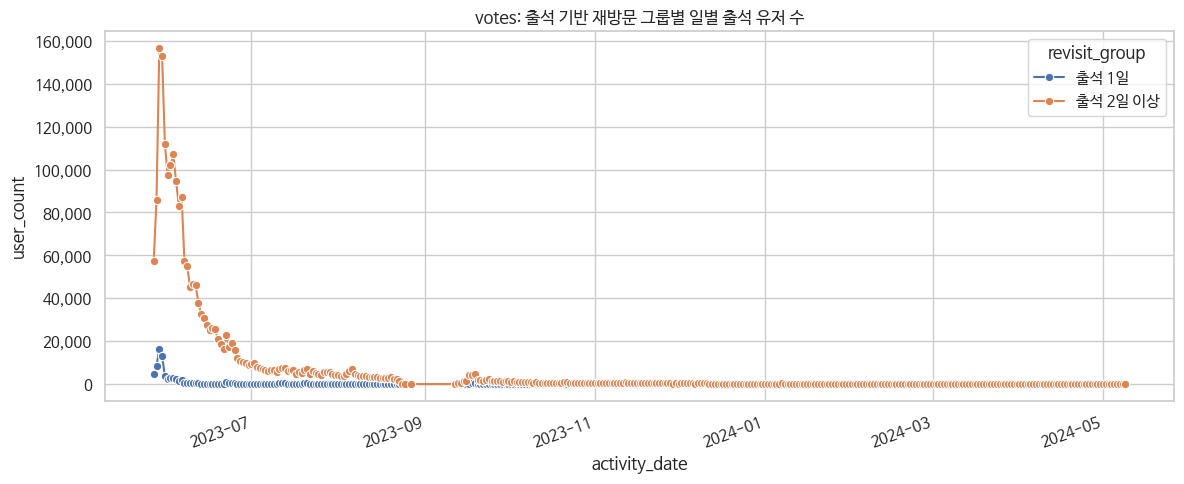

saved table preview: /content/votes_hackle_outputs/tables/02_votes_출석_일별_표.csv


#### votes 출석 일별 표

,activity_date,revisit_group,user_count
0,2023-05-27,출석 1일,4893
1,2023-05-27,출석 2일 이상,57524
2,2023-05-28,출석 1일,8552
3,2023-05-28,출석 2일 이상,85668
4,2023-05-29,출석 1일,16205
5,2023-05-29,출석 2일 이상,156631
6,2023-05-30,출석 1일,13069
7,2023-05-30,출석 2일 이상,152983
8,2023-05-31,출석 2일 이상,111971
9,2023-05-31,출석 1일,3742


### votes 결제 시계열
- **조건**: accounts_paymenthistory.created_at 기준 일별 결제 건수와 결제 유저 수
- **의미**: 결제 활동이 특정 날짜에 집중되는지 확인합니다.

saved figure: /content/votes_hackle_outputs/figures/02_votes_payment_daily.png


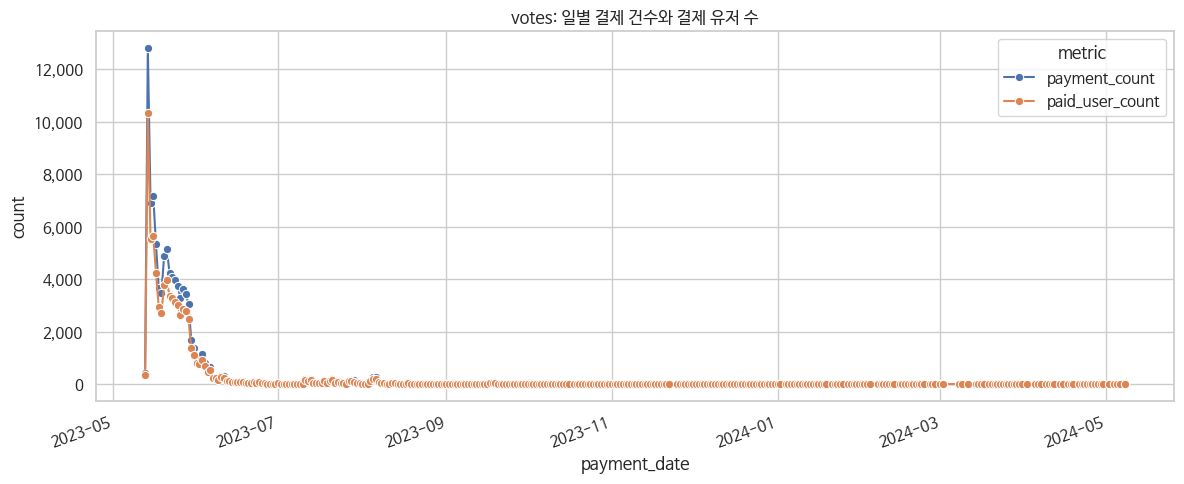

saved table preview: /content/votes_hackle_outputs/tables/03_votes_결제_일별_표.csv


#### votes 결제 일별 표

,payment_date,payment_count,paid_user_count
0,2023-05-13,421,362
1,2023-05-14,12802,10331
2,2023-05-15,6900,5536
3,2023-05-16,7163,5649
4,2023-05-17,5329,4244
5,2023-05-18,3676,2957
6,2023-05-19,3477,2726
7,2023-05-20,4875,3771
8,2023-05-21,5147,3957
9,2023-05-22,4229,3340


### votes 질문 기록 시계열
- **조건**: accounts_userquestionrecord.created_at 기준 일별 질문 기록 수, 열람 수, opened_times 합계
- **의미**: 질문 생성/열람 행동의 일별 흐름을 봅니다.

saved figure: /content/votes_hackle_outputs/figures/03_votes_question_daily.png


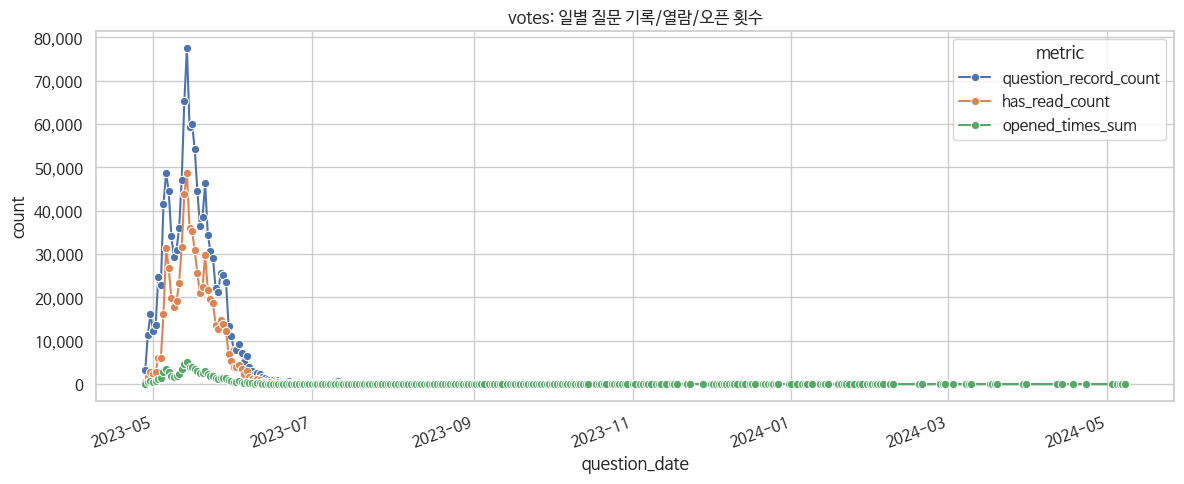

saved table preview: /content/votes_hackle_outputs/tables/04_votes_질문_기록_일별_표.csv


#### votes 질문 기록 일별 표

,question_date,question_record_count,question_user_count,question_chosen_user_count,has_read_count,opened_times_sum
0,2023-04-28,3173,125,181,457,104
1,2023-04-29,11405,221,371,1645,523
2,2023-04-30,16220,325,762,2709,629
3,2023-05-01,12274,325,973,2382,508
4,2023-05-02,13663,413,1307,2799,637
5,2023-05-03,24718,756,2025,6134,1281
6,2023-05-04,22814,820,2093,6134,1294
7,2023-05-05,41509,1248,3110,16082,2857
8,2023-05-06,48634,1375,3756,31311,3477
9,2023-05-07,44662,1355,4303,26842,2762


### hackle 시계열 지표
- **조건**: hackle_events 단일 테이블에서 event_datetime 기준 일별 이벤트 수와 세션 수
- **의미**: 앱 이벤트 로그의 전체 사용량 흐름을 session 기준으로 확인합니다.

saved figure: /content/votes_hackle_outputs/figures/04_hackle_daily.png


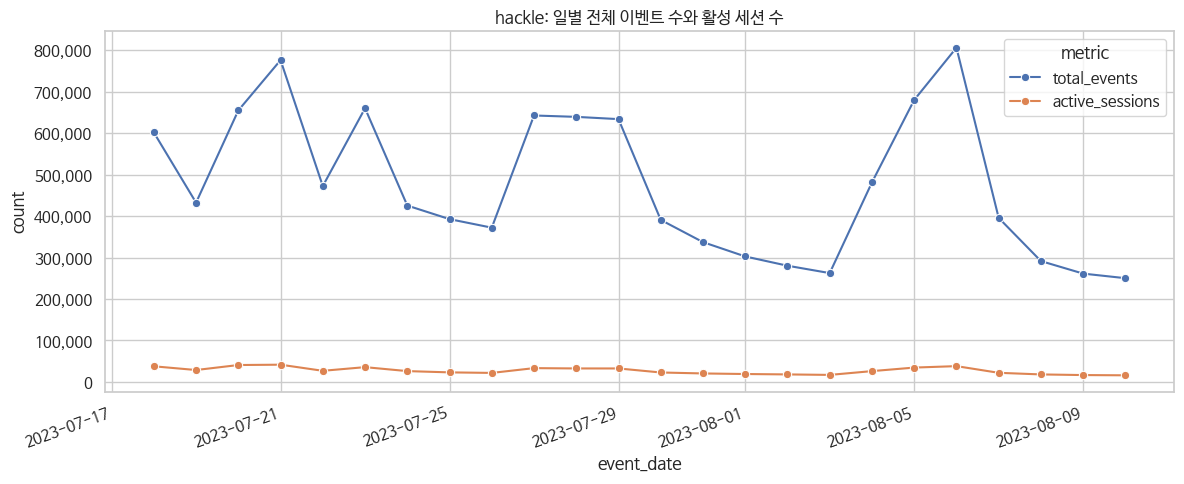

saved table preview: /content/votes_hackle_outputs/tables/05_hackle_일별_표.csv


#### hackle 일별 표

,event_date,total_events,click_appbar_alarm_center,click_attendance,click_bottom_navigation_timeline,click_friend_invite,click_invite_friend,click_notice_detail,click_question_open,click_question_share,view_timeline_tap,click_notice,active_sessions
0,2023-07-18,601647,16152,7688,31803,321,112,15867,49810,5998,154,1.0,37507
1,2023-07-19,432323,7280,6832,21502,144,48,7891,43146,5324,203,0.0,28536
2,2023-07-20,654795,18059,8914,37475,239,72,15989,53438,5188,3707,0.0,40601
3,2023-07-21,776150,19043,9252,38755,248,77,16890,53346,4931,105682,0.0,41398
4,2023-07-22,472335,7348,6470,21402,160,87,7593,37218,3531,58809,0.0,26653
5,2023-07-23,660058,16872,8104,34494,173,40,14911,48003,3887,90396,0.0,35480
6,2023-07-24,425333,6857,6621,19358,137,34,6889,34802,3323,52905,0.0,25937
7,2023-07-25,392567,5580,6080,16344,79,33,6040,30938,3260,45752,0.0,22856
8,2023-07-26,371971,4890,5681,14752,113,26,5464,27364,3014,41170,0.0,21566
9,2023-07-27,642616,16103,7227,29229,142,46,13684,39178,3894,77142,0.0,33098


In [ ]:
note(
    "votes 시계열 지표",
    "출석, 결제, 질문 기록, 친구 요청을 날짜 단위로 집계",
    "votes DB에서 주요 행동이 시간에 따라 언제 많아졌는지 비교합니다.",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=attendance_daily, x="activity_date", y="user_count", hue="revisit_group", marker="o", ax=ax)
ax.set_title("votes: 출석 기반 재방문 그룹별 일별 출석 유저 수")
ax.set_xlabel("activity_date")
ax.set_ylabel("user_count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig("votes: 출석 기반 재방문 그룹별 일별 출석 유저 수", "votes_attendance_daily")
show_table(attendance_daily, "votes 출석 일별 표")

note(
    "votes 결제 시계열",
    "accounts_paymenthistory.created_at 기준 일별 결제 건수와 결제 유저 수",
    "결제 활동이 특정 날짜에 집중되는지 확인합니다.",
)
payment_daily_long = payment_daily.melt(
    id_vars="payment_date",
    value_vars=["payment_count", "paid_user_count"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=payment_daily_long, x="payment_date", y="value", hue="metric", marker="o", ax=ax)
ax.set_title("votes: 일별 결제 건수와 결제 유저 수")
ax.set_xlabel("payment_date")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig("votes: 일별 결제 건수와 결제 유저 수", "votes_payment_daily")
show_table(payment_daily, "votes 결제 일별 표")

note(
    "votes 질문 기록 시계열",
    "accounts_userquestionrecord.created_at 기준 일별 질문 기록 수, 열람 수, opened_times 합계",
    "질문 생성/열람 행동의 일별 흐름을 봅니다.",
)
question_daily_long = question_daily.melt(
    id_vars="question_date",
    value_vars=["question_record_count", "has_read_count", "opened_times_sum"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=question_daily_long, x="question_date", y="value", hue="metric", marker="o", ax=ax)
ax.set_title("votes: 일별 질문 기록/열람/오픈 횟수")
ax.set_xlabel("question_date")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig("votes: 일별 질문 기록/열람/오픈 횟수", "votes_question_daily")
show_table(question_daily, "votes 질문 기록 일별 표")

note(
    "hackle 시계열 지표",
    "hackle_events 단일 테이블에서 event_datetime 기준 일별 이벤트 수와 세션 수",
    "앱 이벤트 로그의 전체 사용량 흐름을 session 기준으로 확인합니다.",
)
hackle_daily_long = hackle_daily.melt(
    id_vars="event_date",
    value_vars=["total_events", "active_sessions"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=hackle_daily_long, x="event_date", y="value", hue="metric", marker="o", ax=ax)
ax.set_title("hackle: 일별 전체 이벤트 수와 활성 세션 수")
ax.set_xlabel("event_date")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig("hackle: 일별 전체 이벤트 수와 활성 세션 수", "hackle_daily")
show_table(hackle_daily, "hackle 일별 표")

# ## 셀 1-9. 재방문

### 재방문 1: votes 출석 기반 재방문
- **조건**: accounts_attendance.attendance_date_list의 서로 다른 날짜 수가 2일 이상이면 재방문으로 분류
- **의미**: 출석 기록 기준으로 1일 출석 유저와 2일 이상 출석 유저의 규모를 비교합니다.

saved figure: /content/votes_hackle_outputs/figures/05_revisit_votes_attendance.png


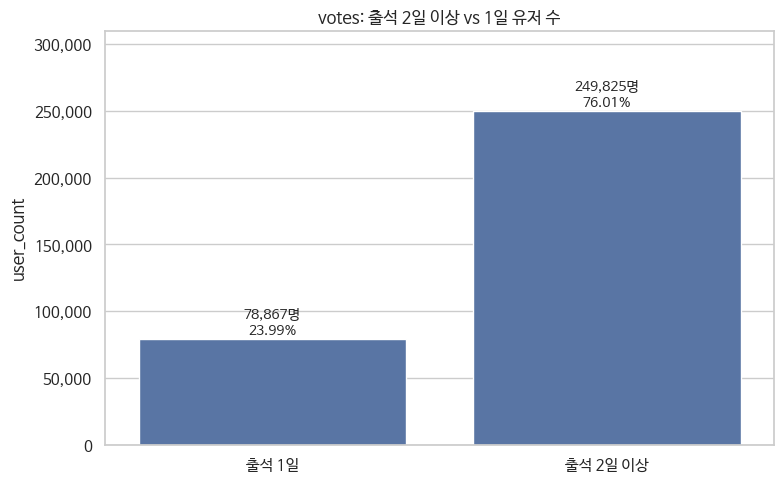

saved table preview: /content/votes_hackle_outputs/tables/06_votes_출석_재방문_요약.csv


#### votes 출석 재방문 요약

,group,user_count,ratio_pct,label
0,출석 1일,78867,23.99,"78,867명\n23.99%"
1,출석 2일 이상,249825,76.01,"249,825명\n76.01%"


### 재방문 2: hackle session 기준 반복 행동
- **조건**: session_id+날짜 기준으로 click_attendance 2회 이상/미만, 전체 로그 2회 이상/미만을 비교
- **의미**: 사람 기준이 아니라 세션-일 기준으로 반복 행동이 많은 세션을 봅니다.

saved figure: /content/votes_hackle_outputs/figures/06_revisit_hackle_session_day.png


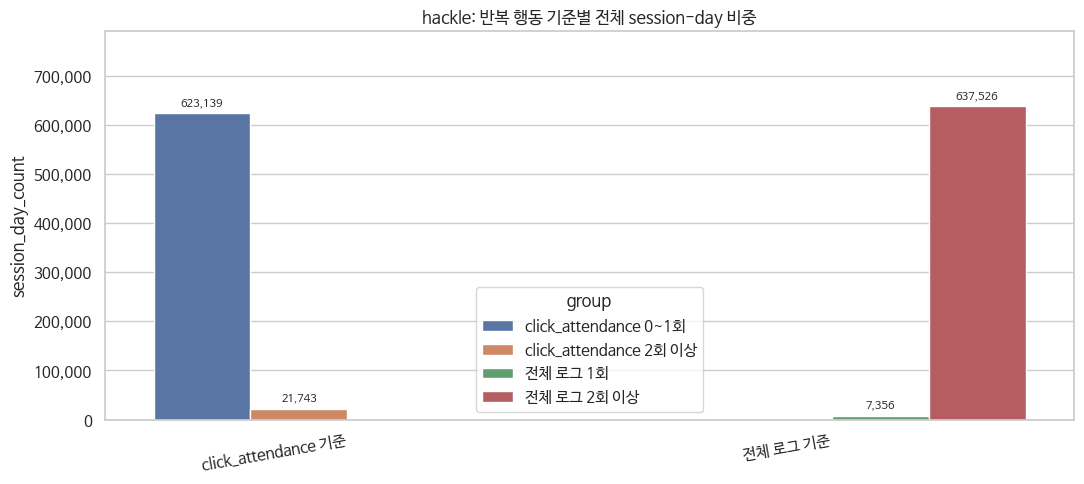

saved table preview: /content/votes_hackle_outputs/tables/07_hackle_재방문_반복_행동_요약.csv


#### hackle 재방문/반복 행동 요약

,criterion,group,session_day_count,ratio_pct
0,click_attendance 기준,click_attendance 0~1회,623139,96.63
1,click_attendance 기준,click_attendance 2회 이상,21743,3.37
2,전체 로그 기준,전체 로그 1회,7356,1.14
3,전체 로그 기준,전체 로그 2회 이상,637526,98.86


In [ ]:
note(
    "재방문 1: votes 출석 기반 재방문",
    "accounts_attendance.attendance_date_list의 서로 다른 날짜 수가 2일 이상이면 재방문으로 분류",
    "출석 기록 기준으로 1일 출석 유저와 2일 이상 출석 유저의 규모를 비교합니다.",
)

attendance_revisit_summary = (
    attendance_user_agg.assign(group=lambda d: np.where(d["attendance_days"] >= 2, "출석 2일 이상", "출석 1일"))
    .groupby("group", as_index=False)
    .agg(user_count=("user_id", "nunique"))
)
attendance_revisit_summary = add_ratio_pct(attendance_revisit_summary, "user_count")
attendance_revisit_summary["label"] = attendance_revisit_summary.apply(
    lambda r: f"{r['user_count']:,.0f}명\n{r['ratio_pct']:.2f}%",
    axis=1,
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=attendance_revisit_summary, x="group", y="user_count", ax=ax)
pad_y_axis(ax)
for i, row in attendance_revisit_summary.reset_index(drop=True).iterrows():
    ax.text(i, row["user_count"], row["label"], ha="center", va="bottom", fontsize=10)
ax.set_title("votes: 출석 2일 이상 vs 1일 유저 수")
ax.set_xlabel("")
ax.set_ylabel("user_count")
format_count_axis(ax)
save_mpl_fig("votes: 출석 2일 이상 vs 1일 유저 수", "revisit_votes_attendance")
show_table(attendance_revisit_summary, "votes 출석 재방문 요약")

note(
    "재방문 2: hackle session 기준 반복 행동",
    "session_id+날짜 기준으로 click_attendance 2회 이상/미만, 전체 로그 2회 이상/미만을 비교",
    "사람 기준이 아니라 세션-일 기준으로 반복 행동이 많은 세션을 봅니다.",
)
h = session_day.copy()
h["click_attendance_group"] = np.where(h["click_attendance_count"] >= 2, "click_attendance 2회 이상", "click_attendance 0~1회")
h["total_event_group"] = np.where(h["total_event_count"] >= 2, "전체 로그 2회 이상", "전체 로그 1회")
hackle_click_attendance_daily = (
    h.groupby(["event_date", "click_attendance_group"], as_index=False)
    .agg(session_day_count=("session_id", "nunique"))
    .rename(columns={"click_attendance_group": "group"})
)
hackle_click_attendance_daily["criterion"] = "click_attendance 기준"
hackle_total_event_daily = (
    h.groupby(["event_date", "total_event_group"], as_index=False)
    .agg(session_day_count=("session_id", "nunique"))
    .rename(columns={"total_event_group": "group"})
)
hackle_total_event_daily["criterion"] = "전체 로그 기준"
hackle_revisit_daily = pd.concat([hackle_click_attendance_daily, hackle_total_event_daily], ignore_index=True)
hackle_revisit_summary = (
    hackle_revisit_daily.groupby(["criterion", "group"], as_index=False)
    .agg(session_day_count=("session_day_count", "sum"))
)
hackle_revisit_summary = (
    hackle_revisit_summary.groupby("criterion", group_keys=False)
    .apply(lambda d: add_ratio_pct(d, "session_day_count"))
    .reset_index(drop=True)
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=hackle_revisit_summary, x="criterion", y="session_day_count", hue="group", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title("hackle: 반복 행동 기준별 전체 session-day 비중")
ax.set_xlabel("")
ax.set_ylabel("session_day_count")
format_count_axis(ax)
rotate_xticks(ax, 10)
save_mpl_fig("hackle: 반복 행동 기준별 전체 session-day 비중", "revisit_hackle_session_day")
show_table(hackle_revisit_summary, "hackle 재방문/반복 행동 요약")


# ## 셀 1-10. 결제

### 결제 1: 결제 유저/미결제 유저/평균 결제 횟수
- **조건**: accounts_user 전체 user_id 중 accounts_paymenthistory에 등장한 유저를 결제 유저로 분류
- **의미**: 결제를 한 번이라도 한 유저 규모와 유저당 평균 결제 빈도를 봅니다.

saved figure: /content/votes_hackle_outputs/figures/07_payment_paid_unpaid.png


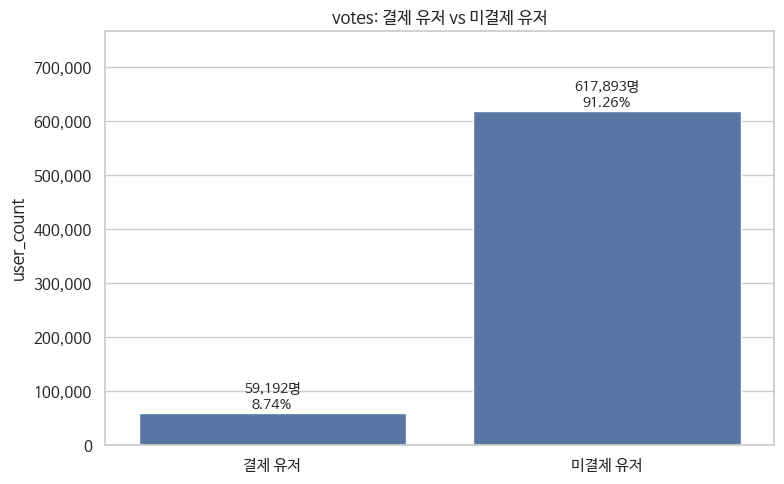

saved table preview: /content/votes_hackle_outputs/tables/08_결제_KPI_표.csv


#### 결제 KPI 표

,metric,value
0,결제 유저 수,59192.000000
1,미결제 유저 수,617893.000000
2,결제 유저당 평균 결제 시각 수,1.598341


### 결제 2: productId별 결제 분포
- **조건**: productId별 총 결제 건수, 서로 다른 결제 유저 수, 같은 유저가 같은 상품을 2회 이상 결제한 쌍 수
- **의미**: 어떤 상품이 많이 팔렸고, 같은 상품을 반복 구매한 유저가 얼마나 있는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/08_payment_product_distribution.png


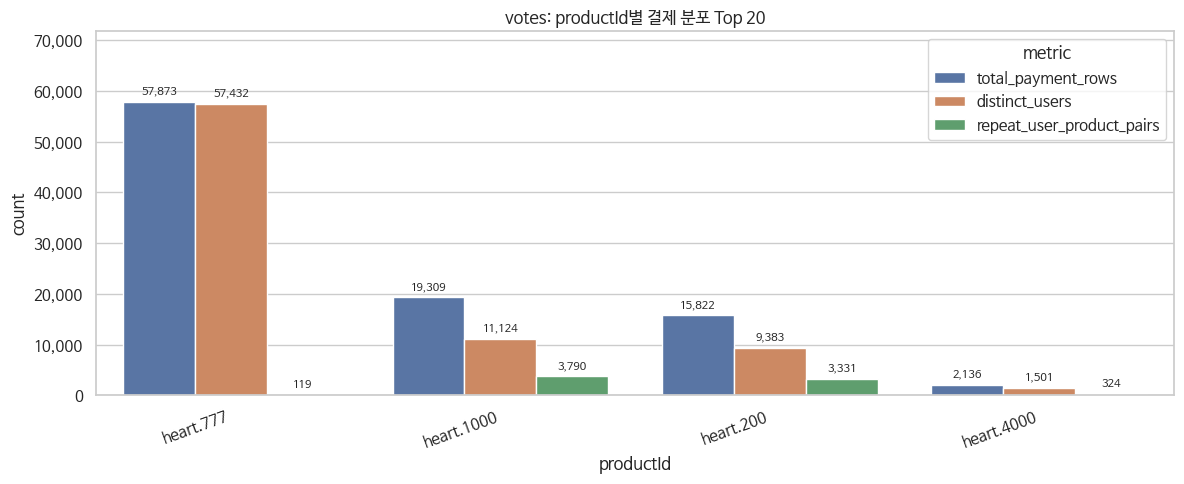

saved table preview: /content/votes_hackle_outputs/tables/09_productId별_결제_분포_표.csv


#### productId별 결제 분포 표

,productId,distinct_users,user_product_pairs,repeat_user_product_pairs,total_payment_rows
0,heart.777,57432,57432,119,57873
1,heart.1000,11124,11124,3790,19309
2,heart.200,9383,9383,3331,15822
3,heart.4000,1501,1501,324,2136


In [ ]:
note(
    "결제 1: 결제 유저/미결제 유저/평균 결제 횟수",
    "accounts_user 전체 user_id 중 accounts_paymenthistory에 등장한 유저를 결제 유저로 분류",
    "결제를 한 번이라도 한 유저 규모와 유저당 평균 결제 빈도를 봅니다.",
)
paid_user_count = payment_user_agg["user_id"].nunique()
total_user_count = all_users["user_id"].nunique()
unpaid_user_count = total_user_count - paid_user_count
avg_payment_distinct_at = payment_user_agg["payment_distinct_at"].mean()
payment_user_status = pd.DataFrame({
    "group": ["결제 유저", "미결제 유저"],
    "user_count": [paid_user_count, unpaid_user_count],
})
payment_user_status = add_ratio_pct(payment_user_status, "user_count")
payment_kpi = pd.DataFrame({
    "metric": ["결제 유저 수", "미결제 유저 수", "결제 유저당 평균 결제 시각 수"],
    "value": [paid_user_count, unpaid_user_count, avg_payment_distinct_at],
})
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=payment_user_status, x="group", y="user_count", ax=ax)
pad_y_axis(ax)
for i, row in payment_user_status.reset_index(drop=True).iterrows():
    ax.text(i, row["user_count"], f"{row['user_count']:,.0f}명\n{row['ratio_pct']:.2f}%", ha="center", va="bottom", fontsize=10)
ax.set_title("votes: 결제 유저 vs 미결제 유저")
ax.set_xlabel("")
ax.set_ylabel("user_count")
format_count_axis(ax)
save_mpl_fig("votes: 결제 유저 vs 미결제 유저", "payment_paid_unpaid")
show_table(payment_kpi, "결제 KPI 표")

note(
    "결제 2: productId별 결제 분포",
    "productId별 총 결제 건수, 서로 다른 결제 유저 수, 같은 유저가 같은 상품을 2회 이상 결제한 쌍 수",
    "어떤 상품이 많이 팔렸고, 같은 상품을 반복 구매한 유저가 얼마나 있는지 봅니다.",
)
product_top = product_summary.head(TOP_N)
product_top_long = product_top.melt(
    id_vars="productId",
    value_vars=["total_payment_rows", "distinct_users", "repeat_user_product_pairs"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=product_top_long, x="productId", y="value", hue="metric", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title(f"votes: productId별 결제 분포 Top {TOP_N}")
ax.set_xlabel("productId")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 20)
save_mpl_fig(f"votes: productId별 결제 분포 Top {TOP_N}", "payment_product_distribution")
show_table(product_summary, "productId별 결제 분포 표")

# ## 셀 1-11. 자발적 재참여/알림 관련 이벤트

### 자발적 재참여 1: 알림/타임라인 관련 event_key별 세션 분포
- **조건**: hackle_events에서 알림/타임라인 관련 event_key만 선택하고, session_id별 event_count 분포를 비교
- **의미**: 각 event_key가 세션에서 얼마나 반복적으로 발생하는지 봅니다. click_notice_detail이 알림 클릭 후 상세 진입에 가장 가까운 지표로 추정됩니다.

saved figure: /content/votes_hackle_outputs/figures/09_notice_event_distribution.png


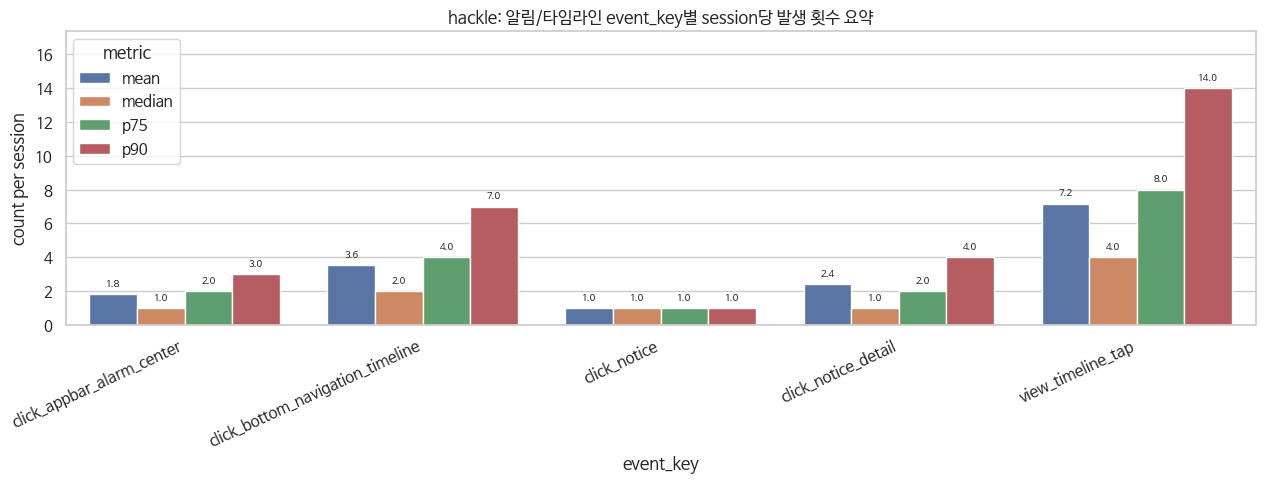

saved table preview: /content/votes_hackle_outputs/tables/10_알림_타임라인_event_key_분포_요약.csv


#### 알림/타임라인 event_key 분포 요약

,event_key,count,mean,median,p75,p90,max
0,click_appbar_alarm_center,140284,1.807341,1.0,2.0,3.0,3674
1,click_bottom_navigation_timeline,150463,3.562677,2.0,4.0,7.0,925
2,click_notice,1,1.000000,1.0,1.0,1.0,1
3,click_notice_detail,95541,2.400624,1.0,2.0,4.0,1492
4,view_timeline_tap,166495,7.174438,4.0,8.0,14.0,817


### 자발적 재참여 2: event_key 전체 발생 건수
- **조건**: 선택한 알림/타임라인 event_key별 전체 event_count 합계
- **의미**: 어떤 진입/클릭 행동이 가장 자주 발생했는지 비교합니다.

saved figure: /content/votes_hackle_outputs/figures/10_notice_event_total.png


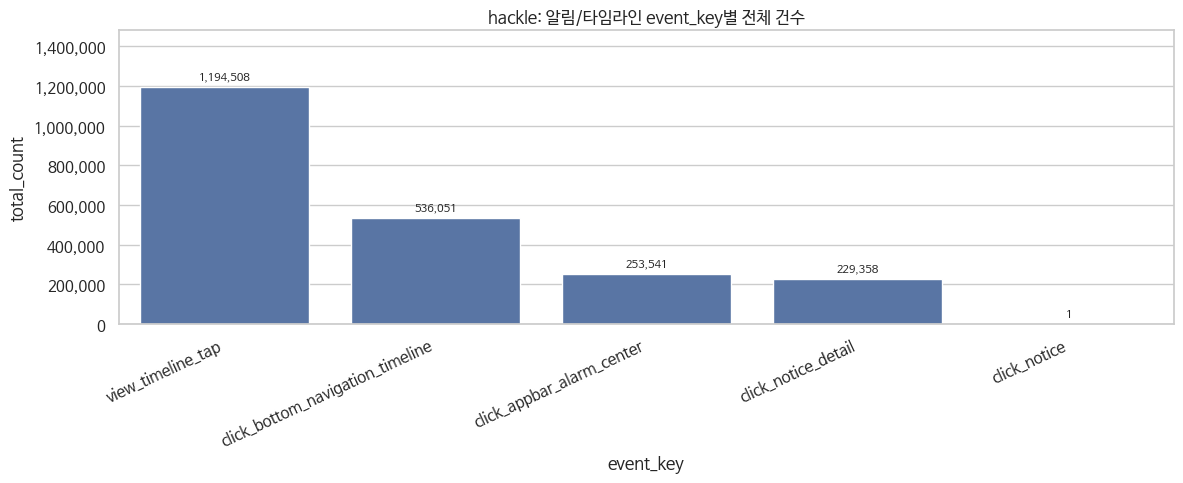

saved table preview: /content/votes_hackle_outputs/tables/11_알림_타임라인_event_key_전체_건수.csv


#### 알림/타임라인 event_key 전체 건수

,event_key,total_count
4,view_timeline_tap,1194508
1,click_bottom_navigation_timeline,536051
0,click_appbar_alarm_center,253541
3,click_notice_detail,229358
2,click_notice,1


### 자발적 재참여 3: 같은 session에서 다른 날짜에 2일 이상 발생
- **조건**: session_id+event_key 기준으로 서로 다른 event_date가 2일 이상이면 2일 이상 그룹으로 분류
- **의미**: 같은 세션 식별자에서 특정 알림/타임라인 행동이 날짜를 달리해 반복되는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/11_notice_event_2plus_days.png


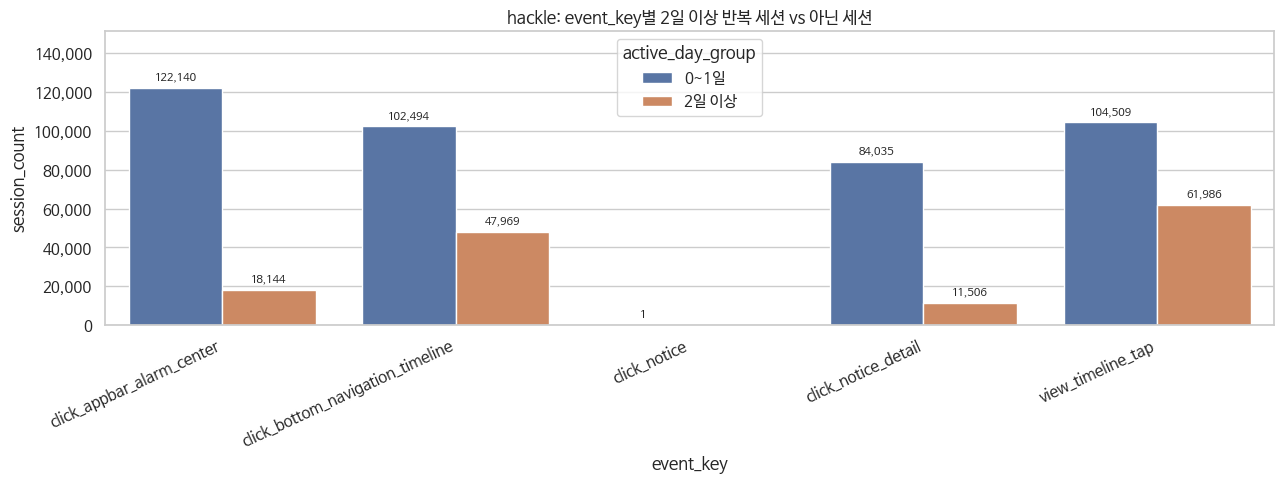

saved table preview: /content/votes_hackle_outputs/tables/12_알림_타임라인_2일_이상_반복_세션_표.csv


#### 알림/타임라인 2일 이상 반복 세션 표

,event_key,active_day_group,session_count
0,click_appbar_alarm_center,0~1일,122140
1,click_appbar_alarm_center,2일 이상,18144
2,click_bottom_navigation_timeline,0~1일,102494
3,click_bottom_navigation_timeline,2일 이상,47969
4,click_notice,0~1일,1
5,click_notice_detail,0~1일,84035
6,click_notice_detail,2일 이상,11506
7,view_timeline_tap,0~1일,104509
8,view_timeline_tap,2일 이상,61986


In [ ]:
notice_session = event_session[event_session["event_key"].isin(NOTICE_EVENT_KEYS)].copy()

note(
    "자발적 재참여 1: 알림/타임라인 관련 event_key별 세션 분포",
    "hackle_events에서 알림/타임라인 관련 event_key만 선택하고, session_id별 event_count 분포를 비교",
    "각 event_key가 세션에서 얼마나 반복적으로 발생하는지 봅니다. click_notice_detail이 알림 클릭 후 상세 진입에 가장 가까운 지표로 추정됩니다.",
)
notice_distribution = distribution_summary(notice_session, "event_count", "event_key")
notice_distribution_long = notice_distribution.melt(
    id_vars="event_key",
    value_vars=["mean", "median", "p75", "p90"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=notice_distribution_long, x="event_key", y="value", hue="metric", ax=ax)
add_bar_labels(ax, decimals=1, fontsize=7)
pad_y_axis(ax)
ax.set_title("hackle: 알림/타임라인 event_key별 session당 발생 횟수 요약")
ax.set_xlabel("event_key")
ax.set_ylabel("count per session")
rotate_xticks(ax, 25)
save_mpl_fig("hackle: 알림/타임라인 event_key별 session당 발생 횟수 요약", "notice_event_distribution")
show_table(notice_distribution, "알림/타임라인 event_key 분포 요약")

note(
    "자발적 재참여 2: event_key 전체 발생 건수",
    "선택한 알림/타임라인 event_key별 전체 event_count 합계",
    "어떤 진입/클릭 행동이 가장 자주 발생했는지 비교합니다.",
)
notice_total = notice_session.groupby("event_key", as_index=False).agg(total_count=("event_count", "sum")).sort_values("total_count", ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=notice_total, x="event_key", y="total_count", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title("hackle: 알림/타임라인 event_key별 전체 건수")
ax.set_xlabel("event_key")
ax.set_ylabel("total_count")
format_count_axis(ax)
rotate_xticks(ax, 25)
save_mpl_fig("hackle: 알림/타임라인 event_key별 전체 건수", "notice_event_total")
show_table(notice_total, "알림/타임라인 event_key 전체 건수")

note(
    "자발적 재참여 3: 같은 session에서 다른 날짜에 2일 이상 발생",
    "session_id+event_key 기준으로 서로 다른 event_date가 2일 이상이면 2일 이상 그룹으로 분류",
    "같은 세션 식별자에서 특정 알림/타임라인 행동이 날짜를 달리해 반복되는지 봅니다.",
)
notice_days = notice_session.copy()
notice_days["active_day_group"] = np.where(notice_days["active_days"] >= 2, "2일 이상", "0~1일")
notice_days_summary = notice_days.groupby(["event_key", "active_day_group"], as_index=False).agg(session_count=("session_id", "nunique"))
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=notice_days_summary, x="event_key", y="session_count", hue="active_day_group", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title("hackle: event_key별 2일 이상 반복 세션 vs 아닌 세션")
ax.set_xlabel("event_key")
ax.set_ylabel("session_count")
format_count_axis(ax)
rotate_xticks(ax, 25)
save_mpl_fig("hackle: event_key별 2일 이상 반복 세션 vs 아닌 세션", "notice_event_2plus_days")
show_table(notice_days_summary, "알림/타임라인 2일 이상 반복 세션 표")

# ## 셀 1-12. 누적 활동일 수

### 누적 활동일 수 1: 비연속 활동일 수
- **조건**: accounts_attendance.attendance_date_list에서 서로 다른 날짜 수를 user_id별로 계산
- **의미**: 한 유저가 전체 기간 중 며칠 활동했는지 분포를 봅니다.

saved figure: /content/votes_hackle_outputs/figures/12_activity_days_bucket.png


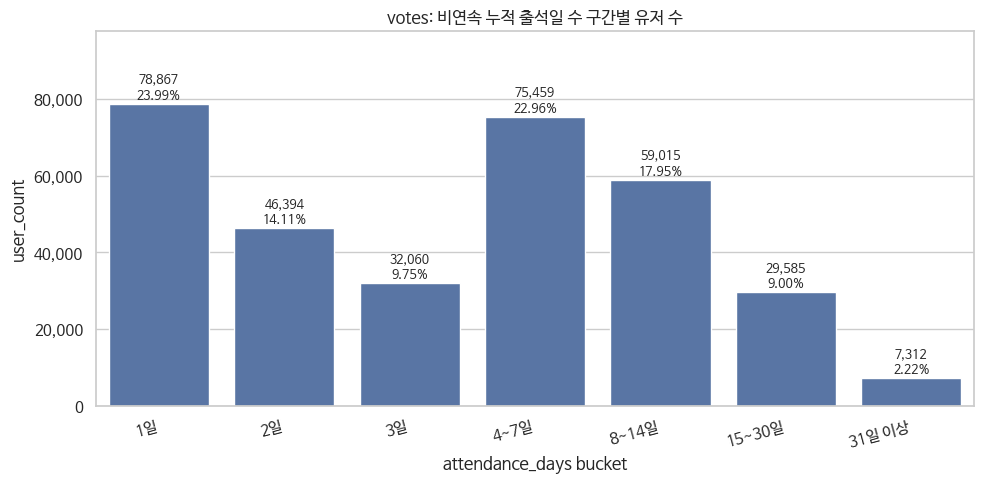

saved table preview: /content/votes_hackle_outputs/tables/13_비연속_누적_활동일_수_구간_요약.csv


#### 비연속 누적 활동일 수 구간 요약

,bucket,user_count,ratio_pct
0,1일,78867,23.99
1,2일,46394,14.11
2,3일,32060,9.75
3,4~7일,75459,22.96
4,8~14일,59015,17.95
5,15~30일,29585,9.00
6,31일 이상,7312,2.22


### 누적 활동일 수 2: 최장 연속 활동일 수
- **조건**: attendance_date_list에서 하루 차이로 이어지는 최장 연속 출석 구간을 user_id별로 계산
- **의미**: 끊기지 않고 연속적으로 활동한 기간이 긴 유저가 얼마나 있는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/13_activity_streak_bucket.png


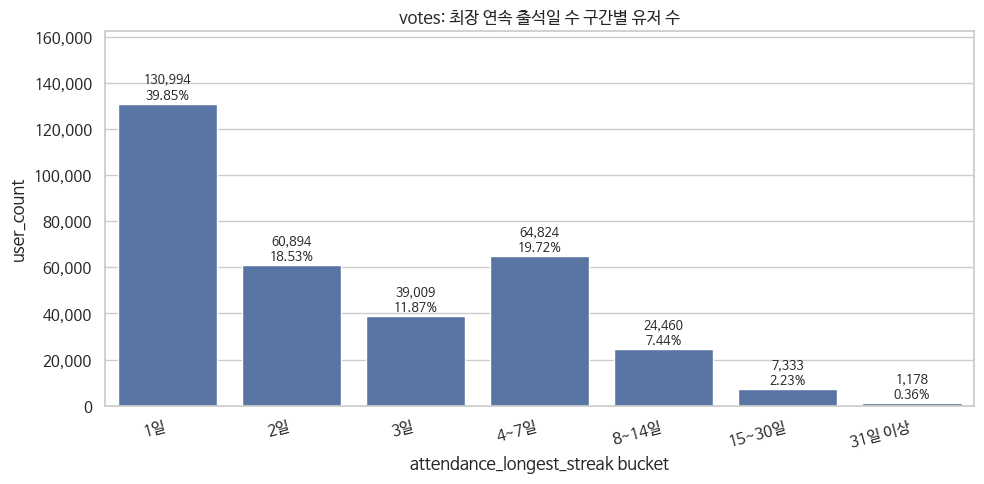

saved table preview: /content/votes_hackle_outputs/tables/14_최장_연속_활동일_수_구간_요약.csv


#### 최장 연속 활동일 수 구간 요약

,bucket,user_count,ratio_pct
0,1일,130994,39.85
1,2일,60894,18.53
2,3일,39009,11.87
3,4~7일,64824,19.72
4,8~14일,24460,7.44
5,15~30일,7333,2.23
6,31일 이상,1178,0.36


In [ ]:
note(
    "누적 활동일 수 1: 비연속 활동일 수",
    "accounts_attendance.attendance_date_list에서 서로 다른 날짜 수를 user_id별로 계산",
    "한 유저가 전체 기간 중 며칠 활동했는지 분포를 봅니다.",
)
attendance_days_bucket = bucket_summary(
    attendance_user_agg,
    "attendance_days",
    bins=[0, 1, 2, 3, 7, 14, 30, np.inf],
    labels=["1일", "2일", "3일", "4~7일", "8~14일", "15~30일", "31일 이상"],
    count_name="user_count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=attendance_days_bucket, x="bucket", y="user_count", ax=ax)
pad_y_axis(ax)
for i, row in attendance_days_bucket.reset_index(drop=True).iterrows():
    ax.text(i, row["user_count"], f"{row['user_count']:,.0f}\n{row['ratio_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("votes: 비연속 누적 출석일 수 구간별 유저 수")
ax.set_xlabel("attendance_days bucket")
ax.set_ylabel("user_count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("votes: 비연속 누적 출석일 수 구간별 유저 수", "activity_days_bucket")
show_table(attendance_days_bucket, "비연속 누적 활동일 수 구간 요약")

note(
    "누적 활동일 수 2: 최장 연속 활동일 수",
    "attendance_date_list에서 하루 차이로 이어지는 최장 연속 출석 구간을 user_id별로 계산",
    "끊기지 않고 연속적으로 활동한 기간이 긴 유저가 얼마나 있는지 봅니다.",
)
attendance_streak_bucket = bucket_summary(
    attendance_user_agg,
    "attendance_longest_streak",
    bins=[0, 1, 2, 3, 7, 14, 30, np.inf],
    labels=["1일", "2일", "3일", "4~7일", "8~14일", "15~30일", "31일 이상"],
    count_name="user_count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=attendance_streak_bucket, x="bucket", y="user_count", ax=ax)
pad_y_axis(ax)
for i, row in attendance_streak_bucket.reset_index(drop=True).iterrows():
    ax.text(i, row["user_count"], f"{row['user_count']:,.0f}\n{row['ratio_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("votes: 최장 연속 출석일 수 구간별 유저 수")
ax.set_xlabel("attendance_longest_streak bucket")
ax.set_ylabel("user_count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("votes: 최장 연속 출석일 수 구간별 유저 수", "activity_streak_bucket")
show_table(attendance_streak_bucket, "최장 연속 활동일 수 구간 요약")

# ## 셀 1-13. 핵심 행동 반복

### 핵심 행동 반복 1: votes 질문 기록 기준
- **조건**: accounts_userquestionrecord에서 user_id 기준과 chosen_user_id 기준으로 record_count, has_read 합계, opened_times 합계를 비교
- **의미**: 질문을 던진/받은 역할별로 질문 수와 열람 행동이 어떻게 다른지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/14_core_question_role_mean.png


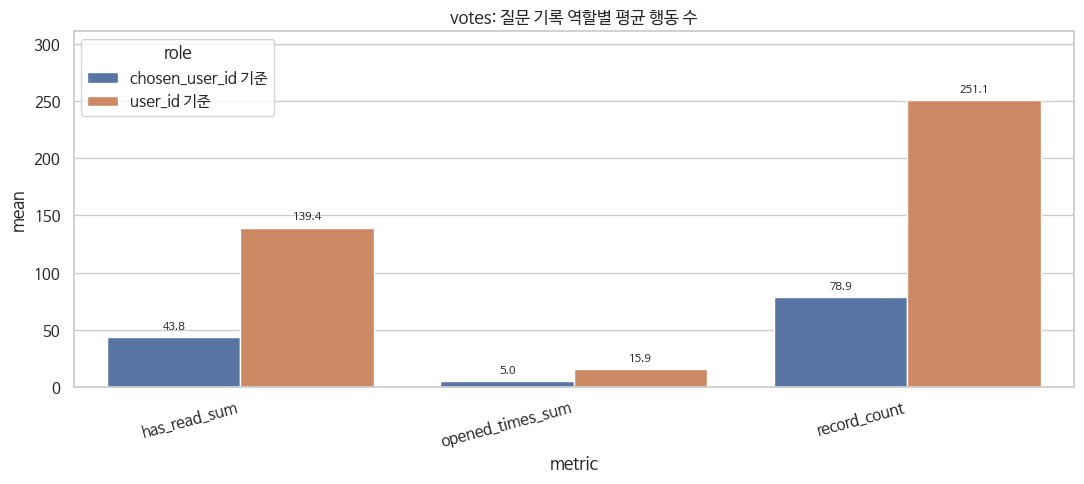

saved table preview: /content/votes_hackle_outputs/tables/15_질문_기록_역할별_요약.csv


#### 질문 기록 역할별 요약

,role,metric,mean,median,max
0,chosen_user_id 기준,has_read_sum,43.817646,6.0,912.0
1,chosen_user_id 기준,opened_times_sum,4.998185,0.0,101.0
2,chosen_user_id 기준,record_count,78.928951,15.0,1239.0
3,user_id 기준,has_read_sum,139.395958,101.0,1172.0
4,user_id 기준,opened_times_sum,15.900598,10.0,174.0
5,user_id 기준,record_count,251.094659,190.0,2786.0


### 핵심 행동 반복 2: hackle session 기준 질문 열람
- **조건**: session_id별 votes_count 최대값과 click_question_open 발생 횟수를 비교
- **의미**: 세션 기준으로 받은 투표/질문 규모와 질문 열람 행동이 같이 움직이는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/15_core_votes_open_heatmap.png


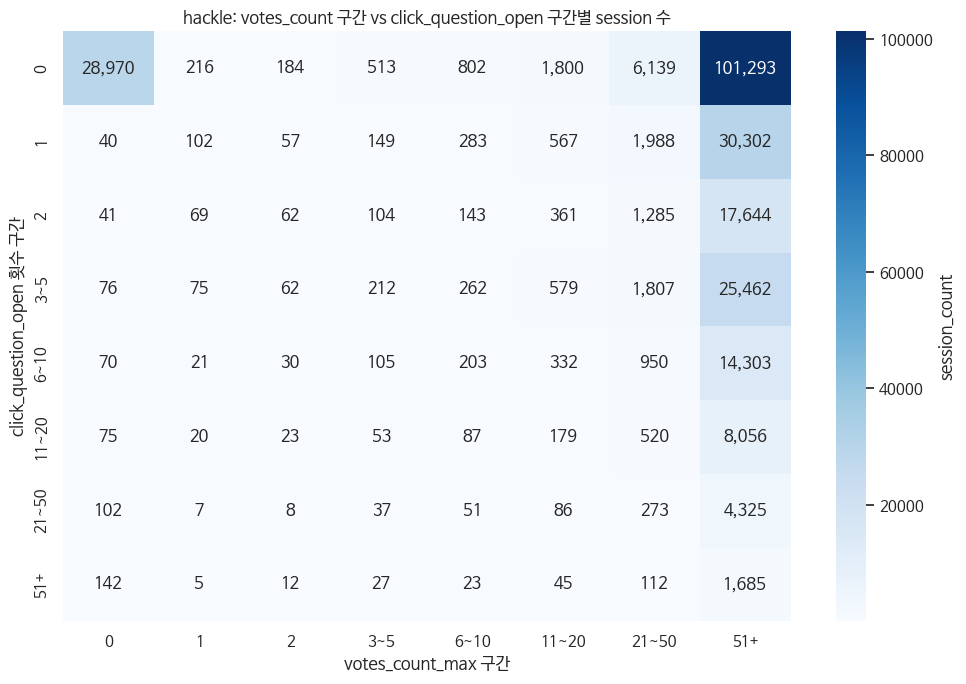

saved figure: /content/votes_hackle_outputs/figures/16_core_question_open_bucket.png


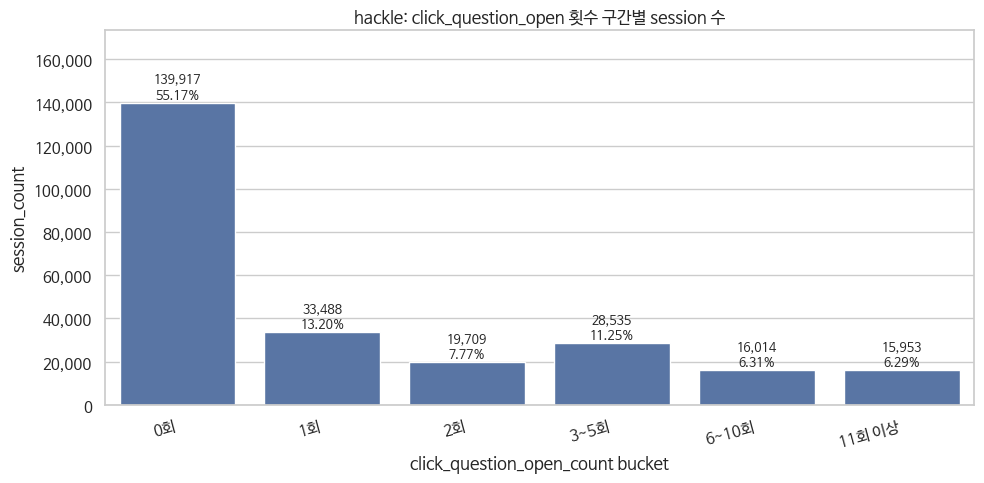

saved table preview: /content/votes_hackle_outputs/tables/16_hackle_click_question_open_분포_요약.csv


#### hackle click_question_open 분포 요약

,metric,count,mean,median,p75,p90,max
0,click_question_open_count,253616.0,3.220621,0.0,2.0,7.0,1515.0


In [ ]:
note(
    "핵심 행동 반복 1: votes 질문 기록 기준",
    "accounts_userquestionrecord에서 user_id 기준과 chosen_user_id 기준으로 record_count, has_read 합계, opened_times 합계를 비교",
    "질문을 던진/받은 역할별로 질문 수와 열람 행동이 어떻게 다른지 봅니다.",
)
question_compare = pd.concat(
    [
        question_user_agg[["user_id", "question_user_record_count", "question_user_has_read_sum", "question_user_opened_times_sum"]]
        .rename(columns={
            "question_user_record_count": "record_count",
            "question_user_has_read_sum": "has_read_sum",
            "question_user_opened_times_sum": "opened_times_sum",
        })
        .assign(role="user_id 기준"),
        question_user_agg[["user_id", "question_chosen_record_count", "question_chosen_has_read_sum", "question_chosen_opened_times_sum"]]
        .rename(columns={
            "question_chosen_record_count": "record_count",
            "question_chosen_has_read_sum": "has_read_sum",
            "question_chosen_opened_times_sum": "opened_times_sum",
        })
        .assign(role="chosen_user_id 기준"),
    ],
    ignore_index=True,
)
question_compare_long = question_compare.melt(
    id_vars=["user_id", "role"],
    value_vars=["record_count", "has_read_sum", "opened_times_sum"],
    var_name="metric",
    value_name="value",
)
question_role_summary = question_compare_long.groupby(["role", "metric"], as_index=False).agg(
    mean=("value", "mean"),
    median=("value", "median"),
    max=("value", "max"),
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=question_role_summary, x="metric", y="mean", hue="role", ax=ax)
add_bar_labels(ax, decimals=1, fontsize=8)
pad_y_axis(ax)
ax.set_title("votes: 질문 기록 역할별 평균 행동 수")
ax.set_xlabel("metric")
ax.set_ylabel("mean")
rotate_xticks(ax, 15)
save_mpl_fig("votes: 질문 기록 역할별 평균 행동 수", "core_question_role_mean")
show_table(question_role_summary, "질문 기록 역할별 요약")

note(
    "핵심 행동 반복 2: hackle session 기준 질문 열람",
    "session_id별 votes_count 최대값과 click_question_open 발생 횟수를 비교",
    "세션 기준으로 받은 투표/질문 규모와 질문 열람 행동이 같이 움직이는지 봅니다.",
)
core_relation = core_session.copy()
core_relation["votes_count_bucket"] = pd.cut(
    pd.to_numeric(core_relation["votes_count_max"], errors="coerce").fillna(0),
    bins=[-0.1, 0, 1, 2, 5, 10, 20, 50, np.inf],
    labels=["0", "1", "2", "3~5", "6~10", "11~20", "21~50", "51+"],
)
core_relation["question_open_bucket"] = pd.cut(
    pd.to_numeric(core_relation["click_question_open_count"], errors="coerce").fillna(0),
    bins=[-0.1, 0, 1, 2, 5, 10, 20, 50, np.inf],
    labels=["0", "1", "2", "3~5", "6~10", "11~20", "21~50", "51+"],
)
core_relation_summary = core_relation.groupby(["question_open_bucket", "votes_count_bucket"], observed=False, as_index=False).size().rename(columns={"size": "session_count"})
core_relation_pivot = core_relation_summary.pivot(index="question_open_bucket", columns="votes_count_bucket", values="session_count").fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    core_relation_pivot,
    annot=core_relation_pivot.applymap(lambda x: f"{x:,}"),
    fmt="",
    cmap="Blues",
    cbar_kws={"label": "session_count"},
    ax=ax,
)
ax.set_title("hackle: votes_count 구간 vs click_question_open 구간별 session 수")
ax.set_xlabel("votes_count_max 구간")
ax.set_ylabel("click_question_open 횟수 구간")
save_mpl_fig("hackle: votes_count 구간 vs click_question_open 구간별 session 수", "core_votes_open_heatmap")

core_open_bucket = bucket_summary(
    core_session,
    "click_question_open_count",
    bins=[-0.1, 0, 1, 2, 5, 10, np.inf],
    labels=["0회", "1회", "2회", "3~5회", "6~10회", "11회 이상"],
    count_name="session_count",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=core_open_bucket, x="bucket", y="session_count", ax=ax)
pad_y_axis(ax)
for i, row in core_open_bucket.reset_index(drop=True).iterrows():
    ax.text(i, row["session_count"], f"{row['session_count']:,.0f}\n{row['ratio_pct']:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("hackle: click_question_open 횟수 구간별 session 수")
ax.set_xlabel("click_question_open_count bucket")
ax.set_ylabel("session_count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("hackle: click_question_open 횟수 구간별 session 수", "core_question_open_bucket")
show_table(distribution_summary(core_session, "click_question_open_count"), "hackle click_question_open 분포 요약")

# ## 셀 1-14. 추천/공유

### 추천/공유 1: votes 친구 요청
- **조건**: accounts_friendrequest에서 send_user_id별 서로 다른 receive_user_id 수와 receive_user_id별 서로 다른 send_user_id 수를 비교
- **의미**: 친구 요청을 많이 보낸 유저와 많이 받은 유저의 분포를 봅니다.

saved figure: /content/votes_hackle_outputs/figures/17_share_friend_request_bucket.png


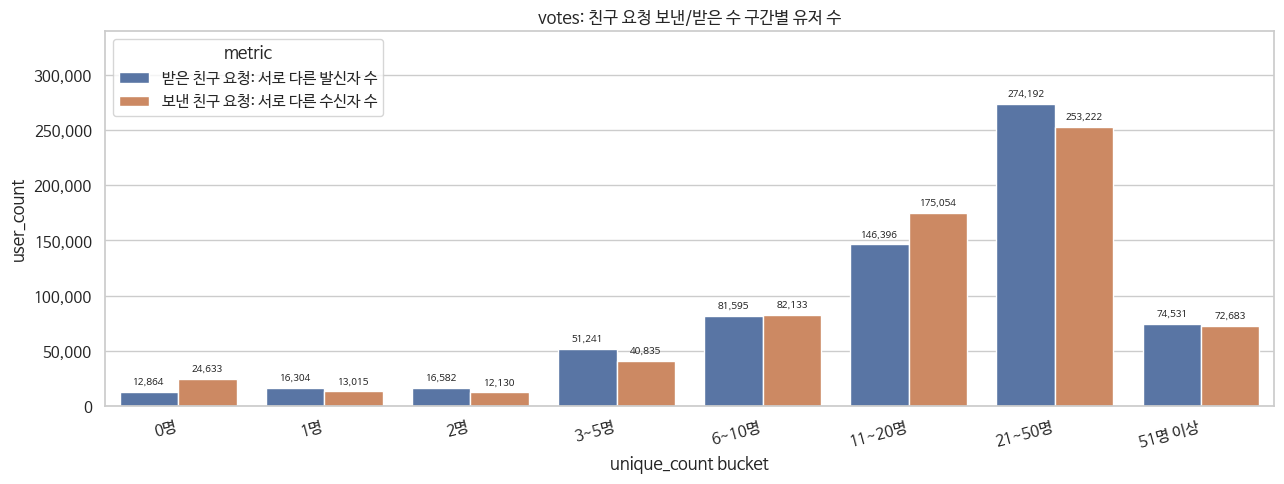

saved table preview: /content/votes_hackle_outputs/tables/17_친구_요청_구간별_요약.csv


#### 친구 요청 구간별 요약

,metric,count_bucket,user_count,ratio_pct
0,받은 친구 요청: 서로 다른 발신자 수,0명,12864,1.91
1,받은 친구 요청: 서로 다른 발신자 수,1명,16304,2.42
2,받은 친구 요청: 서로 다른 발신자 수,2명,16582,2.46
3,받은 친구 요청: 서로 다른 발신자 수,3~5명,51241,7.61
4,받은 친구 요청: 서로 다른 발신자 수,6~10명,81595,12.11
5,받은 친구 요청: 서로 다른 발신자 수,11~20명,146396,21.73
6,받은 친구 요청: 서로 다른 발신자 수,21~50명,274192,40.70
7,받은 친구 요청: 서로 다른 발신자 수,51명 이상,74531,11.06
8,보낸 친구 요청: 서로 다른 수신자 수,0명,24633,3.66
9,보낸 친구 요청: 서로 다른 수신자 수,1명,13015,1.93


saved table preview: /content/votes_hackle_outputs/tables/18_친구_요청_분포_요약.csv


#### 친구 요청 분포 요약

,metric,mean,median,max
0,받은 친구 요청: 서로 다른 발신자 수,25.290348,21.0,218.0
1,보낸 친구 요청: 서로 다른 수신자 수,25.290348,20.0,1549.0


### 추천/공유 2: hackle session 기준 초대/공유 이벤트
- **조건**: session_id별 click_invite_friend, click_friend_invite, click_question_share 발생 횟수
- **의미**: 세션 단위로 친구 초대/질문 공유 행동이 얼마나 발생하는지 봅니다.

saved figure: /content/votes_hackle_outputs/figures/18_share_hackle_event_total.png


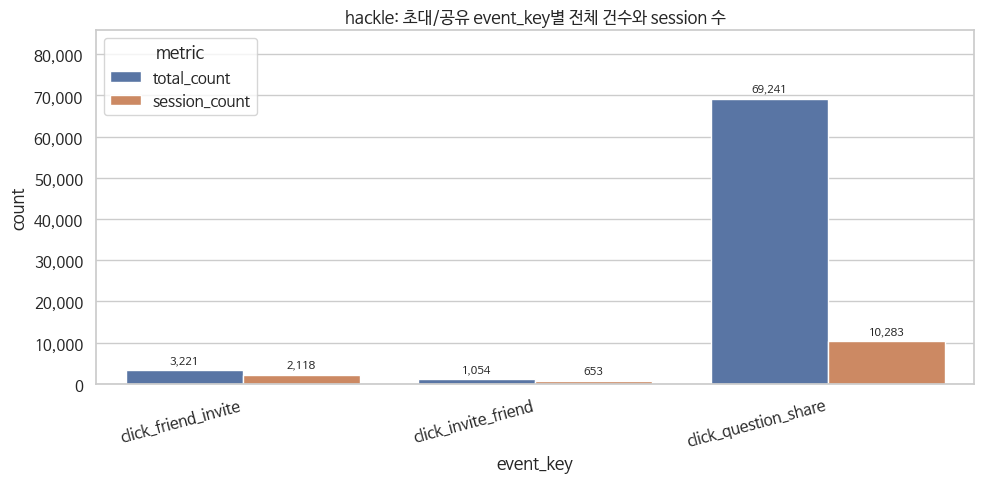

saved table preview: /content/votes_hackle_outputs/tables/19_hackle_초대_공유_요약.csv


#### hackle 초대/공유 요약

,event_key,total_count,session_count
0,click_friend_invite,3221,2118
1,click_invite_friend,1054,653
2,click_question_share,69241,10283


saved figure: /content/votes_hackle_outputs/figures/19_share_hackle_distribution.png


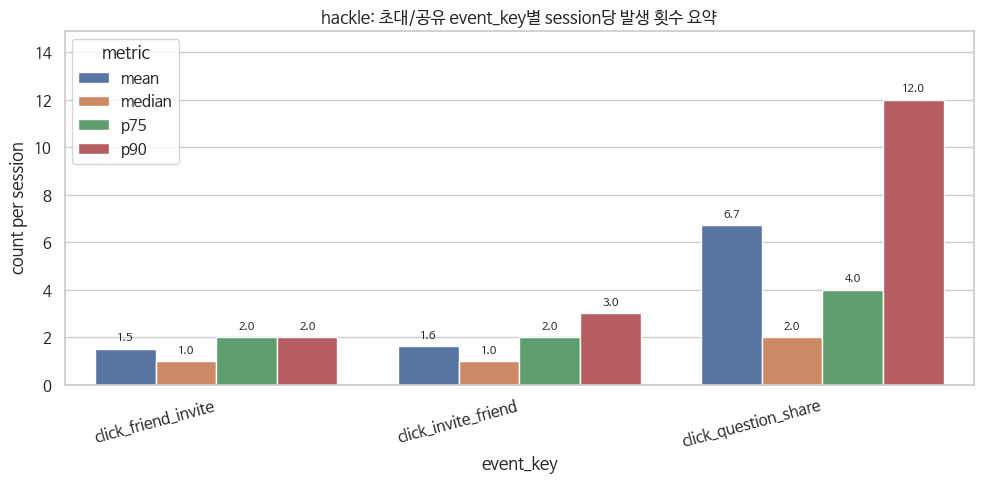

saved table preview: /content/votes_hackle_outputs/tables/20_hackle_초대_공유_session_분포_요약.csv


#### hackle 초대/공유 session 분포 요약

,event_key,count,mean,median,p75,p90,max
0,click_friend_invite,2118,1.520774,1.0,2.0,2.0,47
1,click_invite_friend,653,1.614089,1.0,2.0,3.0,42
2,click_question_share,10283,6.733541,2.0,4.0,12.0,436


In [ ]:
note(
    "추천/공유 1: votes 친구 요청",
    "accounts_friendrequest에서 send_user_id별 서로 다른 receive_user_id 수와 receive_user_id별 서로 다른 send_user_id 수를 비교",
    "친구 요청을 많이 보낸 유저와 많이 받은 유저의 분포를 봅니다.",
)
friend_compare = pd.concat(
    [
        friend_user_agg[["user_id", "friend_sent_unique_receivers"]]
        .rename(columns={"friend_sent_unique_receivers": "unique_count"})
        .assign(metric="보낸 친구 요청: 서로 다른 수신자 수"),
        friend_user_agg[["user_id", "friend_received_unique_senders"]]
        .rename(columns={"friend_received_unique_senders": "unique_count"})
        .assign(metric="받은 친구 요청: 서로 다른 발신자 수"),
    ],
    ignore_index=True,
)
friend_compare["unique_count"] = pd.to_numeric(friend_compare["unique_count"], errors="coerce").fillna(0)
friend_compare["count_bucket"] = pd.cut(
    friend_compare["unique_count"],
    bins=[-0.1, 0, 1, 2, 5, 10, 20, 50, np.inf],
    labels=["0명", "1명", "2명", "3~5명", "6~10명", "11~20명", "21~50명", "51명 이상"],
)
friend_bucket = friend_compare.groupby(["metric", "count_bucket"], observed=False, as_index=False).size().rename(columns={"size": "user_count"})
friend_bucket["ratio_pct"] = (friend_bucket["user_count"] / friend_bucket.groupby("metric")["user_count"].transform("sum") * 100).round(2)
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=friend_bucket, x="count_bucket", y="user_count", hue="metric", ax=ax)
add_bar_labels(ax, fontsize=7)
pad_y_axis(ax)
ax.set_title("votes: 친구 요청 보낸/받은 수 구간별 유저 수")
ax.set_xlabel("unique_count bucket")
ax.set_ylabel("user_count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("votes: 친구 요청 보낸/받은 수 구간별 유저 수", "share_friend_request_bucket")
show_table(friend_bucket, "친구 요청 구간별 요약")
show_table(friend_compare.groupby("metric", as_index=False).agg(mean=("unique_count", "mean"), median=("unique_count", "median"), max=("unique_count", "max")), "친구 요청 분포 요약")

note(
    "추천/공유 2: hackle session 기준 초대/공유 이벤트",
    "session_id별 click_invite_friend, click_friend_invite, click_question_share 발생 횟수",
    "세션 단위로 친구 초대/질문 공유 행동이 얼마나 발생하는지 봅니다.",
)
share_session = event_session[event_session["event_key"].isin(SHARE_EVENT_KEYS)].copy()
share_total = share_session.groupby("event_key", as_index=False).agg(total_count=("event_count", "sum"), session_count=("session_id", "nunique"))
share_total_long = share_total.melt(id_vars="event_key", value_vars=["total_count", "session_count"], var_name="metric", value_name="value")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=share_total_long, x="event_key", y="value", hue="metric", ax=ax)
add_bar_labels(ax)
pad_y_axis(ax)
ax.set_title("hackle: 초대/공유 event_key별 전체 건수와 session 수")
ax.set_xlabel("event_key")
ax.set_ylabel("count")
format_count_axis(ax)
rotate_xticks(ax, 15)
save_mpl_fig("hackle: 초대/공유 event_key별 전체 건수와 session 수", "share_hackle_event_total")
show_table(share_total, "hackle 초대/공유 요약")

share_distribution = distribution_summary(share_session, "event_count", "event_key")
share_distribution_long = share_distribution.melt(
    id_vars="event_key",
    value_vars=["mean", "median", "p75", "p90"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=share_distribution_long, x="event_key", y="value", hue="metric", ax=ax)
add_bar_labels(ax, decimals=1, fontsize=8)
pad_y_axis(ax)
ax.set_title("hackle: 초대/공유 event_key별 session당 발생 횟수 요약")
ax.set_xlabel("event_key")
ax.set_ylabel("count per session")
rotate_xticks(ax, 15)
save_mpl_fig("hackle: 초대/공유 event_key별 session당 발생 횟수 요약", "share_hackle_distribution")
show_table(share_distribution, "hackle 초대/공유 session 분포 요약")

# ## 셀 1-15. GitHub 공유용 결과 묶기

In [ ]:
# raw CSV는 포함하지 않습니다.
# GitHub에는 이 셀에서 만들어지는 `github_share` 폴더 또는 zip과 코드 파일을 올리면 됩니다.

# %%
SHARE_DIR = OUT_DIR / "github_share"
if SHARE_DIR.exists():
    shutil.rmtree(SHARE_DIR)
SHARE_DIR.mkdir(parents=True, exist_ok=True)

share_files = []
for source_dir in [FIG_DIR, TABLE_DIR]:
    for source_path in sorted(source_dir.glob("*")):
        if source_path.is_file():
            target_path = SHARE_DIR / source_dir.name / source_path.name
            target_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(source_path, target_path)
            share_files.append(target_path)

summary_csv_names = [
    "votes_attendance_daily.csv",
    "votes_payment_daily.csv",
    "votes_product_summary.csv",
    "votes_question_daily.csv",
    "votes_friend_daily.csv",
    "hackle_daily.csv",
]
for filename in summary_csv_names:
    source_path = OUT_DIR / filename
    if source_path.exists():
        target_path = SHARE_DIR / "summary_csv" / filename
        target_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source_path, target_path)
        share_files.append(target_path)

manifest_path = SHARE_DIR / "README_results.md"
with open(manifest_path, "w", encoding="utf-8") as f:
    f.write("# Votes + Hackle visualization results\n\n")
    f.write("이 폴더는 Colab에서 생성한 공유용 결과물입니다. 원본 raw CSV는 포함하지 않았습니다.\n\n")
    f.write("## Analysis Notes\n")
    if NOTES_FOR_README:
        for i, item in enumerate(NOTES_FOR_README, start=1):
            f.write(f"### {i}. {item['title']}\n")
            f.write(f"- 조건: {item['condition']}\n")
            f.write(f"- 의미: {item['meaning']}\n\n")
    else:
        f.write("- 저장된 note가 없습니다. 셀 08~14를 실행한 뒤 셀 15를 다시 실행하세요.\n\n")
    f.write("## Figures\n")
    for path in sorted((SHARE_DIR / "figures").glob("*")):
        f.write(f"- `figures/{path.name}`\n")
    f.write("\n## Table previews\n")
    for path in sorted((SHARE_DIR / "tables").glob("*.csv")):
        f.write(f"- `tables/{path.name}`\n")
    f.write("\n## Summary CSV\n")
    for path in sorted((SHARE_DIR / "summary_csv").glob("*.csv")):
        f.write(f"- `summary_csv/{path.name}`\n")

zip_path = shutil.make_archive(str(OUT_DIR / "github_share"), "zip", SHARE_DIR)

print("GitHub 공유용 폴더:", SHARE_DIR)
print("GitHub 공유용 zip:", zip_path)
print("그래프 PNG 수:", len(list((SHARE_DIR / "figures").glob("*.png"))))
print("표 preview CSV 수:", len(list((SHARE_DIR / "tables").glob("*.csv"))))
print("요약 CSV 수:", len(list((SHARE_DIR / "summary_csv").glob("*.csv"))))

GitHub 공유용 폴더: /content/votes_hackle_outputs/github_share
GitHub 공유용 zip: /content/votes_hackle_outputs/github_share.zip
그래프 PNG 수: 19
표 preview CSV 수: 20
요약 CSV 수: 6


# ## 셀 1-16. GitHub branch에 commit/push

In [ ]:
# from google.colab import userdata
# from pathlib import Path
# import os

# token = userdata.get("GITHUB_TOKEN")
# if not token:
#     raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN을 먼저 저장하세요.")

# Path("/root/.netrc").write_text(
#     f"machine github.com\nlogin x-access-token\npassword {token}\n"
# )
# os.chmod("/root/.netrc", 0o600)

# %cd /content
# !rm -rf main_repo
# !git clone https://github.com/codeit-DA12-final3/main_repo.git
# %cd /content/main_repo
# !git fetch origin
# !git switch -c feature/suhyun-analysis --track origin/feature/suhyun-analysis

/content
Cloning into 'main_repo'...
remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 86 (delta 8), reused 80 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (86/86), 2.55 MiB | 11.14 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/main_repo
Branch 'feature/suhyun-analysis' set up to track remote branch 'feature/suhyun-analysis' from 'origin'.
Switched to a new branch 'feature/suhyun-analysis'


In [ ]:
# 전제:
# - Colab에서 `main_repo`를 clone했고, 현재 작업 branch로 switch 되어 있어야 합니다.
# - GitHub PAT는 Colab Secrets/Userdata에 `GITHUB_TOKEN` 이름으로 저장하세요.
# - raw CSV는 올리지 않고, 셀 15에서 만든 `github_share` 결과물과 현재 노트북/코드만 올립니다.

# %%
from google.colab import userdata
import subprocess

REPO_DIR = Path("/content/main_repo")
BRANCH_NAME = "feature/suhyun-analysis"  # 본인 branch 이름으로 수정 가능
GITHUB_REPO = "codeit-DA12-final3/main_repo"
GIT_USER_NAME = "sabrenyaa"
GIT_USER_EMAIL = "sabrenyaa@users.noreply.github.com"
COMMIT_MESSAGE = "Add votes and hackle visualization results"

if not REPO_DIR.exists():
    raise FileNotFoundError("REPO_DIR이 없습니다. 먼저 GitHub repo를 clone 했는지 확인하세요.")
if not SHARE_DIR.exists():
    raise FileNotFoundError("SHARE_DIR이 없습니다. 먼저 셀 15를 실행해서 GitHub 공유용 결과를 만들어주세요.")

token = userdata.get("GITHUB_TOKEN")
if not token:
    raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN을 먼저 저장하세요.")

def run_git(args, check=True):
    result = subprocess.run(
        args,
        cwd=REPO_DIR,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        safe_stderr = result.stderr.replace(token, "***TOKEN***")
        print(safe_stderr)
    if check and result.returncode != 0:
        raise RuntimeError(f"명령 실패: {' '.join(args)}")
    return result

target_dir = REPO_DIR / "analysis" / "suhyun_votes_hackle"
if target_dir.exists():
    shutil.rmtree(target_dir)
target_dir.mkdir(parents=True, exist_ok=True)

shutil.copytree(SHARE_DIR, target_dir / "github_share", dirs_exist_ok=True)

# 현재 Colab 노트북 파일명은 환경마다 다를 수 있어 결과 README를 중심으로 공유합니다.
# 별도 .ipynb를 repo에 넣고 싶으면 아래 NOTEBOOK_PATH를 본인 파일 경로로 수정하세요.
NOTEBOOK_PATH = None
if NOTEBOOK_PATH:
    notebook_path = Path(NOTEBOOK_PATH)
    if notebook_path.exists():
        shutil.copy2(notebook_path, target_dir / notebook_path.name)

run_git(["git", "config", "user.name", GIT_USER_NAME])
run_git(["git", "config", "user.email", GIT_USER_EMAIL])
switch_result = run_git(["git", "switch", BRANCH_NAME], check=False)
if switch_result.returncode != 0:
    run_git(["git", "switch", "-c", BRANCH_NAME])
run_git(["git", "remote", "set-url", "origin", f"https://{token}@github.com/{GITHUB_REPO}.git"])

run_git(["git", "add", str(target_dir.relative_to(REPO_DIR))])
status = run_git(["git", "status", "--short"], check=False)

if not status.stdout.strip():
    print("커밋할 변경사항이 없습니다.")
else:
    run_git(["git", "commit", "-m", COMMIT_MESSAGE])
    run_git(["git", "push", "origin", BRANCH_NAME])
    print(f"push 완료: {GITHUB_REPO} / {BRANCH_NAME}")

Your branch is up to date with 'origin/feature/suhyun-analysis'.

Already on 'feature/suhyun-analysis'

A  analysis/suhyun_votes_hackle/github_share/README_results.md
A  analysis/suhyun_votes_hackle/github_share/figures/01_votes_attendance_daily.png
A  analysis/suhyun_votes_hackle/github_share/figures/02_votes_payment_daily.png
A  analysis/suhyun_votes_hackle/github_share/figures/03_votes_question_daily.png
A  analysis/suhyun_votes_hackle/github_share/figures/04_hackle_daily.png
A  analysis/suhyun_votes_hackle/github_share/figures/05_revisit_votes_attendance.png
A  analysis/suhyun_votes_hackle/github_share/figures/06_revisit_hackle_session_day.png
A  analysis/suhyun_votes_hackle/github_share/figures/07_payment_paid_unpaid.png
A  analysis/suhyun_votes_hackle/github_share/figures/08_payment_product_distribution.png
A  analysis/suhyun_votes_hackle/github_share/figures/09_notice_event_distribution.png
A  analysis/suhyun_votes_hackle/github_share/figures/10_notice_event_total.png
A  analysi

In [ ]:
from pathlib import Path
import shutil
import subprocess
from google.colab import userdata

REPO_DIR = Path("/content/main_repo")
BRANCH_NAME = "feature/suhyun-analysis"
GITHUB_REPO = "codeit-DA12-final3/main_repo"

# 본인 노트북 경로로 수정
NOTEBOOK_PATH = "/content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/Final_KimSuHyun.ipynb"

target_dir = REPO_DIR / "analysis" / "suhyun_votes_hackle"
target_dir.mkdir(parents=True, exist_ok=True)

notebook_path = Path(NOTEBOOK_PATH)
if not notebook_path.exists():
    raise FileNotFoundError(f"노트북 파일을 찾을 수 없습니다: {notebook_path}")

shutil.copy2(notebook_path, target_dir / notebook_path.name)

token = userdata.get("GITHUB_TOKEN")
if not token:
    raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN을 먼저 저장하세요.")

def run_git(args, check=True):
    result = subprocess.run(args, cwd=REPO_DIR, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr.replace(token, "***TOKEN***"))
    if check and result.returncode != 0:
        raise RuntimeError(f"명령 실패: {' '.join(args)}")
    return result

run_git(["git", "remote", "set-url", "origin", f"https://{token}@github.com/{GITHUB_REPO}.git"])
run_git(["git", "add", str((target_dir / notebook_path.name).relative_to(REPO_DIR))])

status = run_git(["git", "status", "--short"], check=False)

if not status.stdout.strip():
    print("추가로 커밋할 변경사항이 없습니다.")
else:
    run_git(["git", "commit", "-m", "Add analysis notebook"])
    run_git(["git", "push", "origin", BRANCH_NAME])
    print(f"노트북 push 완료: {GITHUB_REPO} / {BRANCH_NAME}")


A  analysis/suhyun_votes_hackle/Final_KimSuHyun.ipynb

[feature/suhyun-analysis ce53760] Add analysis notebook
 1 file changed, 1 insertion(+)
 create mode 100644 analysis/suhyun_votes_hackle/Final_KimSuHyun.ipynb

To https://github.com/codeit-DA12-final3/main_repo.git
   94404ac..ce53760  feature/suhyun-analysis -> feature/suhyun-analysis

노트북 push 완료: codeit-DA12-final3/main_repo / feature/suhyun-analysis


# ## 셀2-1. 환경설정

In [ ]:
import shutil
from pathlib import Path

shutil.rmtree(Path("/content/sender_behavior_axis_outputs"), ignore_errors=True)

In [ ]:
import ast
import os
import re
import shutil
import subprocess
import sys
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from IPython.display import Markdown, display
from matplotlib import font_manager
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [ ]:
RUN_COLAB_SETUP = True
MOUNT_GOOGLE_DRIVE = True
INSTALL_KOREAN_FONT = True
SETUP_GITHUB_REPO = False

GITHUB_REPO = "codeit-DA12-final3/main_repo"
BRANCH_NAME = "feature/suhyun-analysis"
REPO_DIR = Path("/content/main_repo")


def running_in_colab():
    return "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ


if RUN_COLAB_SETUP and running_in_colab():
    if MOUNT_GOOGLE_DRIVE:
        try:
            from google.colab import drive

            drive.mount("/content/drive", force_remount=False)
        except Exception as e:
            print(f"[WARN] Google Drive mount skipped or failed: {e}")

    nanum_font_path = Path("/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf")
    if INSTALL_KOREAN_FONT and not nanum_font_path.exists():
        print("나눔 한글 폰트를 설치합니다...")
        subprocess.run("apt-get update -qq", shell=True, check=False)
        subprocess.run("apt-get install -y fonts-nanum fonts-nanum-extra -qq", shell=True, check=False)
        subprocess.run("fc-cache -fv", shell=True, check=False)
        shutil.rmtree(Path.home() / ".cache" / "matplotlib", ignore_errors=True)

    if nanum_font_path.exists():
        font_manager.fontManager.addfont(str(nanum_font_path))
        font_name = font_manager.FontProperties(fname=str(nanum_font_path)).get_name()
        plt.rc("font", family=font_name)
        plt.rcParams["axes.unicode_minus"] = False

    if SETUP_GITHUB_REPO:
        try:
            from google.colab import userdata

            token = userdata.get("GITHUB_TOKEN")
            if not token:
                raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN이 없습니다.")

            Path("/root/.netrc").write_text(
                f"machine github.com\nlogin x-access-token\npassword {token}\n",
                encoding="utf-8",
            )
            os.chmod("/root/.netrc", 0o600)
            os.chdir("/content")

            if REPO_DIR.exists():
                shutil.rmtree(REPO_DIR)
            subprocess.run(["git", "clone", f"https://github.com/{GITHUB_REPO}.git", str(REPO_DIR)], check=True)
            subprocess.run(["git", "switch", "-c", BRANCH_NAME], cwd=REPO_DIR, check=True)
            print(f"GitHub 저장소 준비 완료: {REPO_DIR} / {BRANCH_NAME}")
        except Exception as e:
            print(f"[WARN] GitHub repo setup skipped or failed: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data")
if not (DATA_DIR / "accounts_user_master.csv").exists():
    raise FileNotFoundError(
        f"DATA_DIR에서 accounts_user_master.csv를 찾지 못했습니다: {DATA_DIR}\n"
        "Google Drive mount와 데이터 폴더 경로를 확인하세요."
    )
print("데이터 경로 =", DATA_DIR)

OUT_DIR = Path("/content/sender_behavior_axis_outputs")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
PROCESSED_DIR = OUT_DIR / "processed"

for path in [OUT_DIR, FIG_DIR, TABLE_DIR, PROCESSED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

CHUNKSIZE = 1_000_000
RANDOM_STATE = 42
MAX_SENDER_CLUSTER_K = 8
SELECTED_SENDER_K = 3  # 현재 결과는 elbow와 해석 가능성을 우선해 k=3을 보고용 기본값으로 사용합니다. 4로 바꿔 민감도 확인 가능.
MIN_SENDER_CLUSTER_SHARE = 0.0005  # 자동 선택 시 최소 군집 비율 0.05% 미만 k는 제외합니다.
SILHOUETTE_SAMPLE_SIZE = 20_000  # silhouette 계산 속도를 위해 층화 표본으로 계산합니다.
AUTO_NAME_SENDER_CLUSTERS = True
# k-means의 numeric cluster id는 실행 환경/데이터 상태에 따라 의미가 바뀔 수 있습니다.
# 기본은 원변수 프로파일을 보고 자동 군집명을 붙이고, 직접 고정하고 싶을 때만 아래 dict에 입력합니다.
SENDER_CLUSTER_NAME_MAP = {}

WINDOWS = {
    "d0": (0, 0),
    "d0_1": (0, 1),
    "d0_3": (0, 3),
    "d0_7": (0, 7),
    "d0_14": (0, 14),
    "d0_28": (0, 28),
    "d1_28": (1, 28),
    "d8_14": (8, 14),
    "d8_28": (8, 28),
}

FILES = {
    "users": DATA_DIR / "accounts_user_master.csv",
    "groups": DATA_DIR / "accounts_group_raw.csv",
    "user_properties": DATA_DIR / "user_properties_raw.csv",
    "attendance_long": DATA_DIR / "accounts_attendance_long.csv",
    "payment": DATA_DIR / "accounts_paymenthistory_raw.csv",
    "question_record": DATA_DIR / "accounts_userquestionrecord_raw.csv",
    "friend_request": DATA_DIR / "accounts_friendrequest_raw.csv",
    "point_history": DATA_DIR / "accounts_pointhistory_raw.csv",
    "hackle_properties": DATA_DIR / "hackle_properties_raw.csv",
    "hackle_events": DATA_DIR / "hackle_events_raw.csv",
}

RUN_HACKLE_SUPPLEMENT = True
RUN_GITHUB_PUSH = True
DROP_STATISTICAL_EXTREME_OUTLIERS = False
STATISTICAL_EXTREME_MAX_TO_P99_RATIO = 10
STATISTICAL_EXTREME_MAX_ABOVE_P99_COUNT = 5

데이터 경로 = /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data


In [ ]:
HACKLE_QUESTION_START_KEYS = [
    "click_question_open",
    "view_questions_tap",
    "click_bottom_navigation_questions",
]
HACKLE_QUESTION_COMPLETE_KEYS = [
    "complete_question",
    "click_question_complete",
    "submit_question",
    "complete_vote",
    "click_vote_complete",
]
HACKLE_QUESTION_SKIP_KEYS = ["skip_question"]

sns.set_theme(style="whitegrid")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_fonts = ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]
selected_font = next((font for font in preferred_fonts if font in available_fonts), None)
if selected_font:
    plt.rcParams["font.family"] = selected_font
else:
    print("한글 폰트를 찾지 못했습니다. 그래프 한글이 깨지면 NanumGothic 설치 후 다시 실행하세요.")
plt.rcParams["axes.unicode_minus"] = False

SENDER_GROUP_ORDER = ["보낸 투표 경험 무", "보낸 투표 경험 유"]
SENT_VOTE_INTENSITY_ORDER = ["0회", "1-3회", "4-10회", "11-50회", "51회 이상"]
SENDER_GROUP_PALETTE = {
    "보낸 투표 경험 무": "#8D99A6",
    "보낸 투표 경험 유": "#2F80ED",
}
MAIN_COLOR = "#2F80ED"
ACCENT_COLOR = "#00A389"
SECONDARY_COLOR = "#F2994A"
WINDOW_ORDER = ["D0", "D0-D1", "D0-D3", "D0-D7", "D0-D14", "D0-D28"]

LABEL_MAP = {
    "retention_d1_28_rate": "재방문율\nD1-D28",
    "retention_d8_28_rate": "재방문율\nD8-D28",
    "payment_d0_28_rate": "결제율\nD0-D28",
    "payment_d8_28_rate": "결제율\nD8-D28",
    "payment_d0_28_count_mean": "전체 평균 결제 빈도\nD0-D28",
    "payment_d8_28_count_mean": "전체 평균 결제 빈도\nD8-D28",
    "payment_d0_28_count_paid_user_mean": "결제자 평균 결제 빈도\nD0-D28",
    "payment_d8_28_count_paid_user_mean": "결제자 평균 결제 빈도\nD8-D28",
    "payment_d0_28_count_sum": "총 결제 횟수\nD0-D28",
    "payment_d8_28_count_sum": "총 결제 횟수\nD8-D28",
    "payment_d0_28_amount_mean": "전체 평균 추정 구매 하트 수\nD0-D28",
    "payment_d8_28_amount_mean": "전체 평균 추정 구매 하트 수\nD8-D28",
    "payment_d0_28_amount_paid_user_mean": "결제자 평균 추정 구매 하트 수\nD0-D28",
    "payment_d8_28_amount_paid_user_mean": "결제자 평균 추정 구매 하트 수\nD8-D28",
    "payment_d0_28_amount_sum": "총 추정 구매 하트 수\nD0-D28",
    "payment_d8_28_amount_sum": "총 추정 구매 하트 수\nD8-D28",
    "payment_d0_28_paid_user_count": "결제 유저 수\nD0-D28",
    "payment_d8_28_paid_user_count": "결제 유저 수\nD8-D28",
    "active_days_d0_28_mean": "전체 평균 활동일수\nD0-D28",
    "active_days_d8_28_mean": "전체 평균 활동일수\nD8-D28",
    "active_days_d0_28_active_user_mean": "활동 유저 평균 활동일수\nD0-D28",
    "active_days_d8_28_active_user_mean": "활동 유저 평균 활동일수\nD8-D28",
    "active_days_d0_28_active_user_count": "활동 유저 수\nD0-D28",
    "active_days_d8_28_active_user_count": "활동 유저 수\nD8-D28",
    "active_days_d0_28_sum": "총 활동일수\nD0-D28",
    "active_days_d8_28_sum": "총 활동일수\nD8-D28",
    "active_days_excl_sent_vote_d0_28_mean": "평균 활동일수\nD0-D28\n(보낸 투표 제외)",
    "active_days_excl_sent_vote_d8_28_mean": "평균 활동일수\nD8-D28\n(보낸 투표 제외)",
    "active_days_excl_sent_vote_d0_28_active_user_mean": "활동 유저 평균 활동일수\nD0-D28\n(보낸 투표 제외)",
    "active_days_excl_sent_vote_d8_28_active_user_mean": "활동 유저 평균 활동일수\nD8-D28\n(보낸 투표 제외)",
    "sent_vote_removed_gap_d0_28": "보낸 투표 포함 효과\nD0-D28",
    "sent_vote_removed_gap_d8_28": "보낸 투표 포함 효과\nD8-D28",
    "sent_vote_count_d0": "보낸 투표 수\nD0",
    "sent_vote_count_d0_3": "보낸 투표 수\nD0-D3",
    "sent_vote_count_d0_7": "보낸 투표 수\nD0-D7",
    "sent_vote_count_d0_3_mean": "전체 평균 보낸 투표 수\nD0-D3",
    "sent_vote_count_d0_7_mean": "전체 평균 보낸 투표 수\nD0-D7",
    "sent_vote_count_d0_3_sender_mean": "발신 유저 평균 보낸 투표 수\nD0-D3",
    "sent_vote_count_d0_7_sender_mean": "발신 유저 평균 보낸 투표 수\nD0-D7",
    "sent_vote_user_count_d0_3": "발신 유저 수\nD0-D3",
    "sent_vote_user_count_d0_7": "발신 유저 수\nD0-D7",
    "sent_vote_count_d0_3_sum": "총 보낸 투표 수\nD0-D3",
    "sent_vote_count_d0_7_sum": "총 보낸 투표 수\nD0-D7",
    "sent_vote_complete_count_d0_7": "완료된 보낸 투표 수\nD0-D7",
    "sent_vote_active_days_d0_7": "보낸 투표 활동일수\nD0-D7",
    "sent_vote_distinct_chosen_users_d0_7": "선택한 고유 유저 수\nD0-D7",
    "sent_vote_distinct_questions_d0_7": "투표한 고유 질문 수\nD0-D7",
    "hackle_question_start_count_d0_7": "Hackle 질문 시작 수\nD0-D7",
    "hackle_question_complete_count_d0_7": "Hackle 질문 완료 수\nD0-D7",
    "hackle_question_skip_count_d0_7": "Hackle 질문 스킵 수\nD0-D7",
    "hackle_question_completion_rate_d0_7": "Hackle 질문 완료율\nD0-D7",
    "hackle_question_skip_rate_d0_7": "Hackle 질문 스킵률\nD0-D7",
    "received_vote_read_count_d0_7": "받은 투표 열람 수\nD0-D7",
    "friend_count": "친구 수",
    "same_school_joined_user_count": "동일 학교 가입자 수",
    "retention_d1_28": "재방문 여부\nD1-D28",
    "retention_d8_28": "재방문 여부\nD8-D28",
    "paid_flag_d0_28": "결제 여부\nD0-D28",
    "paid_flag_d8_28": "결제 여부\nD8-D28",
    "payment_amount_d0_28": "추정 구매 하트 수\nD0-D28",
    "payment_amount_d8_28": "추정 구매 하트 수\nD8-D28",
    "active_days_d0_28": "활동일수\nD0-D28",
    "active_days_d8_28": "활동일수\nD8-D28",
}

for name, path in FILES.items():
    print(f"{name:18s}", "OK" if path.exists() else "누락", path)

users              OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_user_master.csv
groups             OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_group_raw.csv
user_properties    OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/user_properties_raw.csv
attendance_long    OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_attendance_long.csv
payment            OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_paymenthistory_raw.csv
question_record    OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_userquestionrecord_raw.csv
friend_request     OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_friendrequest_raw.csv
point_history      OK /content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data/accounts_pointhistory_raw.csv
hackle_properties  OK /con

# ## 셀2-2. 공통 함수

In [ ]:
_FIG_NO = 0
_TABLE_NO = 0
DUPLICATE_AUDIT_ROWS = []
ANALYSIS_NOTES = []

FIGURE_CAPTIONS = {
    "eda_population_funnel": "모집단 축소 과정입니다. 전체 유저에서 가입일이 있는 유저, 홈화면 진입 조건 충족 유저로 분석 대상을 좁힙니다.",
    "eda_sender_group_size": "메인 모집단 안에서 D0-D7 보낸 투표 경험 유/무 그룹의 유저 수를 비교합니다.",
    "eda_outcome_rates_by_sender_group": "발신 투표 경험 유/무에 따라 기본/보조 재방문율과 결제율이 어떻게 다른지 비교합니다.",
    "eda_payment_count_mean_by_sender_group": "발신 투표 경험 유/무별 결제 빈도 평균입니다. 전체 유저 기준과 결제자 기준을 분리해 봅니다.",
    "eda_payment_amount_mean_by_sender_group": "발신 투표 경험 유/무별 평균 추정 구매 하트 수입니다. 결제율뿐 아니라 구매 규모 차이도 함께 확인합니다.",
    "eda_active_days_mean_by_sender_group": "발신 투표 경험 유/무별 평균 누적 활동일수입니다. 전체 유저 기준과 활동 유저 기준을 함께 봅니다.",
    "eda_active_days_boxplot": "발신 투표 경험 유/무별 D0-D28 누적 활동일수 분포입니다. 극단값 영향 완화를 위해 p99 winsorized 값을 사용합니다.",
    "eda_sent_vote_window_rate": "관찰 기간을 넓힐수록 보낸 투표 경험 유저 비율이 어떻게 변하는지 확인합니다.",
    "eda_sent_vote_count_distribution": "D0-D7 보낸 투표 수 분포입니다. 그룹 내 발신 행동 강도의 편차를 확인합니다.",
    "eda_correlation_heatmap": "발신 행동, 일부 보조 변수, 결과 지표 간 상관을 탐색적으로 확인합니다. 인과 해석용이 아닙니다.",
    "sender_cluster_k_selection": "발신 행동 단독 클러스터링에서 k 후보별 군집 내 제곱합, 실루엣 점수, 최소 군집 비율을 비교합니다.",
    "sender_cluster_pca_2d": "발신 행동 단독 클러스터를 주성분 분석(PCA) 2차원에 투영한 그림입니다. 군집 분리 정도를 시각적으로 확인합니다.",
    "sender_cluster_profile_bar": "발신 행동 세그먼트별 표준화된 입력 변수 평균입니다. 각 군집의 발신 행동 특징을 해석합니다.",
    "sender_cluster_outcome_rates": "발신 행동 세그먼트별 재방문율과 결제율을 비교합니다.",
    "sender_cluster_payment_count": "발신 행동 세그먼트별 결제 빈도 평균입니다. 전체 유저 기준과 결제자 기준을 분리해 봅니다.",
    "sender_cluster_payment_amount": "발신 행동 세그먼트별 평균 추정 구매 하트 수입니다. 세그먼트별 구매 규모 차이를 확인합니다.",
    "sender_cluster_active_days": "발신 행동 세그먼트별 평균 누적 활동일수입니다. 전체 유저 기준과 활동 유저 기준을 함께 봅니다.",
    "active_days_excl_sent_vote_sender_group": "누적 활동일수에서 보낸 투표 발생일을 제외했을 때도 발신 경험 그룹의 활동일수 차이가 남는지 확인합니다.",
    "active_days_excl_sent_vote_sender_cluster": "발신 세그먼트별로 보낸 투표 제외 활동일수를 비교해, 활동일수 차이가 발신 행동 자체에 의해 부풀려졌는지 점검합니다.",
    "sent_vote_intensity_outcome_rates": "D0-D7 보낸 투표 수 강도 구간별 재방문율과 결제율입니다. 단순 경험 유/무보다 발신 강도에 따른 차이를 봅니다.",
    "sent_vote_intensity_payment_count": "D0-D7 보낸 투표 수 강도 구간별 결제 빈도 평균입니다. 전체 유저 기준과 결제자 기준을 분리해 봅니다.",
    "sent_vote_intensity_payment_amount": "D0-D7 보낸 투표 수 강도 구간별 평균 추정 구매 하트 수입니다. 발신 강도와 구매 규모의 관계를 확인합니다.",
    "sent_vote_intensity_active_days": "D0-D7 보낸 투표 수 강도 구간별 평균 활동일수입니다. 전체 유저 기준, 활동 유저 기준, 보낸 투표 제외 기준을 함께 비교합니다.",
}


def read_csv(path, **kwargs):
    return pd.read_csv(path, encoding="utf-8-sig", **kwargs)


def as_user_id(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64").astype("string")


def parse_list_len(value):
    if pd.isna(value):
        return 0
    if isinstance(value, list):
        return len(value)
    try:
        parsed = ast.literal_eval(str(value))
    except Exception:
        return 0
    return len(parsed) if isinstance(parsed, list) else 0


def clean_slug(value, fallback="output"):
    value = str(value or fallback)
    value = re.sub(r"[^\w가-힣]+", "_", value, flags=re.UNICODE).strip("_")
    return value[:90] or fallback


def remove_previous_outputs(directory, slug, suffix):
    for old_path in directory.glob(f"*_{slug}.{suffix}"):
        old_path.unlink(missing_ok=True)


def label_for(value):
    return LABEL_MAP.get(value, value)


def add_label_column(df, source_col="metric", target_col="metric_label"):
    df[target_col] = df[source_col].map(label_for)
    return df


def sender_group_categorical(series):
    return pd.Categorical(series, categories=SENDER_GROUP_ORDER, ordered=True)


def build_cluster_palette(labels):
    labels = list(labels)
    colors = sns.color_palette("Set2", n_colors=max(len(labels), 1))
    return dict(zip(labels, colors))


def sort_cluster_labels(labels):
    def cluster_sort_key(value):
        match = re.search(r"(\d+)$", str(value))
        return int(match.group(1)) if match else str(value)

    return sorted(pd.Series(labels).dropna().unique().tolist(), key=cluster_sort_key)


def order_sender_clusters_by_profile(cluster_profile):
    profile = cluster_profile.copy()
    sort_cols = [
        c
        for c in [
            "sent_vote_count_d0_7",
            "sent_vote_active_days_d0_7",
            "sent_vote_distinct_chosen_users_d0_7",
            "hackle_question_start_count_d0_7",
        ]
        if c in profile.columns
    ]
    if not sort_cols:
        sort_cols = ["sender_cluster"]
    profile = profile.sort_values(sort_cols + ["sender_cluster"], ascending=[True] * len(sort_cols) + [True])
    return [int(cluster_id) for cluster_id in profile["sender_cluster"].tolist()]


def build_sender_cluster_label_map(cluster_ids, custom_name_map=None):
    custom_name_map = custom_name_map or {}
    label_map = {}
    for cluster_id in cluster_ids:
        custom_name = custom_name_map.get(cluster_id, custom_name_map.get(str(cluster_id), ""))
        label_map[cluster_id] = str(custom_name).strip() if str(custom_name).strip() else f"군집 {cluster_id}"
    return label_map


def build_sender_cluster_profile_summary(row):
    sent_mean = float(row.get("sent_vote_count_d0_7", 0))
    active_mean = float(row.get("sent_vote_active_days_d0_7", 0))
    chosen_mean = float(row.get("sent_vote_distinct_chosen_users_d0_7", 0))
    return (
        f"D0-D7 평균 보낸 투표 {sent_mean:.2f}회, "
        f"발신 활동일 {active_mean:.2f}일, "
        f"선택 유저 {chosen_mean:.2f}명"
    )


def stratified_sample_indices(labels, max_size, random_state):
    labels = np.asarray(labels)
    n = len(labels)
    if max_size is None or max_size <= 0 or n <= max_size:
        return np.arange(n)

    rng = np.random.default_rng(random_state)
    unique_labels, counts = np.unique(labels, return_counts=True)
    quotas = np.floor(max_size * counts / n).astype(int)
    quotas = np.maximum(quotas, 1)
    quotas = np.minimum(quotas, counts)

    while quotas.sum() > max_size:
        reducible = np.where(quotas > 1)[0]
        if len(reducible) == 0:
            break
        idx = reducible[np.argmax(quotas[reducible])]
        quotas[idx] -= 1

    while quotas.sum() < max_size:
        expandable = np.where(quotas < counts)[0]
        if len(expandable) == 0:
            break
        idx = expandable[np.argmax(counts[expandable] - quotas[expandable])]
        quotas[idx] += 1

    sampled = []
    for label, quota in zip(unique_labels, quotas):
        label_idx = np.flatnonzero(labels == label)
        sampled.append(rng.choice(label_idx, size=int(quota), replace=False))
    return np.concatenate(sampled)


def cell_note(title, purpose, output):
    ANALYSIS_NOTES.append({"title": title, "purpose": purpose, "output": output})
    display(Markdown(f"### {title}\n- **목적**: {purpose}\n- **산출물**: {output}"))


def save_table(df, title, filename=None, n=20):
    global _TABLE_NO
    _TABLE_NO += 1
    slug = clean_slug(filename or title, f"table_{_TABLE_NO:02d}")
    remove_previous_outputs(TABLE_DIR, slug, "csv")
    path = TABLE_DIR / f"{_TABLE_NO:02d}_{slug}.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved table: {path}")
    display(Markdown(f"#### {title}"))
    display(df.head(n))
    return path


def save_processed(df, filename):
    path = PROCESSED_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved processed: {path}")
    return path


def save_fig(title, filename=None, fig=None, dpi=180, caption=None):
    global _FIG_NO
    _FIG_NO += 1
    slug = clean_slug(filename or title, f"figure_{_FIG_NO:02d}")
    remove_previous_outputs(FIG_DIR, slug, "png")
    path = FIG_DIR / f"{_FIG_NO:02d}_{slug}.png"
    fig = fig or plt.gcf()
    caption = caption if caption is not None else FIGURE_CAPTIONS.get(slug)
    if caption:
        wrapped_caption = "\n".join(textwrap.wrap(caption, width=105))
        fig.text(
            0.01,
            0.01,
            wrapped_caption,
            ha="left",
            va="bottom",
            fontsize=9,
            color="#333333",
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#DDDDDD", "boxstyle": "round,pad=0.35"},
        )
        fig.tight_layout(rect=[0, 0.09, 1, 1])
    else:
        fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved figure: {path}")
    plt.show()
    plt.close(fig)
    return path


def add_bar_labels(ax, decimals=1, suffix=""):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_height()
            if pd.isna(value):
                labels.append("")
            elif decimals == 0:
                labels.append(f"{value:,.0f}{suffix}")
            else:
                labels.append(f"{value:,.{decimals}f}{suffix}")
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)


def format_count_axis(ax, axis="y"):
    formatter = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
    if axis in ["y", "both"]:
        ax.yaxis.set_major_formatter(formatter)
    if axis in ["x", "both"]:
        ax.xaxis.set_major_formatter(formatter)


def format_decimal_axis(ax, axis="y", decimals=2):
    formatter = mticker.FuncFormatter(lambda x, pos: f"{x:,.{decimals}f}")
    if axis in ["y", "both"]:
        ax.yaxis.set_major_formatter(formatter)
    if axis in ["x", "both"]:
        ax.xaxis.set_major_formatter(formatter)


def add_paid_only_payment_means(summary):
    out = summary.copy()
    for window in ["d0_28", "d8_28"]:
        paid_user_count_col = f"payment_{window}_paid_user_count"
        if paid_user_count_col not in out.columns:
            continue
        denom = pd.to_numeric(out[paid_user_count_col], errors="coerce").replace(0, np.nan)

        count_sum_col = f"payment_{window}_count_sum"
        count_paid_mean_col = f"payment_{window}_count_paid_user_mean"
        if count_sum_col in out.columns:
            count_sum = pd.to_numeric(out[count_sum_col], errors="coerce").fillna(0)
            out[count_paid_mean_col] = (count_sum / denom).fillna(0)

        amount_sum_col = f"payment_{window}_amount_sum"
        amount_paid_mean_col = f"payment_{window}_amount_paid_user_mean"
        if globals().get("PAYMENT_AMOUNT_AVAILABLE", False) and amount_sum_col in out.columns:
            amount_sum = pd.to_numeric(out[amount_sum_col], errors="coerce").fillna(0)
            out[amount_paid_mean_col] = (amount_sum / denom).fillna(0)
    return out


def nonzero_count(series):
    return int((pd.to_numeric(series, errors="coerce").fillna(0) > 0).sum())


def add_nonzero_user_means(summary):
    out = summary.copy()
    denominator_pairs = [
        ("active_days_d0_28_sum", "active_days_d0_28_active_user_count", "active_days_d0_28_active_user_mean"),
        ("active_days_d8_28_sum", "active_days_d8_28_active_user_count", "active_days_d8_28_active_user_mean"),
        (
            "active_days_excl_sent_vote_d0_28_sum",
            "active_days_excl_sent_vote_d0_28_active_user_count",
            "active_days_excl_sent_vote_d0_28_active_user_mean",
        ),
        (
            "active_days_excl_sent_vote_d8_28_sum",
            "active_days_excl_sent_vote_d8_28_active_user_count",
            "active_days_excl_sent_vote_d8_28_active_user_mean",
        ),
        ("sent_vote_count_d0_3_sum", "sent_vote_user_count_d0_3", "sent_vote_count_d0_3_sender_mean"),
        ("sent_vote_count_d0_7_sum", "sent_vote_user_count_d0_7", "sent_vote_count_d0_7_sender_mean"),
        (
            "sent_vote_active_days_d0_7_sum",
            "sent_vote_user_count_d0_7",
            "sent_vote_active_days_d0_7_sender_mean",
        ),
        (
            "sent_vote_distinct_chosen_users_d0_7_sum",
            "sent_vote_user_count_d0_7",
            "sent_vote_distinct_chosen_users_d0_7_sender_mean",
        ),
    ]
    for numerator_col, denominator_col, output_col in denominator_pairs:
        if {numerator_col, denominator_col}.issubset(out.columns):
            numerator = pd.to_numeric(out[numerator_col], errors="coerce").fillna(0)
            denominator = pd.to_numeric(out[denominator_col], errors="coerce").replace(0, np.nan)
            out[output_col] = (numerator / denominator).fillna(0)
    return out


def add_adjusted_mean_columns(summary):
    return add_nonzero_user_means(add_paid_only_payment_means(summary))


def to_day(series):
    return pd.to_datetime(series, errors="coerce").dt.floor("D")


def add_signup_offset(df, user_col="user_id", date_col="event_date", users=None):
    lookup = users[["user_id", "signup_date"]].drop_duplicates()
    out = df.merge(lookup, left_on=user_col, right_on="user_id", how="left", suffixes=("", "_signup"))
    if user_col != "user_id":
        out = out.drop(columns=["user_id"]).rename(columns={user_col: "user_id"})
    out["day_offset"] = (out[date_col] - out["signup_date"]).dt.days
    return out


def window_mask(series, window_name):
    start, end = WINDOWS[window_name]
    return series.between(start, end, inclusive="both")


def summarize_boolean_window(df, id_col, offset_col, value_col=None, prefix="metric"):
    base = df[[id_col, offset_col]].copy()
    if value_col:
        base[value_col] = pd.to_numeric(df[value_col], errors="coerce").fillna(0)
    parts = []
    for name, _window in WINDOWS.items():
        m = window_mask(base[offset_col], name)
        if value_col:
            agg = base.loc[m].groupby(id_col, as_index=False).agg(**{f"{prefix}_sum_{name}": (value_col, "sum")})
        else:
            agg = base.loc[m].groupby(id_col, as_index=False).size().rename(columns={"size": f"{prefix}_count_{name}"})
        parts.append(agg)
    if not parts:
        return pd.DataFrame(columns=[id_col])
    out = parts[0]
    for part in parts[1:]:
        out = out.merge(part, on=id_col, how="outer")
    return out


def aggregate_user_window_counts(df, id_col, offset_col, date_col, prefix):
    rows = []
    for name in WINDOWS:
        m = window_mask(df[offset_col], name)
        part = (
            df.loc[m]
            .groupby(id_col, as_index=False)
            .agg(
                **{
                    f"{prefix}_count_{name}": (date_col, "size"),
                    f"{prefix}_active_days_{name}": (date_col, "nunique"),
                }
            )
        )
        rows.append(part)
    out = rows[0]
    for part in rows[1:]:
        out = out.merge(part, on=id_col, how="outer")
    return out


def compact_numeric_fill(df):
    out = df.copy()
    numeric_cols = out.select_dtypes(include=["number", "bool"]).columns
    out[numeric_cols] = out[numeric_cols].fillna(0)
    return out


def fill_bool_na_false(series):
    return series.fillna(False).astype(bool)


def winsorize_series(s, upper_q=0.99):
    s = pd.to_numeric(s, errors="coerce").fillna(0)
    upper = s.quantile(upper_q)
    if pd.isna(upper) or upper <= 0:
        return s
    return s.clip(upper=upper)


def summarize_max_outliers(df, columns, id_col="user_id", group_col=None, expected_max=None):
    expected_max = expected_max or {}
    rows = []
    for col in columns:
        if col not in df.columns:
            continue
        values = pd.to_numeric(df[col], errors="coerce")
        valid = values.dropna()
        if valid.empty:
            rows.append(
                {
                    "column": col,
                    "label": label_for(col),
                    "non_null_count": 0,
                    "zero_count": 0,
                    "mean": np.nan,
                    "p50": np.nan,
                    "p75": np.nan,
                    "p90": np.nan,
                    "p95": np.nan,
                    "p99": np.nan,
                    "max": np.nan,
                    "max_to_p99_ratio": np.nan,
                    "above_p99_count": 0,
                    "above_p99_rate_pct": 0,
                    "expected_max": expected_max.get(col, np.nan),
                    "above_expected_max_count": 0,
                    "max_user_id": "",
                    "max_group": "",
                    "check_note": "값이 모두 결측입니다.",
                }
            )
            continue

        p99 = valid.quantile(0.99)
        max_value = valid.max()
        max_idx = values.idxmax()
        expected = expected_max.get(col, np.nan)
        above_p99 = values > p99 if pd.notna(p99) else pd.Series(False, index=df.index)
        above_expected = values > expected if pd.notna(expected) else pd.Series(False, index=df.index)
        max_to_p99_ratio = max_value / p99 if pd.notna(p99) and p99 > 0 else np.nan
        note_parts = []
        if pd.notna(expected) and int(above_expected.sum()) > 0:
            note_parts.append("기대 최대치를 초과한 값이 있어 집계 로직 또는 날짜 window 확인 필요")
        if pd.notna(max_to_p99_ratio) and max_to_p99_ratio >= 10:
            note_parts.append("max가 p99의 10배 이상이라 극단값 영향 점검 필요")
        if not note_parts:
            note_parts.append("최대치 참고용. 원본값은 삭제하지 않음")

        rows.append(
            {
                "column": col,
                "label": label_for(col),
                "non_null_count": int(valid.shape[0]),
                "zero_count": int((valid == 0).sum()),
                "mean": valid.mean(),
                "p50": valid.quantile(0.50),
                "p75": valid.quantile(0.75),
                "p90": valid.quantile(0.90),
                "p95": valid.quantile(0.95),
                "p99": p99,
                "max": max_value,
                "max_to_p99_ratio": max_to_p99_ratio,
                "above_p99_count": int(above_p99.sum()),
                "above_p99_rate_pct": float(above_p99.mean() * 100),
                "expected_max": expected,
                "above_expected_max_count": int(above_expected.sum()),
                "max_user_id": str(df.loc[max_idx, id_col]) if id_col in df.columns and pd.notna(max_idx) else "",
                "max_group": str(df.loc[max_idx, group_col]) if group_col and group_col in df.columns and pd.notna(max_idx) else "",
                "check_note": "; ".join(note_parts),
            }
        )
    out = pd.DataFrame(rows)
    if not out.empty:
        numeric_cols = [
            "mean",
            "p50",
            "p75",
            "p90",
            "p95",
            "p99",
            "max",
            "max_to_p99_ratio",
            "above_p99_rate_pct",
        ]
        out[numeric_cols] = out[numeric_cols].round(2)
    return out


def drop_logically_invalid_rows(df, rules, id_col="user_id"):
    out = df.copy()
    invalid_mask = pd.Series(False, index=out.index)
    audit_rows = []
    invalid_reasons = {}

    for rule in rules:
        col = rule["column"]
        if col not in out.columns:
            continue
        values = pd.to_numeric(out[col], errors="coerce")
        min_value = rule.get("min")
        max_value = rule.get("max")
        rule_mask = pd.Series(False, index=out.index)
        if min_value is not None:
            rule_mask = rule_mask | (values < min_value)
        if max_value is not None:
            rule_mask = rule_mask | (values > max_value)
        rule_mask = rule_mask.fillna(False)
        invalid_count = int(rule_mask.sum())
        invalid_mask = invalid_mask | rule_mask
        for idx in out.index[rule_mask]:
            invalid_reasons.setdefault(idx, []).append(rule.get("reason", f"{col} logical bound violation"))
        audit_rows.append(
            {
                "column": col,
                "label": label_for(col),
                "min_allowed": min_value,
                "max_allowed": max_value,
                "invalid_user_count": invalid_count,
                "max_observed": values.max(skipna=True),
                "min_observed": values.min(skipna=True),
                "action": "invalid rows removed from analysis_df" if invalid_count > 0 else "no invalid rows",
                "reason": rule.get("reason", ""),
            }
        )

    audit = pd.DataFrame(audit_rows)
    if not audit.empty:
        audit[["max_observed", "min_observed"]] = audit[["max_observed", "min_observed"]].round(2)

    invalid_rows = out.loc[invalid_mask].copy()
    if not invalid_rows.empty:
        invalid_rows["logical_invalid_reasons"] = invalid_rows.index.map(lambda idx: "; ".join(invalid_reasons.get(idx, [])))
        keep_cols = [id_col, "sender_group", "logical_invalid_reasons"] + [
            rule["column"] for rule in rules if rule["column"] in invalid_rows.columns
        ]
        keep_cols = [c for c in keep_cols if c in invalid_rows.columns]
        invalid_rows = invalid_rows[keep_cols].drop_duplicates()

    return out.loc[~invalid_mask].copy(), audit, invalid_rows


def detect_isolated_statistical_extremes(
    df,
    columns,
    id_col="user_id",
    group_col=None,
    max_to_p99_ratio_threshold=10,
    max_above_p99_count=5,
):
    audit = summarize_max_outliers(df, columns, id_col=id_col, group_col=group_col)
    if audit.empty:
        return audit, pd.DataFrame()

    audit["is_isolated_extreme_candidate"] = (
        (pd.to_numeric(audit["max_to_p99_ratio"], errors="coerce") >= max_to_p99_ratio_threshold)
        & (pd.to_numeric(audit["above_p99_count"], errors="coerce") <= max_above_p99_count)
        & (pd.to_numeric(audit["above_p99_count"], errors="coerce") > 0)
    )
    audit["recommended_action"] = np.where(
        audit["is_isolated_extreme_candidate"],
        "raw record duplication/time-window issue 여부 확인. 옵션을 켜면 p99 초과 row를 제외한 민감도 분석 가능",
        "기본 분석에서는 유지",
    )

    candidate_rows = []
    for _, row in audit.loc[audit["is_isolated_extreme_candidate"]].iterrows():
        col = row["column"]
        if col not in df.columns or pd.isna(row["p99"]):
            continue
        values = pd.to_numeric(df[col], errors="coerce")
        mask = values > row["p99"]
        if not mask.any():
            continue
        keep_cols = [id_col, group_col, col] if group_col else [id_col, col]
        keep_cols = [c for c in keep_cols if c in df.columns]
        part = df.loc[mask, keep_cols].copy()
        part["outlier_column"] = col
        part["outlier_label"] = row["label"]
        part["p99"] = row["p99"]
        part["max_to_p99_ratio"] = row["max_to_p99_ratio"]
        candidate_rows.append(part)

    candidates = pd.concat(candidate_rows, ignore_index=True) if candidate_rows else pd.DataFrame()
    return audit, candidates


def rate(x):
    return pd.to_numeric(x, errors="coerce").mean() * 100


def add_duplicate_audit(df, table_name, key_cols, stage, scope="loaded_frame"):
    """Record whether rows removed by key-based de-duplication are exact full-row duplicates."""
    key_cols = [c for c in key_cols if c in df.columns]
    full_dup_mask = df.duplicated(keep="first")

    if key_cols:
        key_dup_mask = df.duplicated(subset=key_cols, keep="first")
        duplicated_key_group_count = int(df.loc[df.duplicated(subset=key_cols, keep=False), key_cols].drop_duplicates().shape[0])
        key_duplicate_rows = int(key_dup_mask.sum())
        key_duplicate_not_full_rows = int((key_dup_mask & ~full_dup_mask).sum())
    else:
        key_duplicate_rows = 0
        duplicated_key_group_count = 0
        key_duplicate_not_full_rows = 0

    DUPLICATE_AUDIT_ROWS.append(
        {
            "table_name": table_name,
            "stage": stage,
            "scope": scope,
            "dedup_key": ", ".join(key_cols) if key_cols else "(none)",
            "row_count_before_dedup": int(len(df)),
            "full_row_duplicate_rows": int(full_dup_mask.sum()),
            "key_duplicate_rows_removed_by_drop_duplicates": key_duplicate_rows,
            "key_duplicate_rows_that_are_not_full_row_duplicates": key_duplicate_not_full_rows,
            "duplicated_key_group_count": duplicated_key_group_count,
            "full_duplicate_share_among_key_duplicates_pct": (
                round((key_duplicate_rows - key_duplicate_not_full_rows) / key_duplicate_rows * 100, 2)
                if key_duplicate_rows
                else np.nan
            ),
            "note": (
                "0이면 키 중복으로 제거될 행이 모두 전체 행 중복입니다."
                if key_duplicate_rows
                else "키 중복으로 제거될 행이 없습니다."
            ),
        }
    )

# ## 셀2-3. 유저 마스터 로드 및 모집단 정의

In [ ]:
cell_note(
    "셀 03. 유저 마스터 로드 및 모집단 정의",
    "가입일, 친구 수, 학교 정보를 유저 단위로 정리하고 홈화면 진입 조건 충족 유저를 메인 모집단으로 정의합니다.",
    "population_funnel, preprocessing_checklist, 01_users_population.csv",
)

users = read_csv(
    FILES["users"],
    usecols=["id", "created_at", "friend_id_list", "group_id"],
    dtype={"id": "string", "group_id": "string"},
)
add_duplicate_audit(users, "accounts_user_master", ["id"], "before_drop_duplicates_id")
users = users.drop_duplicates(subset=["id"]).rename(columns={"id": "user_id"})
users["user_id"] = as_user_id(users["user_id"])
users["signup_at"] = pd.to_datetime(users["created_at"], errors="coerce")
users["signup_date"] = users["signup_at"].dt.floor("D")
users["friend_count"] = users["friend_id_list"].apply(parse_list_len)
users["group_id"] = pd.to_numeric(users["group_id"], errors="coerce").astype("Int64").astype("string")
users = users.dropna(subset=["user_id", "signup_date"])

groups = read_csv(FILES["groups"], usecols=["id", "school_id"], dtype={"id": "string", "school_id": "string"})
groups = groups.rename(columns={"id": "group_id", "school_id": "school_id_from_group"})
groups["group_id"] = pd.to_numeric(groups["group_id"], errors="coerce").astype("Int64").astype("string")
groups["school_id_from_group"] = pd.to_numeric(groups["school_id_from_group"], errors="coerce").astype("Int64").astype("string")
add_duplicate_audit(groups, "accounts_group_raw", ["group_id"], "before_drop_duplicates_group_id")
groups = groups.drop_duplicates(subset=["group_id"])

user_props = read_csv(FILES["user_properties"], usecols=["user_id", "school_id"], dtype={"user_id": "string", "school_id": "string"})
user_props["user_id"] = as_user_id(user_props["user_id"])
user_props["school_id_from_properties"] = pd.to_numeric(user_props["school_id"], errors="coerce").astype("Int64").astype("string")
add_duplicate_audit(user_props, "user_properties_raw", ["user_id"], "before_drop_duplicates_user_id")
user_props = user_props.drop(columns=["school_id"]).drop_duplicates(subset=["user_id"])

users = users.merge(groups, on="group_id", how="left").merge(user_props, on="user_id", how="left")
users["school_id"] = users["school_id_from_group"].fillna(users["school_id_from_properties"])

school_user_counts = (
    users.dropna(subset=["school_id"])
    .groupby("school_id", as_index=False)
    .agg(same_school_joined_user_count=("user_id", "nunique"))
)
users = users.merge(school_user_counts, on="school_id", how="left")
users["same_school_joined_user_count"] = users["same_school_joined_user_count"].fillna(0).astype(int)

users["home_entry_population"] = (
    (users["friend_count"] >= 4)
    & (users["same_school_joined_user_count"] >= 40)
)

population_funnel = pd.DataFrame(
    {
        "population": ["all_users", "has_signup_date", "home_entry_population"],
        "user_count": [
            users["user_id"].nunique(),
            users.dropna(subset=["signup_date"])["user_id"].nunique(),
            users.loc[users["home_entry_population"], "user_id"].nunique(),
        ],
    }
)
save_table(population_funnel, "모집단 필터링 요약", "population_funnel")

preprocessing_checklist = pd.DataFrame(
    [
        {
            "step": "duplicate handling",
            "rule": "user, attendance-date, payment id, vote record id, and friend request id duplicates are removed before aggregation; duplicate_removal_audit.csv checks whether key duplicates are exact full-row duplicates.",
        },
        {
            "step": "missing handling",
            "rule": "rows missing required user_id/date keys are dropped; user-level missing metric values after merge are filled with 0.",
        },
        {
            "step": "outlier handling",
            "rule": "logically impossible bounded values are removed from analysis_df; isolated statistical extremes are audited and can be optionally excluded for sensitivity analysis; count-like variables are winsorized at p99 only for EDA distribution plots and clustering inputs.",
        },
        {
            "step": "main population",
            "rule": "home-entry users only: friend_count >= 4 and same_school_joined_user_count >= 40.",
        },
        {
            "step": "supplementary source",
            "rule": "Hackle is used only as a supplementary source when session_id can be mapped to user_id.",
        },
    ]
)
save_table(preprocessing_checklist, "전처리 체크리스트", "preprocessing_checklist", n=20)

save_processed(
    users[
        [
            "user_id",
            "signup_at",
            "signup_date",
            "friend_count",
            "school_id",
            "same_school_joined_user_count",
            "home_entry_population",
        ]
    ],
    "01_users_population.csv",
)

### 셀 03. 유저 마스터 로드 및 모집단 정의
- **목적**: 가입일, 친구 수, 학교 정보를 유저 단위로 정리하고 홈화면 진입 조건 충족 유저를 메인 모집단으로 정의합니다.
- **산출물**: population_funnel, preprocessing_checklist, 01_users_population.csv

saved table: /content/sender_behavior_axis_outputs/tables/01_population_funnel.csv


#### 모집단 필터링 요약

,population,user_count
0,all_users,677085
1,has_signup_date,677085
2,home_entry_population,648611


saved table: /content/sender_behavior_axis_outputs/tables/02_preprocessing_checklist.csv


#### 전처리 체크리스트

,step,rule
0,duplicate handling,"user, attendance-date, payment id, vote record..."
1,missing handling,rows missing required user_id/date keys are dr...
2,outlier handling,logically impossible bounded values are remove...
3,main population,home-entry users only: friend_count >= 4 and s...
4,supplementary source,Hackle is used only as a supplementary source ...


saved processed: /content/sender_behavior_axis_outputs/processed/01_users_population.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/01_users_population.csv')

# ## 셀2-4. 출석 기반 재방문 지표

In [ ]:
cell_note(
    "셀 04. 출석 기반 재방문 지표",
    "가입일 기준 D1-D28, D8-D28 기간에 1회 이상 출석했는지를 재방문 지표로 만듭니다.",
    "02_attendance_metrics.csv, attendance_retention_check 표",
)

attendance = read_csv(
    FILES["attendance_long"],
    usecols=["user_id", "attendance_date_list"],
    dtype={"user_id": "string"},
    parse_dates=["attendance_date_list"],
)
attendance = attendance.rename(columns={"attendance_date_list": "attendance_date"})
attendance["user_id"] = as_user_id(attendance["user_id"])
attendance["attendance_date"] = pd.to_datetime(attendance["attendance_date"], errors="coerce").dt.floor("D")
attendance = attendance.dropna(subset=["user_id", "attendance_date"])
add_duplicate_audit(attendance, "accounts_attendance_long", ["user_id", "attendance_date"], "before_drop_duplicates_user_date")
attendance = attendance.drop_duplicates(["user_id", "attendance_date"])
attendance = add_signup_offset(attendance, user_col="user_id", date_col="attendance_date", users=users)

attendance_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d1_28", "d8_28"]:
    m = window_mask(attendance["day_offset"], name)
    part = (
        attendance.loc[m]
        .groupby("user_id", as_index=False)
        .agg(**{f"attendance_days_{name}": ("attendance_date", "nunique")})
    )
    attendance_metrics = attendance_metrics.merge(part, on="user_id", how="outer")

attendance_metrics = compact_numeric_fill(attendance_metrics)
attendance_metrics["retention_d1_28"] = attendance_metrics["attendance_days_d1_28"] >= 1
attendance_metrics["retention_d8_28"] = attendance_metrics["attendance_days_d8_28"] >= 1

retention_check = pd.DataFrame(
    {
        "metric": ["retention_d1_28", "retention_d8_28"],
        "definition": ["D1-D28 기간 내 1회 이상 출석", "D8-D28 기간 내 1회 이상 출석"],
        "retained_user_count": [
            int(attendance_metrics["retention_d1_28"].sum()),
            int(attendance_metrics["retention_d8_28"].sum()),
        ],
        "total_user_count": [attendance_metrics["user_id"].nunique(), attendance_metrics["user_id"].nunique()],
    }
)
retention_check["rate_pct"] = (retention_check["retained_user_count"] / retention_check["total_user_count"] * 100).round(2)

save_table(retention_check, "출석 기반 재방문 지표 점검", "attendance_retention_check")
save_processed(attendance_metrics, "02_attendance_metrics.csv")

### 셀 04. 출석 기반 재방문 지표
- **목적**: 가입일 기준 D1-D28, D8-D28 기간에 1회 이상 출석했는지를 재방문 지표로 만듭니다.
- **산출물**: 02_attendance_metrics.csv, attendance_retention_check 표

saved table: /content/sender_behavior_axis_outputs/tables/03_attendance_retention_check.csv


#### 출석 기반 재방문 지표 점검

,metric,definition,retained_user_count,total_user_count,rate_pct
0,retention_d1_28,D1-D28 기간 내 1회 이상 출석,295889,677085,43.70
1,retention_d8_28,D8-D28 기간 내 1회 이상 출석,270788,677085,39.99


saved processed: /content/sender_behavior_axis_outputs/processed/02_attendance_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/02_attendance_metrics.csv')

# ## 셀2-5. 결제 결과 지표

In [ ]:
cell_note(
    "셀 05. 결제 결과 지표",
    "결제 테이블 기준으로 기본 관찰 기간 D0-D28과 보조 관찰 기간 D8-D28의 결제 빈도, 결제 여부, 결제 규모 후보를 계산합니다.",
    "03_payment_metrics.csv, payment_metric_check 표",
)

payment_header = read_csv(FILES["payment"], nrows=0).columns.tolist()
payment_base_cols = ["id", "productId", "created_at", "user_id"]
payment_amount_candidates = [
    "amount",
    "price",
    "paid_amount",
    "payment_amount",
    "total_amount",
    "total_price",
    "purchase_amount",
    "revenue",
    "sales_amount",
    "gross_amount",
    "net_amount",
    "money",
    "cash",
    "value",
    "결제액",
    "금액",
    "가격",
    "paidAmount",
    "paymentAmount",
    "totalAmount",
    "totalPrice",
    "priceAmount",
]
payment_header_lookup = {str(col).lower(): col for col in payment_header}
PAYMENT_AMOUNT_COL = next(
    (payment_header_lookup[candidate.lower()] for candidate in payment_amount_candidates if candidate.lower() in payment_header_lookup),
    None,
)
payment_usecols = [col for col in payment_base_cols if col in payment_header]
if PAYMENT_AMOUNT_COL:
    payment_usecols.append(PAYMENT_AMOUNT_COL)

payment = read_csv(
    FILES["payment"],
    usecols=payment_usecols,
    dtype={"id": "string", "productId": "string", "user_id": "string"},
)
add_duplicate_audit(payment, "accounts_paymenthistory_raw", ["id"], "before_drop_duplicates_id")
payment = payment.drop_duplicates(subset=["id"])
payment["user_id"] = as_user_id(payment["user_id"])
payment["payment_date"] = to_day(payment["created_at"])
payment = payment.dropna(subset=["user_id", "payment_date"])
payment = add_signup_offset(payment, user_col="user_id", date_col="payment_date", users=users)
payment["product_heart_qty"] = pd.to_numeric(
    payment["productId"].astype("string").str.extract(r"(\d+)", expand=False),
    errors="coerce",
)

payment_product_heart_check = (
    payment.groupby("productId", as_index=False, dropna=False)
    .agg(
        payment_rows=("id", "size"),
        paid_user_count=("user_id", "nunique"),
        product_heart_qty=("product_heart_qty", "first"),
        product_heart_qty_missing=("product_heart_qty", lambda x: int(x.isna().sum())),
    )
    .sort_values("payment_rows", ascending=False)
)
payment_product_heart_check["estimated_total_heart_qty"] = (
    payment_product_heart_check["payment_rows"]
    * pd.to_numeric(payment_product_heart_check["product_heart_qty"], errors="coerce").fillna(0)
)
save_table(
    payment_product_heart_check,
    "구매 기록 productId 기반 하트 수 후보 점검",
    "payment_product_heart_candidate_check",
    n=20,
)

payment_amount_from_col = None
if PAYMENT_AMOUNT_COL:
    payment_amount_from_col = pd.to_numeric(
        payment[PAYMENT_AMOUNT_COL].astype("string").str.replace(r"[^\d\-.]", "", regex=True),
        errors="coerce",
    ).fillna(0)
    payment["_raw_payment_amount_col_value"] = payment_amount_from_col

product_heart_qty_sum = float(payment["product_heart_qty"].fillna(0).sum())
if payment_amount_from_col is not None and payment_amount_from_col.abs().sum() > 0:
    payment["payment_amount"] = payment_amount_from_col
    PAYMENT_AMOUNT_SOURCE = PAYMENT_AMOUNT_COL
    PAYMENT_RAW_AMOUNT_AVAILABLE = True
    PAYMENT_PRODUCT_HEART_AVAILABLE = False
elif payment["product_heart_qty"].notna().any() and product_heart_qty_sum > 0:
    payment["payment_amount"] = payment["product_heart_qty"].fillna(0)
    PAYMENT_AMOUNT_SOURCE = "productId_numeric_heart_qty"
    PAYMENT_RAW_AMOUNT_AVAILABLE = False
    PAYMENT_PRODUCT_HEART_AVAILABLE = True
else:
    payment["payment_amount"] = 0
    PAYMENT_AMOUNT_SOURCE = "not_found"
    PAYMENT_RAW_AMOUNT_AVAILABLE = False
    PAYMENT_PRODUCT_HEART_AVAILABLE = False
    print("결제 규모 후보를 찾지 못했습니다. payment_metric_check의 payment_amount_source를 확인하세요.")
PAYMENT_VALUE_AVAILABLE = payment["payment_amount"].abs().sum() > 0
PAYMENT_VALUE_SOURCE_NOTE = (
    "원천 금액 컬럼"
    if PAYMENT_RAW_AMOUNT_AVAILABLE
    else "productId 숫자 추출 기반 추정 하트 수"
    if PAYMENT_PRODUCT_HEART_AVAILABLE
    else "사용 가능한 결제 규모 후보 없음"
)
if not PAYMENT_VALUE_AVAILABLE:
    print("결제 규모 후보를 신뢰할 수 없어 결제 규모 그래프와 해석은 생성하지 않습니다.")
PAYMENT_AMOUNT_AVAILABLE = PAYMENT_VALUE_AVAILABLE  # 기존 하위 셀 호환용 flag. 실제 의미는 결제 규모 후보 사용 가능 여부입니다.
PAYMENT_VALUE_LABEL = (
    "추정 구매 하트 수"
    if PAYMENT_PRODUCT_HEART_AVAILABLE
    else "결제 규모 후보값"
    if PAYMENT_RAW_AMOUNT_AVAILABLE
    else "결제 규모 후보"
)
if PAYMENT_VALUE_AVAILABLE:
    LABEL_MAP.update(
        {
            "payment_d0_28_amount_mean": f"전체 평균 {PAYMENT_VALUE_LABEL}\nD0-D28",
            "payment_d8_28_amount_mean": f"전체 평균 {PAYMENT_VALUE_LABEL}\nD8-D28",
            "payment_d0_28_amount_paid_user_mean": f"결제자 평균 {PAYMENT_VALUE_LABEL}\nD0-D28",
            "payment_d8_28_amount_paid_user_mean": f"결제자 평균 {PAYMENT_VALUE_LABEL}\nD8-D28",
            "payment_d0_28_amount_sum": f"총 {PAYMENT_VALUE_LABEL}\nD0-D28",
            "payment_d8_28_amount_sum": f"총 {PAYMENT_VALUE_LABEL}\nD8-D28",
            "payment_d0_28_count_mean": "전체 평균 결제 빈도\nD0-D28",
            "payment_d8_28_count_mean": "전체 평균 결제 빈도\nD8-D28",
            "payment_d0_28_count_paid_user_mean": "결제자 평균 결제 빈도\nD0-D28",
            "payment_d8_28_count_paid_user_mean": "결제자 평균 결제 빈도\nD8-D28",
            "payment_d0_28_count_sum": "총 결제 횟수\nD0-D28",
            "payment_d8_28_count_sum": "총 결제 횟수\nD8-D28",
            "payment_d0_28_paid_user_count": "결제 유저 수\nD0-D28",
            "payment_d8_28_paid_user_count": "결제 유저 수\nD8-D28",
            "payment_amount_d0_28": f"{PAYMENT_VALUE_LABEL}\nD0-D28",
            "payment_amount_d8_28": f"{PAYMENT_VALUE_LABEL}\nD8-D28",
        }
    )
    FIGURE_CAPTIONS.update(
        {
            "eda_payment_amount_mean_by_sender_group": f"발신 투표 경험 유/무별 평균 {PAYMENT_VALUE_LABEL}입니다. 결제율뿐 아니라 구매 규모 차이도 함께 확인합니다.",
            "sender_cluster_payment_amount": f"발신 행동 세그먼트별 평균 {PAYMENT_VALUE_LABEL}입니다. 세그먼트별 구매 규모 차이를 확인합니다.",
            "sent_vote_intensity_payment_amount": f"D0-D7 보낸 투표 수 강도 구간별 평균 {PAYMENT_VALUE_LABEL}입니다. 발신 강도와 구매 규모의 관계를 확인합니다.",
        }
    )

payment_value_source_rows = []
for name in ["d0_28", "d8_28"]:
    m = window_mask(payment["day_offset"], name)
    payment_value_source_rows.append(
        {
            "source": "purchase_history_productId_numeric",
            "window": name.upper().replace("_", "-"),
            "definition": "accounts_paymenthistory_raw.productId에서 숫자를 추출한 하트 수 후보",
            "event_count": int(payment.loc[m, "id"].nunique()),
            "user_count": int(payment.loc[m, "user_id"].nunique()),
            "total_value": float(payment.loc[m, "product_heart_qty"].fillna(0).sum()),
            "note": "heart.777 -> 777처럼 해석한 추정값이므로 point 관련 컬럼과 비교 필요",
        }
    )
    if PAYMENT_AMOUNT_COL:
        payment_value_source_rows.append(
            {
                "source": f"purchase_history_{PAYMENT_AMOUNT_COL}",
                "window": name.upper().replace("_", "-"),
                "definition": f"accounts_paymenthistory_raw.{PAYMENT_AMOUNT_COL} 직접 숫자 변환",
                "event_count": int(payment.loc[m, "id"].nunique()),
                "user_count": int(payment.loc[m, "user_id"].nunique()),
                "total_value": float(payment.loc[m, "_raw_payment_amount_col_value"].sum()),
                "note": "원천 결제 규모 컬럼 후보",
            }
        )


def summarize_point_history_value_candidates():
    point_header = read_csv(FILES["point_history"], nrows=0).columns.tolist()
    required = ["id", "delta_point", "created_at", "user_id"]
    if not set(required).issubset(point_header):
        return pd.DataFrame(
            [
                {
                    "source": "point_history_delta_point",
                    "window": "not_available",
                    "definition": "accounts_pointhistory_raw에 필요한 컬럼이 없어 비교 불가",
                    "event_count": 0,
                    "user_count": 0,
                    "total_value": 0,
                    "note": f"available_columns={point_header}",
                }
            ]
        )

    rows = []
    for i, chunk in enumerate(read_csv(FILES["point_history"], usecols=required, chunksize=CHUNKSIZE), start=1):
        chunk["user_id"] = as_user_id(chunk["user_id"])
        chunk["point_date"] = to_day(chunk["created_at"])
        chunk["delta_point"] = pd.to_numeric(chunk["delta_point"], errors="coerce").fillna(0)
        chunk = chunk.dropna(subset=["user_id", "point_date"])
        chunk = add_signup_offset(chunk, user_col="user_id", date_col="point_date", users=users)
        for name in ["d0_28", "d8_28"]:
            m = window_mask(chunk["day_offset"], name)
            pos = m & (chunk["delta_point"] > 0)
            neg = m & (chunk["delta_point"] < 0)
            rows.extend(
                [
                    {
                        "source": "point_history_positive_delta",
                        "window": name.upper().replace("_", "-"),
                        "definition": "포인트 기록 테이블의 양수 delta_point 합계",
                        "event_count": int(pos.sum()),
                        "user_count": int(chunk.loc[pos, "user_id"].nunique()),
                        "total_value": float(chunk.loc[pos, "delta_point"].sum()),
                        "note": "구매 지급, 보상 지급 등이 섞일 수 있어 구매 하트 수로 확정 불가",
                    },
                    {
                        "source": "point_history_negative_delta_abs",
                        "window": name.upper().replace("_", "-"),
                        "definition": "포인트 기록 테이블의 음수 delta_point 절댓값 합계",
                        "event_count": int(neg.sum()),
                        "user_count": int(chunk.loc[neg, "user_id"].nunique()),
                        "total_value": float(chunk.loc[neg, "delta_point"].abs().sum()),
                        "note": "소비 포인트 후보. 결제 구매량과는 방향이 다름",
                    },
                ]
            )
        if i % 5 == 0:
            print(f"point_history value candidate chunks: {i}")

    if not rows:
        return pd.DataFrame()
    return (
        pd.DataFrame(rows)
        .groupby(["source", "window", "definition", "note"], as_index=False)
        .agg(event_count=("event_count", "sum"), user_count=("user_count", "sum"), total_value=("total_value", "sum"))
        .sort_values(["source", "window"])
    )


point_history_value_candidates = summarize_point_history_value_candidates()
if not point_history_value_candidates.empty:
    payment_value_source_rows.extend(point_history_value_candidates.to_dict("records"))

user_point_header = read_csv(FILES["users"], nrows=0).columns.tolist()
user_point_candidate_cols = [
    col
    for col in user_point_header
    if col != "friend_id_list" and re.search(r"point|heart", str(col), flags=re.IGNORECASE)
]
user_point_candidate_summary = pd.DataFrame()
if user_point_candidate_cols:
    user_point_raw = read_csv(
        FILES["users"],
        usecols=["id"] + user_point_candidate_cols,
        dtype={"id": "string"},
    ).rename(columns={"id": "user_id"})
    user_point_raw["user_id"] = as_user_id(user_point_raw["user_id"])
    for col in user_point_candidate_cols:
        user_point_raw[col] = pd.to_numeric(user_point_raw[col], errors="coerce")
    user_point_candidate_summary = pd.DataFrame(
        [
            {
                "source": f"accounts_user_master.{col}",
                "window": "snapshot",
                "definition": "유저 테이블의 현재 보유 포인트/하트 후보 컬럼",
                "event_count": int(user_point_raw[col].notna().sum()),
                "user_count": int(user_point_raw.loc[user_point_raw[col].fillna(0) != 0, "user_id"].nunique()),
                "total_value": float(user_point_raw[col].fillna(0).sum()),
                "note": "현재 잔액 성격일 수 있어 기간 내 구매량과 직접 비교 시 주의",
            }
            for col in user_point_candidate_cols
        ]
    )
    payment_value_source_rows.extend(user_point_candidate_summary.to_dict("records"))

point_event_paths = sorted(
    {
        path
        for pattern in ["*point*event*.csv", "*pointevent*.csv", "*point_event*.csv", "*point*log*.csv"]
        for path in DATA_DIR.glob(pattern)
        if path.name != FILES["point_history"].name
    }
)
point_event_candidate_columns = pd.DataFrame(
    [
        {
            "file_name": path.name,
            "candidate_user_columns": ", ".join(
                [col for col in read_csv(path, nrows=0).columns.tolist() if re.search(r"user", str(col), flags=re.IGNORECASE)]
            ),
            "candidate_date_columns": ", ".join(
                [col for col in read_csv(path, nrows=0).columns.tolist() if re.search(r"date|time|created", str(col), flags=re.IGNORECASE)]
            ),
            "candidate_point_columns": ", ".join(
                [col for col in read_csv(path, nrows=0).columns.tolist() if re.search(r"point|heart|amount|delta|add", str(col), flags=re.IGNORECASE)]
            ),
            "note": "포인트 이벤트 테이블 후보. 컬럼 확인 후 추가 포인트 기준으로 별도 집계 가능",
        }
        for path in point_event_paths
    ]
)
if point_event_candidate_columns.empty:
    point_event_candidate_columns = pd.DataFrame(
        [
            {
                "file_name": "not_found",
                "candidate_user_columns": "",
                "candidate_date_columns": "",
                "candidate_point_columns": "",
                "note": "DATA_DIR에서 point event 성격의 별도 CSV를 찾지 못했습니다.",
            }
        ]
    )

payment_value_source_comparison = pd.DataFrame(payment_value_source_rows)
if not payment_value_source_comparison.empty:
    payment_value_source_comparison["total_value"] = payment_value_source_comparison["total_value"].round(0)
    save_table(
        payment_value_source_comparison,
        "결제 규모 후보 소스 비교",
        "payment_value_source_comparison",
        n=100,
    )
save_table(
    point_event_candidate_columns,
    "포인트 이벤트 테이블 후보 컬럼 점검",
    "point_event_candidate_columns",
    n=50,
)

payment_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0_28", "d8_28"]:
    m = window_mask(payment["day_offset"], name)
    payment_part = (
        payment.loc[m]
        .groupby("user_id", as_index=False)
        .agg(
            **{
                f"payment_count_{name}": ("id", "size"),
                f"payment_active_days_{name}": ("payment_date", "nunique"),
                f"payment_amount_{name}": ("payment_amount", "sum"),
                f"paid_flag_{name}": ("id", "size"),
            }
        )
    )
    payment_part[f"paid_flag_{name}"] = payment_part[f"paid_flag_{name}"] > 0
    payment_metrics = payment_metrics.merge(payment_part, on="user_id", how="left")

payment_metrics = compact_numeric_fill(payment_metrics)
for c in ["paid_flag_d0_28", "paid_flag_d8_28"]:
    if c in payment_metrics.columns:
        payment_metrics[c] = fill_bool_na_false(payment_metrics[c])

payment_check = pd.DataFrame(
    [
        {
            "metric": "paid_flag_d0_28",
            "definition": "D0-D28 기간 내 1회 이상 결제",
            "paid_user_count": int(payment_metrics["paid_flag_d0_28"].sum()),
            "total_user_count": int(payment_metrics["user_id"].nunique()),
            "rate_pct": round(payment_metrics["paid_flag_d0_28"].mean() * 100, 2),
            "payment_count_sum": int(payment_metrics["payment_count_d0_28"].sum()),
            "payment_amount_sum": float(payment_metrics["payment_amount_d0_28"].sum()),
            "payment_amount_source": PAYMENT_AMOUNT_SOURCE,
            "payment_amount_source_note": PAYMENT_VALUE_SOURCE_NOTE,
        },
        {
            "metric": "paid_flag_d8_28",
            "definition": "D8-D28 기간 내 1회 이상 결제",
            "paid_user_count": int(payment_metrics["paid_flag_d8_28"].sum()),
            "total_user_count": int(payment_metrics["user_id"].nunique()),
            "rate_pct": round(payment_metrics["paid_flag_d8_28"].mean() * 100, 2),
            "payment_count_sum": int(payment_metrics["payment_count_d8_28"].sum()),
            "payment_amount_sum": float(payment_metrics["payment_amount_d8_28"].sum()),
            "payment_amount_source": PAYMENT_AMOUNT_SOURCE,
            "payment_amount_source_note": PAYMENT_VALUE_SOURCE_NOTE,
        },
    ]
)
payment_check["payment_amount_sum"] = payment_check["payment_amount_sum"].round(0)
save_table(payment_check, "결제 지표 점검", "payment_metric_check")

save_processed(payment_metrics, "03_payment_metrics.csv")

### 셀 05. 결제 결과 지표
- **목적**: 결제 테이블 기준으로 기본 관찰 기간 D0-D28과 보조 관찰 기간 D8-D28의 결제 빈도, 결제 여부, 결제 규모 후보를 계산합니다.
- **산출물**: 03_payment_metrics.csv, payment_metric_check 표

saved table: /content/sender_behavior_axis_outputs/tables/04_payment_product_heart_candidate_check.csv


#### 구매 기록 productId 기반 하트 수 후보 점검

,productId,payment_rows,paid_user_count,product_heart_qty,product_heart_qty_missing,estimated_total_heart_qty
3,heart.777,57873,57432,777,0,44967321
0,heart.1000,19309,11124,1000,0,19309000
1,heart.200,15822,9383,200,0,3164400
2,heart.4000,2136,1501,4000,0,8544000


saved table: /content/sender_behavior_axis_outputs/tables/05_payment_value_source_comparison.csv


...

saved table: /content/sender_behavior_axis_outputs/tables/07_payment_metric_check.csv


#### 결제 지표 점검

,metric,definition,paid_user_count,total_user_count,rate_pct,payment_count_sum,payment_amount_sum,payment_amount_source,payment_amount_source_note
0,paid_flag_d0_28,D0-D28 기간 내 1회 이상 결제,55922,677085,8.26,88417,71044998.0,productId_numeric_heart_qty,productId 숫자 추출 기반 추정 하트 수
1,paid_flag_d8_28,D8-D28 기간 내 1회 이상 결제,16578,677085,2.45,24129,18937458.0,productId_numeric_heart_qty,productId 숫자 추출 기반 추정 하트 수


saved processed: /content/sender_behavior_axis_outputs/processed/03_payment_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/03_payment_metrics.csv')

# ## 셀2-6. Votes 기준 발신 행동 및 수신 보조 지표

In [ ]:
cell_note(
    "셀 06. Votes 기준 발신 행동 및 수신 보조 지표",
    "투표 기록에서 유저가 먼저 타인을 선택한 발신 행동을 기간별로 집계하고, 받은 투표 열람 관련 보조 지표도 함께 만듭니다.",
    "04_sender_vote_metrics.csv, 05_receiver_vote_metrics.csv",
)

question = read_csv(
    FILES["question_record"],
    usecols=[
        "id",
        "status",
        "created_at",
        "chosen_user_id",
        "question_id",
        "user_id",
        "has_read",
        "answer_status",
        "answer_updated_at",
        "opened_times",
    ],
    dtype={
        "id": "string",
        "status": "string",
        "chosen_user_id": "string",
        "question_id": "string",
        "user_id": "string",
        "answer_status": "string",
    },
)
add_duplicate_audit(question, "accounts_userquestionrecord_raw", ["id"], "before_drop_duplicates_id")
question = question.drop_duplicates(subset=["id"])
question["user_id"] = as_user_id(question["user_id"])
question["chosen_user_id"] = as_user_id(question["chosen_user_id"])
question["created_date"] = to_day(question["created_at"])
question["answer_updated_date"] = to_day(question["answer_updated_at"])
question["has_read"] = pd.to_numeric(question["has_read"], errors="coerce").fillna(0).astype(int)
question["opened_times"] = pd.to_numeric(question["opened_times"], errors="coerce").fillna(0)
question["is_completed_vote"] = question["status"].fillna("").str.upper().eq("C")
question = question.dropna(subset=["user_id", "created_date"])

sent = add_signup_offset(
    question[
        [
            "id",
            "user_id",
            "chosen_user_id",
            "question_id",
            "status",
            "created_date",
            "is_completed_vote",
        ]
    ].copy(),
    user_col="user_id",
    date_col="created_date",
    users=users,
)

sender_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0", "d0_1", "d0_3", "d0_7", "d0_14", "d0_28"]:
    m = window_mask(sent["day_offset"], name)
    part = (
        sent.loc[m]
        .groupby("user_id", as_index=False)
        .agg(
            **{
                f"sent_vote_count_{name}": ("id", "size"),
                f"sent_vote_complete_count_{name}": ("is_completed_vote", "sum"),
                f"sent_vote_active_days_{name}": ("created_date", "nunique"),
                f"sent_vote_distinct_chosen_users_{name}": ("chosen_user_id", "nunique"),
                f"sent_vote_distinct_questions_{name}": ("question_id", "nunique"),
            }
        )
    )
    part[f"sent_vote_experience_{name}"] = part[f"sent_vote_count_{name}"] > 0
    sender_metrics = sender_metrics.merge(part, on="user_id", how="left")

sender_metrics = compact_numeric_fill(sender_metrics)
for c in [c for c in sender_metrics.columns if c.startswith("sent_vote_experience_")]:
    sender_metrics[c] = fill_bool_na_false(sender_metrics[c])

sender_experience_check = pd.DataFrame(
    [
        {
            "window": label,
            "metric": f"sent_vote_experience_{name}",
            "experienced_user_count": int(sender_metrics[f"sent_vote_experience_{name}"].sum()),
            "total_user_count": int(sender_metrics["user_id"].nunique()),
            "rate_pct": round(sender_metrics[f"sent_vote_experience_{name}"].mean() * 100, 2),
            "sent_vote_count_sum": int(sender_metrics[f"sent_vote_count_{name}"].sum()),
        }
        for name, label in [
            ("d0", "D0"),
            ("d0_1", "D0-D1"),
            ("d0_3", "D0-D3"),
            ("d0_7", "D0-D7"),
            ("d0_14", "D0-D14"),
            ("d0_28", "D0-D28"),
        ]
    ]
)
save_table(sender_experience_check, "보낸 투표 경험률 점검", "sender_vote_experience_check")

received = question.copy()
received["received_read_flag"] = (received["has_read"] > 0) | (received["opened_times"] > 0)
received["received_event_date"] = received["answer_updated_date"].fillna(received["created_date"])
received = received.dropna(subset=["chosen_user_id", "received_event_date"])
received = add_signup_offset(
    received[
        [
            "id",
            "chosen_user_id",
            "received_event_date",
            "received_read_flag",
            "has_read",
            "opened_times",
        ]
    ].copy(),
    user_col="chosen_user_id",
    date_col="received_event_date",
    users=users,
)

receiver_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0_3", "d0_7", "d0_14", "d0_28"]:
    m = window_mask(received["day_offset"], name)
    part = (
        received.loc[m]
        .groupby("user_id", as_index=False)
        .agg(
            **{
                f"received_vote_count_{name}": ("id", "size"),
                f"received_vote_read_count_{name}": ("received_read_flag", "sum"),
                f"received_vote_opened_times_{name}": ("opened_times", "sum"),
                f"received_vote_active_days_{name}": ("received_event_date", "nunique"),
            }
        )
    )
    receiver_metrics = receiver_metrics.merge(part, on="user_id", how="left")

receiver_metrics = compact_numeric_fill(receiver_metrics)

save_processed(sender_metrics, "04_sender_vote_metrics.csv")
save_processed(receiver_metrics, "05_receiver_vote_metrics.csv")

### 셀 06. Votes 기준 발신 행동 및 수신 보조 지표
- **목적**: 투표 기록에서 유저가 먼저 타인을 선택한 발신 행동을 기간별로 집계하고, 받은 투표 열람 관련 보조 지표도 함께 만듭니다.
- **산출물**: 04_sender_vote_metrics.csv, 05_receiver_vote_metrics.csv

saved table: /content/sender_behavior_axis_outputs/tables/08_sender_vote_experience_check.csv


#### 보낸 투표 경험률 점검

,window,metric,experienced_user_count,total_user_count,rate_pct,sent_vote_count_sum
0,D0,sent_vote_experience_d0,3893,677085,0.57,112744
1,D0-D1,sent_vote_experience_d0_1,4376,677085,0.65,298542
2,D0-D3,sent_vote_experience_d0_3,4636,677085,0.68,584645
3,D0-D7,sent_vote_experience_d0_7,4765,677085,0.70,898412
4,D0-D14,sent_vote_experience_d0_14,4826,677085,0.71,1081264
5,D0-D28,sent_vote_experience_d0_28,4845,677085,0.72,1180058


saved processed: /content/sender_behavior_axis_outputs/processed/04_sender_vote_metrics.csv
saved processed: /content/sender_behavior_axis_outputs/processed/05_receiver_vote_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/05_receiver_vote_metrics.csv')

# ## 셀2-7. 친구 요청 및 친구 수락 활동

In [ ]:
cell_note(
    "셀 07. 친구 요청 및 친구 수락 활동",
    "친구 요청을 보낸 행동과 친구 요청을 수락한 행동을 유저 단위로 집계하고 누적 활동일수에 들어갈 날짜를 만듭니다.",
    "06_friend_request_metrics.csv, 친구 요청/수락 활동일 파생 데이터",
)

def process_friend_request_metrics():
    metric_parts = []
    active_day_parts = []
    usecols = ["id", "status", "created_at", "updated_at", "receive_user_id", "send_user_id"]
    lookup = users[["user_id", "signup_date"]].drop_duplicates()

    for i, chunk in enumerate(read_csv(FILES["friend_request"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        add_duplicate_audit(
            chunk,
            "accounts_friendrequest_raw",
            ["id"],
            "before_drop_duplicates_id",
            scope=f"chunk_{i}_within_chunk",
        )
        chunk = chunk.drop_duplicates(subset=["id"])
        chunk["send_user_id"] = as_user_id(chunk["send_user_id"])
        chunk["receive_user_id"] = as_user_id(chunk["receive_user_id"])
        chunk["created_date"] = to_day(chunk["created_at"])
        chunk["updated_date"] = to_day(chunk["updated_at"])
        chunk["accepted_flag"] = chunk["status"].fillna("").str.lower().isin(["accepted", "accept", "a", "c"])

        sent_chunk = (
            chunk.dropna(subset=["send_user_id", "created_date"])
            .merge(lookup, left_on="send_user_id", right_on="user_id", how="left")
            .drop(columns=["user_id"])
            .rename(columns={"send_user_id": "user_id"})
        )
        sent_chunk["day_offset"] = (sent_chunk["created_date"] - sent_chunk["signup_date"]).dt.days

        recv_chunk = (
            chunk.dropna(subset=["receive_user_id", "created_date"])
            .merge(lookup, left_on="receive_user_id", right_on="user_id", how="left")
            .drop(columns=["user_id"])
            .rename(columns={"receive_user_id": "user_id"})
        )
        recv_chunk["day_offset"] = (recv_chunk["created_date"] - recv_chunk["signup_date"]).dt.days

        for name in ["d0_7", "d0_28"]:
            sent_m = window_mask(sent_chunk["day_offset"], name)
            recv_m = window_mask(recv_chunk["day_offset"], name)
            sent_part = (
                sent_chunk.loc[sent_m]
                .groupby("user_id", as_index=False)
                .agg(
                    **{
                        f"friend_sent_count_{name}": ("id", "size"),
                        f"friend_sent_accepted_count_{name}": ("accepted_flag", "sum"),
                    }
                )
            )
            recv_part = (
                recv_chunk.loc[recv_m]
                .groupby("user_id", as_index=False)
                .agg(
                    **{
                        f"friend_received_count_{name}": ("id", "size"),
                        f"friend_received_accepted_count_{name}": ("accepted_flag", "sum"),
                    }
                )
            )
            metric_parts.append(sent_part.merge(recv_part, on="user_id", how="outer"))

        active_sent = sent_chunk.loc[window_mask(sent_chunk["day_offset"], "d0_28"), ["user_id", "created_date"]]
        active_sent = active_sent.rename(columns={"created_date": "activity_date"})

        recv_chunk["accept_day_offset"] = (recv_chunk["updated_date"] - recv_chunk["signup_date"]).dt.days
        active_accept = recv_chunk.loc[
            recv_chunk["accepted_flag"] & window_mask(recv_chunk["accept_day_offset"], "d0_28"),
            ["user_id", "updated_date"],
        ].rename(columns={"updated_date": "activity_date"})

        active_day_parts.append(pd.concat([active_sent, active_accept], ignore_index=True).drop_duplicates())

        if i % 5 == 0:
            print(f"friend_request processed chunks: {i}")

    metrics = pd.concat(metric_parts, ignore_index=True).groupby("user_id", as_index=False).sum(numeric_only=True)
    active_days = pd.concat(active_day_parts, ignore_index=True).drop_duplicates()
    return metrics, active_days


friend_metrics, friend_activity_days = process_friend_request_metrics()
friend_metrics = compact_numeric_fill(friend_metrics)
save_processed(friend_metrics, "06_friend_request_metrics.csv")

### 셀 07. 친구 요청 및 친구 수락 활동
- **목적**: 친구 요청을 보낸 행동과 친구 요청을 수락한 행동을 유저 단위로 집계하고 누적 활동일수에 들어갈 날짜를 만듭니다.
- **산출물**: 06_friend_request_metrics.csv, 친구 요청/수락 활동일 파생 데이터

friend_request processed chunks: 5
friend_request processed chunks: 10
friend_request processed chunks: 15
saved processed: /content/sender_behavior_axis_outputs/processed/06_friend_request_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/06_friend_request_metrics.csv')

# ## 셀2-8. 포인트 사용 활동일

In [ ]:
cell_note(
    "셀 08. 포인트 사용 활동일",
    "포인트 변동 이력 중 delta_point가 음수인 포인트 사용 이벤트를 찾아 활동일수 계산에 사용할 날짜를 만듭니다.",
    "07_point_metrics.csv, 포인트 사용 활동일 파생 데이터",
)

def process_point_activity_days():
    parts = []
    usecols = ["id", "delta_point", "created_at", "user_id"]
    lookup = users[["user_id", "signup_date"]].drop_duplicates()
    metric_parts = []

    for i, chunk in enumerate(read_csv(FILES["point_history"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        add_duplicate_audit(
            chunk,
            "accounts_pointhistory_raw",
            ["id"],
            "before_drop_duplicates_id",
            scope=f"chunk_{i}_within_chunk",
        )
        chunk = chunk.drop_duplicates(subset=["id"])
        chunk["user_id"] = as_user_id(chunk["user_id"])
        chunk["point_date"] = to_day(chunk["created_at"])
        chunk["delta_point"] = pd.to_numeric(chunk["delta_point"], errors="coerce").fillna(0)
        chunk = chunk.dropna(subset=["user_id", "point_date"])
        chunk = chunk.merge(lookup, on="user_id", how="left")
        chunk["day_offset"] = (chunk["point_date"] - chunk["signup_date"]).dt.days
        chunk["point_use_flag"] = chunk["delta_point"] < 0

        in_28 = window_mask(chunk["day_offset"], "d0_28")
        parts.append(
            chunk.loc[in_28 & chunk["point_use_flag"], ["user_id", "point_date"]]
            .rename(columns={"point_date": "activity_date"})
        )

        in_7 = window_mask(chunk["day_offset"], "d0_7")
        metric_parts.append(
            chunk.loc[in_7]
            .groupby("user_id", as_index=False)
            .agg(
                point_event_count_d0_7=("id", "size"),
                point_use_count_d0_7=("point_use_flag", "sum"),
                point_delta_sum_d0_7=("delta_point", "sum"),
            )
        )

        if i % 5 == 0:
            print(f"point_history processed chunks: {i}")

    activity = pd.concat(parts, ignore_index=True).drop_duplicates() if parts else pd.DataFrame(columns=["user_id", "activity_date"])
    metrics = (
        pd.concat(metric_parts, ignore_index=True).groupby("user_id", as_index=False).sum(numeric_only=True)
        if metric_parts
        else pd.DataFrame(columns=["user_id"])
    )
    return metrics, activity


point_metrics, point_activity_days = process_point_activity_days()
point_metrics = compact_numeric_fill(point_metrics)
save_processed(point_metrics, "07_point_metrics.csv")

### 셀 08. 포인트 사용 활동일
- **목적**: 포인트 변동 이력 중 delta_point가 음수인 포인트 사용 이벤트를 찾아 활동일수 계산에 사용할 날짜를 만듭니다.
- **산출물**: 07_point_metrics.csv, 포인트 사용 활동일 파생 데이터

saved processed: /content/sender_behavior_axis_outputs/processed/07_point_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/07_point_metrics.csv')

# ## 셀2-9. 누적 활동일수

In [ ]:
cell_note(
    "셀 09. 누적 활동일수",
    "보낸 투표, 받은 투표 열람, 포인트 사용, 친구 요청, 친구 수락이 1개 이상 발생한 날짜 수를 D0-D28과 D8-D28로 계산합니다.",
    "08_active_day_metrics.csv, active_day_included_actions 표",
)

question_sent_activity = sent.loc[window_mask(sent["day_offset"], "d0_28"), ["user_id", "created_date"]].rename(
    columns={"created_date": "activity_date"}
)

received_read_activity = received.loc[
    window_mask(received["day_offset"], "d0_28") & received["received_read_flag"],
    ["user_id", "received_event_date"],
].rename(columns={"received_event_date": "activity_date"})

activity_days_long = pd.concat(
    [
        question_sent_activity,
        received_read_activity,
        friend_activity_days,
        point_activity_days,
    ],
    ignore_index=True,
).dropna(subset=["user_id", "activity_date"])
activity_days_long["activity_date"] = pd.to_datetime(activity_days_long["activity_date"], errors="coerce").dt.floor("D")
activity_days_long = activity_days_long.dropna(subset=["activity_date"])
add_duplicate_audit(
    activity_days_long,
    "derived_activity_days_long",
    ["user_id", "activity_date"],
    "before_drop_duplicates_user_activity_date",
)
activity_days_long = activity_days_long.drop_duplicates()
activity_days_long = add_signup_offset(activity_days_long, user_col="user_id", date_col="activity_date", users=users)

active_day_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0_28", "d8_28"]:
    m = window_mask(activity_days_long["day_offset"], name)
    part = (
        activity_days_long.loc[m]
        .groupby("user_id", as_index=False)
        .agg(**{f"active_days_{name}": ("activity_date", "nunique")})
    )
    active_day_metrics = active_day_metrics.merge(part, on="user_id", how="left")

active_day_metrics = compact_numeric_fill(active_day_metrics)
active_day_definition = pd.DataFrame(
    [
        {
            "included_action": "보낸 투표",
            "source": "accounts_userquestionrecord_raw",
            "date_column": "created_at",
            "rule": "user_id 기준 투표 기록 발생일",
        },
        {
            "included_action": "받은 투표 열람",
            "source": "accounts_userquestionrecord_raw",
            "date_column": "answer_updated_at or created_at",
            "rule": "chosen_user_id 기준 has_read > 0 또는 opened_times > 0인 날",
        },
        {
            "included_action": "포인트 사용",
            "source": "accounts_pointhistory_raw",
            "date_column": "created_at",
            "rule": "delta_point < 0인 포인트 사용일",
        },
        {
            "included_action": "친구 요청",
            "source": "accounts_friendrequest_raw",
            "date_column": "created_at",
            "rule": "send_user_id 기준 친구 요청 발생일",
        },
        {
            "included_action": "친구 수락",
            "source": "accounts_friendrequest_raw",
            "date_column": "updated_at",
            "rule": "receive_user_id 기준 accepted status가 된 날",
        },
    ]
)
save_table(active_day_definition, "누적 활동일수 포함 행동 정의", "active_day_included_actions", n=20)
save_processed(active_day_metrics, "08_active_day_metrics.csv")

### 셀 09. 누적 활동일수
- **목적**: 보낸 투표, 받은 투표 열람, 포인트 사용, 친구 요청, 친구 수락이 1개 이상 발생한 날짜 수를 D0-D28과 D8-D28로 계산합니다.
- **산출물**: 08_active_day_metrics.csv, active_day_included_actions 표

saved table: /content/sender_behavior_axis_outputs/tables/09_active_day_included_actions.csv


#### 누적 활동일수 포함 행동 정의

,included_action,source,date_column,rule
0,보낸 투표,accounts_userquestionrecord_raw,created_at,user_id 기준 투표 기록 발생일
1,받은 투표 열람,accounts_userquestionrecord_raw,answer_updated_at or created_at,chosen_user_id 기준 has_read > 0 또는 opened_times...
2,포인트 사용,accounts_pointhistory_raw,created_at,delta_point < 0인 포인트 사용일
3,친구 요청,accounts_friendrequest_raw,created_at,send_user_id 기준 친구 요청 발생일
4,친구 수락,accounts_friendrequest_raw,updated_at,receive_user_id 기준 accepted status가 된 날


saved processed: /content/sender_behavior_axis_outputs/processed/08_active_day_metrics.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/08_active_day_metrics.csv')

# ## 셀2-10. Hackle 보완 지표: 투표 시작, 완료, 스킵

In [ ]:
cell_note(
    "셀 10. Hackle 보완 지표",
    "Hackle에서 session_id를 user_id로 연결할 수 있는 경우 투표 시작, 완료, 스킵 이벤트를 보완 지표로 집계합니다.",
    "09_hackle_question_metrics.csv, hackle_question_event_key_candidates 표, duplicate_removal_audit.csv",
)

def process_hackle_supplement():
    if not RUN_HACKLE_SUPPLEMENT:
        return pd.DataFrame({"user_id": users["user_id"].unique()})
    if not FILES["hackle_properties"].exists() or not FILES["hackle_events"].exists():
        print("[WARN] Hackle files are missing. Skipping Hackle supplement.")
        return pd.DataFrame({"user_id": users["user_id"].unique()})

    hprop = read_csv(
        FILES["hackle_properties"],
        usecols=["session_id", "user_id"],
        dtype={"session_id": "string", "user_id": "string"},
    )
    hprop["user_id"] = as_user_id(hprop["user_id"])
    hprop = hprop.dropna(subset=["session_id", "user_id"])
    add_duplicate_audit(hprop, "hackle_properties_raw", ["session_id"], "before_drop_duplicates_session_id")
    hprop = hprop.drop_duplicates(subset=["session_id"])
    lookup = users[["user_id", "signup_date"]].drop_duplicates()

    selected_keys = sorted(set(HACKLE_QUESTION_START_KEYS + HACKLE_QUESTION_COMPLETE_KEYS + HACKLE_QUESTION_SKIP_KEYS))
    candidate_counts = []
    metric_parts = []
    usecols = ["event_id", "event_datetime", "event_key", "session_id"]
    candidate_pattern = re.compile(r"question|vote|skip|complete", flags=re.IGNORECASE)

    for i, chunk in enumerate(read_csv(FILES["hackle_events"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        chunk["event_key"] = chunk["event_key"].astype("string")

        candidate = chunk[chunk["event_key"].fillna("").str.contains(candidate_pattern, regex=True)]
        if not candidate.empty:
            candidate_counts.append(candidate.groupby("event_key", as_index=False).size())

        chunk = chunk[chunk["event_key"].isin(selected_keys)].copy()
        if chunk.empty:
            continue

        chunk["event_date"] = to_day(chunk["event_datetime"])
        chunk = chunk.dropna(subset=["event_date", "session_id"])
        chunk = chunk.merge(hprop, on="session_id", how="inner").merge(lookup, on="user_id", how="left")
        chunk["day_offset"] = (chunk["event_date"] - chunk["signup_date"]).dt.days
        chunk = chunk[window_mask(chunk["day_offset"], "d0_7")]
        if chunk.empty:
            continue

        chunk["hackle_question_start"] = chunk["event_key"].isin(HACKLE_QUESTION_START_KEYS)
        chunk["hackle_question_complete"] = chunk["event_key"].isin(HACKLE_QUESTION_COMPLETE_KEYS)
        chunk["hackle_question_skip"] = chunk["event_key"].isin(HACKLE_QUESTION_SKIP_KEYS)

        metric_parts.append(
            chunk.groupby("user_id", as_index=False).agg(
                hackle_question_start_count_d0_7=("hackle_question_start", "sum"),
                hackle_question_complete_count_d0_7=("hackle_question_complete", "sum"),
                hackle_question_skip_count_d0_7=("hackle_question_skip", "sum"),
                hackle_question_active_days_d0_7=("event_date", "nunique"),
            )
        )

        if i % 5 == 0:
            print(f"hackle_events processed chunks: {i}")

    if candidate_counts:
        candidates = (
            pd.concat(candidate_counts, ignore_index=True)
            .groupby("event_key", as_index=False)["size"]
            .sum()
            .rename(columns={"size": "event_count"})
            .sort_values("event_count", ascending=False)
        )
        save_table(candidates, "Hackle 투표/질문/스킵/완료 이벤트 후보", "hackle_question_event_key_candidates", n=50)

    if metric_parts:
        metrics = pd.concat(metric_parts, ignore_index=True).groupby("user_id", as_index=False).sum(numeric_only=True)
    else:
        metrics = pd.DataFrame({"user_id": users["user_id"].unique()})

    metrics = compact_numeric_fill(metrics)
    for c in [
        "hackle_question_start_count_d0_7",
        "hackle_question_complete_count_d0_7",
        "hackle_question_skip_count_d0_7",
        "hackle_question_active_days_d0_7",
    ]:
        if c not in metrics.columns:
            metrics[c] = 0

    denom = metrics["hackle_question_start_count_d0_7"].replace(0, np.nan)
    metrics["hackle_question_completion_rate_d0_7"] = (metrics["hackle_question_complete_count_d0_7"] / denom).fillna(0)
    metrics["hackle_question_skip_rate_d0_7"] = (metrics["hackle_question_skip_count_d0_7"] / denom).fillna(0)
    return metrics


hackle_metrics = process_hackle_supplement()
save_processed(hackle_metrics, "09_hackle_question_metrics.csv")

duplicate_audit = pd.DataFrame(DUPLICATE_AUDIT_ROWS)
if not duplicate_audit.empty:
    duplicate_audit = duplicate_audit.sort_values(["table_name", "stage", "scope"]).reset_index(drop=True)
    save_table(duplicate_audit, "중복 제거 감사표", "duplicate_removal_audit", n=100)
    save_processed(duplicate_audit, "duplicate_removal_audit.csv")

### 셀 10. Hackle 보완 지표
- **목적**: Hackle에서 session_id를 user_id로 연결할 수 있는 경우 투표 시작, 완료, 스킵 이벤트를 보완 지표로 집계합니다.
- **산출물**: 09_hackle_question_metrics.csv, hackle_question_event_key_candidates 표, duplicate_removal_audit.csv

hackle_events processed chunks: 5
hackle_events processed chunks: 10
saved table: /content/sender_behavior_axis_outputs/tables/10_hackle_question_event_key_candidates.csv


#### Hackle 투표/질문/스킵/완료 이벤트 후보

,event_key,event_count
2,click_question_open,816801
0,click_bottom_navigation_questions,769163
8,skip_question,454981
9,view_questions_tap,353400
4,click_question_start,220385
6,complete_question,154105
1,click_question_ask,136766
3,click_question_share,69241
5,complete_purchase,2201
7,complete_signup,974


saved processed: /content/sender_behavior_axis_outputs/processed/09_hackle_question_metrics.csv
saved table: /content/sender_behavior_axis_outputs/tables/11_duplicate_removal_audit.csv


#### 중복 제거 감사표

,table_name,stage,scope,dedup_key,row_count_before_dedup,full_row_duplicate_rows,key_duplicate_rows_removed_by_drop_duplicates,key_duplicate_rows_that_are_not_full_row_duplicates,duplicated_key_group_count,full_duplicate_share_among_key_duplicates_pct,note
0,accounts_attendance_long,before_drop_duplicates_user_date,loaded_frame,"user_id, attendance_date",2222327,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
1,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_10_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
2,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_11_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
3,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_12_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
4,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_13_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
5,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_14_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
6,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_15_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
7,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_16_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
8,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_17_within_chunk,id,1000000,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.
9,accounts_friendrequest_raw,before_drop_duplicates_id,chunk_18_within_chunk,id,147175,0,0,0,0,NaN,키 중복으로 제거될 행이 없습니다.


saved processed: /content/sender_behavior_axis_outputs/processed/duplicate_removal_audit.csv


# ## 셀2-11. 유저 단위 최종 분석 테이블 생성

In [ ]:
cell_note(
    "셀 11. 유저 단위 최종 분석 테이블 생성",
    "모집단, 발신 행동, 재방문, 결제, 누적 활동일수, Hackle 보완 지표를 user_id 기준 1행 테이블로 합친 뒤 논리적 이상치를 제거합니다.",
    "logical_outlier_rule_audit, statistical_extreme_outlier_audit, 10_sender_behavior_analysis_user_level.csv",
)

analysis_df = users[
    [
        "user_id",
        "signup_at",
        "signup_date",
        "friend_count",
        "school_id",
        "same_school_joined_user_count",
        "home_entry_population",
    ]
].copy()

for frame in [
    attendance_metrics,
    payment_metrics,
    sender_metrics,
    receiver_metrics,
    friend_metrics,
    point_metrics,
    active_day_metrics,
    hackle_metrics,
]:
    analysis_df = analysis_df.merge(frame, on="user_id", how="left")

analysis_df = compact_numeric_fill(analysis_df)

bool_cols = [
    "home_entry_population",
    "retention_d1_28",
    "retention_d8_28",
    "paid_flag_d0_28",
    "paid_flag_d8_28",
]
bool_cols += [c for c in analysis_df.columns if c.startswith("sent_vote_experience_")]
for c in bool_cols:
    if c in analysis_df.columns:
        analysis_df[c] = fill_bool_na_false(analysis_df[c])

analysis_df["sender_group"] = np.where(
    analysis_df["sent_vote_experience_d0_7"],
    "보낸 투표 경험 유",
    "보낸 투표 경험 무",
)
analysis_df["sender_group"] = sender_group_categorical(analysis_df["sender_group"])

logical_bound_rules = [
    {"column": "active_days_d0_28", "min": 0, "max": 29, "reason": "D0-D28 활동일수는 최대 29일을 넘을 수 없음"},
    {"column": "active_days_d8_28", "min": 0, "max": 21, "reason": "D8-D28 활동일수는 최대 21일을 넘을 수 없음"},
    {"column": "payment_active_days_d0_28", "min": 0, "max": 29, "reason": "D0-D28 결제 발생일수는 최대 29일을 넘을 수 없음"},
    {"column": "payment_active_days_d8_28", "min": 0, "max": 21, "reason": "D8-D28 결제 발생일수는 최대 21일을 넘을 수 없음"},
    {"column": "sent_vote_active_days_d0", "min": 0, "max": 1, "reason": "D0 발신 활동일수는 최대 1일"},
    {"column": "sent_vote_active_days_d0_1", "min": 0, "max": 2, "reason": "D0-D1 발신 활동일수는 최대 2일"},
    {"column": "sent_vote_active_days_d0_3", "min": 0, "max": 4, "reason": "D0-D3 발신 활동일수는 최대 4일"},
    {"column": "sent_vote_active_days_d0_7", "min": 0, "max": 8, "reason": "D0-D7 발신 활동일수는 최대 8일"},
    {"column": "sent_vote_active_days_d0_14", "min": 0, "max": 15, "reason": "D0-D14 발신 활동일수는 최대 15일"},
    {"column": "sent_vote_active_days_d0_28", "min": 0, "max": 29, "reason": "D0-D28 발신 활동일수는 최대 29일"},
    {"column": "hackle_question_active_days_d0_7", "min": 0, "max": 8, "reason": "D0-D7 Hackle 활동일수는 최대 8일"},
]
analysis_df, logical_outlier_audit, logical_outlier_removed_users = drop_logically_invalid_rows(
    analysis_df,
    logical_bound_rules,
)
save_table(logical_outlier_audit, "논리적 이상치 삭제 기준 점검", "logical_outlier_rule_audit", n=50)
if logical_outlier_removed_users.empty:
    logical_outlier_removed_users = pd.DataFrame(
        [{"user_id": "", "logical_invalid_reasons": "논리적으로 불가능한 값이 없어 삭제된 유저 없음"}]
    )
save_table(logical_outlier_removed_users, "논리적 이상치 삭제 유저", "logical_outlier_removed_users", n=50)

statistical_extreme_cols = [
    "payment_count_d0_28",
    "payment_count_d8_28",
    "payment_amount_d0_28",
    "payment_amount_d8_28",
    "sent_vote_count_d0_7",
    "sent_vote_complete_count_d0_7",
    "sent_vote_distinct_chosen_users_d0_7",
    "sent_vote_distinct_questions_d0_7",
    "received_vote_read_count_d0_7",
    "hackle_question_start_count_d0_7",
    "hackle_question_complete_count_d0_7",
    "hackle_question_skip_count_d0_7",
    "active_days_d0_28",
    "active_days_d8_28",
]
statistical_extreme_audit, statistical_extreme_candidates = detect_isolated_statistical_extremes(
    analysis_df.loc[analysis_df["home_entry_population"]].copy(),
    statistical_extreme_cols,
    group_col="sender_group",
    max_to_p99_ratio_threshold=STATISTICAL_EXTREME_MAX_TO_P99_RATIO,
    max_above_p99_count=STATISTICAL_EXTREME_MAX_ABOVE_P99_COUNT,
)
save_table(statistical_extreme_audit, "분포상 단독 극단값 후보 점검", "statistical_extreme_outlier_audit", n=100)

statistical_extreme_drop_user_ids = (
    set(statistical_extreme_candidates["user_id"].astype("string")) - {""}
    if not statistical_extreme_candidates.empty and "user_id" in statistical_extreme_candidates.columns
    else set()
)
analysis_df_statistical_extreme_excluded = analysis_df.loc[
    ~analysis_df["user_id"].astype("string").isin(statistical_extreme_drop_user_ids)
].copy()
print(f"분포상 단독 극단값 후보 제외 민감도 분석용 유저 수: {len(statistical_extreme_drop_user_ids):,}명 제외")
save_processed(
    analysis_df_statistical_extreme_excluded,
    "10_sender_behavior_analysis_user_level_statistical_extreme_excluded.csv",
)

statistical_extreme_candidates_display = statistical_extreme_candidates.copy()
if statistical_extreme_candidates_display.empty:
    statistical_extreme_candidates_display = pd.DataFrame(
        [{"user_id": "", "outlier_column": "", "recommended_action": "분포상 단독 극단값 후보 없음"}]
    )
save_table(statistical_extreme_candidates_display, "분포상 단독 극단값 후보 유저", "statistical_extreme_outlier_candidates", n=50)

if DROP_STATISTICAL_EXTREME_OUTLIERS and statistical_extreme_drop_user_ids:
    before_count = analysis_df["user_id"].nunique()
    analysis_df = analysis_df_statistical_extreme_excluded.copy()
    after_count = analysis_df["user_id"].nunique()
    print(f"메인 analysis_df에서 분포상 단독 극단값 후보 유저 제외: {before_count - after_count:,}명")
elif DROP_STATISTICAL_EXTREME_OUTLIERS and not statistical_extreme_drop_user_ids:
    statistical_extreme_candidates = pd.DataFrame(
        [{"user_id": "", "outlier_column": "", "recommended_action": "제외할 분포상 단독 극단값 후보 없음"}]
    )

save_processed(analysis_df, "10_sender_behavior_analysis_user_level.csv")

### 셀 11. 유저 단위 최종 분석 테이블 생성
- **목적**: 모집단, 발신 행동, 재방문, 결제, 누적 활동일수, Hackle 보완 지표를 user_id 기준 1행 테이블로 합친 뒤 논리적 이상치를 제거합니다.
- **산출물**: logical_outlier_rule_audit, statistical_extreme_outlier_audit, 10_sender_behavior_analysis_user_level.csv

saved table: /content/sender_behavior_axis_outputs/tables/12_logical_outlier_rule_audit.csv


#### 논리적 이상치 삭제 기준 점검

,column,label,min_allowed,max_allowed,invalid_user_count,max_observed,min_observed,action,reason
0,active_days_d0_28,활동일수\nD0-D28,0,29,0,29.0,0.0,no invalid rows,D0-D28 활동일수는 최대 29일을 넘을 수 없음
1,active_days_d8_28,활동일수\nD8-D28,0,21,0,21.0,0.0,no invalid rows,D8-D28 활동일수는 최대 21일을 넘을 수 없음
2,payment_active_days_d0_28,payment_active_days_d0_28,0,29,0,13.0,0.0,no invalid rows,D0-D28 결제 발생일수는 최대 29일을 넘을 수 없음
3,payment_active_days_d8_28,payment_active_days_d8_28,0,21,0,9.0,0.0,no invalid rows,D8-D28 결제 발생일수는 최대 21일을 넘을 수 없음
4,sent_vote_active_days_d0,sent_vote_active_days_d0,0,1,0,1.0,0.0,no invalid rows,D0 발신 활동일수는 최대 1일
5,sent_vote_active_days_d0_1,sent_vote_active_days_d0_1,0,2,0,2.0,0.0,no invalid rows,D0-D1 발신 활동일수는 최대 2일
6,sent_vote_active_days_d0_3,sent_vote_active_days_d0_3,0,4,0,4.0,0.0,no invalid rows,D0-D3 발신 활동일수는 최대 4일
7,sent_vote_active_days_d0_7,보낸 투표 활동일수\nD0-D7,0,8,0,8.0,0.0,no invalid rows,D0-D7 발신 활동일수는 최대 8일
8,sent_vote_active_days_d0_14,sent_vote_active_days_d0_14,0,15,0,15.0,0.0,no invalid rows,D0-D14 발신 활동일수는 최대 15일
9,sent_vote_active_days_d0_28,sent_vote_active_days_d0_28,0,29,0,29.0,0.0,no invalid rows,D0-D28 발신 활동일수는 최대 29일


saved table: /content/sender_behavior_axis_outputs/tables/13_logical_outlier_removed_users.csv


...

분포상 단독 극단값 후보 제외 민감도 분석용 유저 수: 0명 제외
saved processed: /content/sender_behavior_axis_outputs/processed/10_sender_behavior_analysis_user_level_statistical_extreme_excluded.csv
saved table: /content/sender_behavior_axis_outputs/tables/15_statistical_extreme_outlier_candidates.csv


#### 분포상 단독 극단값 후보 유저

,user_id,outlier_column,recommended_action
0,,,분포상 단독 극단값 후보 없음


saved processed: /content/sender_behavior_axis_outputs/processed/10_sender_behavior_analysis_user_level.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/10_sender_behavior_analysis_user_level.csv')

# ## 셀2-12. 발신 경험 그룹별 결과표

In [ ]:
cell_note(
    "셀 12. 발신 경험 그룹별 결과표",
    "D0-D7 보낸 투표 경험 유/무 그룹의 유저 수, 재방문율, 결제율/빈도, 전체/결제자 기준 결제 규모 후보, 평균 활동일수를 비교합니다.",
    "main_result_sender_experience_home 표, 분포상 극단값 후보 제외 민감도 표",
)

def summarize_sender_groups(df, base_filter, base_name):
    base = df.loc[base_filter].copy()
    base["sender_group"] = sender_group_categorical(base["sender_group"])
    for col in ["payment_amount_d0_28", "payment_amount_d8_28"]:
        if col not in base.columns:
            base[col] = 0
    summary = (
        base.groupby("sender_group", as_index=False, observed=False)
        .agg(
            user_count=("user_id", "nunique"),
            retention_d1_28_rate=("retention_d1_28", rate),
            retention_d8_28_rate=("retention_d8_28", rate),
            payment_d0_28_count_mean=("payment_count_d0_28", "mean"),
            payment_d8_28_count_mean=("payment_count_d8_28", "mean"),
            payment_d0_28_count_sum=("payment_count_d0_28", "sum"),
            payment_d8_28_count_sum=("payment_count_d8_28", "sum"),
            payment_d0_28_amount_mean=("payment_amount_d0_28", "mean"),
            payment_d8_28_amount_mean=("payment_amount_d8_28", "mean"),
            payment_d0_28_amount_sum=("payment_amount_d0_28", "sum"),
            payment_d8_28_amount_sum=("payment_amount_d8_28", "sum"),
            payment_d0_28_paid_user_count=("paid_flag_d0_28", "sum"),
            payment_d8_28_paid_user_count=("paid_flag_d8_28", "sum"),
            payment_d0_28_rate=("paid_flag_d0_28", rate),
            payment_d8_28_rate=("paid_flag_d8_28", rate),
            active_days_d0_28_mean=("active_days_d0_28", "mean"),
            active_days_d8_28_mean=("active_days_d8_28", "mean"),
            active_days_d0_28_sum=("active_days_d0_28", "sum"),
            active_days_d8_28_sum=("active_days_d8_28", "sum"),
            active_days_d0_28_active_user_count=("active_days_d0_28", nonzero_count),
            active_days_d8_28_active_user_count=("active_days_d8_28", nonzero_count),
            sent_vote_count_d0_7_mean=("sent_vote_count_d0_7", "mean"),
            sent_vote_count_d0_3_mean=("sent_vote_count_d0_3", "mean"),
            sent_vote_count_d0_7_sum=("sent_vote_count_d0_7", "sum"),
            sent_vote_count_d0_3_sum=("sent_vote_count_d0_3", "sum"),
            sent_vote_user_count_d0_7=("sent_vote_count_d0_7", nonzero_count),
            sent_vote_user_count_d0_3=("sent_vote_count_d0_3", nonzero_count),
        )
    )
    summary = add_adjusted_mean_columns(summary)
    summary.insert(0, "analysis_axis", "발신 행동축")
    summary.insert(1, "core_variable", "D0-D7 보낸 투표 경험")
    summary.insert(2, "base_population", base_name)

    with_exp = summary.loc[summary["sender_group"].eq("보낸 투표 경험 유")]
    without_exp = summary.loc[summary["sender_group"].eq("보낸 투표 경험 무")]
    interpretation = {}
    if (
        not with_exp.empty
        and not without_exp.empty
        and with_exp.iloc[0]["user_count"] > 0
        and without_exp.iloc[0]["user_count"] > 0
    ):
        a = with_exp.iloc[0]
        b = without_exp.iloc[0]
        amount_interpretation = ""
        if globals().get("PAYMENT_AMOUNT_AVAILABLE", False):
            amount_interpretation = (
                f"전체 평균 {PAYMENT_VALUE_LABEL} D0-D28 "
                f"{a['payment_d0_28_amount_mean'] - b['payment_d0_28_amount_mean']:+.2f} 차이, "
                f"결제자 평균 {PAYMENT_VALUE_LABEL} D0-D28 "
                f"{a['payment_d0_28_amount_paid_user_mean'] - b['payment_d0_28_amount_paid_user_mean']:+.2f} 차이, "
            )
        interpretation["보낸 투표 경험 유"] = (
            f"경험 무 대비 재방문율 D1-D28 {a['retention_d1_28_rate'] - b['retention_d1_28_rate']:+.1f}%p, "
            f"재방문율 D8-D28 {a['retention_d8_28_rate'] - b['retention_d8_28_rate']:+.1f}%p, "
            f"결제율 D0-D28 {a['payment_d0_28_rate'] - b['payment_d0_28_rate']:+.1f}%p, "
            f"결제율 D8-D28 {a['payment_d8_28_rate'] - b['payment_d8_28_rate']:+.1f}%p, "
            f"{amount_interpretation}"
            f"활동일 D0-D28 {a['active_days_d0_28_mean'] - b['active_days_d0_28_mean']:+.2f}일 차이."
        )
        interpretation["보낸 투표 경험 무"] = "비교 기준 그룹."
    summary["interpretation"] = summary["sender_group"].astype("string").map(interpretation).fillna("")

    rate_cols = [c for c in summary.columns if c.endswith("_rate")]
    mean_cols = [c for c in summary.columns if c.endswith("_mean")]
    amount_sum_cols = [c for c in summary.columns if c.endswith("_amount_sum")]
    sum_cols = [c for c in summary.columns if c.endswith("_sum")]
    count_cols = [c for c in summary.columns if c.endswith("_count")]
    summary[rate_cols] = summary[rate_cols].round(2)
    summary[mean_cols] = summary[mean_cols].round(2)
    summary[sum_cols] = summary[sum_cols].round(0)
    summary[count_cols] = summary[count_cols].astype("int64")
    if not globals().get("PAYMENT_AMOUNT_AVAILABLE", False):
        summary = summary.drop(
            columns=[
                "payment_d0_28_amount_mean",
                "payment_d8_28_amount_mean",
                "payment_d0_28_amount_paid_user_mean",
                "payment_d8_28_amount_paid_user_mean",
                "payment_d0_28_amount_sum",
                "payment_d8_28_amount_sum",
            ],
            errors="ignore",
        )
    return summary.sort_values("sender_group")


home_summary = summarize_sender_groups(
    analysis_df,
    analysis_df["home_entry_population"],
    "home_entry_population: friend_count >= 4 and same_school_joined_user_count >= 40",
)

save_table(home_summary, "발신 경험 그룹별 메인 결과표 - 홈화면 진입 모집단", "main_result_sender_experience_home")

if "analysis_df_statistical_extreme_excluded" in globals():
    home_summary_statistical_extreme_excluded = summarize_sender_groups(
        analysis_df_statistical_extreme_excluded,
        analysis_df_statistical_extreme_excluded["home_entry_population"],
        "home_entry_population with isolated statistical extreme candidates excluded",
    )
    save_table(
        home_summary_statistical_extreme_excluded,
        "분포상 단독 극단값 후보 제외 결과표 - 홈화면 진입 모집단",
        "sensitivity_sender_experience_home_extreme_excluded",
    )

    sensitivity_metrics = [
        "user_count",
        "retention_d1_28_rate",
        "retention_d8_28_rate",
        "payment_d0_28_rate",
        "payment_d8_28_rate",
        "payment_d0_28_count_mean",
        "payment_d0_28_count_paid_user_mean",
        "payment_d0_28_amount_mean",
        "payment_d0_28_amount_paid_user_mean",
        "active_days_d0_28_mean",
        "active_days_d0_28_active_user_mean",
        "sent_vote_count_d0_7_mean",
        "sent_vote_count_d0_7_sender_mean",
    ]
    base_compare = home_summary.copy()
    sens_compare = home_summary_statistical_extreme_excluded.copy()
    base_compare["sender_group"] = base_compare["sender_group"].astype("string")
    sens_compare["sender_group"] = sens_compare["sender_group"].astype("string")
    sensitivity_compare = base_compare[["sender_group"] + [c for c in sensitivity_metrics if c in base_compare.columns]].merge(
        sens_compare[["sender_group"] + [c for c in sensitivity_metrics if c in sens_compare.columns]],
        on="sender_group",
        how="outer",
        suffixes=("_base", "_extreme_excluded"),
    )
    for metric in sensitivity_metrics:
        base_col = f"{metric}_base"
        sens_col = f"{metric}_extreme_excluded"
        if base_col in sensitivity_compare.columns and sens_col in sensitivity_compare.columns:
            sensitivity_compare[f"{metric}_diff"] = (
                pd.to_numeric(sensitivity_compare[sens_col], errors="coerce")
                - pd.to_numeric(sensitivity_compare[base_col], errors="coerce")
            ).round(2)
    sensitivity_compare.insert(1, "excluded_candidate_user_count", len(globals().get("statistical_extreme_drop_user_ids", [])))
    save_table(
        sensitivity_compare,
        "분포상 단독 극단값 후보 제외 전후 비교",
        "sensitivity_extreme_exclusion_comparison",
        n=50,
    )

### 셀 12. 발신 경험 그룹별 결과표
- **목적**: D0-D7 보낸 투표 경험 유/무 그룹의 유저 수, 재방문율, 결제율/빈도, 전체/결제자 기준 결제 규모 후보, 평균 활동일수를 비교합니다.
- **산출물**: main_result_sender_experience_home 표, 분포상 극단값 후보 제외 민감도 표

saved table: /content/sender_behavior_axis_outputs/tables/16_main_result_sender_experience_home.csv


#### 발신 경험 그룹별 메인 결과표 - 홈화면 진입 모집단

,analysis_axis,core_variable,base_population,sender_group,user_count,retention_d1_28_rate,retention_d8_28_rate,payment_d0_28_count_mean,payment_d8_28_count_mean,payment_d0_28_count_sum,...,sent_vote_user_count_d0_3,payment_d0_28_count_paid_user_mean,payment_d0_28_amount_paid_user_mean,payment_d8_28_count_paid_user_mean,payment_d8_28_amount_paid_user_mean,active_days_d0_28_active_user_mean,active_days_d8_28_active_user_mean,sent_vote_count_d0_3_sender_mean,sent_vote_count_d0_7_sender_mean,interpretation
0,발신 행동축,D0-D7 보낸 투표 경험,home_entry_population: friend_count >= 4 and s...,보낸 투표 경험 무,643306,45.39,41.60,0.13,0.04,86494.0,...,0,1.58,1273.28,1.46,1145.66,5.36,2.75,0.00,0.00,비교 기준 그룹.
1,발신 행동축,D0-D7 보낸 투표 경험,home_entry_population: friend_count >= 4 and s...,보낸 투표 경험 유,4761,36.61,34.97,0.12,0.03,569.0,...,4632,1.52,1158.95,1.36,1054.27,15.05,8.83,126.16,188.61,"경험 무 대비 재방문율 D1-D28 -8.8%p, 재방문율 D8-D28 -6.6%p..."


saved table: /content/sender_behavior_axis_outputs/tables/17_sensitivity_sender_experience_home_extreme_excluded.csv


#### 분포상 단독 극단값 후보 제외 결과표 - 홈화면 진입 모집단

,analysis_axis,core_variable,base_population,sender_group,user_count,retention_d1_28_rate,retention_d8_28_rate,payment_d0_28_count_mean,payment_d8_28_count_mean,payment_d0_28_count_sum,...,sent_vote_user_count_d0_3,payment_d0_28_count_paid_user_mean,payment_d0_28_amount_paid_user_mean,payment_d8_28_count_paid_user_mean,payment_d8_28_amount_paid_user_mean,active_days_d0_28_active_user_mean,active_days_d8_28_active_user_mean,sent_vote_count_d0_3_sender_mean,sent_vote_count_d0_7_sender_mean,interpretation
0,발신 행동축,D0-D7 보낸 투표 경험,home_entry_population with isolated statistica...,보낸 투표 경험 무,643306,45.39,41.60,0.13,0.04,86494.0,...,0,1.58,1273.28,1.46,1145.66,5.36,2.75,0.00,0.00,비교 기준 그룹.
1,발신 행동축,D0-D7 보낸 투표 경험,home_entry_population with isolated statistica...,보낸 투표 경험 유,4761,36.61,34.97,0.12,0.03,569.0,...,4632,1.52,1158.95,1.36,1054.27,15.05,8.83,126.16,188.61,"경험 무 대비 재방문율 D1-D28 -8.8%p, 재방문율 D8-D28 -6.6%p..."


saved table: /content/sender_behavior_axis_outputs/tables/18_sensitivity_extreme_exclusion_comparison.csv


#### 분포상 단독 극단값 후보 제외 전후 비교

,sender_group,excluded_candidate_user_count,user_count_base,retention_d1_28_rate_base,retention_d8_28_rate_base,payment_d0_28_rate_base,payment_d8_28_rate_base,payment_d0_28_count_mean_base,payment_d0_28_count_paid_user_mean_base,payment_d0_28_amount_mean_base,...,payment_d0_28_rate_diff,payment_d8_28_rate_diff,payment_d0_28_count_mean_diff,payment_d0_28_count_paid_user_mean_diff,payment_d0_28_amount_mean_diff,payment_d0_28_amount_paid_user_mean_diff,active_days_d0_28_mean_diff,active_days_d0_28_active_user_mean_diff,sent_vote_count_d0_7_mean_diff,sent_vote_count_d0_7_sender_mean_diff
0,보낸 투표 경험 무,0,643306,45.39,41.60,8.49,2.50,0.13,1.58,108.14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,보낸 투표 경험 유,0,4761,36.61,34.97,7.88,2.23,0.12,1.52,91.28,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# ## 셀2-13. EDA 시각화

### 셀 13. EDA 시각화
- **목적**: 모집단, 발신 경험 그룹 규모, 결과 지표, 활동일수 분포, 발신 행동 분포와 상관관계를 PNG로 저장합니다.
- **산출물**: figures 폴더의 EDA PNG 파일, sent_vote_window_rate 표

saved table: /content/sender_behavior_axis_outputs/tables/19_eda_plot_input_missing_check.csv


#### EDA 그래프 입력값 결측/0값 점검

,column,label,missing_count,missing_rate_pct,zero_count,nunique
0,sender_group,sender_group,0,0.0,NaN,2
1,sent_vote_count_d0_7,보낸 투표 수\nD0-D7,0,0.0,643306.0,641
2,sent_vote_count_d0_7_w,sent_vote_count_d0_7_w,0,0.0,643306.0,641
3,active_days_d0_28,활동일수\nD0-D28,0,0.0,13121.0,30
4,active_days_d0_28_w,active_days_d0_28_w,0,0.0,13121.0,17
5,retention_d1_28,재방문 여부\nD1-D28,0,0.0,354298.0,2
6,retention_d8_28,재방문 여부\nD8-D28,0,0.0,378806.0,2
7,paid_flag_d0_28,결제 여부\nD0-D28,0,0.0,593056.0,2
8,paid_flag_d8_28,결제 여부\nD8-D28,0,0.0,631857.0,2
9,payment_amount_d0_28,추정 구매 하트 수\nD0-D28,0,0.0,593056.0,187


saved figure: /content/sender_behavior_axis_outputs/figures/01_eda_population_funnel.png


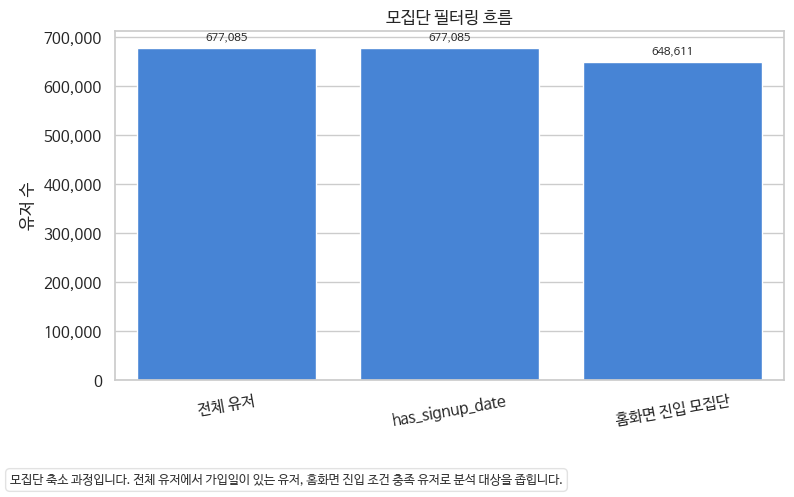

saved figure: /content/sender_behavior_axis_outputs/figures/02_eda_sender_group_size.png


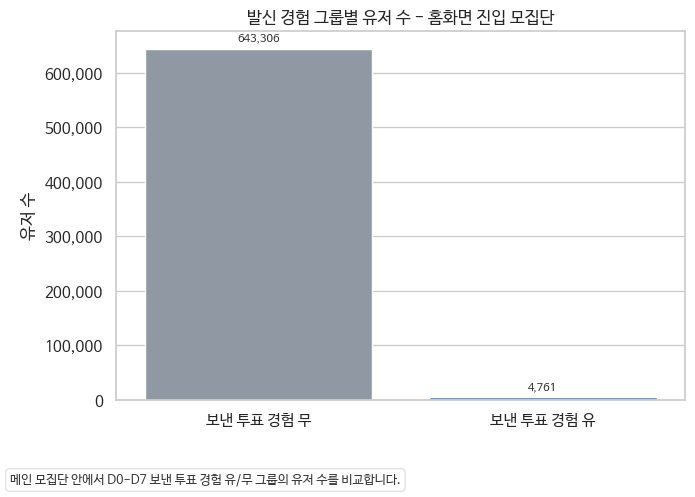

saved figure: /content/sender_behavior_axis_outputs/figures/03_eda_outcome_rates_by_sender_group.png


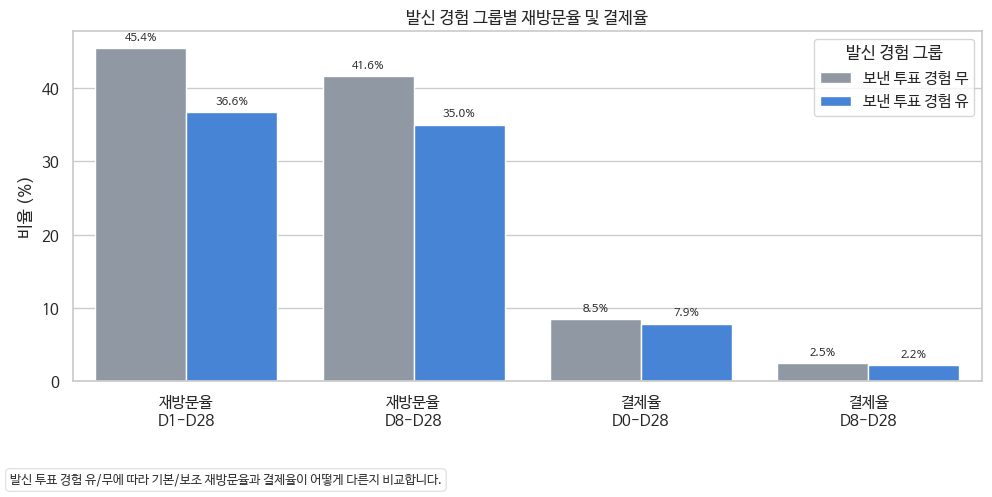

saved figure: /content/sender_behavior_axis_outputs/figures/04_eda_payment_count_mean_by_sender_group.png


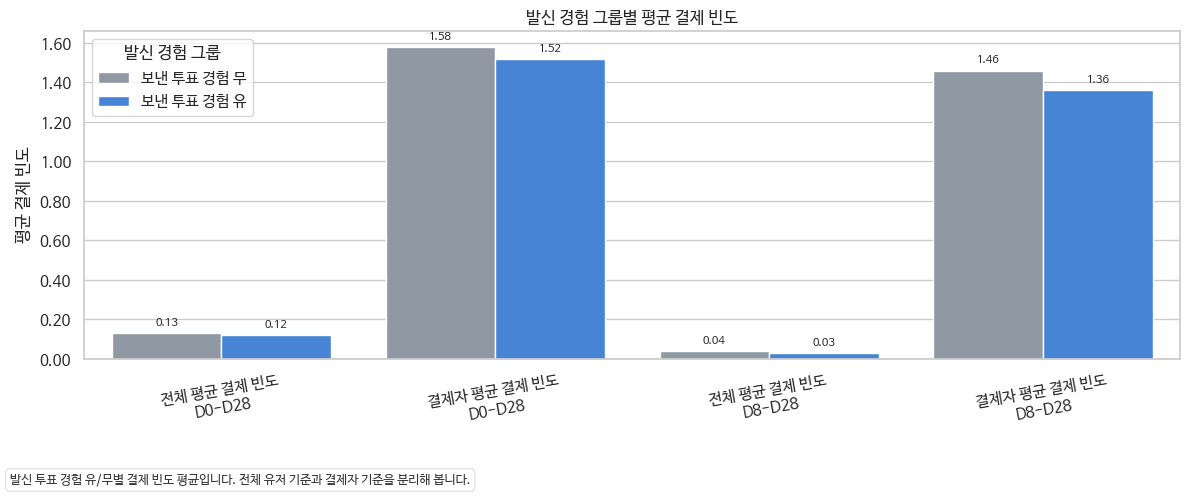

saved figure: /content/sender_behavior_axis_outputs/figures/05_eda_payment_amount_mean_by_sender_group.png


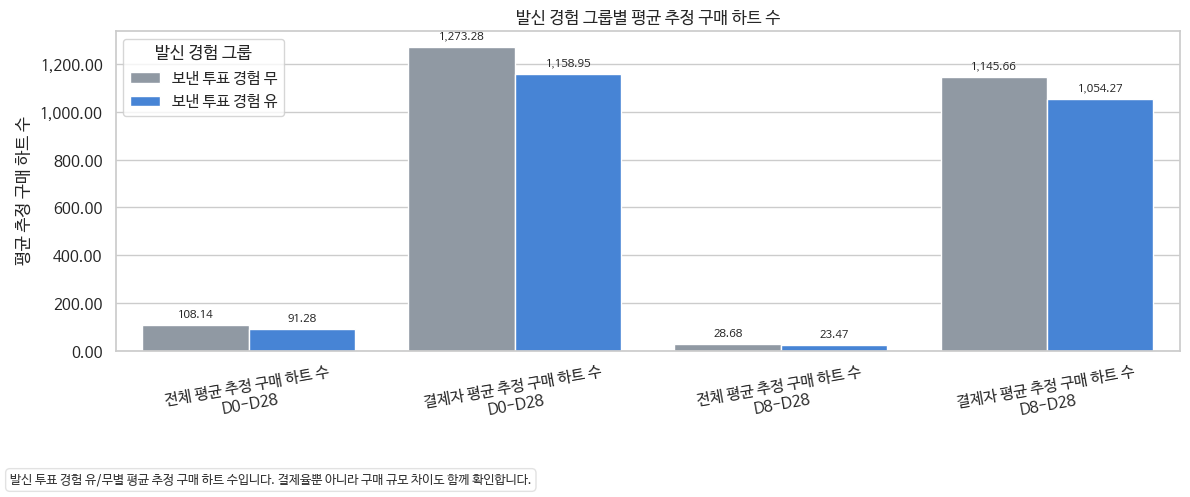

saved figure: /content/sender_behavior_axis_outputs/figures/06_eda_active_days_mean_by_sender_group.png


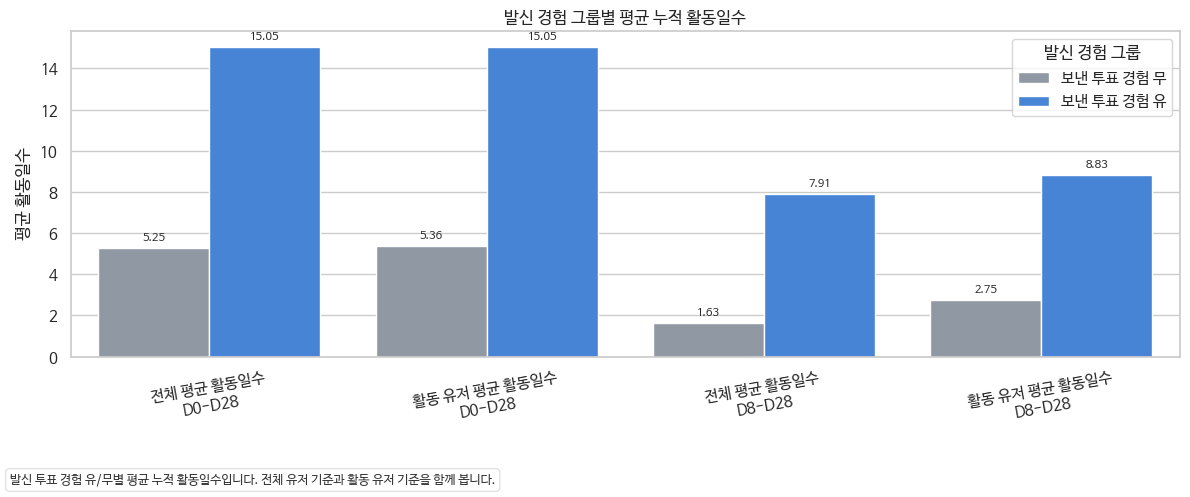

saved figure: /content/sender_behavior_axis_outputs/figures/07_eda_active_days_boxplot.png


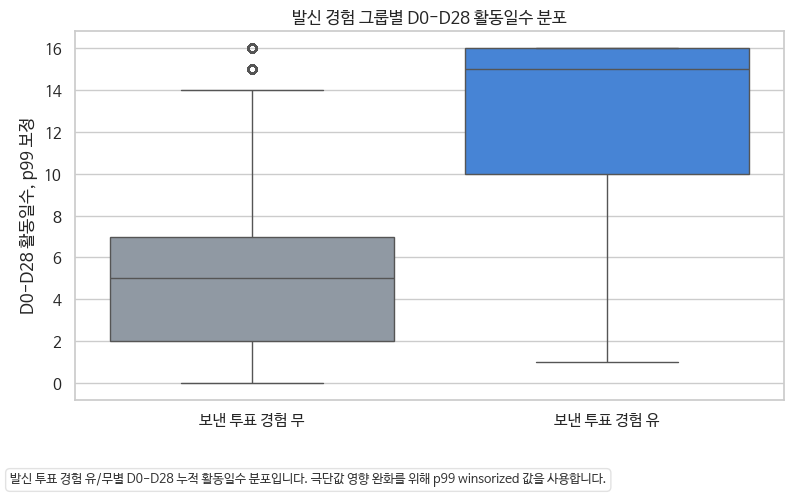

saved figure: /content/sender_behavior_axis_outputs/figures/08_eda_sent_vote_window_rate.png


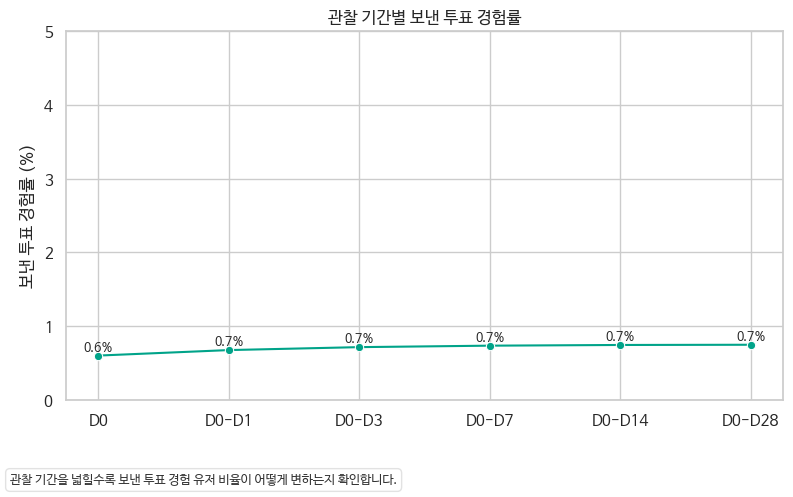

saved table: /content/sender_behavior_axis_outputs/tables/20_sent_vote_window_rate.csv


#### 관찰 기간별 보낸 투표 경험률

,window,sent_vote_rate
0,D0,0.600247
1,D0-D1,0.674776
2,D0-D3,0.714741
3,D0-D7,0.734646
4,D0-D14,0.744059
5,D0-D28,0.746991


saved figure: /content/sender_behavior_axis_outputs/figures/09_eda_sent_vote_count_distribution.png


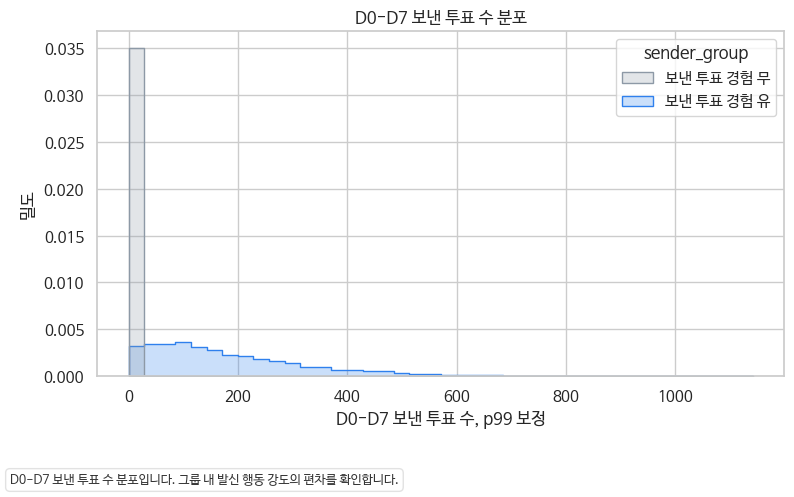

saved table: /content/sender_behavior_axis_outputs/tables/21_eda_correlation_input_check.csv


#### 상관 히트맵 입력 변수 변동성 점검

,column,label,nunique,used_in_heatmap
0,sent_vote_count_d0_7,보낸 투표 수\nD0-D7,641,True
1,sent_vote_active_days_d0_7,보낸 투표 활동일수\nD0-D7,9,True
2,sent_vote_distinct_chosen_users_d0_7,선택한 고유 유저 수\nD0-D7,112,True
3,hackle_question_start_count_d0_7,Hackle 질문 시작 수\nD0-D7,19,True
4,hackle_question_complete_count_d0_7,Hackle 질문 완료 수\nD0-D7,6,True
5,received_vote_read_count_d0_7,받은 투표 열람 수\nD0-D7,425,True
6,friend_count,친구 수,404,True
7,same_school_joined_user_count,동일 학교 가입자 수,391,True
8,retention_d1_28,재방문 여부\nD1-D28,2,True
9,retention_d8_28,재방문 여부\nD8-D28,2,True


saved figure: /content/sender_behavior_axis_outputs/figures/10_eda_correlation_heatmap.png


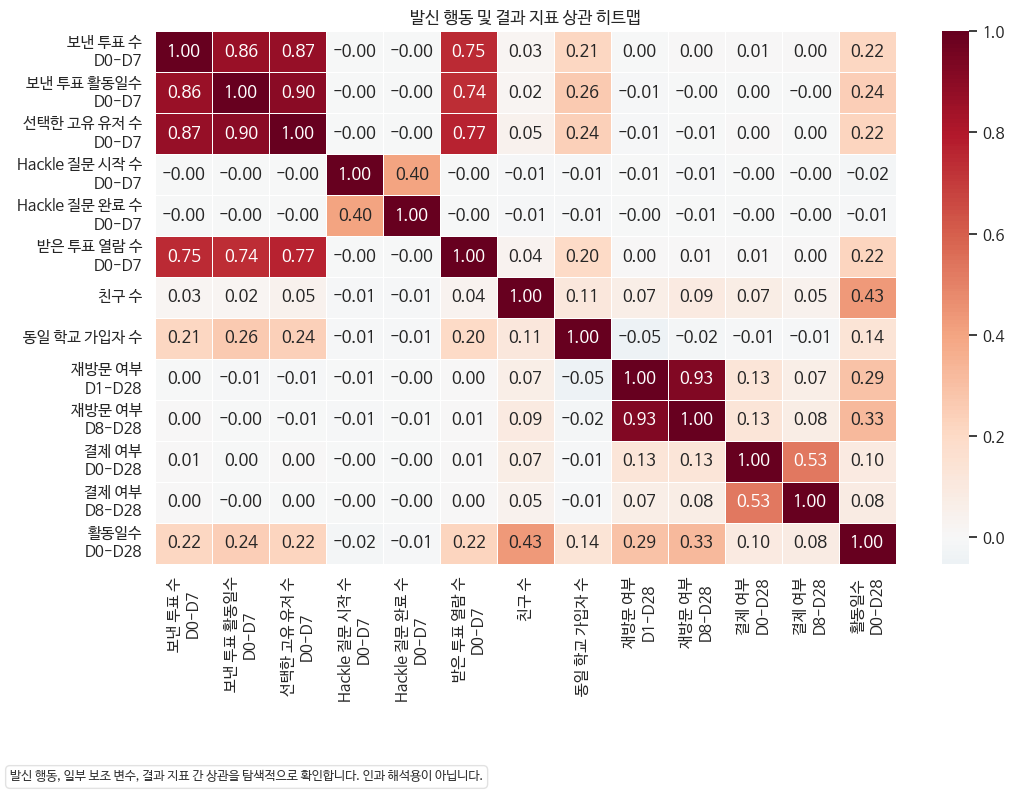

PosixPath('/content/sender_behavior_axis_outputs/figures/10_eda_correlation_heatmap.png')

In [ ]:
cell_note(
    "셀 13. EDA 시각화",
    "모집단, 발신 경험 그룹 규모, 결과 지표, 활동일수 분포, 발신 행동 분포와 상관관계를 PNG로 저장합니다.",
    "figures 폴더의 EDA PNG 파일, sent_vote_window_rate 표",
)

home_df = analysis_df.loc[analysis_df["home_entry_population"]].copy()
if home_df.empty:
    raise ValueError("홈화면 진입 모집단이 0명입니다. 모집단 조건 또는 원천 데이터를 확인하세요.")

home_df["sender_group"] = sender_group_categorical(home_df["sender_group"])
home_df["sent_vote_count_d0_7_w"] = winsorize_series(home_df["sent_vote_count_d0_7"], 0.99)
home_df["active_days_d0_28_w"] = winsorize_series(home_df["active_days_d0_28"], 0.99)

eda_plot_columns = [
    "sender_group",
    "sent_vote_count_d0_7",
    "sent_vote_count_d0_7_w",
    "active_days_d0_28",
    "active_days_d0_28_w",
    "retention_d1_28",
    "retention_d8_28",
    "paid_flag_d0_28",
    "paid_flag_d8_28",
    "payment_amount_d0_28",
    "payment_amount_d8_28",
    "active_days_d8_28",
]
eda_plot_columns = [c for c in eda_plot_columns if c in home_df.columns]
eda_plot_missing_check = pd.DataFrame(
    [
        {
            "column": c,
            "label": label_for(c),
            "missing_count": int(home_df[c].isna().sum()),
            "missing_rate_pct": round(home_df[c].isna().mean() * 100, 2),
            "zero_count": int((pd.to_numeric(home_df[c], errors="coerce").fillna(np.nan) == 0).sum())
            if c != "sender_group"
            else np.nan,
            "nunique": int(home_df[c].nunique(dropna=True)),
        }
        for c in eda_plot_columns
    ]
)
save_table(eda_plot_missing_check, "EDA 그래프 입력값 결측/0값 점검", "eda_plot_input_missing_check", n=50)

population_label_map = {
    "all_users": "전체 유저",
    "users_with_signup_date": "가입일 있는 유저",
    "home_entry_population": "홈화면 진입 모집단",
}
population_plot = population_funnel.copy()
population_plot["population_label"] = population_plot["population"].map(population_label_map).fillna(
    population_plot["population"]
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=population_plot, x="population_label", y="user_count", ax=ax, color=MAIN_COLOR)
ax.set_title("모집단 필터링 흐름")
ax.set_xlabel("")
ax.set_ylabel("유저 수")
ax.tick_params(axis="x", rotation=10)
format_count_axis(ax)
add_bar_labels(ax, decimals=0)
save_fig("모집단 필터링 흐름", "eda_population_funnel", fig)

fig, ax = plt.subplots(figsize=(7, 5))
sender_counts = (
    home_df.groupby("sender_group", as_index=False, observed=False)
    .agg(user_count=("user_id", "nunique"))
    .sort_values("sender_group")
)
sns.barplot(
    data=sender_counts,
    x="sender_group",
    y="user_count",
    ax=ax,
    order=SENDER_GROUP_ORDER,
    palette=SENDER_GROUP_PALETTE,
)
ax.set_title("발신 경험 그룹별 유저 수 - 홈화면 진입 모집단")
ax.set_xlabel("")
ax.set_ylabel("유저 수")
format_count_axis(ax)
add_bar_labels(ax, decimals=0)
save_fig("발신 경험 그룹별 유저 수", "eda_sender_group_size", fig)

rate_metric_cols = ["retention_d1_28_rate", "retention_d8_28_rate", "payment_d0_28_rate", "payment_d8_28_rate"]
rate_plot = home_summary.melt(
    id_vars=["sender_group"],
    value_vars=rate_metric_cols,
    var_name="metric",
    value_name="rate_pct",
)
rate_plot["sender_group"] = sender_group_categorical(rate_plot["sender_group"])
rate_plot["rate_pct"] = pd.to_numeric(rate_plot["rate_pct"], errors="coerce").fillna(0)
rate_plot = add_label_column(rate_plot)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=rate_plot,
    x="metric_label",
    y="rate_pct",
    hue="sender_group",
    ax=ax,
    order=[label_for(c) for c in rate_metric_cols],
    hue_order=SENDER_GROUP_ORDER,
    palette=SENDER_GROUP_PALETTE,
)
ax.set_title("발신 경험 그룹별 재방문율 및 결제율")
ax.set_xlabel("")
ax.set_ylabel("비율 (%)")
ax.legend(title="발신 경험 그룹")
add_bar_labels(ax, decimals=1, suffix="%")
save_fig("발신 경험 그룹별 재방문율 및 결제율", "eda_outcome_rates_by_sender_group", fig)

payment_count_metric_cols = [
    "payment_d0_28_count_mean",
    "payment_d0_28_count_paid_user_mean",
    "payment_d8_28_count_mean",
    "payment_d8_28_count_paid_user_mean",
]
payment_count_plot = home_summary.melt(
    id_vars=["sender_group"],
    value_vars=[c for c in payment_count_metric_cols if c in home_summary.columns],
    var_name="metric",
    value_name="mean_count",
)
payment_count_plot["sender_group"] = sender_group_categorical(payment_count_plot["sender_group"])
payment_count_plot["mean_count"] = pd.to_numeric(payment_count_plot["mean_count"], errors="coerce").fillna(0)
payment_count_plot = add_label_column(payment_count_plot)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=payment_count_plot,
    x="metric_label",
    y="mean_count",
    hue="sender_group",
    ax=ax,
    order=[label_for(c) for c in payment_count_metric_cols if c in home_summary.columns],
    hue_order=SENDER_GROUP_ORDER,
    palette=SENDER_GROUP_PALETTE,
)
ax.set_title("발신 경험 그룹별 평균 결제 빈도")
ax.set_xlabel("")
ax.set_ylabel("평균 결제 빈도")
ax.legend(title="발신 경험 그룹")
ax.tick_params(axis="x", rotation=10)
format_decimal_axis(ax, decimals=2)
add_bar_labels(ax, decimals=2)
save_fig("발신 경험 그룹별 평균 결제 빈도", "eda_payment_count_mean_by_sender_group", fig)

payment_amount_metric_cols = [
    "payment_d0_28_amount_mean",
    "payment_d0_28_amount_paid_user_mean",
    "payment_d8_28_amount_mean",
    "payment_d8_28_amount_paid_user_mean",
]
payment_amount_plot_available = (
    globals().get("PAYMENT_AMOUNT_AVAILABLE", False)
    and set(payment_amount_metric_cols).issubset(home_summary.columns)
    and home_summary[payment_amount_metric_cols].apply(pd.to_numeric, errors="coerce").fillna(0).abs().sum().sum() > 0
)
if payment_amount_plot_available:
    payment_amount_plot = home_summary.melt(
        id_vars=["sender_group"],
        value_vars=payment_amount_metric_cols,
        var_name="metric",
        value_name="mean_amount",
    )
    payment_amount_plot["sender_group"] = sender_group_categorical(payment_amount_plot["sender_group"])
    payment_amount_plot["mean_amount"] = pd.to_numeric(payment_amount_plot["mean_amount"], errors="coerce").fillna(0)
    payment_amount_plot = add_label_column(payment_amount_plot)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(
        data=payment_amount_plot,
        x="metric_label",
        y="mean_amount",
        hue="sender_group",
        ax=ax,
        order=[label_for(c) for c in payment_amount_metric_cols],
        hue_order=SENDER_GROUP_ORDER,
        palette=SENDER_GROUP_PALETTE,
    )
    ax.set_title(f"발신 경험 그룹별 평균 {PAYMENT_VALUE_LABEL}")
    ax.set_xlabel("")
    ax.set_ylabel(f"평균 {PAYMENT_VALUE_LABEL}")
    ax.legend(title="발신 경험 그룹")
    ax.tick_params(axis="x", rotation=10)
    format_decimal_axis(ax, decimals=2)
    add_bar_labels(ax, decimals=2)
    save_fig(f"발신 경험 그룹별 평균 {PAYMENT_VALUE_LABEL}", "eda_payment_amount_mean_by_sender_group", fig)
else:
    remove_previous_outputs(FIG_DIR, "eda_payment_amount_mean_by_sender_group", "png")
    print("결제 규모 후보가 확인되지 않아 발신 경험 그룹별 평균 결제 규모 그래프를 생성하지 않습니다.")

active_metric_cols = [
    "active_days_d0_28_mean",
    "active_days_d0_28_active_user_mean",
    "active_days_d8_28_mean",
    "active_days_d8_28_active_user_mean",
]
active_mean_plot = home_summary.melt(
    id_vars=["sender_group"],
    value_vars=active_metric_cols,
    var_name="metric",
    value_name="mean_days",
)
active_mean_plot["sender_group"] = sender_group_categorical(active_mean_plot["sender_group"])
active_mean_plot["mean_days"] = pd.to_numeric(active_mean_plot["mean_days"], errors="coerce").fillna(0)
active_mean_plot = add_label_column(active_mean_plot)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=active_mean_plot,
    x="metric_label",
    y="mean_days",
    hue="sender_group",
    ax=ax,
    order=[label_for(c) for c in active_metric_cols],
    hue_order=SENDER_GROUP_ORDER,
    palette=SENDER_GROUP_PALETTE,
)
ax.set_title("발신 경험 그룹별 평균 누적 활동일수")
ax.set_xlabel("")
ax.set_ylabel("평균 활동일수")
ax.legend(title="발신 경험 그룹")
ax.tick_params(axis="x", rotation=10)
add_bar_labels(ax, decimals=2)
save_fig("발신 경험 그룹별 평균 누적 활동일수", "eda_active_days_mean_by_sender_group", fig)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=home_df,
    x="sender_group",
    y="active_days_d0_28_w",
    ax=ax,
    order=SENDER_GROUP_ORDER,
    palette=SENDER_GROUP_PALETTE,
)
ax.set_title("발신 경험 그룹별 D0-D28 활동일수 분포")
ax.set_xlabel("")
ax.set_ylabel("D0-D28 활동일수, p99 보정")
save_fig("발신 경험 그룹별 D0-D28 활동일수 분포", "eda_active_days_boxplot", fig)

window_rate = pd.DataFrame(
    {
        "window": ["D0", "D0-D1", "D0-D3", "D0-D7", "D0-D14", "D0-D28"],
        "sent_vote_rate": [
            home_df["sent_vote_experience_d0"].mean() * 100,
            home_df["sent_vote_experience_d0_1"].mean() * 100,
            home_df["sent_vote_experience_d0_3"].mean() * 100,
            home_df["sent_vote_experience_d0_7"].mean() * 100,
            home_df["sent_vote_experience_d0_14"].mean() * 100,
            home_df["sent_vote_experience_d0_28"].mean() * 100,
        ],
    }
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=window_rate, x="window", y="sent_vote_rate", marker="o", ax=ax, color=ACCENT_COLOR)
ax.set_title("관찰 기간별 보낸 투표 경험률")
ax.set_xlabel("")
ax.set_ylabel("보낸 투표 경험률 (%)")
ax.set_xticks(range(len(WINDOW_ORDER)))
ax.set_xticklabels(WINDOW_ORDER)
ax.set_ylim(0, max(5, window_rate["sent_vote_rate"].max() * 1.15))
for x, y in zip(window_rate["window"], window_rate["sent_vote_rate"]):
    ax.text(x, y, f"{y:.1f}%", ha="center", va="bottom", fontsize=9)
save_fig("관찰 기간별 보낸 투표 경험률", "eda_sent_vote_window_rate", fig)
save_table(window_rate, "관찰 기간별 보낸 투표 경험률", "sent_vote_window_rate")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    data=home_df,
    x="sent_vote_count_d0_7_w",
    hue="sender_group",
    hue_order=SENDER_GROUP_ORDER,
    palette=SENDER_GROUP_PALETTE,
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
    ax=ax,
)
ax.set_title("D0-D7 보낸 투표 수 분포")
ax.set_xlabel("D0-D7 보낸 투표 수, p99 보정")
ax.set_ylabel("밀도")
save_fig("D0-D7 보낸 투표 수 분포", "eda_sent_vote_count_distribution", fig)

corr_cols = [
    "sent_vote_count_d0_7",
    "sent_vote_active_days_d0_7",
    "sent_vote_distinct_chosen_users_d0_7",
    "hackle_question_start_count_d0_7",
    "hackle_question_complete_count_d0_7",
    "received_vote_read_count_d0_7",
    "friend_count",
    "same_school_joined_user_count",
    "retention_d1_28",
    "retention_d8_28",
    "paid_flag_d0_28",
    "paid_flag_d8_28",
    "active_days_d0_28",
]
corr_cols = [c for c in corr_cols if c in home_df.columns]
corr_df = home_df[corr_cols].copy()
for c in corr_df.columns:
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce").fillna(0)

corr_quality = pd.DataFrame(
    [
        {
            "column": c,
            "label": label_for(c),
            "nunique": int(corr_df[c].nunique(dropna=True)),
            "used_in_heatmap": bool(corr_df[c].nunique(dropna=True) > 1),
        }
        for c in corr_df.columns
    ]
)
save_table(corr_quality, "상관 히트맵 입력 변수 변동성 점검", "eda_correlation_input_check", n=50)

corr_used_cols = corr_quality.loc[corr_quality["used_in_heatmap"], "column"].tolist()
fig, ax = plt.subplots(figsize=(11, 8))
if len(corr_used_cols) >= 2:
    corr_matrix = corr_df[corr_used_cols].corr()
    corr_matrix = corr_matrix.rename(index=label_for, columns=label_for)
    sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.4, ax=ax)
    ax.set_title("발신 행동 및 결과 지표 상관 히트맵")
else:
    ax.axis("off")
    ax.text(
        0.5,
        0.5,
        "상관계수를 계산할 만큼 변동이 있는 변수가 부족합니다.",
        ha="center",
        va="center",
        fontsize=12,
    )
    ax.set_title("발신 행동 및 결과 지표 상관 히트맵")
save_fig("발신 행동 및 결과 지표 상관 히트맵", "eda_correlation_heatmap", fig)

# ## 셀2-14. 발신 행동 세그먼트 클러스터링

### 셀 14. 발신 행동 세그먼트 클러스터링
- **목적**: D0-D7 발신 행동 원변수와 Hackle 보완 지표만 사용해 발신 행동 유형을 세분화하고 결과 지표를 비교합니다.
- **산출물**: sender_cluster_* 표와 PNG, 11_sender_behavior_analysis_with_sender_clusters.csv

기존 발신 클러스터링 산출물 삭제: 1개
saved table: /content/sender_behavior_axis_outputs/tables/32_sender_cluster_feature_definition.csv


#### 발신 단독 클러스터링 입력 변수 정의

,feature,feature_label,role
0,sent_vote_count_d0,보낸 투표 수\nD0,발신 단독 클러스터링 입력 변수
1,sent_vote_count_d0_3,보낸 투표 수\nD0-D3,발신 단독 클러스터링 입력 변수
2,sent_vote_count_d0_7,보낸 투표 수\nD0-D7,발신 단독 클러스터링 입력 변수
3,sent_vote_complete_count_d0_7,완료된 보낸 투표 수\nD0-D7,발신 단독 클러스터링 입력 변수
4,sent_vote_active_days_d0_7,보낸 투표 활동일수\nD0-D7,발신 단독 클러스터링 입력 변수
5,sent_vote_distinct_chosen_users_d0_7,선택한 고유 유저 수\nD0-D7,발신 단독 클러스터링 입력 변수
6,sent_vote_distinct_questions_d0_7,투표한 고유 질문 수\nD0-D7,발신 단독 클러스터링 입력 변수
7,hackle_question_start_count_d0_7,Hackle 질문 시작 수\nD0-D7,발신 단독 클러스터링 입력 변수
8,hackle_question_complete_count_d0_7,Hackle 질문 완료 수\nD0-D7,발신 단독 클러스터링 입력 변수
9,hackle_question_skip_count_d0_7,Hackle 질문 스킵 수\nD0-D7,발신 단독 클러스터링 입력 변수


선택된 발신 세그먼트 k: 3 (수동 지정 k를 사용했습니다.)
saved table: /content/sender_behavior_axis_outputs/tables/33_sender_cluster_name_mapping.csv


...

,sender_cluster,user_count,sent_vote_count_d0_7,sent_vote_active_days_d0_7,sent_vote_distinct_chosen_users_d0_7,sent_vote_distinct_questions_d0_7,hackle_question_start_count_d0_7,hackle_question_complete_count_d0_7,hackle_question_skip_count_d0_7,sender_cluster_label,cluster_profile_summary,custom_name_applied,label_rule,cluster_order
0,0,643381,0.00,0.00,0.00,0.0,0.0,0.00,0.0,발신 비활성형,"D0-D7 평균 보낸 투표 0.00회, 발신 활동일 0.00일, 선택 유저 0.00명",False,Votes와 Hackle 모두 초기 발신 행동이 거의 없는 군집,1
1,1,115,0.00,0.00,0.00,0.0,3.5,1.28,3.0,Hackle 질문 반응형,"D0-D7 평균 보낸 투표 0.00회, 발신 활동일 0.00일, 선택 유저 0.00명",False,Votes 발신은 낮지만 Hackle 질문 시작/완료/스킵 행동이 관찰되는 군집,2
2,2,4571,196.19,6.01,34.69,160.9,0.0,0.00,0.0,고강도 투표 발신형,"D0-D7 평균 보낸 투표 196.19회, 발신 활동일 6.01일, 선택 유저 34...",False,Votes 기준 D0-D7 평균 보낸 투표 수가 가장 높은 군집,3


saved table: /content/sender_behavior_axis_outputs/tables/34_sender_cluster_k_selection_metrics.csv


#### 발신 단독 클러스터 k 선택 지표

,k,inertia,silhouette_score,min_cluster_size,min_cluster_share_pct,meets_min_cluster_share,cluster_size_summary,silhouette_sample_size,selected_k,selection_reason
0,2,3.560094e+06,0.994021,4571,0.71,True,"0: 643,496명 (99.29%), 1: 4,571명 (0.71%)",20000,False,
1,3,1.650318e+06,0.996535,115,0.02,False,"0: 643,381명 (99.28%), 1: 115명 (0.02%), 2: 4,57...",20000,True,수동 지정 k를 사용했습니다.
2,4,1.229589e+06,0.996317,99,0.02,False,"0: 643,232명 (99.25%), 1: 4,571명 (0.71%), 2: 99...",20000,False,
3,5,9.911762e+05,0.996851,68,0.01,False,"0: 643,224명 (99.25%), 1: 4,571명 (0.71%), 2: 68...",20000,False,
4,6,8.327749e+05,0.996820,34,0.01,False,"0: 643,223명 (99.25%), 1: 34명 (0.01%), 2: 4,571...",20000,False,
5,7,6.894552e+05,0.994858,34,0.01,False,"0: 643,151명 (99.24%), 1: 2,975명 (0.46%), 2: 58...",20000,False,
6,8,6.030291e+05,0.995353,12,0.00,False,"0: 643,146명 (99.24%), 1: 2,980명 (0.46%), 2: 57...",20000,False,


saved figure: /content/sender_behavior_axis_outputs/figures/24_sender_cluster_k_selection.png


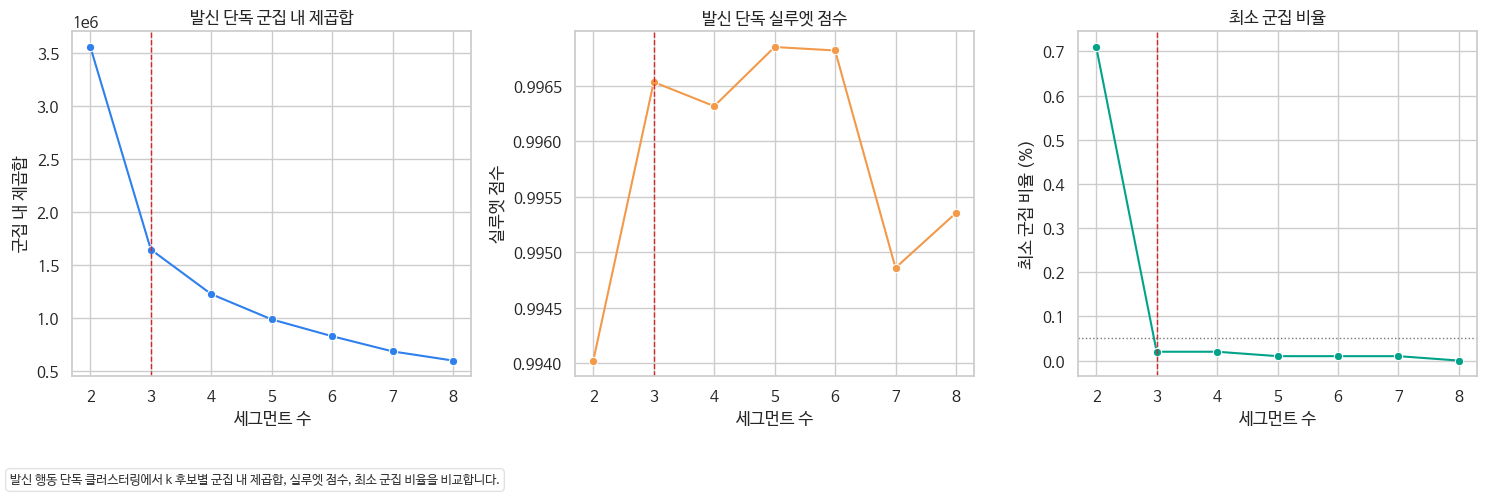

saved figure: /content/sender_behavior_axis_outputs/figures/25_sender_cluster_pca_2d.png


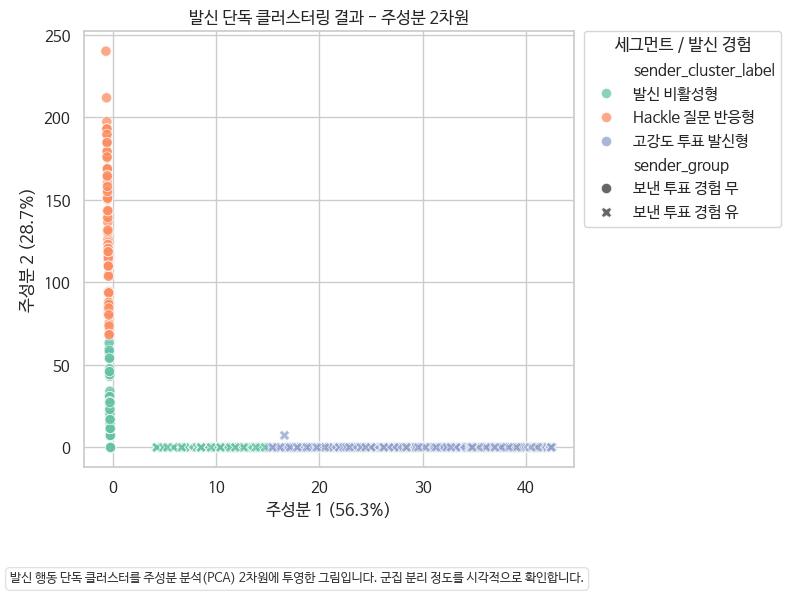

saved table: /content/sender_behavior_axis_outputs/tables/35_sender_cluster_feature_profile.csv


#### 발신 단독 클러스터 원변수 프로파일

,sender_cluster_label,sent_vote_count_d0,sent_vote_count_d0_3,sent_vote_count_d0_7,sent_vote_complete_count_d0_7,sent_vote_active_days_d0_7,sent_vote_distinct_chosen_users_d0_7,sent_vote_distinct_questions_d0_7,hackle_question_start_count_d0_7,hackle_question_complete_count_d0_7,hackle_question_skip_count_d0_7,hackle_question_completion_rate_d0_7,hackle_question_skip_rate_d0_7
0,발신 비활성형,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.00,0.00
1,Hackle 질문 반응형,0.00,0.00,0.00,0.0,0.00,0.00,0.0,3.5,1.28,3.0,0.53,1.22
2,고강도 투표 발신형,24.56,127.69,196.19,185.94,6.01,34.69,160.9,0.0,0.00,0.0,0.00,0.00


saved figure: /content/sender_behavior_axis_outputs/figures/26_sender_cluster_profile_bar.png


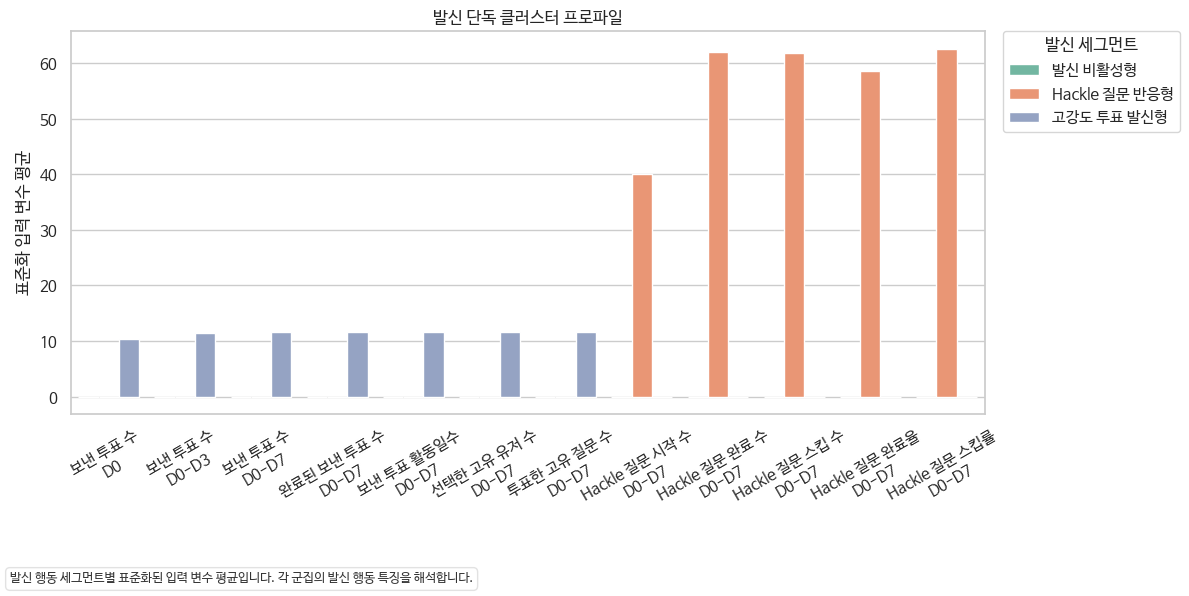

saved table: /content/sender_behavior_axis_outputs/tables/36_sender_cluster_outcome_summary.csv


#### 발신 단독 클러스터 결과 지표 요약

,sender_cluster_label,user_count,retention_d1_28_rate,retention_d8_28_rate,payment_d0_28_count_mean,payment_d8_28_count_mean,payment_d0_28_count_sum,payment_d8_28_count_sum,payment_d0_28_amount_mean,payment_d8_28_amount_mean,...,payment_d0_28_count_paid_user_mean,payment_d0_28_amount_paid_user_mean,payment_d8_28_count_paid_user_mean,payment_d8_28_amount_paid_user_mean,active_days_d0_28_active_user_mean,active_days_d8_28_active_user_mean,sent_vote_count_d0_7_sender_mean,sent_vote_active_days_d0_7_sender_mean,sent_vote_distinct_chosen_users_d0_7_sender_mean,cluster_profile_summary
0,발신 비활성형,643381,45.39,41.59,0.13,0.04,86496.0,23474.0,108.13,28.68,...,1.58,1273.29,1.46,1145.65,5.36,2.75,6.26,1.47,3.94,"D0-D7 평균 보낸 투표 0.00회, 발신 활동일 0.00일, 선택 유저 0.00명"
1,Hackle 질문 반응형,115,29.57,14.78,0.03,0.01,3.0,1.0,20.27,6.76,...,1.00,777.0,1.00,777.0,1.82,1.31,0.00,0.00,0.00,"D0-D7 평균 보낸 투표 0.00회, 발신 활동일 0.00일, 선택 유저 0.00명"
2,고강도 투표 발신형,4571,37.39,35.75,0.12,0.03,564.0,139.0,94.43,23.8,...,1.52,1160.35,1.35,1056.3,15.36,8.87,196.19,6.01,34.69,"D0-D7 평균 보낸 투표 196.19회, 발신 활동일 6.01일, 선택 유저 34..."


saved figure: /content/sender_behavior_axis_outputs/figures/27_sender_cluster_outcome_rates.png


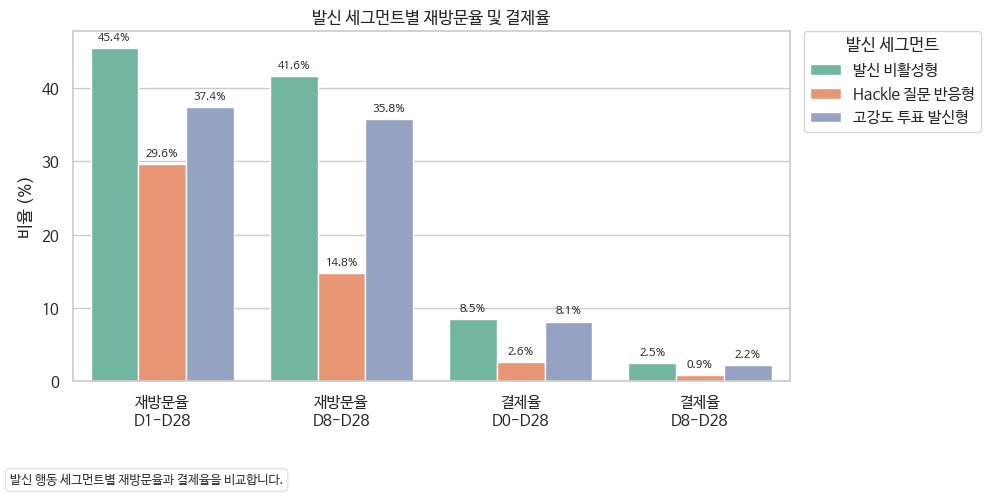

saved figure: /content/sender_behavior_axis_outputs/figures/28_sender_cluster_payment_count.png


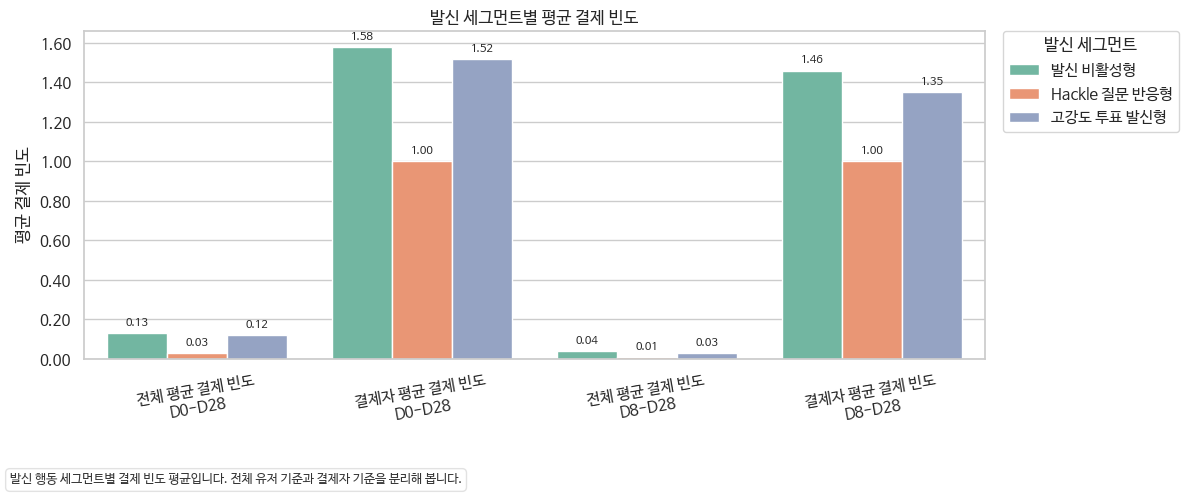

saved figure: /content/sender_behavior_axis_outputs/figures/29_sender_cluster_payment_amount.png


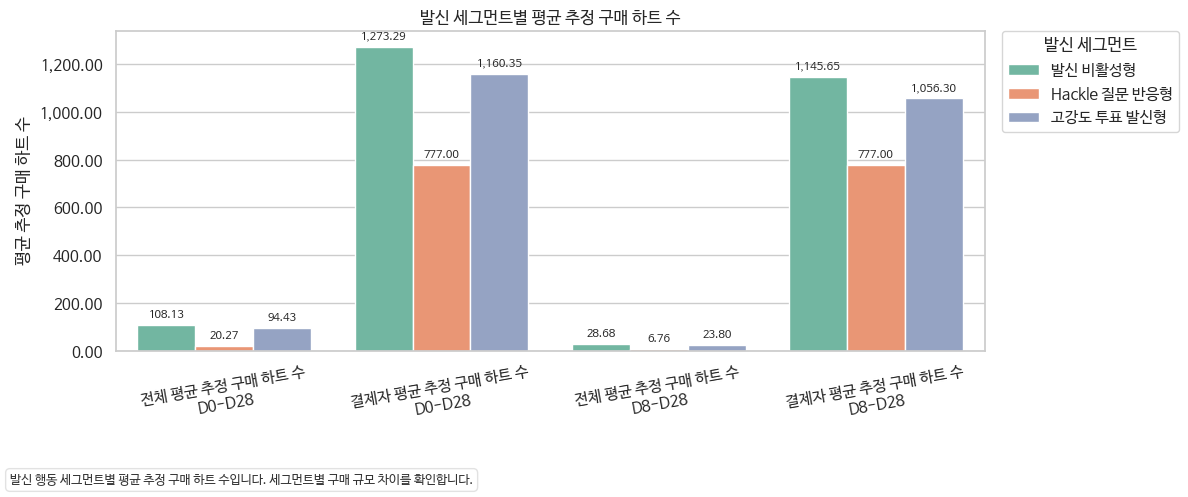

saved figure: /content/sender_behavior_axis_outputs/figures/30_sender_cluster_active_days.png


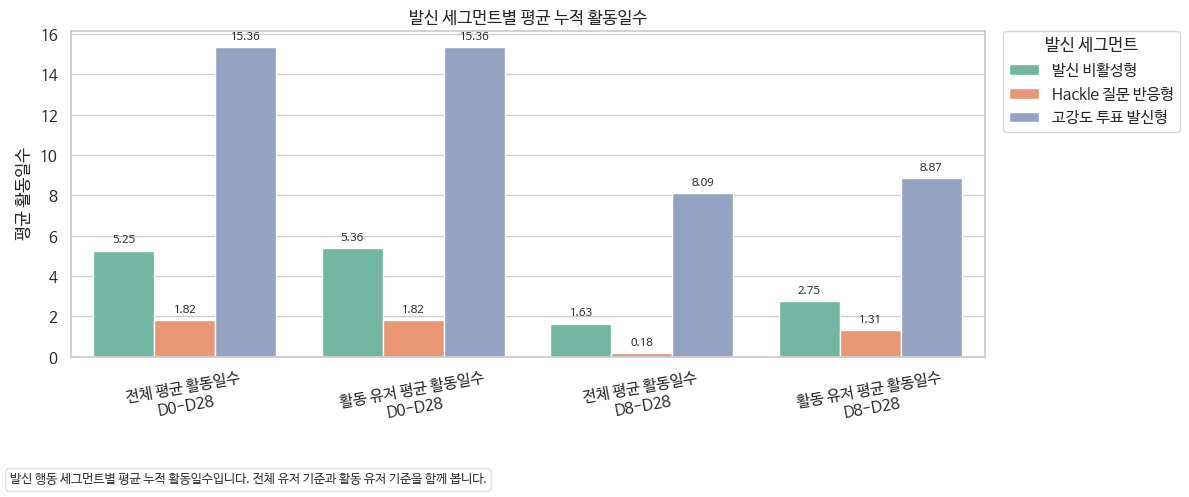

saved processed: /content/sender_behavior_axis_outputs/processed/11_sender_behavior_analysis_with_sender_clusters.csv


In [ ]:
cell_note(
    "셀 14. 발신 행동 세그먼트 클러스터링",
    "D0-D7 발신 행동 원변수와 Hackle 보완 지표만 사용해 발신 행동 유형을 세분화하고 결과 지표를 비교합니다.",
    "sender_cluster_* 표와 PNG, 11_sender_behavior_analysis_with_sender_clusters.csv",
)

sender_cluster_base = analysis_df.loc[analysis_df["home_entry_population"]].copy()
for col in ["payment_amount_d0_28", "payment_amount_d8_28"]:
    if col not in sender_cluster_base.columns:
        sender_cluster_base[col] = 0
sender_cluster_custom_name_map = globals().get("SENDER_CLUSTER_NAME_MAP", {})
AUTO_NAME_SENDER_CLUSTERS = globals().get("AUTO_NAME_SENDER_CLUSTERS", True)

# 이전 버전 셀 01을 실행한 런타임에서 셀 14만 다시 실행해도 군집명 자동 부여가 동작하도록
# 셀 14 안에 fallback 함수를 둡니다.
if "make_unique_cluster_labels" not in globals():
    def make_unique_cluster_labels(label_map):
        seen = {}
        unique_map = {}
        for cluster_id, label in label_map.items():
            label = str(label).strip() or f"군집 {cluster_id}"
            seen[label] = seen.get(label, 0) + 1
            unique_map[cluster_id] = label if seen[label] == 1 else f"{label} {seen[label]}"
        return unique_map


if "build_auto_sender_cluster_label_map" not in globals():
    def build_auto_sender_cluster_label_map(cluster_profile):
        profile = cluster_profile.copy()
        sent_col = "sent_vote_count_d0_7"
        hackle_cols = [
            c
            for c in [
                "hackle_question_start_count_d0_7",
                "hackle_question_complete_count_d0_7",
                "hackle_question_skip_count_d0_7",
            ]
            if c in profile.columns
        ]

        def numeric_profile_col(col, default=0.0):
            if col in profile.columns:
                return pd.to_numeric(profile[col], errors="coerce").fillna(default)
            return pd.Series(default, index=profile.index)

        profile["_sent_mean"] = numeric_profile_col(sent_col)
        profile["_hackle_mean"] = 0.0
        for col in hackle_cols:
            profile["_hackle_mean"] += numeric_profile_col(col)

        max_sent = float(profile["_sent_mean"].max()) if not profile.empty else 0.0
        label_map = {}
        rule_map = {}

        for _, row in profile.iterrows():
            cluster_id = int(row["sender_cluster"])
            sent_mean = float(row["_sent_mean"])
            hackle_mean = float(row["_hackle_mean"])

            if sent_mean > 0 and (sent_mean == max_sent or sent_mean >= 50):
                label = "고강도 투표 발신형"
                rule = "Votes 기준 D0-D7 평균 보낸 투표 수가 가장 높은 군집"
            elif sent_mean <= 1 and hackle_mean > 0:
                label = "Hackle 질문 반응형"
                rule = "Votes 발신은 낮지만 Hackle 질문 시작/완료/스킵 행동이 관찰되는 군집"
            elif sent_mean <= 1:
                label = "발신 비활성형"
                rule = "Votes와 Hackle 모두 초기 발신 행동이 거의 없는 군집"
            else:
                label = "저강도 투표 발신형"
                rule = "Votes 기준 D0-D7 보낸 투표가 있으나 고강도 군집은 아닌 군집"

            label_map[cluster_id] = label
            rule_map[cluster_id] = rule

        return make_unique_cluster_labels(label_map), rule_map

removed_cluster_outputs = []
for output_dir, pattern in [
    (FIG_DIR, "*sender_cluster*.png"),
    (TABLE_DIR, "*sender_cluster*.csv"),
]:
    for old_path in output_dir.glob(pattern):
        old_path.unlink(missing_ok=True)
        removed_cluster_outputs.append(str(old_path))
cluster_processed_path = PROCESSED_DIR / "11_sender_behavior_analysis_with_sender_clusters.csv"
if cluster_processed_path.exists():
    cluster_processed_path.unlink(missing_ok=True)
    removed_cluster_outputs.append(str(cluster_processed_path))
print(f"기존 발신 클러스터링 산출물 삭제: {len(removed_cluster_outputs)}개")

sender_cluster_features = [
    "sent_vote_count_d0",
    "sent_vote_count_d0_3",
    "sent_vote_count_d0_7",
    "sent_vote_complete_count_d0_7",
    "sent_vote_active_days_d0_7",
    "sent_vote_distinct_chosen_users_d0_7",
    "sent_vote_distinct_questions_d0_7",
    "hackle_question_start_count_d0_7",
    "hackle_question_complete_count_d0_7",
    "hackle_question_skip_count_d0_7",
    "hackle_question_completion_rate_d0_7",
    "hackle_question_skip_rate_d0_7",
]
sender_cluster_features = [c for c in sender_cluster_features if c in sender_cluster_base.columns]

sender_cluster_feature_definition = pd.DataFrame(
    {
        "feature": sender_cluster_features,
        "feature_label": [label_for(c) for c in sender_cluster_features],
        "role": [
            "발신 단독 클러스터링 입력 변수"
            for _ in sender_cluster_features
        ],
    }
)
save_table(
    sender_cluster_feature_definition,
    "발신 단독 클러스터링 입력 변수 정의",
    "sender_cluster_feature_definition",
    n=50,
)

if len(sender_cluster_features) < 2:
    print("[WARN] 발신 행동 클러스터링에 사용할 변수가 충분하지 않습니다.")
else:
    sender_X = sender_cluster_base[sender_cluster_features].apply(pd.to_numeric, errors="coerce").fillna(0)

    rate_like_cols = [c for c in sender_X.columns if c.endswith("_rate_d0_7")]
    count_like_cols = [c for c in sender_X.columns if c not in rate_like_cols]

    for c in count_like_cols:
        sender_X[c] = np.log1p(winsorize_series(sender_X[c], 0.99))
    for c in rate_like_cols:
        sender_X[c] = sender_X[c].clip(lower=0, upper=1)

    non_constant_features = [c for c in sender_X.columns if sender_X[c].std(ddof=0) > 0]
    unique_rows = sender_X[non_constant_features].drop_duplicates().shape[0] if non_constant_features else 0
    max_k = min(MAX_SENDER_CLUSTER_K, len(sender_cluster_base) - 1, unique_rows)

    if len(non_constant_features) < 2 or max_k < 2:
        print("[WARN] 발신 단독 클러스터링을 수행할 만큼 변수 변동이 충분하지 않습니다.")
    else:
        X_scaled = StandardScaler().fit_transform(sender_X[non_constant_features])

        k_values = list(range(2, max_k + 1))
        k_metric_rows = []
        for k in k_values:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            labels = model.fit_predict(X_scaled)
            cluster_counts = pd.Series(labels).value_counts().sort_index()
            min_cluster_size = int(cluster_counts.min())
            min_cluster_share = min_cluster_size / len(labels)
            sample_idx = stratified_sample_indices(labels, SILHOUETTE_SAMPLE_SIZE, RANDOM_STATE + k)
            sample_labels = labels[sample_idx]
            if len(np.unique(sample_labels)) >= 2:
                sil_score = silhouette_score(X_scaled[sample_idx], sample_labels)
            else:
                sil_score = np.nan
            k_metric_rows.append(
                {
                    "k": k,
                    "inertia": model.inertia_,
                    "silhouette_score": sil_score,
                    "min_cluster_size": min_cluster_size,
                    "min_cluster_share_pct": round(min_cluster_share * 100, 2),
                    "meets_min_cluster_share": bool(min_cluster_share >= MIN_SENDER_CLUSTER_SHARE),
                    "cluster_size_summary": ", ".join(
                        [
                            f"{cluster_id}: {count:,}명 ({count / len(labels) * 100:.2f}%)"
                            for cluster_id, count in cluster_counts.items()
                        ]
                    ),
                    "silhouette_sample_size": int(len(sample_idx)),
                }
            )

        sender_k_df = pd.DataFrame(k_metric_rows)

        if SELECTED_SENDER_K is not None:
            if SELECTED_SENDER_K not in k_values:
                raise ValueError(f"SELECTED_SENDER_K={SELECTED_SENDER_K}는 후보 k 범위 {k_values} 안에 없습니다.")
            best_k = int(SELECTED_SENDER_K)
            selection_reason = "수동 지정 k를 사용했습니다."
        else:
            valid_k_df = sender_k_df.loc[
                sender_k_df["meets_min_cluster_share"] & sender_k_df["silhouette_score"].notna()
            ].copy()
            if valid_k_df.empty:
                best_row = sender_k_df.loc[sender_k_df["silhouette_score"].idxmax()]
                best_k = int(best_row["k"])
                selection_reason = (
                    f"최소 군집 비율 {MIN_SENDER_CLUSTER_SHARE:.1%} 이상 후보가 없어 "
                    "전체 후보 중 실루엣 점수가 가장 높은 k를 사용했습니다."
                )
            else:
                best_row = valid_k_df.sort_values(
                    ["silhouette_score", "min_cluster_share_pct", "k"],
                    ascending=[False, False, True],
                ).iloc[0]
                best_k = int(best_row["k"])
                selection_reason = (
                    f"최소 군집 비율 {MIN_SENDER_CLUSTER_SHARE:.1%} 이상 후보 중 "
                    "실루엣 점수가 가장 높은 k를 사용했습니다."
                )
        sender_k_df["selected_k"] = sender_k_df["k"].eq(best_k)
        sender_k_df["selection_reason"] = np.where(sender_k_df["selected_k"], selection_reason, "")
        print(f"선택된 발신 세그먼트 k: {best_k} ({selection_reason})")

        final_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
        sender_cluster_base["sender_cluster"] = final_model.fit_predict(X_scaled).astype(int)
        cluster_name_agg = {"user_count": ("user_id", "nunique")}
        for feature in [
            "sent_vote_count_d0_7",
            "sent_vote_active_days_d0_7",
            "sent_vote_distinct_chosen_users_d0_7",
            "sent_vote_distinct_questions_d0_7",
            "hackle_question_start_count_d0_7",
            "hackle_question_complete_count_d0_7",
            "hackle_question_skip_count_d0_7",
        ]:
            if feature in sender_cluster_base.columns:
                cluster_name_agg[feature] = (feature, "mean")
        sender_cluster_profile_for_names = (
            sender_cluster_base.groupby("sender_cluster", as_index=False)
            .agg(**cluster_name_agg)
            .round(2)
        )
        ordered_cluster_ids = order_sender_clusters_by_profile(sender_cluster_profile_for_names)
        has_custom_cluster_names = bool(sender_cluster_custom_name_map)
        if has_custom_cluster_names:
            cluster_name_map = build_sender_cluster_label_map(ordered_cluster_ids, sender_cluster_custom_name_map)
            cluster_label_rule_map = {
                cluster_id: "SENDER_CLUSTER_NAME_MAP 수동 지정"
                for cluster_id in ordered_cluster_ids
            }
        elif AUTO_NAME_SENDER_CLUSTERS:
            cluster_name_map, cluster_label_rule_map = build_auto_sender_cluster_label_map(
                sender_cluster_profile_for_names
            )
        else:
            cluster_name_map = build_sender_cluster_label_map(ordered_cluster_ids)
            cluster_label_rule_map = {
                cluster_id: "자동 군집명 비활성화, numeric cluster id 사용"
                for cluster_id in ordered_cluster_ids
            }
        cluster_order = [cluster_name_map[c] for c in ordered_cluster_ids]
        cluster_palette = build_cluster_palette(cluster_order)
        sender_cluster_base["sender_cluster_label"] = sender_cluster_base["sender_cluster"].map(cluster_name_map)
        sender_cluster_base["sender_cluster_label"] = pd.Categorical(
            sender_cluster_base["sender_cluster_label"],
            categories=cluster_order,
            ordered=True,
        )

        sender_cluster_name_mapping = sender_cluster_profile_for_names.copy()
        sender_cluster_name_mapping["sender_cluster_label"] = sender_cluster_name_mapping["sender_cluster"].map(
            cluster_name_map
        )
        sender_cluster_name_mapping["cluster_profile_summary"] = sender_cluster_name_mapping.apply(
            build_sender_cluster_profile_summary,
            axis=1,
        )
        sender_cluster_name_mapping["custom_name_applied"] = sender_cluster_name_mapping["sender_cluster"].map(
            lambda x: bool(
                str(sender_cluster_custom_name_map.get(int(x), sender_cluster_custom_name_map.get(str(int(x)), ""))).strip()
            )
        )
        sender_cluster_name_mapping["label_rule"] = sender_cluster_name_mapping["sender_cluster"].map(
            cluster_label_rule_map
        )
        sender_cluster_name_mapping["cluster_order"] = sender_cluster_name_mapping["sender_cluster"].map(
            {cluster_id: i + 1 for i, cluster_id in enumerate(ordered_cluster_ids)}
        )
        sender_cluster_name_mapping = sender_cluster_name_mapping.sort_values("cluster_order")
        save_table(sender_cluster_name_mapping, "발신 단독 클러스터 군집명 매핑용 프로파일", "sender_cluster_name_mapping", n=50)

        analysis_df = analysis_df.drop(
            columns=[
                c
                for c in ["sender_cluster", "sender_cluster_label"]
                if c in analysis_df.columns
            ]
        )
        analysis_df = analysis_df.merge(
            sender_cluster_base[["user_id", "sender_cluster", "sender_cluster_label"]],
            on="user_id",
            how="left",
        )

        save_table(sender_k_df, "발신 단독 클러스터 k 선택 지표", "sender_cluster_k_selection_metrics")

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        sns.lineplot(data=sender_k_df, x="k", y="inertia", marker="o", ax=axes[0], color=MAIN_COLOR)
        axes[0].axvline(best_k, color="#D62728", linestyle="--", linewidth=1)
        axes[0].set_title("발신 단독 군집 내 제곱합")
        axes[0].set_xlabel("세그먼트 수")
        axes[0].set_ylabel("군집 내 제곱합")
        sns.lineplot(data=sender_k_df, x="k", y="silhouette_score", marker="o", ax=axes[1], color=SECONDARY_COLOR)
        axes[1].axvline(best_k, color="#D62728", linestyle="--", linewidth=1)
        axes[1].set_title("발신 단독 실루엣 점수")
        axes[1].set_xlabel("세그먼트 수")
        axes[1].set_ylabel("실루엣 점수")
        sns.lineplot(data=sender_k_df, x="k", y="min_cluster_share_pct", marker="o", ax=axes[2], color=ACCENT_COLOR)
        axes[2].axvline(best_k, color="#D62728", linestyle="--", linewidth=1)
        axes[2].axhline(MIN_SENDER_CLUSTER_SHARE * 100, color="#777777", linestyle=":", linewidth=1)
        axes[2].set_title("최소 군집 비율")
        axes[2].set_xlabel("세그먼트 수")
        axes[2].set_ylabel("최소 군집 비율 (%)")
        save_fig("발신 단독 클러스터 k 선택", "sender_cluster_k_selection", fig)

        pca = PCA(n_components=2, random_state=RANDOM_STATE)
        pcs = pca.fit_transform(X_scaled)
        sender_pca_df = pd.DataFrame(
            {
                "PC1": pcs[:, 0],
                "PC2": pcs[:, 1],
                "sender_cluster_label": sender_cluster_base["sender_cluster_label"].values,
                "sender_group": sender_cluster_base["sender_group"].values,
            }
        )
        sender_pca_df["sender_cluster_label"] = pd.Categorical(
            sender_pca_df["sender_cluster_label"],
            categories=cluster_order,
            ordered=True,
        )
        sender_pca_df["sender_group"] = sender_group_categorical(sender_pca_df["sender_group"])
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.scatterplot(
            data=sender_pca_df,
            x="PC1",
            y="PC2",
            hue="sender_cluster_label",
            hue_order=cluster_order,
            palette=cluster_palette,
            style="sender_group",
            style_order=SENDER_GROUP_ORDER,
            alpha=0.75,
            s=55,
            ax=ax,
        )
        ax.set_title("발신 단독 클러스터링 결과 - 주성분 2차원")
        ax.set_xlabel(f"주성분 1 ({pca.explained_variance_ratio_[0]:.1%})")
        ax.set_ylabel(f"주성분 2 ({pca.explained_variance_ratio_[1]:.1%})")
        ax.legend(title="세그먼트 / 발신 경험", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        save_fig("발신 단독 클러스터링 결과 PCA", "sender_cluster_pca_2d", fig)

        sender_profile = (
            sender_cluster_base.groupby("sender_cluster_label", as_index=False, observed=False)[sender_cluster_features]
            .mean()
            .round(2)
        )
        sender_profile = sender_profile.sort_values("sender_cluster_label")
        save_table(sender_profile, "발신 단독 클러스터 원변수 프로파일", "sender_cluster_feature_profile", n=50)

        sender_profile_scaled = pd.DataFrame(
            X_scaled,
            columns=non_constant_features,
            index=sender_cluster_base.index,
        )
        sender_profile_scaled["sender_cluster_label"] = sender_cluster_base["sender_cluster_label"].values
        sender_profile_scaled["sender_cluster_label"] = pd.Categorical(
            sender_profile_scaled["sender_cluster_label"],
            categories=cluster_order,
            ordered=True,
        )
        sender_profile_scaled = sender_profile_scaled.groupby(
            "sender_cluster_label",
            as_index=False,
            observed=False,
        ).mean()
        sender_profile_long = sender_profile_scaled.melt(
            id_vars="sender_cluster_label",
            var_name="feature",
            value_name="mean_standardized_value",
        )
        sender_profile_long["feature_label"] = sender_profile_long["feature"].map(label_for)
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.barplot(
            data=sender_profile_long,
            x="feature_label",
            y="mean_standardized_value",
            hue="sender_cluster_label",
            order=[label_for(c) for c in non_constant_features],
            hue_order=cluster_order,
            palette=cluster_palette,
            ax=ax,
        )
        ax.set_title("발신 단독 클러스터 프로파일")
        ax.set_xlabel("")
        ax.set_ylabel("표준화 입력 변수 평균")
        ax.tick_params(axis="x", rotation=30)
        ax.legend(title="발신 세그먼트", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        save_fig("발신 단독 클러스터 프로파일", "sender_cluster_profile_bar", fig)

        sender_cluster_outcome = (
            sender_cluster_base.groupby("sender_cluster_label", as_index=False, observed=False)
            .agg(
                user_count=("user_id", "nunique"),
                retention_d1_28_rate=("retention_d1_28", rate),
                retention_d8_28_rate=("retention_d8_28", rate),
                payment_d0_28_count_mean=("payment_count_d0_28", "mean"),
                payment_d8_28_count_mean=("payment_count_d8_28", "mean"),
                payment_d0_28_count_sum=("payment_count_d0_28", "sum"),
                payment_d8_28_count_sum=("payment_count_d8_28", "sum"),
                payment_d0_28_amount_mean=("payment_amount_d0_28", "mean"),
                payment_d8_28_amount_mean=("payment_amount_d8_28", "mean"),
                payment_d0_28_amount_sum=("payment_amount_d0_28", "sum"),
                payment_d8_28_amount_sum=("payment_amount_d8_28", "sum"),
                payment_d0_28_paid_user_count=("paid_flag_d0_28", "sum"),
                payment_d8_28_paid_user_count=("paid_flag_d8_28", "sum"),
                payment_d0_28_rate=("paid_flag_d0_28", rate),
                payment_d8_28_rate=("paid_flag_d8_28", rate),
                active_days_d0_28_mean=("active_days_d0_28", "mean"),
                active_days_d8_28_mean=("active_days_d8_28", "mean"),
                active_days_d0_28_sum=("active_days_d0_28", "sum"),
                active_days_d8_28_sum=("active_days_d8_28", "sum"),
                active_days_d0_28_active_user_count=("active_days_d0_28", nonzero_count),
                active_days_d8_28_active_user_count=("active_days_d8_28", nonzero_count),
                sent_vote_count_d0_7_mean=("sent_vote_count_d0_7", "mean"),
                sent_vote_count_d0_7_sum=("sent_vote_count_d0_7", "sum"),
                sent_vote_user_count_d0_7=("sent_vote_count_d0_7", nonzero_count),
                sent_vote_active_days_d0_7_mean=("sent_vote_active_days_d0_7", "mean"),
                sent_vote_active_days_d0_7_sum=("sent_vote_active_days_d0_7", "sum"),
                sent_vote_distinct_chosen_users_d0_7_mean=("sent_vote_distinct_chosen_users_d0_7", "mean"),
                sent_vote_distinct_chosen_users_d0_7_sum=("sent_vote_distinct_chosen_users_d0_7", "sum"),
            )
            .round(2)
            .sort_values("sender_cluster_label")
        )
        sender_cluster_outcome = add_adjusted_mean_columns(sender_cluster_outcome).round(2)
        sender_cluster_count_cols = [c for c in sender_cluster_outcome.columns if c.endswith("_count")]
        sender_cluster_outcome[sender_cluster_count_cols] = sender_cluster_outcome[sender_cluster_count_cols].astype("int64")
        sender_cluster_summary_map = sender_cluster_name_mapping.set_index("sender_cluster_label")[
            "cluster_profile_summary"
        ].to_dict()
        sender_cluster_outcome["cluster_profile_summary"] = (
            sender_cluster_outcome["sender_cluster_label"].astype("string").map(sender_cluster_summary_map).fillna("")
        )
        if not globals().get("PAYMENT_AMOUNT_AVAILABLE", False):
            sender_cluster_outcome = sender_cluster_outcome.drop(
                columns=[
                    "payment_d0_28_amount_mean",
                    "payment_d8_28_amount_mean",
                    "payment_d0_28_amount_paid_user_mean",
                    "payment_d8_28_amount_paid_user_mean",
                    "payment_d0_28_amount_sum",
                    "payment_d8_28_amount_sum",
                ],
                errors="ignore",
            )
        save_table(sender_cluster_outcome, "발신 단독 클러스터 결과 지표 요약", "sender_cluster_outcome_summary")

        cluster_rate_metric_cols = ["retention_d1_28_rate", "retention_d8_28_rate", "payment_d0_28_rate", "payment_d8_28_rate"]
        sender_cluster_rate_plot = sender_cluster_outcome.melt(
            id_vars=["sender_cluster_label"],
            value_vars=cluster_rate_metric_cols,
            var_name="metric",
            value_name="rate_pct",
        )
        sender_cluster_rate_plot["rate_pct"] = pd.to_numeric(sender_cluster_rate_plot["rate_pct"], errors="coerce").fillna(0)
        sender_cluster_rate_plot = add_label_column(sender_cluster_rate_plot)
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(
            data=sender_cluster_rate_plot,
            x="metric_label",
            y="rate_pct",
            hue="sender_cluster_label",
            ax=ax,
            order=[label_for(c) for c in cluster_rate_metric_cols],
            hue_order=cluster_order,
            palette=cluster_palette,
        )
        ax.set_title("발신 세그먼트별 재방문율 및 결제율")
        ax.set_xlabel("")
        ax.set_ylabel("비율 (%)")
        ax.legend(title="발신 세그먼트", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        add_bar_labels(ax, decimals=1, suffix="%")
        save_fig("발신 세그먼트별 재방문율 및 결제율", "sender_cluster_outcome_rates", fig)

        cluster_payment_count_metric_cols = [
            "payment_d0_28_count_mean",
            "payment_d0_28_count_paid_user_mean",
            "payment_d8_28_count_mean",
            "payment_d8_28_count_paid_user_mean",
        ]
        sender_cluster_payment_count_plot = sender_cluster_outcome.melt(
            id_vars=["sender_cluster_label"],
            value_vars=[c for c in cluster_payment_count_metric_cols if c in sender_cluster_outcome.columns],
            var_name="metric",
            value_name="mean_count",
        )
        sender_cluster_payment_count_plot["mean_count"] = pd.to_numeric(
            sender_cluster_payment_count_plot["mean_count"],
            errors="coerce",
        ).fillna(0)
        sender_cluster_payment_count_plot = add_label_column(sender_cluster_payment_count_plot)
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(
            data=sender_cluster_payment_count_plot,
            x="metric_label",
            y="mean_count",
            hue="sender_cluster_label",
            ax=ax,
            order=[label_for(c) for c in cluster_payment_count_metric_cols if c in sender_cluster_outcome.columns],
            hue_order=cluster_order,
            palette=cluster_palette,
        )
        ax.set_title("발신 세그먼트별 평균 결제 빈도")
        ax.set_xlabel("")
        ax.set_ylabel("평균 결제 빈도")
        ax.legend(title="발신 세그먼트", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        ax.tick_params(axis="x", rotation=10)
        format_decimal_axis(ax, decimals=2)
        add_bar_labels(ax, decimals=2)
        save_fig("발신 세그먼트별 평균 결제 빈도", "sender_cluster_payment_count", fig)

        cluster_payment_amount_metric_cols = [
            "payment_d0_28_amount_mean",
            "payment_d0_28_amount_paid_user_mean",
            "payment_d8_28_amount_mean",
            "payment_d8_28_amount_paid_user_mean",
        ]
        cluster_payment_amount_available = (
            globals().get("PAYMENT_AMOUNT_AVAILABLE", False)
            and set(cluster_payment_amount_metric_cols).issubset(sender_cluster_outcome.columns)
            and sender_cluster_outcome[cluster_payment_amount_metric_cols].apply(pd.to_numeric, errors="coerce").fillna(0).abs().sum().sum() > 0
        )
        if cluster_payment_amount_available:
            sender_cluster_payment_amount_plot = sender_cluster_outcome.melt(
                id_vars=["sender_cluster_label"],
                value_vars=cluster_payment_amount_metric_cols,
                var_name="metric",
                value_name="mean_amount",
            )
            sender_cluster_payment_amount_plot["mean_amount"] = pd.to_numeric(
                sender_cluster_payment_amount_plot["mean_amount"],
                errors="coerce",
            ).fillna(0)
            sender_cluster_payment_amount_plot = add_label_column(sender_cluster_payment_amount_plot)
            fig, ax = plt.subplots(figsize=(12, 5))
            sns.barplot(
                data=sender_cluster_payment_amount_plot,
                x="metric_label",
                y="mean_amount",
                hue="sender_cluster_label",
                ax=ax,
                order=[label_for(c) for c in cluster_payment_amount_metric_cols],
                hue_order=cluster_order,
                palette=cluster_palette,
            )
            ax.set_title(f"발신 세그먼트별 평균 {PAYMENT_VALUE_LABEL}")
            ax.set_xlabel("")
            ax.set_ylabel(f"평균 {PAYMENT_VALUE_LABEL}")
            ax.legend(title="발신 세그먼트", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
            ax.tick_params(axis="x", rotation=10)
            format_decimal_axis(ax, decimals=2)
            add_bar_labels(ax, decimals=2)
            save_fig(f"발신 세그먼트별 평균 {PAYMENT_VALUE_LABEL}", "sender_cluster_payment_amount", fig)
        else:
            remove_previous_outputs(FIG_DIR, "sender_cluster_payment_amount", "png")
            print("결제 규모 후보가 확인되지 않아 발신 세그먼트별 평균 결제 규모 그래프를 생성하지 않습니다.")

        cluster_active_metric_cols = [
            "active_days_d0_28_mean",
            "active_days_d0_28_active_user_mean",
            "active_days_d8_28_mean",
            "active_days_d8_28_active_user_mean",
        ]
        sender_cluster_active_plot = sender_cluster_outcome.melt(
            id_vars=["sender_cluster_label"],
            value_vars=cluster_active_metric_cols,
            var_name="metric",
            value_name="mean_days",
        )
        sender_cluster_active_plot["mean_days"] = pd.to_numeric(sender_cluster_active_plot["mean_days"], errors="coerce").fillna(0)
        sender_cluster_active_plot = add_label_column(sender_cluster_active_plot)
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(
            data=sender_cluster_active_plot,
            x="metric_label",
            y="mean_days",
            hue="sender_cluster_label",
            ax=ax,
            order=[label_for(c) for c in cluster_active_metric_cols],
            hue_order=cluster_order,
            palette=cluster_palette,
        )
        ax.set_title("발신 세그먼트별 평균 누적 활동일수")
        ax.set_xlabel("")
        ax.set_ylabel("평균 활동일수")
        ax.legend(title="발신 세그먼트", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
        ax.tick_params(axis="x", rotation=10)
        add_bar_labels(ax, decimals=2)
        save_fig("발신 세그먼트별 평균 누적 활동일수", "sender_cluster_active_days", fig)

        save_processed(analysis_df, "11_sender_behavior_analysis_with_sender_clusters.csv")

# ## 셀2-15. 1순위 보완 분석: 보낸 투표 제외 활동일수

### 셀 15. 1순위 보완 분석: 보낸 투표 제외 활동일수
- **목적**: 누적 활동일수에서 보낸 투표 발생일을 제외해도 발신 경험/세그먼트별 활동성 차이가 유지되는지 확인합니다.
- **산출물**: active_days_excl_sent_vote_by_sender_group 표, active_days_excl_sent_vote_by_sender_cluster 표, PNG 2개

saved processed: /content/sender_behavior_axis_outputs/processed/12_active_day_excl_sent_vote_metrics.csv
saved table: /content/sender_behavior_axis_outputs/tables/37_active_days_excl_sent_vote_by_sender_group.csv


#### 보낸 투표 제외 활동일수: 발신 경험 그룹별

,sender_group,user_count,active_days_d0_28_mean,active_days_excl_sent_vote_d0_28_mean,active_days_d8_28_mean,active_days_excl_sent_vote_d8_28_mean,active_days_d0_28_sum,active_days_excl_sent_vote_d0_28_sum,active_days_d8_28_sum,active_days_excl_sent_vote_d8_28_sum,...,active_days_excl_sent_vote_d0_28_active_user_count,active_days_d8_28_active_user_count,active_days_excl_sent_vote_d8_28_active_user_count,sent_vote_count_d0_7_mean,active_days_d0_28_active_user_mean,active_days_d8_28_active_user_mean,active_days_excl_sent_vote_d0_28_active_user_mean,active_days_excl_sent_vote_d8_28_active_user_mean,sent_vote_removed_gap_d0_28,sent_vote_removed_gap_d8_28
0,보낸 투표 경험 무,643306,5.25,5.25,1.63,1.63,3379386.0,3379286.0,1047368.0,1047268.0,...,630185,381256,381255,0.00,5.36,2.75,5.36,2.75,0.00,0.00
1,보낸 투표 경험 유,4761,15.05,13.94,7.91,7.02,71649.0,66347.0,37666.0,33411.0,...,4759,4265,4183,188.61,15.05,8.83,13.94,7.99,1.11,0.89


saved figure: /content/sender_behavior_axis_outputs/figures/31_active_days_excl_sent_vote_sender_group.png


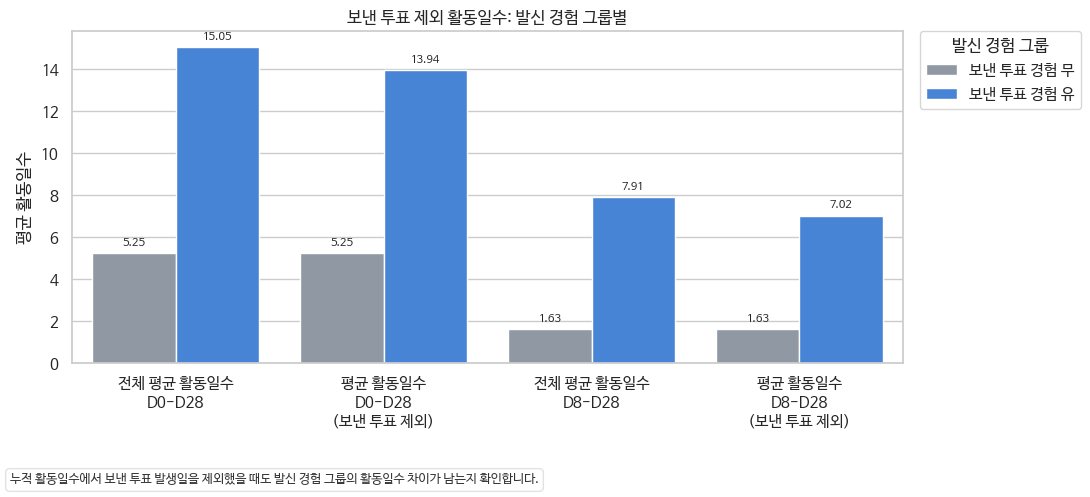

saved table: /content/sender_behavior_axis_outputs/tables/38_active_days_excl_sent_vote_by_sender_cluster.csv


#### 보낸 투표 제외 활동일수: 발신 세그먼트별

,sender_cluster_label,user_count,active_days_d0_28_mean,active_days_excl_sent_vote_d0_28_mean,active_days_d8_28_mean,active_days_excl_sent_vote_d8_28_mean,active_days_d0_28_sum,active_days_excl_sent_vote_d0_28_sum,active_days_d8_28_sum,active_days_excl_sent_vote_d8_28_sum,...,active_days_excl_sent_vote_d0_28_active_user_count,active_days_d8_28_active_user_count,active_days_excl_sent_vote_d8_28_active_user_count,sent_vote_count_d0_7_mean,active_days_d0_28_active_user_mean,active_days_d8_28_active_user_mean,active_days_excl_sent_vote_d0_28_active_user_mean,active_days_excl_sent_vote_d8_28_active_user_mean,sent_vote_removed_gap_d0_28,sent_vote_removed_gap_d8_28
2,발신 비활성형,643381,5.25,5.25,1.63,1.63,3380598.0,3380396.0,1048050.0,1047872.0,...,630258,381339,381329,0.00,5.36,2.75,5.36,2.75,0.00,0.00
0,Hackle 질문 반응형,115,1.82,1.82,0.18,0.18,209.0,209.0,21.0,21.0,...,115,16,16,0.00,1.82,1.31,1.82,1.31,0.00,0.00
1,고강도 투표 발신형,4571,15.36,14.23,8.09,7.17,70228.0,65028.0,36963.0,32786.0,...,4571,4166,4093,196.19,15.36,8.87,14.23,8.01,1.14,0.91


saved figure: /content/sender_behavior_axis_outputs/figures/32_active_days_excl_sent_vote_sender_cluster.png


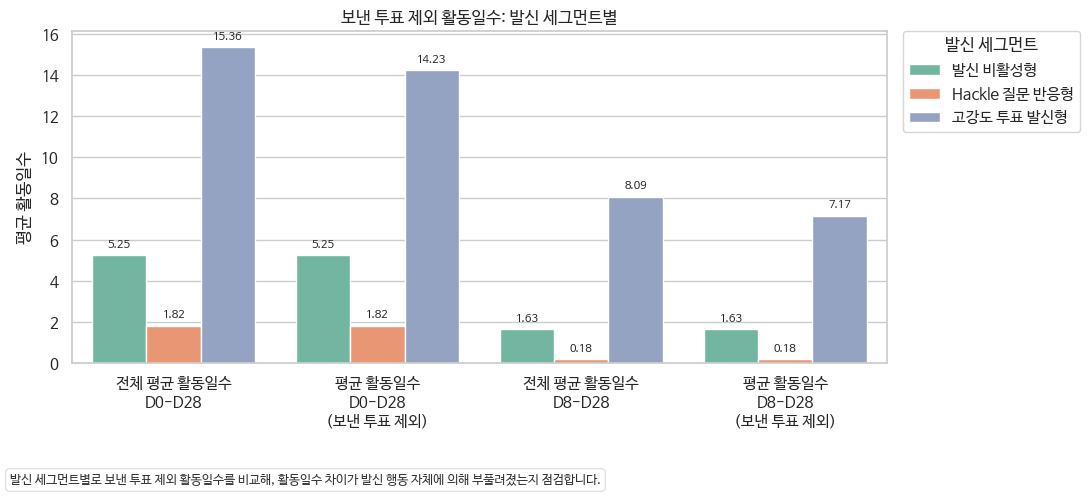

saved processed: /content/sender_behavior_axis_outputs/processed/12_sender_behavior_analysis_with_excl_sent_vote.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/12_sender_behavior_analysis_with_excl_sent_vote.csv')

In [ ]:
cell_note(
    "셀 15. 1순위 보완 분석: 보낸 투표 제외 활동일수",
    "누적 활동일수에서 보낸 투표 발생일을 제외해도 발신 경험/세그먼트별 활동성 차이가 유지되는지 확인합니다.",
    "active_days_excl_sent_vote_by_sender_group 표, active_days_excl_sent_vote_by_sender_cluster 표, PNG 2개",
)

activity_days_excl_sent_vote_long = pd.concat(
    [
        received_read_activity,
        friend_activity_days,
        point_activity_days,
    ],
    ignore_index=True,
).dropna(subset=["user_id", "activity_date"])
activity_days_excl_sent_vote_long["activity_date"] = pd.to_datetime(
    activity_days_excl_sent_vote_long["activity_date"],
    errors="coerce",
).dt.floor("D")
activity_days_excl_sent_vote_long = activity_days_excl_sent_vote_long.dropna(subset=["activity_date"]).drop_duplicates()
activity_days_excl_sent_vote_long = add_signup_offset(
    activity_days_excl_sent_vote_long,
    user_col="user_id",
    date_col="activity_date",
    users=users,
)

active_day_excl_sent_vote_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
for name in ["d0_28", "d8_28"]:
    m = window_mask(activity_days_excl_sent_vote_long["day_offset"], name)
    part = (
        activity_days_excl_sent_vote_long.loc[m]
        .groupby("user_id", as_index=False)
        .agg(**{f"active_days_excl_sent_vote_{name}": ("activity_date", "nunique")})
    )
    active_day_excl_sent_vote_metrics = active_day_excl_sent_vote_metrics.merge(part, on="user_id", how="left")

active_day_excl_sent_vote_metrics = compact_numeric_fill(active_day_excl_sent_vote_metrics)
save_processed(active_day_excl_sent_vote_metrics, "12_active_day_excl_sent_vote_metrics.csv")

excl_cols = [c for c in active_day_excl_sent_vote_metrics.columns if c != "user_id"]
analysis_df = analysis_df.drop(columns=[c for c in excl_cols if c in analysis_df.columns], errors="ignore")
analysis_df = analysis_df.merge(active_day_excl_sent_vote_metrics, on="user_id", how="left")
for col in excl_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce").fillna(0)


def summarize_active_day_exclusion(df, group_col, order=None):
    summary = (
        df.groupby(group_col, as_index=False, observed=False)
        .agg(
            user_count=("user_id", "nunique"),
            active_days_d0_28_mean=("active_days_d0_28", "mean"),
            active_days_excl_sent_vote_d0_28_mean=("active_days_excl_sent_vote_d0_28", "mean"),
            active_days_d8_28_mean=("active_days_d8_28", "mean"),
            active_days_excl_sent_vote_d8_28_mean=("active_days_excl_sent_vote_d8_28", "mean"),
            active_days_d0_28_sum=("active_days_d0_28", "sum"),
            active_days_excl_sent_vote_d0_28_sum=("active_days_excl_sent_vote_d0_28", "sum"),
            active_days_d8_28_sum=("active_days_d8_28", "sum"),
            active_days_excl_sent_vote_d8_28_sum=("active_days_excl_sent_vote_d8_28", "sum"),
            active_days_d0_28_active_user_count=("active_days_d0_28", nonzero_count),
            active_days_excl_sent_vote_d0_28_active_user_count=("active_days_excl_sent_vote_d0_28", nonzero_count),
            active_days_d8_28_active_user_count=("active_days_d8_28", nonzero_count),
            active_days_excl_sent_vote_d8_28_active_user_count=("active_days_excl_sent_vote_d8_28", nonzero_count),
            sent_vote_count_d0_7_mean=("sent_vote_count_d0_7", "mean"),
        )
        .reset_index(drop=True)
    )
    summary = add_nonzero_user_means(summary)
    numeric_cols = [c for c in summary.columns if c != group_col]
    summary[numeric_cols] = summary[numeric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    summary["sent_vote_removed_gap_d0_28"] = (
        summary["active_days_d0_28_mean"] - summary["active_days_excl_sent_vote_d0_28_mean"]
    )
    summary["sent_vote_removed_gap_d8_28"] = (
        summary["active_days_d8_28_mean"] - summary["active_days_excl_sent_vote_d8_28_mean"]
    )
    if order is not None:
        summary[group_col] = pd.Categorical(summary[group_col].astype("string"), categories=order, ordered=True)
        summary = summary.sort_values(group_col)
    return summary.round(2)


home_excl_df = analysis_df.loc[analysis_df["home_entry_population"]].copy()
home_excl_df["sender_group"] = sender_group_categorical(home_excl_df["sender_group"])
active_excl_sender_group_summary = summarize_active_day_exclusion(
    home_excl_df,
    "sender_group",
    SENDER_GROUP_ORDER,
)
save_table(
    active_excl_sender_group_summary,
    "보낸 투표 제외 활동일수: 발신 경험 그룹별",
    "active_days_excl_sent_vote_by_sender_group",
)

active_excl_group_metric_cols = [
    "active_days_d0_28_mean",
    "active_days_excl_sent_vote_d0_28_mean",
    "active_days_d8_28_mean",
    "active_days_excl_sent_vote_d8_28_mean",
]
active_excl_group_plot = active_excl_sender_group_summary.melt(
    id_vars=["sender_group"],
    value_vars=active_excl_group_metric_cols,
    var_name="metric",
    value_name="mean_days",
)
active_excl_group_plot["mean_days"] = pd.to_numeric(active_excl_group_plot["mean_days"], errors="coerce").fillna(0)
active_excl_group_plot = add_label_column(active_excl_group_plot)
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=active_excl_group_plot,
    x="metric_label",
    y="mean_days",
    hue="sender_group",
    ax=ax,
    order=[label_for(c) for c in active_excl_group_metric_cols],
    hue_order=SENDER_GROUP_ORDER,
    palette=SENDER_GROUP_PALETTE,
)
ax.set_title("보낸 투표 제외 활동일수: 발신 경험 그룹별")
ax.set_xlabel("")
ax.set_ylabel("평균 활동일수")
ax.legend(title="발신 경험 그룹", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
add_bar_labels(ax, decimals=2)
save_fig("보낸 투표 제외 활동일수: 발신 경험 그룹별", "active_days_excl_sent_vote_sender_group", fig)

active_excl_sender_cluster_summary = pd.DataFrame()
if "sender_cluster_label" in home_excl_df.columns and home_excl_df["sender_cluster_label"].notna().any():
    home_excl_df["sender_cluster_label"] = home_excl_df["sender_cluster_label"].astype("string")
    active_excl_sender_cluster_summary = summarize_active_day_exclusion(home_excl_df, "sender_cluster_label")
    if "cluster_order" in globals():
        active_cluster_order = [
            label
            for label in cluster_order
            if label in active_excl_sender_cluster_summary["sender_cluster_label"].astype("string").tolist()
        ]
    else:
        active_cluster_order = sorted(active_excl_sender_cluster_summary["sender_cluster_label"].astype("string").dropna().unique())
    active_excl_sender_cluster_summary["sender_cluster_label"] = pd.Categorical(
        active_excl_sender_cluster_summary["sender_cluster_label"].astype("string"),
        categories=active_cluster_order,
        ordered=True,
    )
    active_excl_sender_cluster_summary = active_excl_sender_cluster_summary.sort_values("sender_cluster_label")
    save_table(
        active_excl_sender_cluster_summary,
        "보낸 투표 제외 활동일수: 발신 세그먼트별",
        "active_days_excl_sent_vote_by_sender_cluster",
    )

    active_excl_cluster_plot = active_excl_sender_cluster_summary.melt(
        id_vars=["sender_cluster_label"],
        value_vars=active_excl_group_metric_cols,
        var_name="metric",
        value_name="mean_days",
    )
    active_excl_cluster_plot["mean_days"] = pd.to_numeric(
        active_excl_cluster_plot["mean_days"],
        errors="coerce",
    ).fillna(0)
    active_excl_cluster_plot = add_label_column(active_excl_cluster_plot)
    active_cluster_palette = build_cluster_palette(active_cluster_order)
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(
        data=active_excl_cluster_plot,
        x="metric_label",
        y="mean_days",
        hue="sender_cluster_label",
        ax=ax,
        order=[label_for(c) for c in active_excl_group_metric_cols],
        hue_order=active_cluster_order,
        palette=active_cluster_palette,
    )
    ax.set_title("보낸 투표 제외 활동일수: 발신 세그먼트별")
    ax.set_xlabel("")
    ax.set_ylabel("평균 활동일수")
    ax.legend(title="발신 세그먼트", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    add_bar_labels(ax, decimals=2)
    save_fig("보낸 투표 제외 활동일수: 발신 세그먼트별", "active_days_excl_sent_vote_sender_cluster", fig)

save_processed(analysis_df, "12_sender_behavior_analysis_with_excl_sent_vote.csv")

# ## 셀2-16. 2순위 보완 분석: 보낸 투표 수 강도 구간

### 셀 16. 2순위 보완 분석: 보낸 투표 수 강도 구간
- **목적**: 보낸 투표 경험을 유/무로만 보지 않고 D0-D7 보낸 투표 수 강도 구간별로 결과 지표가 어떻게 달라지는지 확인합니다.
- **산출물**: sent_vote_intensity_bucket_summary 표, PNG 3~4개

saved table: /content/sender_behavior_axis_outputs/tables/29_sent_vote_intensity_bucket_summary.csv


#### D0-D7 보낸 투표 수 강도 구간별 결과

,sent_vote_intensity_bucket_d0_7,user_count,retention_d1_28_rate,retention_d8_28_rate,payment_d0_28_count_mean,payment_d8_28_count_mean,payment_d0_28_count_sum,payment_d8_28_count_sum,payment_d0_28_amount_mean,payment_d8_28_amount_mean,...,active_days_excl_sent_vote_d0_28_mean,active_days_excl_sent_vote_d8_28_mean,payment_d0_28_count_paid_user_mean,payment_d0_28_amount_paid_user_mean,payment_d8_28_count_paid_user_mean,payment_d8_28_amount_paid_user_mean,active_days_d0_28_active_user_mean,active_days_d8_28_active_user_mean,sent_vote_count_d0_7_sender_mean,sent_vote_active_days_d0_7_sender_mean
0,0회,643306,45.39,41.60,0.13,0.04,86494.0,23470.0,108.14,28.68,...,5.25,1.63,1.58,1273.28,1.46,1145.66,5.36,2.75,0.0,0.00
1,1-3회,67,16.42,14.93,0.01,0.01,1.0,1.0,14.93,14.93,...,5.07,2.00,1.00,1000.0,1.00,1000.0,5.36,5.44,1.9,1.12
2,4-10회,136,16.18,13.97,0.04,0.03,5.0,4.0,20.08,14.37,...,5.88,2.38,1.67,910.33,2.00,977.0,6.40,5.91,7.4,1.57
3,11-50회,593,23.95,21.08,0.08,0.02,45.0,10.0,55.91,11.91,...,10.46,4.81,1.55,1143.31,1.25,882.75,11.39,6.86,31.3,3.50
4,51회 이상,3965,39.55,38.11,0.13,0.03,518.0,129.0,100.31,25.66,...,14.88,7.59,1.51,1162.92,1.36,1070.92,16.06,9.16,221.5,6.41


saved figure: /content/sender_behavior_axis_outputs/figures/20_sent_vote_intensity_outcome_rates.png


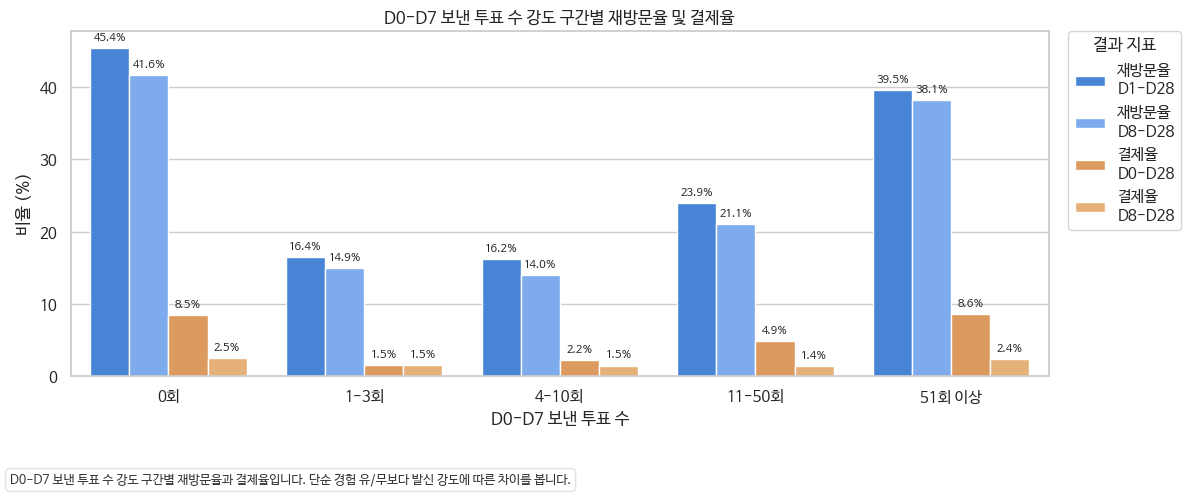

saved figure: /content/sender_behavior_axis_outputs/figures/21_sent_vote_intensity_payment_count.png


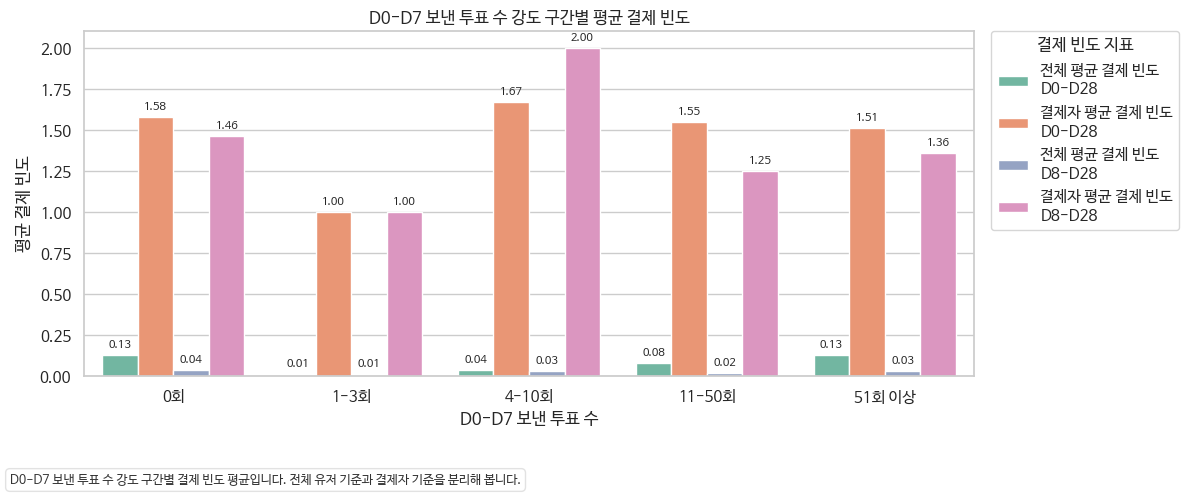

saved figure: /content/sender_behavior_axis_outputs/figures/22_sent_vote_intensity_payment_amount.png


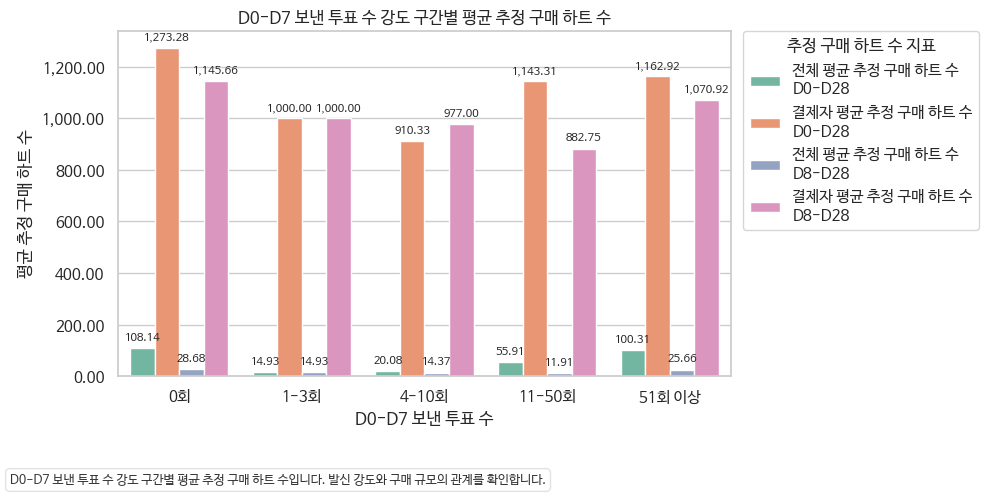

saved figure: /content/sender_behavior_axis_outputs/figures/23_sent_vote_intensity_active_days.png


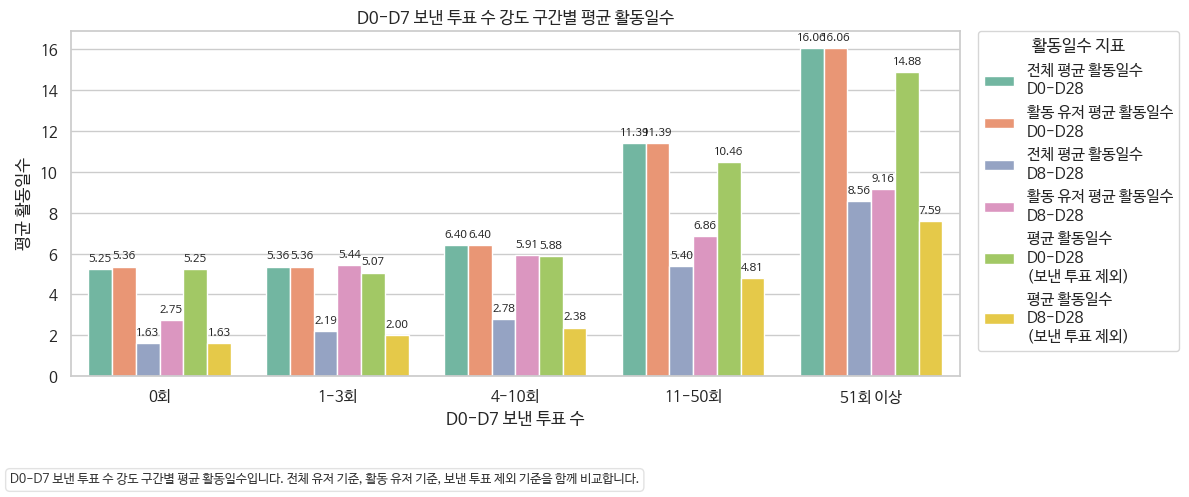

saved processed: /content/sender_behavior_axis_outputs/processed/13_sender_behavior_analysis_with_additional_segments.csv


PosixPath('/content/sender_behavior_axis_outputs/processed/13_sender_behavior_analysis_with_additional_segments.csv')

In [ ]:
cell_note(
    "셀 16. 2순위 보완 분석: 보낸 투표 수 강도 구간",
    "보낸 투표 경험을 유/무로만 보지 않고 D0-D7 보낸 투표 수 강도 구간별로 결과 지표가 어떻게 달라지는지 확인합니다.",
    "sent_vote_intensity_bucket_summary 표, PNG 3~4개",
)

if "SENT_VOTE_INTENSITY_ORDER" not in globals():
    SENT_VOTE_INTENSITY_ORDER = ["0회", "1-3회", "4-10회", "11-50회", "51회 이상"]

sent_vote_count_for_bucket = pd.to_numeric(analysis_df["sent_vote_count_d0_7"], errors="coerce").fillna(0)
analysis_df["sent_vote_intensity_bucket_d0_7"] = pd.cut(
    sent_vote_count_for_bucket,
    bins=[-0.1, 0, 3, 10, 50, np.inf],
    labels=SENT_VOTE_INTENSITY_ORDER,
    ordered=True,
)

home_intensity_df = analysis_df.loc[analysis_df["home_entry_population"]].copy()
for col in ["payment_amount_d0_28", "payment_amount_d8_28"]:
    if col not in home_intensity_df.columns:
        home_intensity_df[col] = 0
home_intensity_df["sent_vote_intensity_bucket_d0_7"] = pd.Categorical(
    home_intensity_df["sent_vote_intensity_bucket_d0_7"],
    categories=SENT_VOTE_INTENSITY_ORDER,
    ordered=True,
)

intensity_agg = {
    "user_count": ("user_id", "nunique"),
    "retention_d1_28_rate": ("retention_d1_28", rate),
    "retention_d8_28_rate": ("retention_d8_28", rate),
    "payment_d0_28_count_mean": ("payment_count_d0_28", "mean"),
    "payment_d8_28_count_mean": ("payment_count_d8_28", "mean"),
    "payment_d0_28_count_sum": ("payment_count_d0_28", "sum"),
    "payment_d8_28_count_sum": ("payment_count_d8_28", "sum"),
    "payment_d0_28_amount_mean": ("payment_amount_d0_28", "mean"),
    "payment_d8_28_amount_mean": ("payment_amount_d8_28", "mean"),
    "payment_d0_28_amount_sum": ("payment_amount_d0_28", "sum"),
    "payment_d8_28_amount_sum": ("payment_amount_d8_28", "sum"),
    "payment_d0_28_paid_user_count": ("paid_flag_d0_28", "sum"),
    "payment_d8_28_paid_user_count": ("paid_flag_d8_28", "sum"),
    "payment_d0_28_rate": ("paid_flag_d0_28", rate),
    "payment_d8_28_rate": ("paid_flag_d8_28", rate),
    "active_days_d0_28_mean": ("active_days_d0_28", "mean"),
    "active_days_d8_28_mean": ("active_days_d8_28", "mean"),
    "active_days_d0_28_sum": ("active_days_d0_28", "sum"),
    "active_days_d8_28_sum": ("active_days_d8_28", "sum"),
    "active_days_d0_28_active_user_count": ("active_days_d0_28", nonzero_count),
    "active_days_d8_28_active_user_count": ("active_days_d8_28", nonzero_count),
    "sent_vote_count_d0_7_mean": ("sent_vote_count_d0_7", "mean"),
    "sent_vote_count_d0_7_sum": ("sent_vote_count_d0_7", "sum"),
    "sent_vote_user_count_d0_7": ("sent_vote_count_d0_7", nonzero_count),
    "sent_vote_active_days_d0_7_mean": ("sent_vote_active_days_d0_7", "mean"),
    "sent_vote_active_days_d0_7_sum": ("sent_vote_active_days_d0_7", "sum"),
}
if {"active_days_excl_sent_vote_d0_28", "active_days_excl_sent_vote_d8_28"}.issubset(home_intensity_df.columns):
    intensity_agg.update(
        {
            "active_days_excl_sent_vote_d0_28_mean": ("active_days_excl_sent_vote_d0_28", "mean"),
            "active_days_excl_sent_vote_d8_28_mean": ("active_days_excl_sent_vote_d8_28", "mean"),
        }
    )

sent_vote_intensity_summary = (
    home_intensity_df.groupby("sent_vote_intensity_bucket_d0_7", as_index=False, observed=False)
    .agg(**intensity_agg)
    .sort_values("sent_vote_intensity_bucket_d0_7")
    .round(2)
)
sent_vote_intensity_summary = add_adjusted_mean_columns(sent_vote_intensity_summary).round(2)
intensity_count_cols = [c for c in sent_vote_intensity_summary.columns if c.endswith("_count")]
sent_vote_intensity_summary[intensity_count_cols] = sent_vote_intensity_summary[intensity_count_cols].astype("int64")
if not globals().get("PAYMENT_AMOUNT_AVAILABLE", False):
    sent_vote_intensity_summary = sent_vote_intensity_summary.drop(
        columns=[
            "payment_d0_28_amount_mean",
            "payment_d8_28_amount_mean",
            "payment_d0_28_amount_paid_user_mean",
            "payment_d8_28_amount_paid_user_mean",
            "payment_d0_28_amount_sum",
            "payment_d8_28_amount_sum",
        ],
        errors="ignore",
    )
save_table(
    sent_vote_intensity_summary,
    "D0-D7 보낸 투표 수 강도 구간별 결과",
    "sent_vote_intensity_bucket_summary",
    n=20,
)

intensity_rate_metric_cols = ["retention_d1_28_rate", "retention_d8_28_rate", "payment_d0_28_rate", "payment_d8_28_rate"]
intensity_rate_plot = sent_vote_intensity_summary.melt(
    id_vars=["sent_vote_intensity_bucket_d0_7"],
    value_vars=intensity_rate_metric_cols,
    var_name="metric",
    value_name="rate_pct",
)
intensity_rate_plot["rate_pct"] = pd.to_numeric(intensity_rate_plot["rate_pct"], errors="coerce").fillna(0)
intensity_rate_plot = add_label_column(intensity_rate_plot)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=intensity_rate_plot,
    x="sent_vote_intensity_bucket_d0_7",
    y="rate_pct",
    hue="metric_label",
    ax=ax,
    order=SENT_VOTE_INTENSITY_ORDER,
    hue_order=[label_for(c) for c in intensity_rate_metric_cols],
    palette=[MAIN_COLOR, "#6BA7FF", SECONDARY_COLOR, "#F7B267"],
)
ax.set_title("D0-D7 보낸 투표 수 강도 구간별 재방문율 및 결제율")
ax.set_xlabel("D0-D7 보낸 투표 수")
ax.set_ylabel("비율 (%)")
ax.legend(title="결과 지표", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
add_bar_labels(ax, decimals=1, suffix="%")
save_fig("D0-D7 보낸 투표 수 강도 구간별 재방문율 및 결제율", "sent_vote_intensity_outcome_rates", fig)

intensity_payment_count_metric_cols = [
    "payment_d0_28_count_mean",
    "payment_d0_28_count_paid_user_mean",
    "payment_d8_28_count_mean",
    "payment_d8_28_count_paid_user_mean",
]
intensity_payment_count_plot = sent_vote_intensity_summary.melt(
    id_vars=["sent_vote_intensity_bucket_d0_7"],
    value_vars=[c for c in intensity_payment_count_metric_cols if c in sent_vote_intensity_summary.columns],
    var_name="metric",
    value_name="mean_count",
)
intensity_payment_count_plot["mean_count"] = pd.to_numeric(
    intensity_payment_count_plot["mean_count"],
    errors="coerce",
).fillna(0)
intensity_payment_count_plot = add_label_column(intensity_payment_count_plot)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=intensity_payment_count_plot,
    x="sent_vote_intensity_bucket_d0_7",
    y="mean_count",
    hue="metric_label",
    ax=ax,
    order=SENT_VOTE_INTENSITY_ORDER,
    hue_order=[label_for(c) for c in intensity_payment_count_metric_cols if c in sent_vote_intensity_summary.columns],
    palette=sns.color_palette("Set2", n_colors=len([c for c in intensity_payment_count_metric_cols if c in sent_vote_intensity_summary.columns])),
)
ax.set_title("D0-D7 보낸 투표 수 강도 구간별 평균 결제 빈도")
ax.set_xlabel("D0-D7 보낸 투표 수")
ax.set_ylabel("평균 결제 빈도")
ax.legend(title="결제 빈도 지표", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
format_decimal_axis(ax, decimals=2)
add_bar_labels(ax, decimals=2)
save_fig("D0-D7 보낸 투표 수 강도 구간별 평균 결제 빈도", "sent_vote_intensity_payment_count", fig)

intensity_payment_amount_metric_cols = [
    "payment_d0_28_amount_mean",
    "payment_d0_28_amount_paid_user_mean",
    "payment_d8_28_amount_mean",
    "payment_d8_28_amount_paid_user_mean",
]
intensity_payment_amount_available = (
    globals().get("PAYMENT_AMOUNT_AVAILABLE", False)
    and set(intensity_payment_amount_metric_cols).issubset(sent_vote_intensity_summary.columns)
    and sent_vote_intensity_summary[intensity_payment_amount_metric_cols].apply(pd.to_numeric, errors="coerce").fillna(0).abs().sum().sum() > 0
)
if intensity_payment_amount_available:
    intensity_payment_amount_plot = sent_vote_intensity_summary.melt(
        id_vars=["sent_vote_intensity_bucket_d0_7"],
        value_vars=intensity_payment_amount_metric_cols,
        var_name="metric",
        value_name="mean_amount",
    )
    intensity_payment_amount_plot["mean_amount"] = pd.to_numeric(
        intensity_payment_amount_plot["mean_amount"],
        errors="coerce",
    ).fillna(0)
    intensity_payment_amount_plot = add_label_column(intensity_payment_amount_plot)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=intensity_payment_amount_plot,
        x="sent_vote_intensity_bucket_d0_7",
        y="mean_amount",
        hue="metric_label",
        ax=ax,
        order=SENT_VOTE_INTENSITY_ORDER,
        hue_order=[label_for(c) for c in intensity_payment_amount_metric_cols],
        palette=sns.color_palette("Set2", n_colors=len(intensity_payment_amount_metric_cols)),
    )
    ax.set_title(f"D0-D7 보낸 투표 수 강도 구간별 평균 {PAYMENT_VALUE_LABEL}")
    ax.set_xlabel("D0-D7 보낸 투표 수")
    ax.set_ylabel(f"평균 {PAYMENT_VALUE_LABEL}")
    ax.legend(title=f"{PAYMENT_VALUE_LABEL} 지표", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    format_decimal_axis(ax, decimals=2)
    add_bar_labels(ax, decimals=2)
    save_fig(f"D0-D7 보낸 투표 수 강도 구간별 평균 {PAYMENT_VALUE_LABEL}", "sent_vote_intensity_payment_amount", fig)
else:
    remove_previous_outputs(FIG_DIR, "sent_vote_intensity_payment_amount", "png")
    print("결제 규모 후보가 확인되지 않아 보낸 투표 수 강도 구간별 평균 결제 규모 그래프를 생성하지 않습니다.")

intensity_active_metric_cols = [
    "active_days_d0_28_mean",
    "active_days_d0_28_active_user_mean",
    "active_days_d8_28_mean",
    "active_days_d8_28_active_user_mean",
]
if "active_days_excl_sent_vote_d0_28_mean" in sent_vote_intensity_summary.columns:
    intensity_active_metric_cols += [
        "active_days_excl_sent_vote_d0_28_mean",
        "active_days_excl_sent_vote_d8_28_mean",
    ]
intensity_active_plot = sent_vote_intensity_summary.melt(
    id_vars=["sent_vote_intensity_bucket_d0_7"],
    value_vars=intensity_active_metric_cols,
    var_name="metric",
    value_name="mean_days",
)
intensity_active_plot["mean_days"] = pd.to_numeric(intensity_active_plot["mean_days"], errors="coerce").fillna(0)
intensity_active_plot = add_label_column(intensity_active_plot)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=intensity_active_plot,
    x="sent_vote_intensity_bucket_d0_7",
    y="mean_days",
    hue="metric_label",
    ax=ax,
    order=SENT_VOTE_INTENSITY_ORDER,
    hue_order=[label_for(c) for c in intensity_active_metric_cols],
    palette=sns.color_palette("Set2", n_colors=len(intensity_active_metric_cols)),
)
ax.set_title("D0-D7 보낸 투표 수 강도 구간별 평균 활동일수")
ax.set_xlabel("D0-D7 보낸 투표 수")
ax.set_ylabel("평균 활동일수")
ax.legend(title="활동일수 지표", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
add_bar_labels(ax, decimals=2)
save_fig("D0-D7 보낸 투표 수 강도 구간별 평균 활동일수", "sent_vote_intensity_active_days", fig)

save_processed(analysis_df, "13_sender_behavior_analysis_with_additional_segments.csv")

# ## 셀2-16-1. 최종 해석 요약

In [ ]:
cell_note(
    "셀 16-1. 최종 해석 요약",
    "발신 경험 그룹 비교, 발신 단독 클러스터링, 보완 분석 결과를 제출용 문장으로 요약합니다.",
    "FINAL_INTERPRETATION_MARKDOWN, final_interpretation_summary 표",
)

final_interpretation_lines = []
final_interpretation_rows = []

PAYMENT_AMOUNT_AVAILABLE_FOR_REPORT = bool(globals().get("PAYMENT_AMOUNT_AVAILABLE", False))

final_interpretation_lines.append("## 최종 해석 요약")
final_interpretation_lines.append("")
final_interpretation_lines.append("### 분석 개요")
final_interpretation_lines.append("- 분석축: 발신 행동축")
final_interpretation_lines.append("- 핵심 변수: D0-D7 보낸 투표 경험")
final_interpretation_lines.append("- 메인 모집단: 홈화면 진입 조건 충족 유저")
if PAYMENT_AMOUNT_AVAILABLE_FOR_REPORT:
    final_interpretation_lines.append(f"- 기본 결과 지표: 재방문 D1-D28, 결제 빈도/여부/{PAYMENT_VALUE_LABEL} D0-D28, 누적 활동일수 D0-D28")
    final_interpretation_lines.append(f"- 보조 결과 지표: 재방문/결제 빈도/여부/{PAYMENT_VALUE_LABEL}/누적 활동일수 D8-D28")
    final_interpretation_lines.append("- 평균 지표 해석: 결제 빈도/규모는 전체 유저 기준과 결제자 기준, 활동일수는 전체 유저 기준과 활동 유저 기준을 함께 확인")
    final_interpretation_lines.append(f"- 결제 규모 후보 원천: {PAYMENT_AMOUNT_SOURCE} ({PAYMENT_VALUE_SOURCE_NOTE})")
else:
    final_interpretation_lines.append("- 기본 결과 지표: 재방문 D1-D28, 결제 빈도/여부 D0-D28, 누적 활동일수 D0-D28")
    final_interpretation_lines.append("- 보조 결과 지표: 재방문/결제 빈도/여부/누적 활동일수 D8-D28")
    final_interpretation_lines.append("- 결제 규모: 결제 테이블에서 사용할 수 있는 금액/하트 수 후보를 확인하지 못해 분석/시각화에서 제외")
final_interpretation_lines.append("")

if "home_summary" in globals() and not home_summary.empty:
    final_interpretation_lines.append("### 발신 경험 그룹 비교")
    display_cols = [
        "sender_group",
        "user_count",
        "retention_d1_28_rate",
        "retention_d8_28_rate",
        "payment_d0_28_rate",
        "payment_d8_28_rate",
        "payment_d0_28_count_mean",
        "payment_d0_28_count_paid_user_mean",
        "payment_d0_28_amount_mean",
        "payment_d0_28_amount_paid_user_mean",
        "payment_d8_28_amount_mean",
        "active_days_d0_28_mean",
        "active_days_d0_28_active_user_mean",
        "active_days_d8_28_mean",
        "sent_vote_count_d0_7_mean",
        "sent_vote_count_d0_7_sender_mean",
    ]
    hs = home_summary[[c for c in display_cols if c in home_summary.columns]].copy()
    for _, row in hs.iterrows():
        amount_text = ""
        amount_summary_text = ""
        if PAYMENT_AMOUNT_AVAILABLE_FOR_REPORT and {"payment_d0_28_amount_mean", "payment_d8_28_amount_mean"}.issubset(hs.columns):
            amount_text = (
                f", 전체 평균 {PAYMENT_VALUE_LABEL} D0-D28 {row['payment_d0_28_amount_mean']:.2f}, "
                f"결제자 평균 {PAYMENT_VALUE_LABEL} D0-D28 {row['payment_d0_28_amount_paid_user_mean']:.2f}"
            )
            amount_summary_text = (
                f", D0-D28 전체 평균 {PAYMENT_VALUE_LABEL} {row['payment_d0_28_amount_mean']:.2f}, "
                f"결제자 평균 {PAYMENT_VALUE_LABEL} {row['payment_d0_28_amount_paid_user_mean']:.2f}"
            )
        final_interpretation_lines.append(
            "- "
            f"{row['sender_group']}: "
            f"유저 수 {row['user_count']:,.0f}명, "
            f"재방문율 D1-D28 {row['retention_d1_28_rate']:.2f}%, "
            f"D8-D28 {row['retention_d8_28_rate']:.2f}%, "
            f"결제율 D0-D28 {row['payment_d0_28_rate']:.2f}%, "
            f"D8-D28 {row['payment_d8_28_rate']:.2f}%"
            f"{amount_text}, "
            f"전체 평균 결제 빈도 D0-D28 {row['payment_d0_28_count_mean']:.2f}회, "
            f"결제자 평균 결제 빈도 D0-D28 {row['payment_d0_28_count_paid_user_mean']:.2f}회, "
            f"전체 평균 활동일수 D0-D28 {row['active_days_d0_28_mean']:.2f}일, "
            f"활동 유저 평균 활동일수 D0-D28 {row['active_days_d0_28_active_user_mean']:.2f}일"
        )
        final_interpretation_rows.append(
            {
                "section": "발신 경험 그룹 비교",
                "item": row["sender_group"],
                "summary": (
                    f"유저 수 {row['user_count']:,.0f}명, "
                    f"D1-D28 재방문율 {row['retention_d1_28_rate']:.2f}%, "
                    f"D0-D28 결제율 {row['payment_d0_28_rate']:.2f}%"
                    f"{amount_summary_text}, "
                    f"D0-D28 전체 평균 활동일수 {row['active_days_d0_28_mean']:.2f}일, "
                    f"활동 유저 평균 활동일수 {row['active_days_d0_28_active_user_mean']:.2f}일"
                ),
            }
        )

    with_exp = home_summary.loc[home_summary["sender_group"].astype("string").eq("보낸 투표 경험 유")]
    without_exp = home_summary.loc[home_summary["sender_group"].astype("string").eq("보낸 투표 경험 무")]
    if not with_exp.empty and not without_exp.empty and with_exp.iloc[0]["user_count"] > 0 and without_exp.iloc[0]["user_count"] > 0:
        a = with_exp.iloc[0]
        b = without_exp.iloc[0]
        amount_diff_text = ""
        if PAYMENT_AMOUNT_AVAILABLE_FOR_REPORT and "payment_d0_28_amount_mean" in home_summary.columns:
            amount_diff_text = (
                f", D0-D28 전체 평균 {PAYMENT_VALUE_LABEL}은 "
                f"{a['payment_d0_28_amount_mean'] - b['payment_d0_28_amount_mean']:+.2f} 차이, "
                f"결제자 평균 {PAYMENT_VALUE_LABEL}은 "
                f"{a['payment_d0_28_amount_paid_user_mean'] - b['payment_d0_28_amount_paid_user_mean']:+.2f} 차이"
            )
        final_interpretation_lines.append("")
        final_interpretation_lines.append(
            "- 관찰 결과: 보낸 투표 경험 유저는 경험 무 유저보다 "
            f"D0-D28 평균 활동일수가 {a['active_days_d0_28_mean'] - b['active_days_d0_28_mean']:+.2f}일 높지만, "
            f"D1-D28 재방문율은 {a['retention_d1_28_rate'] - b['retention_d1_28_rate']:+.2f}%p, "
            f"D0-D28 결제율은 {a['payment_d0_28_rate'] - b['payment_d0_28_rate']:+.2f}%p"
            f"{amount_diff_text}로 나타났습니다."
        )
        final_interpretation_lines.append(
            "- 해석: 발신 행동 경험자는 활동 강도는 높지만, 이 비교만으로 발신 행동이 재방문이나 결제를 높인다고 단정하기 어렵습니다."
        )
    final_interpretation_lines.append("")

if "sender_k_df" in globals() and not sender_k_df.empty:
    selected_k_rows = sender_k_df.loc[sender_k_df["selected_k"]] if "selected_k" in sender_k_df.columns else pd.DataFrame()
    if not selected_k_rows.empty:
        selected_k_row = selected_k_rows.iloc[0]
        final_interpretation_lines.append("### 클러스터링 k 선택")
        final_interpretation_lines.append(
            "- 최종 k: "
            f"{int(selected_k_row['k'])} "
            f"({selected_k_row.get('selection_reason', '선택 사유 미기록')})"
        )
        final_interpretation_lines.append(
            "- 판단 기준: 실루엣 점수만 보지 않고, elbow, 최소 군집 비율, 군집별 해석 가능성을 함께 고려했습니다."
        )
        final_interpretation_lines.append("")

if "sender_cluster_outcome" in globals() and not sender_cluster_outcome.empty:
    final_interpretation_lines.append("### 발신 단독 클러스터링 결과")
    cluster_display_cols = [
        "sender_cluster_label",
        "user_count",
        "retention_d1_28_rate",
        "retention_d8_28_rate",
        "payment_d0_28_rate",
        "payment_d8_28_rate",
        "payment_d0_28_count_mean",
        "payment_d0_28_count_paid_user_mean",
        "payment_d0_28_amount_mean",
        "payment_d0_28_amount_paid_user_mean",
        "payment_d8_28_amount_mean",
        "active_days_d0_28_mean",
        "active_days_d0_28_active_user_mean",
        "active_days_d8_28_mean",
        "sent_vote_count_d0_7_mean",
        "sent_vote_count_d0_7_sender_mean",
        "sent_vote_active_days_d0_7_mean",
        "sent_vote_distinct_chosen_users_d0_7_mean",
        "cluster_profile_summary",
    ]
    sco = sender_cluster_outcome[[c for c in cluster_display_cols if c in sender_cluster_outcome.columns]].copy()
    for _, row in sco.iterrows():
        amount_text = ""
        amount_summary_text = ""
        if PAYMENT_AMOUNT_AVAILABLE_FOR_REPORT and "payment_d0_28_amount_mean" in sco.columns:
            amount_text = (
                f", 전체 평균 {PAYMENT_VALUE_LABEL} D0-D28 {row['payment_d0_28_amount_mean']:.2f}, "
                f"결제자 평균 {PAYMENT_VALUE_LABEL} D0-D28 {row['payment_d0_28_amount_paid_user_mean']:.2f}"
            )
            amount_summary_text = (
                f", D0-D28 전체 평균 {PAYMENT_VALUE_LABEL} {row['payment_d0_28_amount_mean']:.2f}, "
                f"결제자 평균 {PAYMENT_VALUE_LABEL} {row['payment_d0_28_amount_paid_user_mean']:.2f}"
            )
        final_interpretation_lines.append(
            "- "
            f"{row['sender_cluster_label']}: "
            f"유저 수 {row['user_count']:,.0f}명, "
            f"D0-D7 전체 평균 보낸 투표 {row['sent_vote_count_d0_7_mean']:.2f}회, "
            f"발신 유저 평균 보낸 투표 {row['sent_vote_count_d0_7_sender_mean']:.2f}회, "
            f"전체 평균 활동일수 D0-D28 {row['active_days_d0_28_mean']:.2f}일, "
            f"활동 유저 평균 활동일수 {row['active_days_d0_28_active_user_mean']:.2f}일, "
            f"재방문율 D1-D28 {row['retention_d1_28_rate']:.2f}%, "
            f"결제율 D0-D28 {row['payment_d0_28_rate']:.2f}%"
            f"{amount_text}"
        )
        if "cluster_profile_summary" in row and pd.notna(row["cluster_profile_summary"]):
            final_interpretation_lines.append(f"  - 프로파일: {row['cluster_profile_summary']}")
        final_interpretation_rows.append(
            {
                "section": "발신 단독 클러스터링 결과",
                "item": row["sender_cluster_label"],
                "summary": (
                    f"유저 수 {row['user_count']:,.0f}명, "
                    f"D0-D7 전체 평균 보낸 투표 {row['sent_vote_count_d0_7_mean']:.2f}회, "
                    f"발신 유저 평균 보낸 투표 {row['sent_vote_count_d0_7_sender_mean']:.2f}회, "
                    f"D0-D28 전체 평균 활동일수 {row['active_days_d0_28_mean']:.2f}일, "
                    f"활동 유저 평균 활동일수 {row['active_days_d0_28_active_user_mean']:.2f}일, "
                    f"D1-D28 재방문율 {row['retention_d1_28_rate']:.2f}%, "
                    f"D0-D28 결제율 {row['payment_d0_28_rate']:.2f}%"
                    f"{amount_summary_text}"
                ),
            }
        )
    final_interpretation_lines.append("")

if "active_excl_sender_group_summary" in globals() and not active_excl_sender_group_summary.empty:
    final_interpretation_lines.append("### 1순위 보완 분석: 보낸 투표 제외 활동일수")
    for _, row in active_excl_sender_group_summary.iterrows():
        final_interpretation_lines.append(
            "- "
            f"{row['sender_group']}: "
            f"보낸 투표 포함 활동일수 D0-D28 {row['active_days_d0_28_mean']:.2f}일, "
            f"보낸 투표 제외 {row['active_days_excl_sent_vote_d0_28_mean']:.2f}일, "
            f"차이 {row['sent_vote_removed_gap_d0_28']:+.2f}일"
        )
        final_interpretation_rows.append(
            {
                "section": "보낸 투표 제외 활동일수",
                "item": str(row["sender_group"]),
                "summary": (
                    f"포함 D0-D28 {row['active_days_d0_28_mean']:.2f}일, "
                    f"제외 D0-D28 {row['active_days_excl_sent_vote_d0_28_mean']:.2f}일, "
                    f"차이 {row['sent_vote_removed_gap_d0_28']:+.2f}일"
                ),
            }
        )
    final_interpretation_lines.append(
        "- 해석 포인트: 보낸 투표가 활동일수 정의에 포함되어 있으므로, 제외 지표를 함께 보면 발신 행동 자체가 만든 활동일수 증가분과 다른 활동의 동반 여부를 분리해서 볼 수 있습니다."
    )
    final_interpretation_lines.append("")

if "sent_vote_intensity_summary" in globals() and not sent_vote_intensity_summary.empty:
    final_interpretation_lines.append("### 2순위 보완 분석: 보낸 투표 수 강도 구간")
    for _, row in sent_vote_intensity_summary.iterrows():
        amount_text = ""
        amount_summary_text = ""
        if PAYMENT_AMOUNT_AVAILABLE_FOR_REPORT and "payment_d0_28_amount_mean" in sent_vote_intensity_summary.columns:
            amount_text = (
                f", 전체 평균 {PAYMENT_VALUE_LABEL} D0-D28 {row['payment_d0_28_amount_mean']:.2f}, "
                f"결제자 평균 {PAYMENT_VALUE_LABEL} D0-D28 {row['payment_d0_28_amount_paid_user_mean']:.2f}"
            )
            amount_summary_text = (
                f", D0-D28 전체 평균 {PAYMENT_VALUE_LABEL} {row['payment_d0_28_amount_mean']:.2f}, "
                f"결제자 평균 {PAYMENT_VALUE_LABEL} {row['payment_d0_28_amount_paid_user_mean']:.2f}"
            )
        final_interpretation_lines.append(
            "- "
            f"{row['sent_vote_intensity_bucket_d0_7']}: "
            f"유저 수 {row['user_count']:,.0f}명, "
            f"재방문율 D1-D28 {row['retention_d1_28_rate']:.2f}%, "
            f"결제율 D0-D28 {row['payment_d0_28_rate']:.2f}%"
            f"{amount_text}, "
            f"전체 평균 결제 빈도 D0-D28 {row['payment_d0_28_count_mean']:.2f}회, "
            f"결제자 평균 결제 빈도 D0-D28 {row['payment_d0_28_count_paid_user_mean']:.2f}회, "
            f"전체 평균 활동일수 D0-D28 {row['active_days_d0_28_mean']:.2f}일, "
            f"활동 유저 평균 활동일수 {row['active_days_d0_28_active_user_mean']:.2f}일"
        )
        final_interpretation_rows.append(
            {
                "section": "보낸 투표 수 강도 구간",
                "item": str(row["sent_vote_intensity_bucket_d0_7"]),
                "summary": (
                    f"유저 수 {row['user_count']:,.0f}명, "
                    f"D1-D28 재방문율 {row['retention_d1_28_rate']:.2f}%, "
                    f"D0-D28 결제율 {row['payment_d0_28_rate']:.2f}%"
                    f"{amount_summary_text}, "
                    f"D0-D28 전체 평균 활동일수 {row['active_days_d0_28_mean']:.2f}일, "
                    f"활동 유저 평균 활동일수 {row['active_days_d0_28_active_user_mean']:.2f}일"
                ),
            }
        )
    final_interpretation_lines.append(
        "- 해석 포인트: 보낸 투표 경험 유/무만으로는 발신 강도의 차이를 놓칠 수 있어, 1-3회와 51회 이상 같은 강도 구간을 함께 보는 것이 좋습니다."
    )
    final_interpretation_lines.append("")

if "sender_cluster_name_mapping" in globals() and not sender_cluster_name_mapping.empty:
    if "label_rule" in sender_cluster_name_mapping.columns:
        final_interpretation_lines.append(
            "- 참고: 발신 단독 클러스터명은 numeric cluster id가 아니라 "
            "`sender_cluster_name_mapping`의 원변수 프로파일과 `label_rule`을 기준으로 부여했습니다."
        )
        final_interpretation_lines.append("")
    elif not sender_cluster_name_mapping["custom_name_applied"].any():
        final_interpretation_lines.append(
            "- 참고: 현재 클러스터명은 `군집 0/1/2` 형태의 중립 라벨입니다. "
            "`SENDER_CLUSTER_NAME_MAP`에 직접 군집명을 입력한 뒤 셀 14를 다시 실행하면 README와 시각화에 반영됩니다."
        )
        final_interpretation_lines.append("")

final_interpretation_lines.append("### 해석 시 주의사항")
final_interpretation_lines.append("- 본 분석은 관찰 기반 EDA/클러스터링이므로 인과 효과로 해석하지 않습니다.")
final_interpretation_lines.append("- 발신 행동 경험 유저 비중이 작아, 평균값은 일부 고활동 유저의 영향을 받을 수 있습니다.")
final_interpretation_lines.append("- Hackle 지표는 Votes 테이블을 보완하는 용도이며, 이벤트 키 정의는 후보표를 확인해 조정할 수 있습니다.")

FINAL_INTERPRETATION_MARKDOWN = "\n".join(final_interpretation_lines)
display(Markdown(FINAL_INTERPRETATION_MARKDOWN))

final_interpretation_summary = pd.DataFrame(final_interpretation_rows)
if not final_interpretation_summary.empty:
    save_table(final_interpretation_summary, "최종 해석 요약 표", "final_interpretation_summary", n=50)

### 셀 16-1. 최종 해석 요약
- **목적**: 발신 경험 그룹 비교, 발신 단독 클러스터링, 보완 분석 결과를 제출용 문장으로 요약합니다.
- **산출물**: FINAL_INTERPRETATION_MARKDOWN, final_interpretation_summary 표

## 최종 해석 요약

### 분석 개요
- 분석축: 발신 행동축
- 핵심 변수: D0-D7 보낸 투표 경험
- 메인 모집단: 홈화면 진입 조건 충족 유저
- 기본 결과 지표: 재방문 D1-D28, 결제 빈도/여부/추정 구매 하트 수 D0-D28, 누적 활동일수 D0-D28
- 보조 결과 지표: 재방문/결제 빈도/여부/추정 구매 하트 수/누적 활동일수 D8-D28
- 평균 지표 해석: 결제 빈도/규모는 전체 유저 기준과 결제자 기준, 활동일수는 전체 유저 기준과 활동 유저 기준을 함께 확인
- 결제 규모 후보 원천: productId_numeric_heart_qty (productId 숫자 추출 기반 추정 하트 수)

### 발신 경험 그룹 비교
- 보낸 투표 경험 무: 유저 수 643,306명, 재방문율 D1-D28 45.39%, D8-D28 41.60%, 결제율 D0-D28 8.49%, D8-D28 2.50%, 전체 평균 추정 구매 하트 수 D0-D28 108.14, 결제자 평균 추정 구매 하트 수 D0-D28 1273.28, 전체 평균 결제 빈도 D0-D28 0.13회, 결제자 평균 결제 빈도 D0-D28 1.58회, 전체 평균 활동일수 D0-D28 5.25일, 활동 유저 평균 활동일수 D0-D28 5.36일
- 보낸 투표 경험 유: 유저 수 4,761명, 재방문율 D1-D28 36.61%, D8-D28 34.97%, 결제율 D0-D28 7.88%, D8-D28 2.23%, 전체 평균 추정 구매 하트 수 D0-D28 91.28, 결제자 평균 추정 구매 하트 수 D0-D28 1158.95, 전체 평균 결제 빈도 D0-D28 0.12회, 결제자 평균 결제 빈도 D0-D28 1.52회, 전체 평균 활동일수 D0-D28 15.05일, 활동 유저 평균 활동일수 D0-D28 15.05일

- 관찰 결과: 보낸 투표 경험 유저는 경험 무 유저보다 D0-D28 평균 활동일수가 +9.80일 높지만, D1-D28 재방문율은 -8.78%p, D0-D28 결제율은 -0.61%p, D0-D28 전체 평균 추정 구매 하트 수은 -16.86 차이, 결제자 평균 추정 구매 하트 수은 -114.33 차이로 나타났습니다.
- 해석: 발신 행동 경험자는 활동 강도는 높지만, 이 비교만으로 발신 행동이 재방문이나 결제를 높인다고 단정하기 어렵습니다.

### 클러스터링 k 선택
- 최종 k: 3 (수동 지정 k를 사용했습니다.)
- 판단 기준: 실루엣 점수만 보지 않고, elbow, 최소 군집 비율, 군집별 해석 가능성을 함께 고려했습니다.

### 발신 단독 클러스터링 결과
- 발신 비활성형: 유저 수 643,381명, D0-D7 전체 평균 보낸 투표 0.00회, 발신 유저 평균 보낸 투표 6.26회, 전체 평균 활동일수 D0-D28 5.25일, 활동 유저 평균 활동일수 5.36일, 재방문율 D1-D28 45.39%, 결제율 D0-D28 8.49%, 전체 평균 추정 구매 하트 수 D0-D28 108.13, 결제자 평균 추정 구매 하트 수 D0-D28 1273.29
  - 프로파일: D0-D7 평균 보낸 투표 0.00회, 발신 활동일 0.00일, 선택 유저 0.00명
- Hackle 질문 반응형: 유저 수 115명, D0-D7 전체 평균 보낸 투표 0.00회, 발신 유저 평균 보낸 투표 0.00회, 전체 평균 활동일수 D0-D28 1.82일, 활동 유저 평균 활동일수 1.82일, 재방문율 D1-D28 29.57%, 결제율 D0-D28 2.61%, 전체 평균 추정 구매 하트 수 D0-D28 20.27, 결제자 평균 추정 구매 하트 수 D0-D28 777.00
  - 프로파일: D0-D7 평균 보낸 투표 0.00회, 발신 활동일 0.00일, 선택 유저 0.00명
- 고강도 투표 발신형: 유저 수 4,571명, D0-D7 전체 평균 보낸 투표 196.19회, 발신 유저 평균 보낸 투표 196.19회, 전체 평균 활동일수 D0-D28 15.36일, 활동 유저 평균 활동일수 15.36일, 재방문율 D1-D28 37.39%, 결제율 D0-D28 8.14%, 전체 평균 추정 구매 하트 수 D0-D28 94.43, 결제자 평균 추정 구매 하트 수 D0-D28 1160.35
  - 프로파일: D0-D7 평균 보낸 투표 196.19회, 발신 활동일 6.01일, 선택 유저 34.69명

### 1순위 보완 분석: 보낸 투표 제외 활동일수
- 보낸 투표 경험 무: 보낸 투표 포함 활동일수 D0-D28 5.25일, 보낸 투표 제외 5.25일, 차이 +0.00일
- 보낸 투표 경험 유: 보낸 투표 포함 활동일수 D0-D28 15.05일, 보낸 투표 제외 13.94일, 차이 +1.11일
- 해석 포인트: 보낸 투표가 활동일수 정의에 포함되어 있으므로, 제외 지표를 함께 보면 발신 행동 자체가 만든 활동일수 증가분과 다른 활동의 동반 여부를 분리해서 볼 수 있습니다.

### 2순위 보완 분석: 보낸 투표 수 강도 구간
- 0회: 유저 수 643,306명, 재방문율 D1-D28 45.39%, 결제율 D0-D28 8.49%, 전체 평균 추정 구매 하트 수 D0-D28 108.14, 결제자 평균 추정 구매 하트 수 D0-D28 1273.28, 전체 평균 결제 빈도 D0-D28 0.13회, 결제자 평균 결제 빈도 D0-D28 1.58회, 전체 평균 활동일수 D0-D28 5.25일, 활동 유저 평균 활동일수 5.36일
- 1-3회: 유저 수 67명, 재방문율 D1-D28 16.42%, 결제율 D0-D28 1.49%, 전체 평균 추정 구매 하트 수 D0-D28 14.93, 결제자 평균 추정 구매 하트 수 D0-D28 1000.00, 전체 평균 결제 빈도 D0-D28 0.01회, 결제자 평균 결제 빈도 D0-D28 1.00회, 전체 평균 활동일수 D0-D28 5.36일, 활동 유저 평균 활동일수 5.36일
- 4-10회: 유저 수 136명, 재방문율 D1-D28 16.18%, 결제율 D0-D28 2.21%, 전체 평균 추정 구매 하트 수 D0-D28 20.08, 결제자 평균 추정 구매 하트 수 D0-D28 910.33, 전체 평균 결제 빈도 D0-D28 0.04회, 결제자 평균 결제 빈도 D0-D28 1.67회, 전체 평균 활동일수 D0-D28 6.40일, 활동 유저 평균 활동일수 6.40일
- 11-50회: 유저 수 593명, 재방문율 D1-D28 23.95%, 결제율 D0-D28 4.89%, 전체 평균 추정 구매 하트 수 D0-D28 55.91, 결제자 평균 추정 구매 하트 수 D0-D28 1143.31, 전체 평균 결제 빈도 D0-D28 0.08회, 결제자 평균 결제 빈도 D0-D28 1.55회, 전체 평균 활동일수 D0-D28 11.39일, 활동 유저 평균 활동일수 11.39일
- 51회 이상: 유저 수 3,965명, 재방문율 D1-D28 39.55%, 결제율 D0-D28 8.63%, 전체 평균 추정 구매 하트 수 D0-D28 100.31, 결제자 평균 추정 구매 하트 수 D0-D28 1162.92, 전체 평균 결제 빈도 D0-D28 0.13회, 결제자 평균 결제 빈도 D0-D28 1.51회, 전체 평균 활동일수 D0-D28 16.06일, 활동 유저 평균 활동일수 16.06일
- 해석 포인트: 보낸 투표 경험 유/무만으로는 발신 강도의 차이를 놓칠 수 있어, 1-3회와 51회 이상 같은 강도 구간을 함께 보는 것이 좋습니다.

- 참고: 발신 단독 클러스터명은 numeric cluster id가 아니라 `sender_cluster_name_mapping`의 원변수 프로파일과 `label_rule`을 기준으로 부여했습니다.

### 해석 시 주의사항
- 본 분석은 관찰 기반 EDA/클러스터링이므로 인과 효과로 해석하지 않습니다.
- 발신 행동 경험 유저 비중이 작아, 평균값은 일부 고활동 유저의 영향을 받을 수 있습니다.
- Hackle 지표는 Votes 테이블을 보완하는 용도이며, 이벤트 키 정의는 후보표를 확인해 조정할 수 있습니다.

saved table: /content/sender_behavior_axis_outputs/tables/39_final_interpretation_summary.csv


#### 최종 해석 요약 표

,section,item,summary
0,발신 경험 그룹 비교,보낸 투표 경험 무,"유저 수 643,306명, D1-D28 재방문율 45.39%, D0-D28 결제율 ..."
1,발신 경험 그룹 비교,보낸 투표 경험 유,"유저 수 4,761명, D1-D28 재방문율 36.61%, D0-D28 결제율 7...."
2,발신 단독 클러스터링 결과,발신 비활성형,"유저 수 643,381명, D0-D7 전체 평균 보낸 투표 0.00회, 발신 유저 ..."
3,발신 단독 클러스터링 결과,Hackle 질문 반응형,"유저 수 115명, D0-D7 전체 평균 보낸 투표 0.00회, 발신 유저 평균 보..."
4,발신 단독 클러스터링 결과,고강도 투표 발신형,"유저 수 4,571명, D0-D7 전체 평균 보낸 투표 196.19회, 발신 유저 ..."
5,보낸 투표 제외 활동일수,보낸 투표 경험 무,"포함 D0-D28 5.25일, 제외 D0-D28 5.25일, 차이 +0.00일"
6,보낸 투표 제외 활동일수,보낸 투표 경험 유,"포함 D0-D28 15.05일, 제외 D0-D28 13.94일, 차이 +1.11일"
7,보낸 투표 수 강도 구간,0회,"유저 수 643,306명, D1-D28 재방문율 45.39%, D0-D28 결제율 ..."
8,보낸 투표 수 강도 구간,1-3회,"유저 수 67명, D1-D28 재방문율 16.42%, D0-D28 결제율 1.49%..."
9,보낸 투표 수 강도 구간,4-10회,"유저 수 136명, D1-D28 재방문율 16.18%, D0-D28 결제율 2.21..."


# ## 셀2-17. GitHub 공유용 결과 묶기

In [ ]:
cell_note(
    "셀 17. GitHub 공유용 결과 묶기",
    "생성된 PNG, 결과표, README를 GitHub에 올리기 좋은 폴더와 zip 파일로 묶습니다. 대용량 push 방지를 위해 processed CSV는 기본 제외합니다.",
    "github_share 폴더, sender_behavior_axis_github_share.zip, README_results.md",
)

INCLUDE_PROCESSED_IN_GITHUB_SHARE = False

SHARE_DIR = OUT_DIR / "github_share"
if SHARE_DIR.exists():
    shutil.rmtree(SHARE_DIR)
SHARE_DIR.mkdir(parents=True, exist_ok=True)

if not globals().get("PAYMENT_AMOUNT_AVAILABLE", False):
    removed_amount_figures = []
    for old_path in FIG_DIR.glob("*payment_amount*.png"):
        old_path.unlink(missing_ok=True)
        removed_amount_figures.append(str(old_path))
    if removed_amount_figures:
        print(f"결제 규모 후보 미확인으로 결제 규모 PNG 삭제: {len(removed_amount_figures)}개")

share_source_dirs = [FIG_DIR, TABLE_DIR]
if INCLUDE_PROCESSED_IN_GITHUB_SHARE:
    share_source_dirs.append(PROCESSED_DIR)

for source_dir in share_source_dirs:
    target_dir = SHARE_DIR / source_dir.name
    target_dir.mkdir(parents=True, exist_ok=True)
    for source_path in sorted(source_dir.glob("*")):
        if source_path.is_file():
            shutil.copy2(source_path, target_dir / source_path.name)

processed_manifest = pd.DataFrame(
    [
        {
            "file_name": path.name,
            "size_mb": round(path.stat().st_size / 1024 / 1024, 2),
            "github_share_included": INCLUDE_PROCESSED_IN_GITHUB_SHARE,
        }
        for path in sorted(PROCESSED_DIR.glob("*"))
        if path.is_file()
    ]
)
if not processed_manifest.empty:
    processed_manifest.to_csv(SHARE_DIR / "processed_files_manifest.csv", index=False, encoding="utf-8-sig")

readme_path = SHARE_DIR / "README_results.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write("# 발신 행동축 분석 결과\n\n")
    f.write("원본 raw CSV는 포함하지 않습니다.\n\n")
    f.write("## 주요 정의\n")
    f.write("- 분석축: 발신 행동축\n")
    f.write("- 핵심 변수: D0-D7 보낸 투표 경험\n")
    f.write("- 메인 모집단: 홈화면 진입 조건 충족 유저, friend_count >= 4 and same_school_joined_user_count >= 40\n")
    f.write("- 재방문 결과: D1-D28, D8-D28 기간 중 1회 이상 출석\n")
    if globals().get("PAYMENT_AMOUNT_AVAILABLE", False):
        f.write(f"- 결제 결과: D0-D28, D8-D28 결제 빈도, 결제 여부, {PAYMENT_VALUE_LABEL}\n")
        f.write(f"- 결제 규모 후보 원천: {PAYMENT_AMOUNT_SOURCE} ({PAYMENT_VALUE_SOURCE_NOTE})\n")
    else:
        f.write("- 결제 결과: D0-D28, D8-D28 결제 빈도와 결제 여부. 결제 규모 후보 미확인으로 추정 구매 하트 수는 제외\n")
    f.write("- 누적 활동일수: D0-D28, D8-D28 주요 행동 발생일 수\n\n")
    f.write("## 평균 지표 해석 기준\n")
    f.write("- 결제 빈도와 결제 규모는 `전체 평균`과 `결제자 평균`을 함께 제공합니다.\n")
    f.write("- 누적 활동일수는 `전체 평균`과 `활동 유저 평균`을 함께 제공합니다.\n")
    f.write("- 보낸 투표 수는 `전체 평균`과 `발신 유저 평균`을 함께 제공합니다.\n\n")
    f.write("## 산출물\n")
    f.write("- `figures/`: PNG 시각화 파일\n")
    f.write("- `tables/`: 결과표와 점검표 CSV\n")
    if INCLUDE_PROCESSED_IN_GITHUB_SHARE:
        f.write("- `processed/`: 유저 단위 분석 테이블 CSV\n\n")
    else:
        f.write("- `processed_files_manifest.csv`: 용량 문제로 GitHub 공유에서 제외한 전처리 CSV 목록\n\n")
    if "FINAL_INTERPRETATION_MARKDOWN" in globals():
        f.write("## 결과 해석 요약\n\n")
        f.write(FINAL_INTERPRETATION_MARKDOWN)
        f.write("\n\n")
    f.write("## 셀별 설명\n")
    for item in ANALYSIS_NOTES:
        f.write(f"### {item['title']}\n")
        f.write(f"- 목적: {item['purpose']}\n")
        f.write(f"- 산출물: {item['output']}\n\n")
    f.write("## 해석 시 주의사항\n")
    f.write("- 공통 결과표는 동일한 홈화면 진입 모집단을 분모로 사용합니다.\n")
    f.write("- 누적 활동일수에는 보낸 투표, 받은 투표 열람, 포인트 사용, 친구 요청, 친구 수락이 포함됩니다.\n")
    f.write("- Hackle 완료 이벤트명은 `hackle_question_event_key_candidates.csv` 확인 후 필요하면 조정하세요.\n")
    f.write("- 클러스터링은 3축 메인 클러스터링이 아니라 발신 행동축 단독 세그먼트 분석입니다.\n")

zip_path = shutil.make_archive(str(OUT_DIR / "sender_behavior_axis_github_share"), "zip", SHARE_DIR)
print("GitHub 공유용 폴더:", SHARE_DIR)
print("GitHub 공유용 zip:", zip_path)
print("PNG 파일 수:", len(list((SHARE_DIR / "figures").glob("*.png"))))
print("표 파일 수:", len(list((SHARE_DIR / "tables").glob("*.csv"))))
print("전처리 CSV 포함 여부:", INCLUDE_PROCESSED_IN_GITHUB_SHARE)
print("전처리 CSV 파일 수:", len(list((SHARE_DIR / "processed").glob("*.csv"))) if (SHARE_DIR / "processed").exists() else 0)

### 셀 17. GitHub 공유용 결과 묶기
- **목적**: 생성된 PNG, 결과표, README를 GitHub에 올리기 좋은 폴더와 zip 파일로 묶습니다. 대용량 push 방지를 위해 processed CSV는 기본 제외합니다.
- **산출물**: github_share 폴더, sender_behavior_axis_github_share.zip, README_results.md

GitHub 공유용 폴더: /content/sender_behavior_axis_outputs/github_share
GitHub 공유용 zip: /content/sender_behavior_axis_outputs/sender_behavior_axis_github_share.zip
PNG 파일 수: 23
표 파일 수: 30
전처리 CSV 포함 여부: False
전처리 CSV 파일 수: 0


# ## 셀2-18. 선택 실행: Colab에서 commit/push

In [ ]:
cell_note(
    "셀 18. 선택 실행: Colab에서 commit/push",
    "RUN_GITHUB_PUSH가 True일 때 기존 sender_behavior_axis 원격 결과 커밋을 정리한 뒤 새 결과를 add/commit/push합니다.",
    "analysis/sender_behavior_axis/github_share 재업로드",
)

if RUN_GITHUB_PUSH:
    from google.colab import userdata

    REPO_DIR = Path("/content/main_repo")
    GITHUB_REPO = "codeit-DA12-final3/main_repo"
    BRANCH_NAME = "feature/suhyun-analysis"
    GIT_USER_NAME = "sabrenyaa"
    GIT_USER_EMAIL = "sabrenyaa@users.noreply.github.com"
    COMMIT_MESSAGE = "Add sender behavior axis analysis results"
    TARGET_REL_DIR = Path("analysis") / "sender_behavior_axis"
    REWRITE_REMOTE_SENDER_ANALYSIS = True  # 기존 sender_behavior_axis 커밋을 원격 branch 히스토리에서 제거하고 새 커밋으로 대체합니다.

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise ValueError("Colab Secrets/Userdata에 GITHUB_TOKEN을 먼저 저장하세요.")

    Path("/root/.netrc").write_text(
        f"machine github.com\nlogin x-access-token\npassword {token}\n",
        encoding="utf-8",
    )
    os.chmod("/root/.netrc", 0o600)

    if REPO_DIR.exists() and not (REPO_DIR / ".git").exists():
        print(f"기존 REPO_DIR가 git 저장소가 아니어서 삭제 후 다시 clone합니다: {REPO_DIR}")
        shutil.rmtree(REPO_DIR)

    if not REPO_DIR.exists():
        print(f"GitHub 저장소를 clone합니다: {GITHUB_REPO} -> {REPO_DIR}")
        REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
        clone_result = subprocess.run(
            ["git", "clone", f"https://github.com/{GITHUB_REPO}.git", str(REPO_DIR)],
            cwd=REPO_DIR.parent,
            text=True,
            capture_output=True,
        )
        if clone_result.stdout:
            print(clone_result.stdout)
        if clone_result.stderr:
            print(clone_result.stderr.replace(token, "***TOKEN***"))
        if clone_result.returncode != 0:
            raise RuntimeError("GitHub 저장소 clone에 실패했습니다.")

    def run_git(args, check=True):
        result = subprocess.run(args, cwd=REPO_DIR, text=True, capture_output=True)
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr.replace(token, "***TOKEN***"))
        if check and result.returncode != 0:
            raise RuntimeError(f"명령 실패: {' '.join(args)}")
        return result

    def git_stdout(args):
        result = run_git(args, check=False)
        return result.stdout.strip() if result.returncode == 0 else ""

    force_push_required = False

    def remote_has_current_head():
        run_git(["git", "fetch", "origin", BRANCH_NAME], check=False)
        local_head = git_stdout(["git", "rev-parse", "HEAD"])
        remote_head = git_stdout(["git", "rev-parse", f"origin/{BRANCH_NAME}"])
        print("local HEAD :", local_head)
        print("remote HEAD:", remote_head)
        return bool(local_head and remote_head and local_head == remote_head)

    def push_with_retry_and_verify():
        push_args = ["git", "push"]
        if force_push_required:
            push_args.append("--force-with-lease")
        push_args.extend(["origin", BRANCH_NAME])
        run_git(["git", "config", "http.version", "HTTP/1.1"], check=False)
        run_git(["git", "config", "http.postBuffer", "524288000"], check=False)
        push_result = run_git(push_args, check=False)
        if push_result.returncode == 0:
            print(f"push 완료: {GITHUB_REPO} / {BRANCH_NAME}")
            return
        print("push 응답이 실패했습니다. remote 반영 여부를 확인합니다.")
        if remote_has_current_head():
            print("push 응답은 실패했지만 remote branch가 현재 commit과 같아서 업로드는 완료된 상태입니다.")
            return
        print("remote에 아직 반영되지 않아 한 번 더 push를 시도합니다.")
        retry_result = run_git(push_args, check=False)
        if retry_result.returncode == 0:
            print(f"push 재시도 완료: {GITHUB_REPO} / {BRANCH_NAME}")
            return
        if remote_has_current_head():
            print("push 재시도 응답은 실패했지만 remote branch가 현재 commit과 같아서 업로드는 완료된 상태입니다.")
            return
        run_git(["git", "count-objects", "-vH"], check=False)
        raise RuntimeError(
            "push가 실패했고 remote에도 반영되지 않았습니다. "
            "대용량 processed CSV 때문에 408이 반복될 수 있으니 GitHub 공유 폴더에서 processed 파일 제외를 검토하세요."
        )

    run_git(["git", "config", "user.name", GIT_USER_NAME])
    run_git(["git", "config", "user.email", GIT_USER_EMAIL])
    run_git(["git", "remote", "set-url", "origin", f"https://{token}@github.com/{GITHUB_REPO}.git"])
    run_git(["git", "fetch", "origin"])

    switch_result = run_git(["git", "switch", BRANCH_NAME], check=False)
    if switch_result.returncode != 0:
        run_git(["git", "switch", "-c", BRANCH_NAME, "--track", f"origin/{BRANCH_NAME}"])

    remote_branch_check = run_git(["git", "rev-parse", "--verify", f"origin/{BRANCH_NAME}"], check=False)
    if remote_branch_check.returncode == 0:
        run_git(["git", "reset", "--hard", f"origin/{BRANCH_NAME}"])
        if REWRITE_REMOTE_SENDER_ANALYSIS:
            sender_path_commits = git_stdout(["git", "log", "--format=%H", "--", str(TARGET_REL_DIR)]).splitlines()
            if sender_path_commits:
                oldest_sender_commit = sender_path_commits[-1]
                rewrite_base = git_stdout(["git", "rev-parse", f"{oldest_sender_commit}^"])
                if not rewrite_base:
                    raise RuntimeError("기존 sender_behavior_axis 커밋의 부모 commit을 찾지 못했습니다.")
                print("기존 sender_behavior_axis 원격 커밋을 제거하기 위해 아래 commit 기준으로 되돌립니다.")
                print("oldest sender commit:", oldest_sender_commit)
                print("rewrite base        :", rewrite_base)
                run_git(["git", "reset", "--hard", rewrite_base])
                force_push_required = True
            else:
                print("원격 branch에서 기존 sender_behavior_axis 커밋을 찾지 못해 일반 재커밋으로 진행합니다.")
    else:
        run_git(["git", "pull", "--rebase", "origin", BRANCH_NAME], check=False)

    print(f"{TARGET_REL_DIR} 기존 내용을 Git에서 먼저 비우고 새 결과를 복사합니다.")
    run_git(["git", "rm", "-r", "--ignore-unmatch", str(TARGET_REL_DIR)], check=False)
    target_dir = REPO_DIR / TARGET_REL_DIR
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    shutil.copytree(SHARE_DIR, target_dir / "github_share", dirs_exist_ok=True)
    copied_files = [p for p in (target_dir / "github_share").rglob("*") if p.is_file()]
    copied_size_mb = sum(p.stat().st_size for p in copied_files) / 1024 / 1024
    print(f"GitHub 공유 파일 수: {len(copied_files):,}개 / 총 {copied_size_mb:.1f} MB")
    for path in sorted(copied_files, key=lambda p: p.stat().st_size, reverse=True)[:10]:
        print(f"  {path.relative_to(target_dir)} - {path.stat().st_size / 1024 / 1024:.1f} MB")

    run_git(["git", "add", str(TARGET_REL_DIR)])
    status = run_git(["git", "status", "--short"], check=False)

    if not status.stdout.strip():
        print("커밋할 변경사항이 없습니다.")
        if not remote_has_current_head():
            print("커밋할 새 변경사항은 없지만 local HEAD가 remote와 달라 push만 다시 시도합니다.")
            push_with_retry_and_verify()
    else:
        run_git(["git", "commit", "-m", COMMIT_MESSAGE])
        push_with_retry_and_verify()

### 셀 18. 선택 실행: Colab에서 commit/push
- **목적**: RUN_GITHUB_PUSH가 True일 때 기존 sender_behavior_axis 원격 결과 커밋을 정리한 뒤 새 결과를 add/commit/push합니다.
- **산출물**: analysis/sender_behavior_axis/github_share 재업로드

Your branch is up to date with 'origin/feature/suhyun-analysis'.

Already on 'feature/suhyun-analysis'

2fb372aa6e5e63ab005b22c51df875e5a46d199e

HEAD is now at 2fb372a Add sender behavior axis analysis results

2fb372aa6e5e63ab005b22c51df875e5a46d199e

ce53760f0636653a87e12dc76cd06689cc4ff209

기존 sender_behavior_axis 원격 커밋을 제거하기 위해 아래 commit 기준으로 되돌립니다.
oldest sender commit: 2fb372aa6e5e63ab005b22c51df875e5a46d199e
rewrite base        : ce53760f0636653a87e12dc76cd06689cc4ff209
HEAD is now at ce53760 Add analysis notebook

analysis/sender_behavior_axis 기존 내용을 Git에서 먼저 비우고 새 결과를 복사합니다.
GitHub 공유 파일 수: 55개 / 총 2.7 MB
  github_share/figures/10_eda_correlation_heatmap.png - 0.3 MB
  github_share/figures/26_sender_cluster_profile_bar.png - 0.2 MB
  github_share/figures/25_sender_cluster_pca_2d.png - 0.1 MB
  github_share/figures/24_sender_cluster_k_selection.png - 0.1 MB
  github_share/figures/23_sent_vote_intensity_active_days.png - 0.1 MB
  github_share/figures/22_sent_vote_intensity_paym

# ## 셀3-1. 환경설정

In [ ]:
import ast
import os
import re
import shutil
import subprocess
import sys
import textwrap
import warnings
from pathlib import Path

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


def configure_utf8_output():
    os.environ.setdefault("PYTHONIOENCODING", "utf-8")
    os.environ.setdefault("LANG", "C.UTF-8")
    os.environ.setdefault("LC_ALL", "C.UTF-8")
    for stream in [sys.stdout, sys.stderr]:
        try:
            stream.reconfigure(encoding="utf-8")
        except Exception:
            pass


configure_utf8_output()

In [ ]:
RUN_COLAB_SETUP = True
MOUNT_GOOGLE_DRIVE = True
SETUP_GITHUB_REPO = False

GITHUB_REPO = "codeit-DA12-final3/main_repo"
BRANCH_NAME = "feature/suhyun-analysis"
REPO_DIR = Path("/content/main_repo")

DATA_DIR = Path(
    "/content/drive/MyDrive/부트캠프/미션 및 데이터/고급 프로젝트/data"
)
OUT_DIR = Path("/content/three_axis_clustering_outputs")


def running_in_colab():
    return "google.colab" in sys.modules or "COLAB_RELEASE_TAG" in os.environ


def mount_google_drive():
    if not running_in_colab():
        print("[LOCAL] Colab 환경이 아니므로 Google Drive mount를 건너뜁니다.")
        return False
    if not MOUNT_GOOGLE_DRIVE:
        print("MOUNT_GOOGLE_DRIVE=False 이므로 Google Drive mount를 건너뜁니다.")
        return False
    try:
        from google.colab import drive

        drive.mount("/content/drive", force_remount=False)
        if (Path("/content/drive/MyDrive")).exists():
            print("Google Drive mount 확인 완료: /content/drive/MyDrive")
        else:
            print("[WARN] /content/drive/MyDrive 경로가 보이지 않습니다. Drive 권한/마운트 상태를 확인하세요.")
        return True
    except Exception as e:
        print(f"[WARN] Google Drive mount skipped or failed: {e}")
        return False


if RUN_COLAB_SETUP and MOUNT_GOOGLE_DRIVE and running_in_colab():
    mount_google_drive()


if not running_in_colab():
    local_data_dir = Path(__file__).resolve().parent / "raw_data"
    if local_data_dir.exists():
        print(f"[LOCAL] DATA_DIR fallback: {local_data_dir}")
        DATA_DIR = local_data_dir
        OUT_DIR = Path(__file__).resolve().parent / "three_axis_clustering_outputs"


FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
PROCESSED_DIR = OUT_DIR / "processed"

FILES = {
    "users": DATA_DIR / "accounts_user_master.csv",
    "groups": DATA_DIR / "accounts_group_raw.csv",
    "user_properties": DATA_DIR / "user_properties_raw.csv",
    "attendance_long": DATA_DIR / "accounts_attendance_long.csv",
    "payment": DATA_DIR / "accounts_paymenthistory_raw.csv",
    "question_record": DATA_DIR / "accounts_userquestionrecord_raw.csv",
    "friend_request": DATA_DIR / "accounts_friendrequest_raw.csv",
    "point_history": DATA_DIR / "accounts_pointhistory_raw.csv",
    "hackle_properties": DATA_DIR / "hackle_properties_raw.csv",
    "hackle_events": DATA_DIR / "hackle_events_raw.csv",
    "candidate_exposure": DATA_DIR / "polls_usercandidate_raw.csv",
    "question_piece": DATA_DIR / "polls_questionpiece_raw.csv",
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mount 확인 완료: /content/drive/MyDrive


In [ ]:
# 분석 옵션
CHUNKSIZE = 1_000_000
RANDOM_STATE = 42

RUN_HACKLE_SUPPLEMENT = True
COPY_OUTPUTS_TO_REPO_IF_AVAILABLE = True
RUN_GITHUB_PUSH = False
DISPLAY_FIGURES_IN_NOTEBOOK = True
INSTALL_KOREAN_FONT_IN_COLAB = True
# 기본값은 분석, 표/그래프 저장, 화면 출력까지만 수행하고 GitHub 단계 전에 멈춥니다.
# 결과를 확인한 뒤 publish_reviewed_outputs()를 실행하면 공유 폴더 생성과 선택적 push가 진행됩니다.
STOP_BEFORE_GITHUB_STEP_FOR_REVIEW = True

MAX_THREE_AXIS_CLUSTER_K = 8
# 기본값은 elbow/drop 지표와 실루엣 점수를 함께 보고 k를 자동 선정합니다.
# 그래프 확인 후 수동으로 고정하려면 원하는 숫자를 넣으세요. 예: SELECTED_THREE_AXIS_K = 3
SELECTED_THREE_AXIS_K = None
REQUIRE_MANUAL_K_SELECTION = False
PREFERRED_AUTO_K_RANGE = (3, 6)
AUTO_K_ELBOW_WEIGHT = 0.45
AUTO_K_SILHOUETTE_WEIGHT = 0.35
AUTO_K_DROP_WEIGHT = 0.20
MIN_CLUSTER_SHARE = 0.01
SILHOUETTE_SAMPLE_SIZE = 10_000
PCA_PLOT_SAMPLE_SIZE = 50_000
USE_MINIBATCH_THRESHOLD = 200_000

HACKLE_QUESTION_START_KEYS = [
    "click_question_open",
    "view_questions_tap",
    "click_bottom_navigation_questions",
]
HACKLE_QUESTION_COMPLETE_KEYS = [
    "complete_question",
    "click_question_complete",
    "submit_question",
    "complete_vote",
    "click_vote_complete",
]
HACKLE_QUESTION_SKIP_KEYS = ["skip_question"]

WINDOWS = {
    "d0": (0, 0),
    "d0_3": (0, 3),
    "d0_7": (0, 7),
    "d0_28": (0, 28),
    "d1_28": (1, 28),
    "d8_28": (8, 28),
}

SENDER_FEATURES = [
    "sent_vote_count_d0_7",
    "sent_vote_active_days_d0_7",
    "sent_vote_distinct_chosen_users_d0_7",
    "sent_vote_distinct_questions_d0_7",
    "sent_vote_complete_rate_d0_7",
    "hackle_question_start_count_d0_7",
    "hackle_question_completion_rate_d0_7",
]

RECEIVER_FEATURES = [
    "received_vote_count_d0_7",
    "received_vote_days_d0_7",
    "received_vote_count_d0_3",
    "received_vote_read_count_d0_7",
    "received_vote_read_rate_d0_7",
    "unread_received_vote_count_d0_7",
    "early_received_score_d0_7",
]

NETWORK_FEATURES = [
    "friend_count",
    "same_class_active_d0_7",
    "same_grade_active_d0_7",
    "candidate_exposure_count_d0_7",
    "candidate_unique_question_count_d0_7",
    "candidate_to_recv_rate_d0_7",
    "pending_votes",
]

PROFILE_ONLY_FEATURES = [
    "same_school_joined_user_count",
    "same_class_total_users",
    "same_grade_total_users",
    "same_class_active_ratio_d0_7",
    "same_grade_active_ratio_d0_7",
    "candidate_exposure_days_d0_7",
]

OUTCOME_COLUMNS = [
    "retention_d1_28",
    "retention_d8_28",
    "paid_flag_d0_28",
    "paid_flag_d8_28",
    "payment_count_d0_28",
    "payment_count_d8_28",
    "payment_amount_d0_28",
    "payment_amount_d8_28",
    "active_days_d0_28",
    "active_days_d8_28",
    "attendance_after_received_vote_yn_d0_28",
    "point_use_after_received_vote_yn_d0_28",
    "payment_after_received_vote_yn_d0_28",
]

LABEL_MAP = {
    "sent_vote_count_d0_7": "D0-D7 보낸 투표 수",
    "sent_vote_active_days_d0_7": "D0-D7 발신 활동일수",
    "sent_vote_distinct_chosen_users_d0_7": "D0-D7 선택한 유저 수",
    "sent_vote_distinct_questions_d0_7": "D0-D7 발신 질문 수",
    "sent_vote_complete_rate_d0_7": "D0-D7 발신 완료율",
    "hackle_question_start_count_d0_7": "D0-D7 Hackle 질문 시작",
    "hackle_question_completion_rate_d0_7": "D0-D7 Hackle 완료율",
    "received_vote_count_d0_7": "D0-D7 받은 투표 수",
    "received_vote_days_d0_7": "D0-D7 수신 발생일수",
    "received_vote_count_d0_3": "D0-D3 받은 투표 수",
    "received_vote_read_count_d0_7": "D0-D7 받은 투표 열람 수",
    "received_vote_read_rate_d0_7": "D0-D7 수신 열람률",
    "unread_received_vote_count_d0_7": "D0-D7 미열람 수신 수",
    "early_received_score_d0_7": "초기 수신 빠름 점수",
    "friend_count": "친구 수",
    "same_class_active_d0_7": "같은 반 활성 유저 수",
    "same_grade_active_d0_7": "같은 학년 활성 유저 수",
    "candidate_exposure_count_d0_7": "D0-D7 후보 노출 수",
    "candidate_unique_question_count_d0_7": "D0-D7 후보 노출 질문 수",
    "candidate_to_recv_rate_d0_7": "후보 노출 대비 선택률",
    "pending_votes": "미확인 Ping 수",
    "retention_d1_28": "D1-D28 재방문율",
    "retention_d8_28": "D8-D28 재방문율",
    "paid_flag_d0_28": "D0-D28 결제율",
    "paid_flag_d8_28": "D8-D28 결제율",
    "active_days_d0_28": "D0-D28 활동일수",
    "active_days_d8_28": "D8-D28 활동일수",
}

ANALYSIS_NOTES = []
FIGURE_CAPTION_ROWS = []
GRAPH_VALIDATION_ROWS = []
FINAL_INTERPRETATION_MARKDOWN = ""
FINAL_INTERPRETATION_ROWS = []
LAST_CLUSTER_BASE = None
LAST_OUTCOME = None
LAST_K_METRICS = None

FIGURE_CAPTIONS = {
    "three_axis_cluster_k_selection": (
        "k 후보별 군집 내 제곱합, elbow score, 표본 실루엣 점수, 자동 k 선택 점수, 최소 군집 비율을 함께 본다. "
        "선택된 k는 빨간 점선이며, elbow가 뚜렷하면서 실루엣 점수도 높은 후보인지 확인한다."
    ),
    "three_axis_cluster_pca_2d": (
        "표준화된 3축 입력 변수를 PCA 2차원에 투영한 그림이다. "
        "점들이 완전히 분리되지 않아도, 색상별 군집이 어느 방향으로 밀집하는지로 세그먼트 구분 가능성을 확인한다."
    ),
    "three_axis_cluster_profile_heatmap": (
        "군집별 표준화 입력 변수 평균이다. 0보다 크면 전체 평균보다 높은 축/행동이고, "
        "0보다 작으면 전체 평균보다 낮은 축/행동이다. 군집명 해석의 핵심 근거로 사용한다."
    ),
    "three_axis_cluster_outcome_rates": (
        "재방문율, 결제율, 수신 이후 출석률은 클러스터링 입력에 넣지 않고 사후 검증으로만 비교한다. "
        "따라서 이 그래프는 군집이 실제 가치 지표와 연결되는지 확인하는 용도다."
    ),
    "three_axis_cluster_payment_count": (
        "군집별 결제 빈도 평균을 전체 유저 기준과 결제자 기준으로 분리해 본다. "
        "결제율은 낮아도 결제자 평균 빈도가 높으면 소수 고가치 유저가 몰린 군집일 수 있다."
    ),
    "three_axis_cluster_payment_amount": (
        "군집별 추정 구매 하트 수 평균을 전체 유저 기준과 결제자 기준으로 비교한다. "
        "결제율과 구매 규모를 함께 봐야 수익화 기여도를 과소/과대 해석하지 않는다."
    ),
    "three_axis_cluster_active_days": (
        "군집별 누적 활동일수를 전체 유저 평균과 활동 유저 평균으로 나누어 본다. "
        "전체 평균은 활동 진입률의 영향을, 활동 유저 평균은 진입 후 활동 강도의 영향을 함께 반영한다."
    ),
    "three_axis_cluster_axis_scores": (
        "군집별 발신, 수신, 관계망 환경 축 점수 평균을 비교한다. "
        "어떤 축이 군집명을 결정하는 핵심 특징인지 확인하는 그래프다."
    ),
    "three_axis_cluster_outcome_heatmap": (
        "군집별 핵심 결과 지표를 한 화면에서 비교한다. "
        "재방문, 결제, 활동일수 중 어느 성과가 특정 군집에서 두드러지는지 확인한다."
    ),
    "three_axis_segment_cluster_heatmap": (
        "각 강도/친구 수 구간 안에서 어떤 클러스터가 많이 나타나는지 보는 구성비 히트맵이다. "
        "특정 구간이 특정 클러스터에 몰리면 해당 축의 강도가 군집 해석에 크게 기여한 것으로 볼 수 있다."
    ),
}

# ## 셀3-2. 공통 함수

In [ ]:
def setup_colab_environment():
    if not (RUN_COLAB_SETUP and running_in_colab()):
        return
    mount_google_drive()

    if SETUP_GITHUB_REPO:
        try:
            from google.colab import userdata

            token = userdata.get("GITHUB_TOKEN")
            if not token:
                print("[WARN] GITHUB_TOKEN is missing. GitHub clone skipped.")
                return
            Path("/root/.netrc").write_text(
                f"machine github.com\nlogin x-access-token\npassword {token}\n",
                encoding="utf-8",
            )
            os.chmod("/root/.netrc", 0o600)
            if REPO_DIR.exists() and not (REPO_DIR / ".git").exists():
                shutil.rmtree(REPO_DIR)
            if not REPO_DIR.exists():
                subprocess.run(
                    ["git", "clone", f"https://github.com/{GITHUB_REPO}.git", str(REPO_DIR)],
                    check=True,
                )
            subprocess.run(["git", "switch", BRANCH_NAME], cwd=REPO_DIR, check=False)
        except Exception as e:
            print(f"[WARN] GitHub repo setup skipped or failed: {e}")


def init_output_dirs():
    for path in [OUT_DIR, FIG_DIR, TABLE_DIR, PROCESSED_DIR]:
        path.mkdir(parents=True, exist_ok=True)


def install_colab_korean_font_if_needed():
    if not (running_in_colab() and INSTALL_KOREAN_FONT_IN_COLAB):
        return
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    if {"NanumGothic", "NanumBarunGothic"} & available_fonts:
        return
    try:
        print("Colab 한글 폰트를 설치합니다: fonts-nanum")
        subprocess.run(["apt-get", "-qq", "update"], check=False)
        subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=True)
        subprocess.run(["fc-cache", "-fv"], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        matplotlib_cache_dir = Path.home() / ".cache" / "matplotlib"
        shutil.rmtree(matplotlib_cache_dir, ignore_errors=True)
        font_manager.fontManager = font_manager._load_fontmanager(try_read_cache=False)
        for font_path in [
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        ]:
            if Path(font_path).exists():
                font_manager.fontManager.addfont(font_path)
        print("Colab 한글 폰트 설치/등록 완료")
    except Exception as exc:
        print(f"[WARN] Colab 한글 폰트 설치를 건너뜁니다: {exc}")


def setup_plot_style():
    install_colab_korean_font_if_needed()
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    preferred_fonts = [
        "NanumGothic",
        "NanumBarunGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
        "Source Han Sans KR",
        "Malgun Gothic",
        "AppleGothic",
    ]
    selected_font = next((font for font in preferred_fonts if font in available_fonts), None)
    sns_rc = {"axes.unicode_minus": False}
    if selected_font:
        sns_rc.update(
            {
                "font.family": "sans-serif",
                "font.sans-serif": [selected_font, "NanumGothic", "NanumBarunGothic", "Malgun Gothic"],
            }
        )
        sns.set_theme(style="whitegrid", rc=sns_rc)
        plt.rcParams.update(sns_rc)
        print(f"그래프 한글 폰트 설정: {selected_font}")
    else:
        sns.set_theme(style="whitegrid", rc=sns_rc)
        plt.rcParams.update(sns_rc)
        print("[WARN] 한글 지원 폰트를 찾지 못했습니다. 그래프 한글이 네모/깨짐으로 표시될 수 있습니다.")
        print("[WARN] Colab에서는 런타임을 다시 시작한 뒤 셀3-1, 셀3-2, 셀3-11 순서로 다시 실행해 주세요.")


def read_csv(path, **kwargs):
    return pd.read_csv(path, encoding="utf-8-sig", **kwargs)


def as_user_id(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64").astype("string")


def normalize_id(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64").astype("string")


def to_day(series):
    return pd.to_datetime(series, errors="coerce").dt.floor("D")


def parse_list_len(value):
    if pd.isna(value):
        return 0
    if isinstance(value, list):
        return len(value)
    try:
        parsed = ast.literal_eval(str(value))
    except Exception:
        return 0
    return len(parsed) if isinstance(parsed, list) else 0


def window_mask(day_offset, name):
    start, end = WINDOWS[name]
    return day_offset.between(start, end, inclusive="both")


def add_signup_offset(df, user_col, date_col, users):
    lookup = users[["user_id", "signup_date"]].drop_duplicates()
    out = df.merge(lookup, left_on=user_col, right_on="user_id", how="left", suffixes=("", "_signup"))
    if user_col != "user_id":
        out = out.drop(columns=["user_id"]).rename(columns={user_col: "user_id"})
    out["day_offset"] = (out[date_col] - out["signup_date"]).dt.days
    return out


def compact_numeric_fill(df):
    out = df.copy()
    for col in out.columns:
        if col == "user_id":
            continue
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].fillna(0)
    return out


def fill_bool_na_false(series):
    return series.fillna(False).astype(bool)


def safe_divide(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce").fillna(0)
    denominator = pd.to_numeric(denominator, errors="coerce").replace(0, np.nan)
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan).fillna(0)


def rate(series):
    return pd.to_numeric(series, errors="coerce").fillna(0).astype(bool).mean() * 100


def nonzero_count(series):
    return int((pd.to_numeric(series, errors="coerce").fillna(0) > 0).sum())


def add_paid_only_payment_means(summary):
    out = summary.copy()
    for window in ["d0_28", "d8_28"]:
        paid_user_count_col = f"payment_{window}_paid_user_count"
        if paid_user_count_col not in out.columns:
            continue
        denom = pd.to_numeric(out[paid_user_count_col], errors="coerce").replace(0, np.nan)

        count_sum_col = f"payment_{window}_count_sum"
        count_paid_mean_col = f"payment_{window}_count_paid_user_mean"
        if count_sum_col in out.columns:
            count_sum = pd.to_numeric(out[count_sum_col], errors="coerce").fillna(0)
            out[count_paid_mean_col] = (count_sum / denom).fillna(0)

        amount_sum_col = f"payment_{window}_amount_sum"
        amount_paid_mean_col = f"payment_{window}_amount_paid_user_mean"
        if amount_sum_col in out.columns:
            amount_sum = pd.to_numeric(out[amount_sum_col], errors="coerce").fillna(0)
            out[amount_paid_mean_col] = (amount_sum / denom).fillna(0)
    return out


def add_nonzero_user_means(summary):
    out = summary.copy()
    denominator_pairs = [
        ("active_days_d0_28_sum", "active_days_d0_28_active_user_count", "active_days_d0_28_active_user_mean"),
        ("active_days_d8_28_sum", "active_days_d8_28_active_user_count", "active_days_d8_28_active_user_mean"),
        ("sent_vote_count_d0_7_sum", "sent_vote_user_count_d0_7", "sent_vote_count_d0_7_sender_mean"),
        (
            "received_vote_count_d0_7_sum",
            "received_vote_user_count_d0_7",
            "received_vote_count_d0_7_receiver_mean",
        ),
        (
            "candidate_exposure_count_d0_7_sum",
            "candidate_exposed_user_count_d0_7",
            "candidate_exposure_count_d0_7_exposed_user_mean",
        ),
    ]
    for numerator_col, denominator_col, output_col in denominator_pairs:
        if {numerator_col, denominator_col}.issubset(out.columns):
            numerator = pd.to_numeric(out[numerator_col], errors="coerce").fillna(0)
            denominator = pd.to_numeric(out[denominator_col], errors="coerce").replace(0, np.nan)
            out[output_col] = (numerator / denominator).fillna(0)
    return out


def add_adjusted_mean_columns(summary):
    return add_nonzero_user_means(add_paid_only_payment_means(summary))


def label_for(col):
    return LABEL_MAP.get(col, col)


def cell_note(title, purpose, output):
    ANALYSIS_NOTES.append({"title": title, "purpose": purpose, "output": output})
    print(f"\n[{title}]")
    print(f"- 목적: {purpose}")
    print(f"- 산출물: {output}")


def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved table: {path}")
    return path


def save_processed(df, name):
    path = PROCESSED_DIR / name
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"saved processed: {path}")
    return path


def display_png_if_possible(path):
    if not DISPLAY_FIGURES_IN_NOTEBOOK:
        return
    try:
        from IPython import get_ipython
        from IPython.display import Image, display

        if get_ipython() is None:
            return
        print(f"[그래프 출력] {path.name}")
        display(Image(filename=str(path)))
    except Exception as exc:
        print(f"[WARN] 그래프 화면 출력 생략: {exc}")


def display_all_saved_figures():
    if not FIG_DIR.exists():
        print(f"그래프 폴더가 아직 없습니다: {FIG_DIR}")
        return
    figure_paths = sorted(FIG_DIR.glob("*.png"))
    if not figure_paths:
        print(f"저장된 PNG 그래프가 없습니다: {FIG_DIR}")
        return
    for path in figure_paths:
        display_png_if_possible(path)


def display_dataframe_if_possible(df, title, max_rows=20):
    print(f"\n[{title}]")
    if df is None or len(df) == 0:
        print("표시할 데이터가 없습니다.")
        return
    preview = df.head(max_rows).copy()
    try:
        from IPython import get_ipython
        from IPython.display import display

        if get_ipython() is not None:
            display(preview)
            return
    except Exception:
        pass
    print(preview.to_string(index=False))


def display_analysis_results(outcome, k_metrics):
    selected_cols = [
        "k",
        "selected_k",
        "auto_suggested_k",
        "auto_k_score",
        "elbow_score",
        "inertia_drop_pct_from_prev",
        "silhouette_score",
        "min_cluster_share_pct",
        "selection_reason",
    ]
    display_dataframe_if_possible(
        k_metrics[[c for c in selected_cols if c in k_metrics.columns]],
        "k 선택 결과",
        max_rows=len(k_metrics),
    )
    display_dataframe_if_possible(outcome, "클러스터별 결과 요약", max_rows=30)
    if FINAL_INTERPRETATION_ROWS:
        interpretation_cols = [
            "cluster_label",
            "user_count",
            "cluster_share_pct",
            "dominant_axis",
            "retention_d1_28_rate",
            "payment_d0_28_rate",
            "active_days_d0_28_mean",
            "interpretation",
        ]
        interpretation_df = pd.DataFrame(FINAL_INTERPRETATION_ROWS)
        display_dataframe_if_possible(
            interpretation_df[[c for c in interpretation_cols if c in interpretation_df.columns]],
            "클러스터 자동 해석",
            max_rows=30,
        )
    print("\n[결과 저장 위치]")
    print(f"- figures: {FIG_DIR}")
    print(f"- tables: {TABLE_DIR}")
    print(f"- processed: {PROCESSED_DIR}")


def save_fig(fig, name, interpretation=None):
    path = FIG_DIR / f"{name}.png"
    interpretation = interpretation or FIGURE_CAPTIONS.get(name, "")
    if interpretation:
        wrapped = "\n".join(textwrap.wrap(str(interpretation), width=95, break_long_words=False))
        line_count = max(1, wrapped.count("\n") + 1)
        bottom = min(0.32, 0.08 + line_count * 0.035)
        fig.text(
            0.01,
            0.015,
            f"그래프 해석: {wrapped}",
            ha="left",
            va="bottom",
            fontsize=9,
            color="#333333",
            bbox={"facecolor": "#F7F7F7", "edgecolor": "#DDDDDD", "boxstyle": "round,pad=0.45"},
        )
        fig.tight_layout(rect=(0, bottom, 1, 1))
        FIGURE_CAPTION_ROWS.append(
            {
                "figure_file": path.name,
                "figure_key": name,
                "interpretation": interpretation,
            }
        )
    else:
        fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print(f"saved figure: {path}")
    display_png_if_possible(path)
    return path


def save_observation_window_definition():
    rows = [
        {
            "metric_group": "retention",
            "metric": "retention_d1_28",
            "window": "D1-D28",
            "definition": "가입 다음날부터 28일 이내 출석 기록이 1회 이상 있는지",
            "used_in_clustering": False,
            "role": "군집 사후 검증 결과 지표",
        },
        {
            "metric_group": "retention",
            "metric": "retention_d8_28",
            "window": "D8-D28",
            "definition": "가입 8일부터 28일 이내 출석 기록이 1회 이상 있는지",
            "used_in_clustering": False,
            "role": "군집 사후 검증 결과 지표",
        },
        {
            "metric_group": "payment",
            "metric": "paid_flag/payment_count/payment_amount_d0_28",
            "window": "D0-D28",
            "definition": "가입일부터 28일 이내 결제 여부, 결제 횟수, 추정 구매 하트 수",
            "used_in_clustering": False,
            "role": "군집 사후 검증 결과 지표",
        },
        {
            "metric_group": "payment",
            "metric": "paid_flag/payment_count/payment_amount_d8_28",
            "window": "D8-D28",
            "definition": "가입 8일부터 28일 이내 결제 여부, 결제 횟수, 추정 구매 하트 수",
            "used_in_clustering": False,
            "role": "군집 사후 검증 결과 지표",
        },
        {
            "metric_group": "active_days",
            "metric": "active_days_d0_28",
            "window": "D0-D28",
            "definition": "가입일부터 28일 이내 발신, 수신 열람, 친구 요청/수락, 포인트 사용이 발생한 고유 날짜 수",
            "used_in_clustering": False,
            "role": "군집 사후 검증 결과 지표",
        },
        {
            "metric_group": "active_days",
            "metric": "active_days_d8_28",
            "window": "D8-D28",
            "definition": "가입 8일부터 28일 이내 발신, 수신 열람, 친구 요청/수락, 포인트 사용이 발생한 고유 날짜 수",
            "used_in_clustering": False,
            "role": "군집 사후 검증 결과 지표",
        },
        {
            "metric_group": "clustering_input",
            "metric": "sender/receiver/network features",
            "window": "D0-D7",
            "definition": "초기 행동/환경 관찰 기간. 발신, 수신, 후보 노출, 같은 반/학년 활성도는 이 기간으로 집계",
            "used_in_clustering": True,
            "role": "클러스터링 입력 변수",
        },
    ]
    return save_table(pd.DataFrame(rows), "three_axis_observation_window_definition")


def check_source_references():
    required_columns = {
        "users": ["id", "created_at", "friend_id_list", "group_id", "pending_votes"],
        "groups": ["id", "grade", "class_num", "school_id"],
        "user_properties": ["user_id", "class", "grade", "school_id"],
        "attendance_long": ["user_id", "attendance_date_list"],
        "payment": ["id", "productId", "created_at", "user_id"],
        "question_record": [
            "id",
            "status",
            "created_at",
            "chosen_user_id",
            "question_id",
            "user_id",
            "has_read",
            "answer_updated_at",
            "opened_times",
        ],
        "friend_request": ["id", "status", "created_at", "updated_at", "receive_user_id", "send_user_id"],
        "point_history": ["id", "delta_point", "created_at", "user_id"],
        "hackle_properties": ["session_id", "user_id"],
        "hackle_events": ["event_id", "event_datetime", "event_key", "session_id"],
        "candidate_exposure": ["id", "created_at", "question_piece_id", "user_id"],
        "question_piece": ["id", "question_id"],
    }
    rows = []
    for file_key, cols in required_columns.items():
        path = FILES[file_key]
        exists = path.exists()
        actual_cols = []
        error = ""
        if exists:
            try:
                actual_cols = read_csv(path, nrows=0).columns.tolist()
            except Exception as exc:
                error = repr(exc)
        missing = [col for col in cols if col not in actual_cols]
        rows.append(
            {
                "file_key": file_key,
                "path": str(path),
                "exists": exists,
                "required_columns": ", ".join(cols),
                "missing_columns": ", ".join(missing),
                "actual_columns": ", ".join(actual_cols),
                "status": "ok" if exists and not missing and not error else "error",
                "error": error,
            }
        )
    result = pd.DataFrame(rows)
    save_table(result, "three_axis_source_reference_check")
    failed = result.loc[result["status"].ne("ok")]
    if not failed.empty:
        raise ValueError(
            "원천 파일/컬럼 참조 검증 실패: "
            + "; ".join(f"{row.file_key} missing [{row.missing_columns}]" for row in failed.itertuples())
        )
    return result


def validate_graph_data(figure_key, df, required_cols=None, value_cols=None, min_rows=1, allow_all_zero=True):
    required_cols = required_cols or []
    value_cols = value_cols or []
    missing_cols = [col for col in required_cols + value_cols if col not in df.columns]
    row_count = len(df)
    non_null_summary = {}
    numeric_abs_sum = 0.0
    for col in value_cols:
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce")
            non_null_summary[col] = int(values.notna().sum())
            numeric_abs_sum += float(values.fillna(0).abs().sum())
    status = "ok"
    message = ""
    if missing_cols:
        status = "error"
        message = f"누락 컬럼: {missing_cols}"
    elif row_count < min_rows:
        status = "error"
        message = f"행 수 {row_count} < 최소 행 수 {min_rows}"
    elif value_cols and numeric_abs_sum == 0:
        status = "warn" if allow_all_zero else "error"
        message = "그래프에 표시할 숫자 값이 모두 0입니다."

    GRAPH_VALIDATION_ROWS.append(
        {
            "figure_key": figure_key,
            "status": status,
            "row_count": row_count,
            "required_columns": ", ".join(required_cols),
            "value_columns": ", ".join(value_cols),
            "missing_columns": ", ".join(missing_cols),
            "numeric_abs_sum": numeric_abs_sum,
            "non_null_value_counts": str(non_null_summary),
            "message": message,
        }
    )
    if status == "error":
        raise ValueError(f"{figure_key} 그래프 데이터 검증 실패: {message}")
    return status


def annotate_all_zero_if_needed(ax, status):
    if status == "warn":
        ax.text(
            0.5,
            0.5,
            "표시할 값이 모두 0입니다.",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=12,
            color="#555555",
            bbox={"facecolor": "#FFFFFF", "edgecolor": "#CCCCCC", "boxstyle": "round,pad=0.5"},
        )


def winsorize_series(series, q=0.99):
    s = pd.to_numeric(series, errors="coerce").fillna(0)
    upper = s.quantile(q)
    if pd.isna(upper):
        return s
    return s.clip(lower=0, upper=upper)


def concat_grouped_sum(parts, all_users):
    if not parts:
        return pd.DataFrame({"user_id": all_users["user_id"].unique()})
    out = pd.concat(parts, ignore_index=True)
    if out.empty:
        return pd.DataFrame({"user_id": all_users["user_id"].unique()})
    return out.groupby("user_id", as_index=False).sum(numeric_only=True)


def build_model(k, n_rows):
    if n_rows >= USE_MINIBATCH_THRESHOLD:
        return MiniBatchKMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=10,
            batch_size=8192,
            reassignment_ratio=0.01,
        )
    return KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)


def sampled_indices(n_rows, sample_size, random_state):
    if n_rows <= sample_size:
        return np.arange(n_rows)
    rng = np.random.default_rng(random_state)
    return np.sort(rng.choice(n_rows, size=sample_size, replace=False))


def unique_labels(label_map):
    seen = {}
    out = {}
    for key, label in label_map.items():
        label = str(label).strip() or f"군집 {key}"
        seen[label] = seen.get(label, 0) + 1
        out[key] = label if seen[label] == 1 else f"{label} {seen[label]}"
    return out

# ## 셀3-3. 원천 데이터별 지표 생성 함수

In [ ]:
def build_users_population():
    cell_note(
        "셀 01. 유저 모집단 정의",
        "가입일, 친구 수, 학교/학년/반 정보를 유저 단위로 정리하고 홈화면 진입 조건 모집단을 고정합니다.",
        "population_funnel.csv, 01_users_population.csv",
    )
    users = read_csv(
        FILES["users"],
        usecols=["id", "created_at", "friend_id_list", "group_id", "pending_votes"],
        dtype={"id": "string", "group_id": "string"},
    )
    users = users.drop_duplicates(subset=["id"]).rename(columns={"id": "user_id"})
    users["user_id"] = as_user_id(users["user_id"])
    users["signup_at"] = pd.to_datetime(users["created_at"], errors="coerce")
    users["signup_date"] = users["signup_at"].dt.floor("D")
    users["friend_count"] = users["friend_id_list"].apply(parse_list_len)
    users["pending_votes"] = pd.to_numeric(users["pending_votes"], errors="coerce").fillna(0)
    users["group_id"] = normalize_id(users["group_id"])
    users = users.dropna(subset=["user_id", "signup_date"])

    groups = read_csv(
        FILES["groups"],
        usecols=["id", "grade", "class_num", "school_id"],
        dtype={"id": "string", "grade": "string", "class_num": "string", "school_id": "string"},
    )
    groups = groups.rename(
        columns={
            "id": "group_id",
            "grade": "grade_from_group",
            "class_num": "class_from_group",
            "school_id": "school_id_from_group",
        }
    )
    groups["group_id"] = normalize_id(groups["group_id"])
    groups["school_id_from_group"] = normalize_id(groups["school_id_from_group"])
    groups = groups.drop_duplicates(subset=["group_id"])

    props = read_csv(
        FILES["user_properties"],
        usecols=["user_id", "class", "grade", "school_id"],
        dtype={"user_id": "string", "class": "string", "grade": "string", "school_id": "string"},
    )
    props["user_id"] = as_user_id(props["user_id"])
    props = props.rename(
        columns={
            "class": "class_from_properties",
            "grade": "grade_from_properties",
            "school_id": "school_id_from_properties",
        }
    )
    props["school_id_from_properties"] = normalize_id(props["school_id_from_properties"])
    props = props.drop_duplicates(subset=["user_id"])

    users = users.merge(groups, on="group_id", how="left").merge(props, on="user_id", how="left")
    users["school_id"] = users["school_id_from_group"].fillna(users["school_id_from_properties"])
    users["grade"] = users["grade_from_group"].fillna(users["grade_from_properties"])
    users["class_num"] = users["class_from_group"].fillna(users["class_from_properties"])

    school_user_counts = (
        users.dropna(subset=["school_id"])
        .groupby("school_id", as_index=False)
        .agg(same_school_joined_user_count=("user_id", "nunique"))
    )
    users = users.merge(school_user_counts, on="school_id", how="left")
    users["same_school_joined_user_count"] = users["same_school_joined_user_count"].fillna(0).astype(int)

    users["grade_key"] = (
        users["school_id"].astype("string").fillna("")
        + "|"
        + users["grade"].astype("string").fillna("")
    )
    users["class_key"] = users["grade_key"] + "|" + users["class_num"].astype("string").fillna("")
    users.loc[users["school_id"].isna() | users["grade"].isna(), "grade_key"] = pd.NA
    users.loc[users["school_id"].isna() | users["grade"].isna() | users["class_num"].isna(), "class_key"] = pd.NA

    class_counts = (
        users.dropna(subset=["class_key"])
        .groupby("class_key", as_index=False)
        .agg(same_class_total_users=("user_id", "nunique"))
    )
    grade_counts = (
        users.dropna(subset=["grade_key"])
        .groupby("grade_key", as_index=False)
        .agg(same_grade_total_users=("user_id", "nunique"))
    )
    users = users.merge(class_counts, on="class_key", how="left").merge(grade_counts, on="grade_key", how="left")
    users["same_class_total_users"] = users["same_class_total_users"].fillna(0)
    users["same_grade_total_users"] = users["same_grade_total_users"].fillna(0)

    users["home_entry_population"] = (users["friend_count"] >= 4) & (users["same_school_joined_user_count"] >= 40)

    population_funnel = pd.DataFrame(
        {
            "population": ["all_users", "has_signup_date", "home_entry_population"],
            "user_count": [
                users["user_id"].nunique(),
                users.dropna(subset=["signup_date"])["user_id"].nunique(),
                users.loc[users["home_entry_population"], "user_id"].nunique(),
            ],
        }
    )
    save_table(population_funnel, "population_funnel")

    keep_cols = [
        "user_id",
        "signup_at",
        "signup_date",
        "friend_count",
        "pending_votes",
        "group_id",
        "school_id",
        "grade",
        "class_num",
        "grade_key",
        "class_key",
        "same_school_joined_user_count",
        "same_class_total_users",
        "same_grade_total_users",
        "home_entry_population",
    ]
    save_processed(users[keep_cols], "01_users_population.csv")
    return users[keep_cols].copy()


def build_attendance_metrics(users):
    cell_note(
        "셀 02. 출석 기반 재방문 지표",
        "가입일 기준 D1-D28, D8-D28 기간 출석 여부를 재방문 결과 지표로 만듭니다.",
        "02_attendance_metrics.csv",
    )
    attendance = read_csv(
        FILES["attendance_long"],
        usecols=["user_id", "attendance_date_list"],
        dtype={"user_id": "string"},
        parse_dates=["attendance_date_list"],
    )
    attendance = attendance.rename(columns={"attendance_date_list": "attendance_date"})
    attendance["user_id"] = as_user_id(attendance["user_id"])
    attendance["attendance_date"] = pd.to_datetime(attendance["attendance_date"], errors="coerce").dt.floor("D")
    attendance = attendance.dropna(subset=["user_id", "attendance_date"]).drop_duplicates(["user_id", "attendance_date"])
    attendance = add_signup_offset(attendance, "user_id", "attendance_date", users)

    metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
    for name in ["d1_28", "d8_28"]:
        part = (
            attendance.loc[window_mask(attendance["day_offset"], name)]
            .groupby("user_id", as_index=False)
            .agg(**{f"attendance_days_{name}": ("attendance_date", "nunique")})
        )
        metrics = metrics.merge(part, on="user_id", how="left")
    metrics = compact_numeric_fill(metrics)
    metrics["retention_d1_28"] = metrics["attendance_days_d1_28"] >= 1
    metrics["retention_d8_28"] = metrics["attendance_days_d8_28"] >= 1
    save_processed(metrics, "02_attendance_metrics.csv")
    return metrics, attendance[["user_id", "attendance_date", "day_offset"]].copy()


def build_payment_metrics(users):
    cell_note(
        "셀 03. 결제 결과 지표",
        "가입일 기준 D0-D28, D8-D28 결제 빈도/여부와 결제 규모 후보를 계산합니다.",
        "payment_amount_source_check.csv, 03_payment_metrics.csv",
    )
    header = read_csv(FILES["payment"], nrows=0).columns.tolist()
    base_cols = [c for c in ["id", "productId", "created_at", "user_id"] if c in header]
    amount_candidates = [
        "amount",
        "price",
        "paid_amount",
        "payment_amount",
        "total_amount",
        "total_price",
        "purchase_amount",
        "revenue",
        "sales_amount",
        "gross_amount",
        "net_amount",
        "money",
        "cash",
        "value",
        "paidAmount",
        "paymentAmount",
        "totalAmount",
        "totalPrice",
    ]
    header_lookup = {str(col).lower(): col for col in header}
    amount_col = next((header_lookup[c.lower()] for c in amount_candidates if c.lower() in header_lookup), None)
    usecols = base_cols + ([amount_col] if amount_col else [])

    payment = read_csv(
        FILES["payment"],
        usecols=usecols,
        dtype={"id": "string", "productId": "string", "user_id": "string"},
    )
    if "id" in payment.columns:
        payment = payment.drop_duplicates(subset=["id"])
    payment["user_id"] = as_user_id(payment["user_id"])
    payment["payment_date"] = to_day(payment["created_at"])
    payment = payment.dropna(subset=["user_id", "payment_date"])
    payment = add_signup_offset(payment, "user_id", "payment_date", users)

    payment["product_heart_qty"] = pd.to_numeric(
        payment.get("productId", pd.Series("", index=payment.index)).astype("string").str.extract(r"(\d+)", expand=False),
        errors="coerce",
    ).fillna(0)
    if amount_col:
        amount_from_col = pd.to_numeric(
            payment[amount_col].astype("string").str.replace(",", "", regex=False),
            errors="coerce",
        ).fillna(0)
        payment["payment_amount_value"] = amount_from_col
        payment_amount_source = amount_col
    else:
        payment["payment_amount_value"] = payment["product_heart_qty"]
        payment_amount_source = "productId_digit_as_estimated_heart_qty"

    metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
    for name in ["d0_28", "d8_28"]:
        part = (
            payment.loc[window_mask(payment["day_offset"], name)]
            .groupby("user_id", as_index=False)
            .agg(
                **{
                    f"payment_count_{name}": ("payment_date", "size"),
                    f"payment_active_days_{name}": ("payment_date", "nunique"),
                    f"payment_amount_{name}": ("payment_amount_value", "sum"),
                }
            )
        )
        metrics = metrics.merge(part, on="user_id", how="left")
    metrics = compact_numeric_fill(metrics)
    metrics["paid_flag_d0_28"] = metrics["payment_count_d0_28"] > 0
    metrics["paid_flag_d8_28"] = metrics["payment_count_d8_28"] > 0

    source_check = pd.DataFrame(
        [{"payment_amount_source": payment_amount_source, "row_count": len(payment), "paid_user_count": payment["user_id"].nunique()}]
    )
    save_table(source_check, "payment_amount_source_check")
    save_processed(metrics, "03_payment_metrics.csv")
    return metrics, payment[["user_id", "payment_date", "day_offset"]].copy()


def build_vote_metrics(users):
    cell_note(
        "셀 04. 발신 행동축과 수신 반응축 지표",
        "투표 기록을 user_id 기준 발신 행동과 chosen_user_id 기준 수신 발생/열람 반응으로 나누어 집계합니다.",
        "04_sender_vote_metrics.csv, 05_receiver_vote_metrics.csv",
    )
    question = read_csv(
        FILES["question_record"],
        usecols=[
            "id",
            "status",
            "created_at",
            "chosen_user_id",
            "question_id",
            "user_id",
            "has_read",
            "answer_updated_at",
            "opened_times",
        ],
        dtype={
            "id": "string",
            "status": "string",
            "chosen_user_id": "string",
            "question_id": "string",
            "user_id": "string",
        },
    )
    question = question.drop_duplicates(subset=["id"])
    question["user_id"] = as_user_id(question["user_id"])
    question["chosen_user_id"] = as_user_id(question["chosen_user_id"])
    question["created_date"] = to_day(question["created_at"])
    question["answer_updated_date"] = to_day(question["answer_updated_at"])
    question["has_read"] = pd.to_numeric(question["has_read"], errors="coerce").fillna(0).astype(int)
    question["opened_times"] = pd.to_numeric(question["opened_times"], errors="coerce").fillna(0)
    question["is_completed_vote"] = question["status"].fillna("").str.upper().eq("C")
    question = question.dropna(subset=["user_id", "created_date"])

    sent = add_signup_offset(
        question[
            [
                "id",
                "user_id",
                "chosen_user_id",
                "question_id",
                "created_date",
                "is_completed_vote",
            ]
        ].copy(),
        "user_id",
        "created_date",
        users,
    )

    sender_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
    for name in ["d0", "d0_3", "d0_7", "d0_28"]:
        part = (
            sent.loc[window_mask(sent["day_offset"], name)]
            .groupby("user_id", as_index=False)
            .agg(
                **{
                    f"sent_vote_count_{name}": ("id", "size"),
                    f"sent_vote_complete_count_{name}": ("is_completed_vote", "sum"),
                    f"sent_vote_active_days_{name}": ("created_date", "nunique"),
                    f"sent_vote_distinct_chosen_users_{name}": ("chosen_user_id", "nunique"),
                    f"sent_vote_distinct_questions_{name}": ("question_id", "nunique"),
                }
            )
        )
        part[f"sent_vote_experience_{name}"] = part[f"sent_vote_count_{name}"] > 0
        sender_metrics = sender_metrics.merge(part, on="user_id", how="left")
    sender_metrics = compact_numeric_fill(sender_metrics)
    for c in [c for c in sender_metrics.columns if c.startswith("sent_vote_experience_")]:
        sender_metrics[c] = fill_bool_na_false(sender_metrics[c])
    sender_metrics["sent_vote_complete_rate_d0_7"] = safe_divide(
        sender_metrics["sent_vote_complete_count_d0_7"],
        sender_metrics["sent_vote_count_d0_7"],
    ).clip(0, 1)

    received = question.dropna(subset=["chosen_user_id", "created_date"]).copy()
    received["received_read_flag"] = (received["has_read"] > 0) | (received["opened_times"] > 0)
    received["received_read_date"] = received["answer_updated_date"].fillna(received["created_date"])
    received_occurrence = add_signup_offset(
        received[
            [
                "id",
                "chosen_user_id",
                "created_date",
                "received_read_date",
                "received_read_flag",
                "opened_times",
            ]
        ].copy(),
        "chosen_user_id",
        "created_date",
        users,
    )

    receiver_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
    for name in ["d0_3", "d0_7", "d0_28"]:
        part = (
            received_occurrence.loc[window_mask(received_occurrence["day_offset"], name)]
            .groupby("user_id", as_index=False)
            .agg(
                **{
                    f"received_vote_count_{name}": ("id", "size"),
                    f"received_vote_days_{name}": ("created_date", "nunique"),
                    f"received_vote_read_count_{name}": ("received_read_flag", "sum"),
                    f"received_vote_opened_times_{name}": ("opened_times", "sum"),
                }
            )
        )
        receiver_metrics = receiver_metrics.merge(part, on="user_id", how="left")

    first_received = (
        received_occurrence.loc[window_mask(received_occurrence["day_offset"], "d0_7")]
        .groupby("user_id", as_index=False)
        .agg(
            first_received_vote_day=("day_offset", "min"),
            first_received_vote_date=("created_date", "min"),
        )
    )
    receiver_metrics = receiver_metrics.merge(first_received, on="user_id", how="left")
    receiver_metrics = compact_numeric_fill(receiver_metrics)
    receiver_metrics["received_vote_yn_d0_7"] = receiver_metrics["received_vote_count_d0_7"] > 0
    receiver_metrics["received_vote_read_rate_d0_7"] = safe_divide(
        receiver_metrics["received_vote_read_count_d0_7"],
        receiver_metrics["received_vote_count_d0_7"],
    ).clip(0, 1)
    receiver_metrics["unread_received_vote_count_d0_7"] = (
        receiver_metrics["received_vote_count_d0_7"] - receiver_metrics["received_vote_read_count_d0_7"]
    ).clip(lower=0)
    receiver_metrics["first_received_vote_day_filled"] = np.where(
        receiver_metrics["received_vote_count_d0_7"] > 0,
        receiver_metrics["first_received_vote_day"],
        8,
    )
    receiver_metrics["early_received_score_d0_7"] = np.where(
        receiver_metrics["received_vote_count_d0_7"] > 0,
        8 - receiver_metrics["first_received_vote_day_filled"],
        0,
    )

    question_sent_activity = sent.loc[
        window_mask(sent["day_offset"], "d0_28"),
        ["user_id", "created_date"],
    ].rename(columns={"created_date": "activity_date"})
    received_read_activity = received_occurrence.loc[
        window_mask(received_occurrence["day_offset"], "d0_28") & received_occurrence["received_read_flag"],
        ["user_id", "received_read_date"],
    ].rename(columns={"received_read_date": "activity_date"})

    save_processed(sender_metrics, "04_sender_vote_metrics.csv")
    save_processed(receiver_metrics, "05_receiver_vote_metrics.csv")
    return sender_metrics, receiver_metrics, question_sent_activity, received_read_activity, first_received


def build_friend_request_metrics(users):
    cell_note(
        "셀 05. 친구 요청/수락 활동",
        "친구 요청 발신과 수락 이벤트를 유저 단위로 집계하고 활동일수 계산용 날짜를 만듭니다.",
        "06_friend_request_metrics.csv",
    )
    metric_parts = []
    active_day_parts = []
    usecols = ["id", "status", "created_at", "updated_at", "receive_user_id", "send_user_id"]
    lookup = users[["user_id", "signup_date"]].drop_duplicates()

    for i, chunk in enumerate(read_csv(FILES["friend_request"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        chunk = chunk.drop_duplicates(subset=["id"])
        chunk["send_user_id"] = as_user_id(chunk["send_user_id"])
        chunk["receive_user_id"] = as_user_id(chunk["receive_user_id"])
        chunk["created_date"] = to_day(chunk["created_at"])
        chunk["updated_date"] = to_day(chunk["updated_at"])
        chunk["accepted_flag"] = chunk["status"].fillna("").str.lower().isin(["accepted", "accept", "a", "c"])

        sent_chunk = (
            chunk.dropna(subset=["send_user_id", "created_date"])
            .merge(lookup, left_on="send_user_id", right_on="user_id", how="left")
            .drop(columns=["user_id"])
            .rename(columns={"send_user_id": "user_id"})
        )
        sent_chunk["day_offset"] = (sent_chunk["created_date"] - sent_chunk["signup_date"]).dt.days

        recv_chunk = (
            chunk.dropna(subset=["receive_user_id", "created_date"])
            .merge(lookup, left_on="receive_user_id", right_on="user_id", how="left")
            .drop(columns=["user_id"])
            .rename(columns={"receive_user_id": "user_id"})
        )
        recv_chunk["day_offset"] = (recv_chunk["created_date"] - recv_chunk["signup_date"]).dt.days

        for name in ["d0_7", "d0_28"]:
            sent_part = (
                sent_chunk.loc[window_mask(sent_chunk["day_offset"], name)]
                .groupby("user_id", as_index=False)
                .agg(
                    **{
                        f"friend_sent_count_{name}": ("id", "size"),
                        f"friend_sent_accepted_count_{name}": ("accepted_flag", "sum"),
                    }
                )
            )
            recv_part = (
                recv_chunk.loc[window_mask(recv_chunk["day_offset"], name)]
                .groupby("user_id", as_index=False)
                .agg(
                    **{
                        f"friend_received_count_{name}": ("id", "size"),
                        f"friend_received_accepted_count_{name}": ("accepted_flag", "sum"),
                    }
                )
            )
            metric_parts.append(sent_part.merge(recv_part, on="user_id", how="outer"))

        active_sent = sent_chunk.loc[window_mask(sent_chunk["day_offset"], "d0_28"), ["user_id", "created_date"]]
        active_sent = active_sent.rename(columns={"created_date": "activity_date"})
        recv_chunk["accept_day_offset"] = (recv_chunk["updated_date"] - recv_chunk["signup_date"]).dt.days
        active_accept = recv_chunk.loc[
            recv_chunk["accepted_flag"] & window_mask(recv_chunk["accept_day_offset"], "d0_28"),
            ["user_id", "updated_date"],
        ].rename(columns={"updated_date": "activity_date"})
        active_day_parts.append(pd.concat([active_sent, active_accept], ignore_index=True).drop_duplicates())

        if i % 5 == 0:
            print(f"friend_request processed chunks: {i}")

    metrics = compact_numeric_fill(concat_grouped_sum(metric_parts, users))
    activity = (
        pd.concat(active_day_parts, ignore_index=True).drop_duplicates()
        if active_day_parts
        else pd.DataFrame(columns=["user_id", "activity_date"])
    )
    save_processed(metrics, "06_friend_request_metrics.csv")
    return metrics, activity


def build_point_metrics(users):
    cell_note(
        "셀 06. 포인트 사용 활동",
        "포인트 감소 이력을 포인트 사용 행동으로 보고 활동일수 및 수신 이후 소비 반응 지표에 사용할 날짜를 만듭니다.",
        "07_point_metrics.csv",
    )
    activity_parts = []
    metric_parts = []
    usecols = ["id", "delta_point", "created_at", "user_id"]
    lookup = users[["user_id", "signup_date"]].drop_duplicates()

    for i, chunk in enumerate(read_csv(FILES["point_history"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        chunk = chunk.drop_duplicates(subset=["id"])
        chunk["user_id"] = as_user_id(chunk["user_id"])
        chunk["point_date"] = to_day(chunk["created_at"])
        chunk["delta_point"] = pd.to_numeric(chunk["delta_point"], errors="coerce").fillna(0)
        chunk = chunk.dropna(subset=["user_id", "point_date"]).merge(lookup, on="user_id", how="left")
        chunk["day_offset"] = (chunk["point_date"] - chunk["signup_date"]).dt.days
        chunk["point_use_flag"] = chunk["delta_point"] < 0

        activity_parts.append(
            chunk.loc[window_mask(chunk["day_offset"], "d0_28") & chunk["point_use_flag"], ["user_id", "point_date"]]
            .rename(columns={"point_date": "activity_date"})
            .drop_duplicates()
        )
        for name in ["d0_7", "d0_28"]:
            metric_parts.append(
                chunk.loc[window_mask(chunk["day_offset"], name)]
                .groupby("user_id", as_index=False)
                .agg(
                    **{
                        f"point_event_count_{name}": ("id", "size"),
                        f"point_use_count_{name}": ("point_use_flag", "sum"),
                        f"point_delta_sum_{name}": ("delta_point", "sum"),
                    }
                )
            )

        if i % 5 == 0:
            print(f"point_history processed chunks: {i}")

    metrics = compact_numeric_fill(concat_grouped_sum(metric_parts, users))
    activity = (
        pd.concat(activity_parts, ignore_index=True).drop_duplicates()
        if activity_parts
        else pd.DataFrame(columns=["user_id", "activity_date"])
    )
    save_processed(metrics, "07_point_metrics.csv")
    return metrics, activity


def build_active_day_and_network_metrics(users, activity_frames):
    cell_note(
        "셀 07. 누적 활동일수와 관계망 활성도",
        "발신, 수신 열람, 친구 요청/수락, 포인트 사용 활동일수를 만들고 같은 반/학년 활성 유저 수를 계산합니다.",
        "08_active_day_metrics.csv, 09_network_active_metrics.csv",
    )
    activity_days = pd.concat(activity_frames, ignore_index=True).dropna(subset=["user_id", "activity_date"])
    activity_days["user_id"] = as_user_id(activity_days["user_id"])
    activity_days["activity_date"] = pd.to_datetime(activity_days["activity_date"], errors="coerce").dt.floor("D")
    activity_days = activity_days.dropna(subset=["user_id", "activity_date"]).drop_duplicates()
    activity_days = add_signup_offset(activity_days, "user_id", "activity_date", users)

    active_day_metrics = pd.DataFrame({"user_id": users["user_id"].unique()})
    for name in ["d0_7", "d0_28", "d8_28"]:
        part = (
            activity_days.loc[window_mask(activity_days["day_offset"], name)]
            .groupby("user_id", as_index=False)
            .agg(**{f"active_days_{name}": ("activity_date", "nunique")})
        )
        active_day_metrics = active_day_metrics.merge(part, on="user_id", how="left")
    active_day_metrics = compact_numeric_fill(active_day_metrics)

    active_users_d0_7 = activity_days.loc[window_mask(activity_days["day_offset"], "d0_7"), "user_id"].drop_duplicates()
    user_active = users[["user_id", "class_key", "grade_key", "same_class_total_users", "same_grade_total_users"]].copy()
    user_active["is_active_d0_7"] = user_active["user_id"].isin(set(active_users_d0_7.astype("string")))

    active_by_class = (
        user_active.loc[user_active["is_active_d0_7"] & user_active["class_key"].notna()]
        .groupby("class_key", as_index=False)
        .agg(class_active_users_d0_7=("user_id", "nunique"))
    )
    active_by_grade = (
        user_active.loc[user_active["is_active_d0_7"] & user_active["grade_key"].notna()]
        .groupby("grade_key", as_index=False)
        .agg(grade_active_users_d0_7=("user_id", "nunique"))
    )
    network_active = (
        user_active.merge(active_by_class, on="class_key", how="left")
        .merge(active_by_grade, on="grade_key", how="left")
    )
    network_active["class_active_users_d0_7"] = network_active["class_active_users_d0_7"].fillna(0)
    network_active["grade_active_users_d0_7"] = network_active["grade_active_users_d0_7"].fillna(0)
    network_active["same_class_active_d0_7"] = (
        network_active["class_active_users_d0_7"] - network_active["is_active_d0_7"].astype(int)
    ).clip(lower=0)
    network_active["same_grade_active_d0_7"] = (
        network_active["grade_active_users_d0_7"] - network_active["is_active_d0_7"].astype(int)
    ).clip(lower=0)
    network_active["same_class_active_ratio_d0_7"] = safe_divide(
        network_active["same_class_active_d0_7"],
        (network_active["same_class_total_users"] - 1).clip(lower=0),
    ).clip(0, 1)
    network_active["same_grade_active_ratio_d0_7"] = safe_divide(
        network_active["same_grade_active_d0_7"],
        (network_active["same_grade_total_users"] - 1).clip(lower=0),
    ).clip(0, 1)

    network_cols = [
        "user_id",
        "same_class_active_d0_7",
        "same_grade_active_d0_7",
        "same_class_active_ratio_d0_7",
        "same_grade_active_ratio_d0_7",
    ]
    network_metrics = network_active[network_cols].copy()

    save_processed(active_day_metrics, "08_active_day_metrics.csv")
    save_processed(network_metrics, "09_network_active_metrics.csv")
    return active_day_metrics, network_metrics, activity_days


def build_hackle_metrics(users):
    cell_note(
        "셀 08. Hackle 질문 행동 보완 지표",
        "session_id를 user_id로 연결해 D0-D7 질문 시작/완료/스킵 행동을 발신축 보완 변수로 집계합니다.",
        "10_hackle_question_metrics.csv",
    )
    if not RUN_HACKLE_SUPPLEMENT:
        return pd.DataFrame({"user_id": users["user_id"].unique()})
    if not (FILES["hackle_properties"].exists() and FILES["hackle_events"].exists()):
        print("[WARN] Hackle files are missing. Skipping Hackle supplement.")
        return pd.DataFrame({"user_id": users["user_id"].unique()})

    hprop = read_csv(
        FILES["hackle_properties"],
        usecols=["session_id", "user_id"],
        dtype={"session_id": "string", "user_id": "string"},
    )
    hprop["user_id"] = as_user_id(hprop["user_id"])
    hprop = hprop.dropna(subset=["session_id", "user_id"]).drop_duplicates(subset=["session_id"])
    lookup = users[["user_id", "signup_date"]].drop_duplicates()

    selected_keys = sorted(set(HACKLE_QUESTION_START_KEYS + HACKLE_QUESTION_COMPLETE_KEYS + HACKLE_QUESTION_SKIP_KEYS))
    metric_parts = []
    usecols = ["event_id", "event_datetime", "event_key", "session_id"]

    for i, chunk in enumerate(read_csv(FILES["hackle_events"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        chunk["event_key"] = chunk["event_key"].astype("string")
        chunk = chunk[chunk["event_key"].isin(selected_keys)].copy()
        if chunk.empty:
            continue
        chunk["event_date"] = to_day(chunk["event_datetime"])
        chunk = chunk.dropna(subset=["event_date", "session_id"])
        chunk = chunk.merge(hprop, on="session_id", how="inner").merge(lookup, on="user_id", how="left")
        chunk["day_offset"] = (chunk["event_date"] - chunk["signup_date"]).dt.days
        chunk = chunk[window_mask(chunk["day_offset"], "d0_7")]
        if chunk.empty:
            continue
        chunk["hackle_question_start"] = chunk["event_key"].isin(HACKLE_QUESTION_START_KEYS)
        chunk["hackle_question_complete"] = chunk["event_key"].isin(HACKLE_QUESTION_COMPLETE_KEYS)
        chunk["hackle_question_skip"] = chunk["event_key"].isin(HACKLE_QUESTION_SKIP_KEYS)
        metric_parts.append(
            chunk.groupby("user_id", as_index=False).agg(
                hackle_question_start_count_d0_7=("hackle_question_start", "sum"),
                hackle_question_complete_count_d0_7=("hackle_question_complete", "sum"),
                hackle_question_skip_count_d0_7=("hackle_question_skip", "sum"),
                hackle_question_active_days_d0_7=("event_date", "nunique"),
            )
        )
        if i % 5 == 0:
            print(f"hackle_events processed chunks: {i}")

    metrics = compact_numeric_fill(concat_grouped_sum(metric_parts, users))
    for c in [
        "hackle_question_start_count_d0_7",
        "hackle_question_complete_count_d0_7",
        "hackle_question_skip_count_d0_7",
        "hackle_question_active_days_d0_7",
    ]:
        if c not in metrics.columns:
            metrics[c] = 0
    metrics["hackle_question_completion_rate_d0_7"] = safe_divide(
        metrics["hackle_question_complete_count_d0_7"],
        metrics["hackle_question_start_count_d0_7"],
    ).clip(0, 1)
    metrics["hackle_question_skip_rate_d0_7"] = safe_divide(
        metrics["hackle_question_skip_count_d0_7"],
        metrics["hackle_question_start_count_d0_7"],
    ).clip(0, 1)
    save_processed(metrics, "10_hackle_question_metrics.csv")
    return metrics


def build_candidate_exposure_metrics(users, receiver_metrics):
    cell_note(
        "셀 09. 후보 노출 지표",
        "polls_usercandidate 기준 후보 노출 횟수와 노출 대비 선택률을 관계망 환경축 변수로 만듭니다.",
        "11_candidate_exposure_metrics.csv",
    )
    if not FILES["candidate_exposure"].exists():
        print("[WARN] candidate exposure file is missing. Skipping.")
        return pd.DataFrame({"user_id": users["user_id"].unique()})

    question_piece_lookup = None
    if FILES["question_piece"].exists():
        question_piece_lookup = read_csv(
            FILES["question_piece"],
            usecols=["id", "question_id"],
            dtype={"id": "string", "question_id": "string"},
        ).drop_duplicates(subset=["id"])
        question_piece_lookup = question_piece_lookup.rename(columns={"id": "question_piece_id"})

    lookup = users[["user_id", "signup_date"]].drop_duplicates()
    parts = []
    usecols = ["id", "created_at", "question_piece_id", "user_id"]
    for i, chunk in enumerate(read_csv(FILES["candidate_exposure"], usecols=usecols, chunksize=CHUNKSIZE), start=1):
        chunk = chunk.drop_duplicates(subset=["id"])
        chunk["user_id"] = as_user_id(chunk["user_id"])
        chunk["question_piece_id"] = chunk["question_piece_id"].astype("string")
        chunk["candidate_exposure_date"] = to_day(chunk["created_at"])
        chunk = chunk.dropna(subset=["user_id", "candidate_exposure_date"])
        if question_piece_lookup is not None:
            chunk = chunk.merge(question_piece_lookup, on="question_piece_id", how="left")
            chunk["question_id"] = chunk["question_id"].fillna(chunk["question_piece_id"])
        else:
            chunk["question_id"] = chunk["question_piece_id"]
        chunk = chunk.merge(lookup, on="user_id", how="left")
        chunk["day_offset"] = (chunk["candidate_exposure_date"] - chunk["signup_date"]).dt.days
        chunk = chunk.loc[window_mask(chunk["day_offset"], "d0_7")]
        if chunk.empty:
            continue
        parts.append(
            chunk.groupby("user_id", as_index=False).agg(
                candidate_exposure_count_d0_7=("id", "size"),
                candidate_unique_question_count_d0_7=("question_id", "nunique"),
                candidate_exposure_days_d0_7=("candidate_exposure_date", "nunique"),
            )
        )
        if i % 5 == 0:
            print(f"candidate exposure processed chunks: {i}")

    metrics = compact_numeric_fill(concat_grouped_sum(parts, users))
    metrics = metrics.merge(
        receiver_metrics[["user_id", "received_vote_count_d0_7"]],
        on="user_id",
        how="left",
    )
    metrics["received_vote_count_d0_7"] = pd.to_numeric(metrics["received_vote_count_d0_7"], errors="coerce").fillna(0)
    metrics["candidate_to_recv_rate_d0_7"] = safe_divide(
        metrics["received_vote_count_d0_7"],
        metrics["candidate_exposure_count_d0_7"],
    ).clip(0, 1)
    metrics = metrics.drop(columns=["received_vote_count_d0_7"], errors="ignore")
    save_processed(metrics, "11_candidate_exposure_metrics.csv")
    return metrics


def build_after_received_metrics(first_received, attendance, point_activity, payment, users):
    cell_note(
        "셀 10. 수신 이후 반응 지표",
        "첫 수신 투표 이후 출석, 포인트 사용, 결제가 관찰되는지 시간적 연결성 지표를 만듭니다.",
        "12_after_received_metrics.csv",
    )
    if first_received.empty:
        return pd.DataFrame(columns=["user_id"])

    first = first_received[["user_id", "first_received_vote_date"]].dropna().copy()

    att = attendance.merge(first, on="user_id", how="inner")
    att_after = att.loc[
        (att["attendance_date"] >= att["first_received_vote_date"]) & window_mask(att["day_offset"], "d0_28")
    ]
    att_metrics = (
        att_after.groupby("user_id", as_index=False)
        .agg(attendance_days_after_received_vote_d0_28=("attendance_date", "nunique"))
    )

    point = point_activity.copy()
    point["activity_date"] = to_day(point["activity_date"])
    point = add_signup_offset(point.dropna(subset=["user_id", "activity_date"]), "user_id", "activity_date", users)
    point = point.merge(first, on="user_id", how="inner", suffixes=("", "_first"))
    point_after = point.loc[
        (point["activity_date"] >= point["first_received_vote_date"]) & window_mask(point["day_offset"], "d0_28")
    ]
    point_metrics = (
        point_after.groupby("user_id", as_index=False)
        .agg(point_use_after_received_vote_count_d0_28=("activity_date", "size"))
    )

    pay = payment.merge(first, on="user_id", how="inner")
    pay_after = pay.loc[
        (pay["payment_date"] >= pay["first_received_vote_date"]) & window_mask(pay["day_offset"], "d0_28")
    ]
    pay_metrics = (
        pay_after.groupby("user_id", as_index=False)
        .agg(payment_after_received_vote_count_d0_28=("payment_date", "size"))
    )

    out = first[["user_id"]].drop_duplicates()
    for frame in [att_metrics, point_metrics, pay_metrics]:
        out = out.merge(frame, on="user_id", how="left")
    out = compact_numeric_fill(out)
    out["attendance_after_received_vote_yn_d0_28"] = out["attendance_days_after_received_vote_d0_28"] > 0
    out["point_use_after_received_vote_yn_d0_28"] = out["point_use_after_received_vote_count_d0_28"] > 0
    out["payment_after_received_vote_yn_d0_28"] = out["payment_after_received_vote_count_d0_28"] > 0
    save_processed(out, "12_after_received_metrics.csv")
    return out

# ## 셀3-4. 유저 단위 분석 테이블 생성 함수

In [ ]:
def prepare_analysis_table(
    users,
    attendance_metrics,
    payment_metrics,
    sender_metrics,
    receiver_metrics,
    friend_metrics,
    point_metrics,
    active_day_metrics,
    network_metrics,
    hackle_metrics,
    candidate_metrics,
    after_received_metrics,
):
    cell_note(
        "셀 11. 3축 유저 단위 분석 테이블",
        "발신 행동축, 수신 반응축, 관계망 환경축, 결과 지표를 user_id 기준 1행 테이블로 병합합니다.",
        "13_three_axis_user_level_analysis.csv",
    )
    base_cols = [
        "user_id",
        "signup_at",
        "signup_date",
        "friend_count",
        "pending_votes",
        "group_id",
        "school_id",
        "grade",
        "class_num",
        "same_school_joined_user_count",
        "same_class_total_users",
        "same_grade_total_users",
        "home_entry_population",
    ]
    analysis = users[base_cols].copy()
    for frame in [
        attendance_metrics,
        payment_metrics,
        sender_metrics,
        receiver_metrics,
        friend_metrics,
        point_metrics,
        active_day_metrics,
        network_metrics,
        hackle_metrics,
        candidate_metrics,
        after_received_metrics,
    ]:
        if frame is not None and not frame.empty:
            analysis = analysis.merge(frame, on="user_id", how="left")

    analysis = compact_numeric_fill(analysis)
    bool_cols = [
        "home_entry_population",
        "retention_d1_28",
        "retention_d8_28",
        "paid_flag_d0_28",
        "paid_flag_d8_28",
        "sent_vote_experience_d0_7",
        "received_vote_yn_d0_7",
        "attendance_after_received_vote_yn_d0_28",
        "point_use_after_received_vote_yn_d0_28",
        "payment_after_received_vote_yn_d0_28",
    ]
    for col in bool_cols:
        if col in analysis.columns:
            analysis[col] = fill_bool_na_false(analysis[col])

    for col in SENDER_FEATURES + RECEIVER_FEATURES + NETWORK_FEATURES + PROFILE_ONLY_FEATURES + OUTCOME_COLUMNS:
        if col not in analysis.columns:
            analysis[col] = 0

    analysis["sender_group"] = np.where(analysis["sent_vote_count_d0_7"] > 0, "보낸 투표 경험 유", "보낸 투표 경험 무")
    analysis["receiver_group"] = np.where(analysis["received_vote_count_d0_7"] > 0, "받은 투표 경험 유", "받은 투표 경험 무")

    save_processed(analysis, "13_three_axis_user_level_analysis.csv")
    return analysis

# ## 셀3-5. 클러스터링 입력 변수 정의 및 표준화 함수

In [ ]:
def build_feature_definition(available_features):
    rows = []
    for axis, features, note in [
        ("sender_behavior", SENDER_FEATURES, "Final_KimSuHyun.ipynb 발신 행동축: D0-D7 능동 투표 행동"),
        ("receiver_reaction", RECEIVER_FEATURES, "수신_반응축.pdf: 수신 발생/강도/열람 반응"),
        ("network_environment", NETWORK_FEATURES, "관계망_환경축.pdf: 친구 수, 같은 반/학년 활성도, 후보 노출"),
    ]:
        for feature in features:
            rows.append(
                {
                    "axis": axis,
                    "feature": feature,
                    "feature_label": label_for(feature),
                    "use_in_clustering": feature in available_features,
                    "source_note": note,
                }
            )
    for feature in PROFILE_ONLY_FEATURES:
        rows.append(
            {
                "axis": "network_environment",
                "feature": feature,
                "feature_label": label_for(feature),
                "use_in_clustering": False,
                "source_note": "프로파일 해석용 보조 변수",
            }
        )
    return pd.DataFrame(rows)


def add_segment_buckets(df):
    out = df.copy()
    out["sender_intensity_bucket_d0_7"] = pd.cut(
        pd.to_numeric(out["sent_vote_count_d0_7"], errors="coerce").fillna(0),
        bins=[-0.1, 0, 3, 10, 50, np.inf],
        labels=["0회", "1-3회", "4-10회", "11-50회", "51회 이상"],
        ordered=True,
    )
    out["receiver_intensity_bucket_d0_7"] = pd.cut(
        pd.to_numeric(out["received_vote_count_d0_7"], errors="coerce").fillna(0),
        bins=[-0.1, 0, 1, 3, 10, np.inf],
        labels=["0회", "1회", "2-3회", "4-10회", "11회 이상"],
        ordered=True,
    )
    out["candidate_exposure_bucket_d0_7"] = pd.cut(
        pd.to_numeric(out["candidate_exposure_count_d0_7"], errors="coerce").fillna(0),
        bins=[-0.1, 0, 5, 20, np.inf],
        labels=["노출 없음", "1-5회", "6-20회", "21회 이상"],
        ordered=True,
    )
    out["friend_count_bucket"] = pd.cut(
        pd.to_numeric(out["friend_count"], errors="coerce").fillna(0),
        bins=[3.999, 10, 30, 70, 150, np.inf],
        labels=["4-10명", "11-30명", "31-70명", "71-150명", "151명 이상"],
        ordered=True,
    )
    return out


def transform_cluster_features(cluster_base, features):
    raw = cluster_base[features].apply(pd.to_numeric, errors="coerce").fillna(0)
    transformed = raw.copy()
    transform_rows = []

    rate_cols = [c for c in features if c.endswith("_rate_d0_7") or c.endswith("_ratio_d0_7")]
    bounded_cols = rate_cols + ["sent_vote_complete_rate_d0_7", "received_vote_read_rate_d0_7"]
    timing_score_cols = ["early_received_score_d0_7"]
    count_cols = [c for c in features if c not in set(bounded_cols + timing_score_cols)]

    for col in count_cols:
        transformed[col] = np.log1p(winsorize_series(raw[col], 0.99))
        transform_rows.append(
            {
                "feature": col,
                "feature_label": label_for(col),
                "transform": "p99 winsorize -> log1p -> StandardScaler",
                "p99": float(pd.to_numeric(raw[col], errors="coerce").fillna(0).quantile(0.99)),
            }
        )
    for col in bounded_cols:
        if col in transformed.columns:
            transformed[col] = pd.to_numeric(raw[col], errors="coerce").fillna(0).clip(0, 1)
            transform_rows.append(
                {
                    "feature": col,
                    "feature_label": label_for(col),
                    "transform": "clip 0-1 -> StandardScaler",
                    "p99": float(pd.to_numeric(raw[col], errors="coerce").fillna(0).quantile(0.99)),
                }
            )
    for col in timing_score_cols:
        if col in transformed.columns:
            transformed[col] = pd.to_numeric(raw[col], errors="coerce").fillna(0).clip(0, 8)
            transform_rows.append(
                {
                    "feature": col,
                    "feature_label": label_for(col),
                    "transform": "clip 0-8 -> StandardScaler; 0 means no D0-D7 receipt, 8 means D0 receipt",
                    "p99": float(pd.to_numeric(raw[col], errors="coerce").fillna(0).quantile(0.99)),
                }
            )

    non_constant = [c for c in transformed.columns if transformed[c].std(ddof=0) > 0]
    if len(non_constant) < 2:
        raise ValueError("클러스터링에 사용할 변동성 있는 변수가 2개 미만입니다.")

    scaler = StandardScaler()
    scaled = scaler.fit_transform(transformed[non_constant])
    scaled_df = pd.DataFrame(scaled, columns=non_constant, index=cluster_base.index)
    return raw, transformed[non_constant], scaled_df, pd.DataFrame(transform_rows)

# ## 셀3-6. k 선택 및 클러스터링 보조 함수

In [ ]:
def add_elbow_metrics(metrics):
    def minmax_score(series):
        s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)
        min_value = s.min()
        max_value = s.max()
        if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
            return pd.Series(np.zeros(len(s)), index=s.index)
        return (s - min_value) / (max_value - min_value)

    metrics = metrics.sort_values("k").reset_index(drop=True)
    prev_inertia = metrics["inertia"].shift(1)
    metrics["inertia_drop_from_prev"] = (prev_inertia - metrics["inertia"]).fillna(0).round(3)
    metrics["inertia_drop_pct_from_prev"] = (
        metrics["inertia_drop_from_prev"] / prev_inertia.replace(0, np.nan) * 100
    ).fillna(0).round(2)

    if len(metrics) >= 3 and metrics["inertia"].nunique() > 1 and metrics["k"].nunique() > 1:
        x = (metrics["k"] - metrics["k"].min()) / (metrics["k"].max() - metrics["k"].min())
        y = (metrics["inertia"] - metrics["inertia"].min()) / (metrics["inertia"].max() - metrics["inertia"].min())
        metrics["elbow_score"] = (x + y - 1).abs() / np.sqrt(2)
        metrics["elbow_score"] = metrics["elbow_score"].round(4)
    else:
        metrics["elbow_score"] = 0.0

    valid_elbow = metrics.loc[metrics["meets_min_cluster_share"] & metrics["k"].ge(3)].copy()
    if valid_elbow.empty:
        valid_elbow = metrics.loc[metrics["meets_min_cluster_share"]].copy()
    if valid_elbow.empty:
        valid_elbow = metrics.copy()
    elbow_k = int(valid_elbow.sort_values(["elbow_score", "k"], ascending=[False, True]).iloc[0]["k"])
    metrics["is_elbow_k"] = metrics["k"].eq(elbow_k)
    metrics["elbow_score_norm"] = minmax_score(metrics["elbow_score"]).round(4)
    metrics["silhouette_score_norm"] = minmax_score(metrics["silhouette_score"]).round(4)
    metrics["inertia_drop_pct_norm"] = minmax_score(metrics["inertia_drop_pct_from_prev"]).round(4)
    metrics["auto_k_score"] = (
        metrics["elbow_score_norm"] * AUTO_K_ELBOW_WEIGHT
        + metrics["silhouette_score_norm"] * AUTO_K_SILHOUETTE_WEIGHT
        + metrics["inertia_drop_pct_norm"] * AUTO_K_DROP_WEIGHT
    ).round(4)
    return metrics


def suggest_k_from_metrics(metrics):
    valid = metrics.loc[metrics["meets_min_cluster_share"]].copy()
    if valid.empty:
        valid = metrics.copy()
    preferred = valid.loc[
        valid["k"].between(PREFERRED_AUTO_K_RANGE[0], PREFERRED_AUTO_K_RANGE[1], inclusive="both")
    ].copy()
    candidate = preferred if not preferred.empty else valid
    best_row = candidate.sort_values(
        ["auto_k_score", "elbow_score", "silhouette_score", "min_cluster_share_pct", "k"],
        ascending=[False, False, False, False, True],
    ).iloc[0]
    best_k = int(best_row["k"])
    reason = (
        "elbow score, inertia 감소율, 실루엣 점수를 가중 합산한 auto_k_score가 가장 높은 k를 자동 선택했습니다. "
        f"가중치: elbow {AUTO_K_ELBOW_WEIGHT:.2f}, silhouette {AUTO_K_SILHOUETTE_WEIGHT:.2f}, "
        f"inertia drop {AUTO_K_DROP_WEIGHT:.2f}."
    )
    return best_k, reason


def save_k_selection_figure(k_metrics, selected_k=None):
    value_cols = ["inertia", "elbow_score", "silhouette_score", "auto_k_score", "min_cluster_share_pct"]
    validate_graph_data(
        "three_axis_cluster_k_selection",
        k_metrics,
        required_cols=["k"] + value_cols,
        value_cols=value_cols,
        allow_all_zero=False,
    )
    fig, axes = plt.subplots(1, 5, figsize=(21, 4.5))
    line_specs = [
        ("inertia", "군집 내 제곱합", "inertia", "#2E5EAA"),
        ("elbow_score", "Elbow score", "elbow score", "#9A6A3A"),
        ("silhouette_score", "실루엣 점수", "sampled silhouette", "#3B8F63"),
        ("auto_k_score", "자동 k 선택 점수", "weighted score", "#C05A5A"),
        ("min_cluster_share_pct", "최소 군집 비율", "%", "#7B5EA7"),
    ]
    for ax, (metric, title, ylabel, color) in zip(axes, line_specs):
        sns.lineplot(data=k_metrics, x="k", y=metric, marker="o", ax=ax, color=color)
        if selected_k is not None:
            ax.axvline(selected_k, color="#C93A3A", linestyle="--", linewidth=1)
        if "is_elbow_k" in k_metrics.columns:
            elbow_rows = k_metrics.loc[k_metrics["is_elbow_k"].eq(True)]
        else:
            elbow_rows = pd.DataFrame()
        if not elbow_rows.empty:
            ax.axvline(int(elbow_rows.iloc[0]["k"]), color="#555555", linestyle=":", linewidth=1)
        if metric == "min_cluster_share_pct":
            ax.axhline(MIN_CLUSTER_SHARE * 100, color="#777777", linestyle=":", linewidth=1)
        ax.set_title(title)
        ax.set_xlabel("k")
        ax.set_ylabel(ylabel)
    save_fig(fig, "three_axis_cluster_k_selection")


def choose_cluster_k(X_scaled):
    n_rows = X_scaled.shape[0]
    unique_rows = pd.DataFrame(X_scaled).drop_duplicates().shape[0]
    max_k = min(MAX_THREE_AXIS_CLUSTER_K, n_rows - 1, unique_rows)
    if max_k < 2:
        raise ValueError("클러스터링 가능한 고유 행이 부족합니다.")

    k_values = list(range(2, max_k + 1))
    rows = []
    fitted_labels = {}
    for k in k_values:
        model = build_model(k, n_rows)
        labels = model.fit_predict(X_scaled)
        fitted_labels[k] = labels
        counts = pd.Series(labels).value_counts().sort_index()
        min_share = counts.min() / len(labels)
        sample_idx = sampled_indices(n_rows, SILHOUETTE_SAMPLE_SIZE, RANDOM_STATE + k)
        sample_labels = labels[sample_idx]
        if len(np.unique(sample_labels)) >= 2:
            sil = silhouette_score(X_scaled[sample_idx], sample_labels)
        else:
            sil = np.nan
        rows.append(
            {
                "k": k,
                "inertia": float(model.inertia_),
                "silhouette_score": sil,
                "min_cluster_size": int(counts.min()),
                "min_cluster_share_pct": round(min_share * 100, 2),
                "meets_min_cluster_share": bool(min_share >= MIN_CLUSTER_SHARE),
                "cluster_size_summary": ", ".join(
                    f"{cluster_id}: {count:,}명 ({count / len(labels) * 100:.2f}%)"
                    for cluster_id, count in counts.items()
                ),
                "silhouette_sample_size": int(len(sample_idx)),
                "model_type": type(model).__name__,
            }
        )
        print(f"k={k}, silhouette={sil:.4f}, min_share={min_share:.2%}")

    metrics = add_elbow_metrics(pd.DataFrame(rows))
    suggested_k, suggestion_reason = suggest_k_from_metrics(metrics)
    metrics["auto_suggested_k"] = metrics["k"].eq(suggested_k)
    metrics["auto_suggestion_reason"] = np.where(metrics["auto_suggested_k"], suggestion_reason, "")

    if SELECTED_THREE_AXIS_K is not None:
        if SELECTED_THREE_AXIS_K not in k_values:
            raise ValueError(f"SELECTED_THREE_AXIS_K={SELECTED_THREE_AXIS_K} is not in candidate k values {k_values}.")
        best_k = int(SELECTED_THREE_AXIS_K)
        reason = "그래프 확인 후 수동 지정한 k를 사용했습니다."
    else:
        if REQUIRE_MANUAL_K_SELECTION:
            save_table(metrics, "three_axis_cluster_k_selection_metrics")
            save_k_selection_figure(metrics, selected_k=suggested_k)
            if FIGURE_CAPTION_ROWS:
                save_table(pd.DataFrame(FIGURE_CAPTION_ROWS), "three_axis_figure_interpretations")
            if GRAPH_VALIDATION_ROWS:
                save_table(pd.DataFrame(GRAPH_VALIDATION_ROWS), "three_axis_graph_data_validation")
            raise ValueError(
                "k 후보 그래프와 표를 저장했습니다. "
                f"그래프를 확인한 뒤 SELECTED_THREE_AXIS_K에 원하는 k를 입력하고 다시 실행하세요. "
                f"참고용 자동 제안 k는 {suggested_k}입니다."
            )
        best_k = suggested_k
        reason = suggestion_reason

    metrics["selected_k"] = metrics["k"].eq(best_k)
    metrics["selection_reason"] = np.where(metrics["selected_k"], reason, "")
    return best_k, metrics, fitted_labels.get(best_k)


def add_axis_scores(cluster_base, scaled_df):
    axis_map = {
        "sender_axis_score": [c for c in SENDER_FEATURES if c in scaled_df.columns],
        "receiver_axis_score": [c for c in RECEIVER_FEATURES if c in scaled_df.columns],
        "network_axis_score": [c for c in NETWORK_FEATURES if c in scaled_df.columns],
    }
    for score_col, cols in axis_map.items():
        cluster_base[score_col] = scaled_df[cols].mean(axis=1) if cols else 0
    return cluster_base


def build_cluster_labels(cluster_base):
    axis_profile = (
        cluster_base.groupby("cluster", as_index=False)
        .agg(
            user_count=("user_id", "nunique"),
            sender_axis_score=("sender_axis_score", "mean"),
            receiver_axis_score=("receiver_axis_score", "mean"),
            network_axis_score=("network_axis_score", "mean"),
            sent_vote_count_d0_7=("sent_vote_count_d0_7", "mean"),
            received_vote_count_d0_7=("received_vote_count_d0_7", "mean"),
            friend_count=("friend_count", "mean"),
            candidate_exposure_count_d0_7=("candidate_exposure_count_d0_7", "mean"),
        )
    )

    med = axis_profile[["sender_axis_score", "receiver_axis_score", "network_axis_score"]].median()
    label_map = {}
    rule_map = {}
    for _, row in axis_profile.iterrows():
        cid = int(row["cluster"])
        sender_high = row["sender_axis_score"] >= max(0.25, med["sender_axis_score"])
        receiver_high = row["receiver_axis_score"] >= max(0.25, med["receiver_axis_score"])
        network_high = row["network_axis_score"] >= max(0.25, med["network_axis_score"])
        sender_low = row["sender_axis_score"] <= min(-0.25, med["sender_axis_score"])
        receiver_low = row["receiver_axis_score"] <= min(-0.25, med["receiver_axis_score"])
        network_low = row["network_axis_score"] <= min(-0.25, med["network_axis_score"])

        if network_high and sender_high and receiver_high:
            label = "관계 루프 활성형"
            rule = "환경, 발신, 수신 축 평균 표준화 점수가 모두 높은 군집"
        elif network_high and sender_low and receiver_low:
            label = "환경 보유-행동 미전환형"
            rule = "관계망 조건은 좋지만 초기 발신/수신 행동 점수가 낮은 군집"
        elif sender_high and receiver_high:
            label = "상호작용 고활성형"
            rule = "초기 발신과 수신 점수가 함께 높은 군집"
        elif sender_high and not receiver_high:
            label = "능동 발신 주도형"
            rule = "발신 축 점수가 상대적으로 높은 군집"
        elif receiver_high and not sender_high:
            label = "수신 반응 주도형"
            rule = "수신 발생/열람 축 점수가 상대적으로 높은 군집"
        elif network_low and sender_low and receiver_low:
            label = "저환경-저활동 미진입형"
            rule = "관계망 조건과 초기 행동 축 점수가 모두 낮은 군집"
        elif network_high:
            label = "관계망 기반 잠재형"
            rule = "관계망 환경 점수가 상대적으로 높은 군집"
        else:
            label = "중간 혼합형"
            rule = "세 축 점수가 뚜렷한 단일 방향으로 치우치지 않은 군집"

        label_map[cid] = label
        rule_map[cid] = rule

    label_map = unique_labels(label_map)
    return label_map, rule_map, axis_profile

# ## 셀3-7. 클러스터별 결과표 및 구간별 결과표 함수

In [ ]:
def outcome_aggregation_dict():
    return {
        "user_count": ("user_id", "nunique"),
        "retention_d1_28_rate": ("retention_d1_28", rate),
        "retention_d8_28_rate": ("retention_d8_28", rate),
        "payment_d0_28_rate": ("paid_flag_d0_28", rate),
        "payment_d8_28_rate": ("paid_flag_d8_28", rate),
        "payment_d0_28_count_mean": ("payment_count_d0_28", "mean"),
        "payment_d0_28_count_sum": ("payment_count_d0_28", "sum"),
        "payment_d0_28_paid_user_count": ("paid_flag_d0_28", "sum"),
        "payment_d8_28_count_mean": ("payment_count_d8_28", "mean"),
        "payment_d8_28_count_sum": ("payment_count_d8_28", "sum"),
        "payment_d8_28_paid_user_count": ("paid_flag_d8_28", "sum"),
        "payment_d0_28_amount_mean": ("payment_amount_d0_28", "mean"),
        "payment_d0_28_amount_sum": ("payment_amount_d0_28", "sum"),
        "payment_d8_28_amount_mean": ("payment_amount_d8_28", "mean"),
        "payment_d8_28_amount_sum": ("payment_amount_d8_28", "sum"),
        "active_days_d0_28_mean": ("active_days_d0_28", "mean"),
        "active_days_d0_28_sum": ("active_days_d0_28", "sum"),
        "active_days_d0_28_active_user_count": ("active_days_d0_28", nonzero_count),
        "active_days_d8_28_mean": ("active_days_d8_28", "mean"),
        "active_days_d8_28_sum": ("active_days_d8_28", "sum"),
        "active_days_d8_28_active_user_count": ("active_days_d8_28", nonzero_count),
        "sent_vote_count_d0_7_mean": ("sent_vote_count_d0_7", "mean"),
        "sent_vote_count_d0_7_sum": ("sent_vote_count_d0_7", "sum"),
        "sent_vote_user_count_d0_7": ("sent_vote_count_d0_7", nonzero_count),
        "received_vote_count_d0_7_mean": ("received_vote_count_d0_7", "mean"),
        "received_vote_count_d0_7_sum": ("received_vote_count_d0_7", "sum"),
        "received_vote_user_count_d0_7": ("received_vote_count_d0_7", nonzero_count),
        "candidate_exposure_count_d0_7_mean": ("candidate_exposure_count_d0_7", "mean"),
        "candidate_exposure_count_d0_7_sum": ("candidate_exposure_count_d0_7", "sum"),
        "candidate_exposed_user_count_d0_7": ("candidate_exposure_count_d0_7", nonzero_count),
        "attendance_after_received_vote_rate": ("attendance_after_received_vote_yn_d0_28", rate),
        "point_use_after_received_vote_rate": ("point_use_after_received_vote_yn_d0_28", rate),
        "payment_after_received_vote_rate": ("payment_after_received_vote_yn_d0_28", rate),
        "sender_axis_score_mean": ("sender_axis_score", "mean"),
        "receiver_axis_score_mean": ("receiver_axis_score", "mean"),
        "network_axis_score_mean": ("network_axis_score", "mean"),
    }


def summarize_outcomes(df, group_cols):
    summary = (
        df.groupby(group_cols, as_index=False, observed=True)
        .agg(**outcome_aggregation_dict())
        .round(3)
    )
    summary = add_adjusted_mean_columns(summary).round(3)
    count_cols = [
        c
        for c in summary.columns
        if c.endswith("_count") or c.endswith("_sum") or c in ["user_count"]
    ]
    for col in count_cols:
        if col in summary.columns:
            summary[col] = pd.to_numeric(summary[col], errors="coerce").fillna(0).round(0).astype("int64")
    return summary


def build_segment_cluster_summaries(cluster_base):
    segment_specs = [
        (
            "sender_intensity_bucket_d0_7",
            "발신 행동축 강도 구간",
            "three_axis_sender_intensity_bucket_cluster_outcome",
        ),
        (
            "receiver_intensity_bucket_d0_7",
            "수신 반응축 강도 구간",
            "three_axis_receiver_intensity_bucket_cluster_outcome",
        ),
        (
            "candidate_exposure_bucket_d0_7",
            "관계망 환경축 후보 노출 강도 구간",
            "three_axis_candidate_exposure_bucket_cluster_outcome",
        ),
        (
            "friend_count_bucket",
            "친구 수 구간",
            "three_axis_friend_count_bucket_cluster_outcome",
        ),
    ]
    summaries = {}
    for segment_col, segment_label, file_name in segment_specs:
        if segment_col not in cluster_base.columns:
            continue
        segment_base = cluster_base.loc[cluster_base[segment_col].notna()].copy()
        if segment_base.empty:
            continue
        segment_total = (
            segment_base.groupby(segment_col, observed=False)["user_id"]
            .nunique()
            .rename("segment_user_count")
            .reset_index()
        )
        summary = summarize_outcomes(segment_base, [segment_col, "cluster_label"])
        summary = summary.loc[pd.to_numeric(summary["user_count"], errors="coerce").fillna(0) > 0].copy()
        summary = summary.merge(segment_total, on=segment_col, how="left")
        summary.insert(0, "segment_axis", segment_label)
        summary["cluster_share_within_segment_pct"] = (
            summary["user_count"] / summary["segment_user_count"].replace(0, np.nan) * 100
        ).fillna(0).round(2)
        summary = summary.sort_values([segment_col, "cluster_label"])
        save_table(summary, file_name)
        summaries[segment_col] = summary
    return summaries

# ## 셀3-8. 3축 클러스터링 실행 함수

In [ ]:
def run_three_axis_clustering(analysis):
    cell_note(
        "셀 12. 3축 표준화 클러스터링",
        "3축 입력 변수만 p99 보정, log1p, 표준화한 뒤 k 후보를 비교하고 최종 군집을 생성합니다.",
        "three_axis_cluster_*.csv, three_axis_cluster_*.png, 14_three_axis_user_clusters.csv",
    )
    cluster_base = analysis.loc[analysis["home_entry_population"]].copy()
    if cluster_base.empty:
        raise ValueError("홈화면 진입 모집단이 0명입니다. friend_count >= 4 and same_school_joined_user_count >= 40 조건을 확인하세요.")

    configured_features = SENDER_FEATURES + RECEIVER_FEATURES + NETWORK_FEATURES
    available_features = [
        col
        for col in configured_features
        if col in cluster_base.columns and pd.to_numeric(cluster_base[col], errors="coerce").fillna(0).std(ddof=0) > 0
    ]
    if len(available_features) < 4:
        raise ValueError(f"사용 가능한 클러스터링 변수가 너무 적습니다: {available_features}")

    feature_definition = build_feature_definition(available_features)
    save_table(feature_definition, "three_axis_cluster_feature_definition")

    raw_X, transformed_X, scaled_df, transform_summary = transform_cluster_features(cluster_base, available_features)
    save_table(transform_summary, "three_axis_cluster_feature_transform_summary")

    best_k, k_metrics, labels = choose_cluster_k(scaled_df.values)
    if labels is None:
        final_model = build_model(best_k, len(cluster_base))
        labels = final_model.fit_predict(scaled_df.values)
    cluster_base["cluster"] = labels.astype(int)
    cluster_base = add_axis_scores(cluster_base, scaled_df)
    label_map, rule_map, axis_profile = build_cluster_labels(cluster_base)
    cluster_base["cluster_label"] = cluster_base["cluster"].map(label_map)

    cluster_order = (
        cluster_base.groupby("cluster_label", as_index=False)
        .agg(user_count=("user_id", "nunique"), network_axis_score=("network_axis_score", "mean"),
             sender_axis_score=("sender_axis_score", "mean"), receiver_axis_score=("receiver_axis_score", "mean"))
        .sort_values(["network_axis_score", "sender_axis_score", "receiver_axis_score"], ascending=[True, True, True])
        ["cluster_label"]
        .tolist()
    )
    cluster_base["cluster_label"] = pd.Categorical(cluster_base["cluster_label"], categories=cluster_order, ordered=True)
    cluster_base = add_segment_buckets(cluster_base)

    k_metrics["selected_k"] = k_metrics["k"].eq(best_k)
    save_table(k_metrics, "three_axis_cluster_k_selection_metrics")

    mapping = axis_profile.copy()
    mapping["cluster_label"] = mapping["cluster"].map(label_map)
    mapping["label_rule"] = mapping["cluster"].map(rule_map)
    mapping = mapping.sort_values("cluster_label")
    save_table(mapping, "three_axis_cluster_label_mapping")

    scaled_with_cluster = scaled_df.copy()
    scaled_with_cluster["cluster_label"] = cluster_base["cluster_label"].values
    scaled_profile = (
        scaled_with_cluster.groupby("cluster_label", as_index=False, observed=False)
        .mean(numeric_only=True)
        .round(3)
    )
    save_table(scaled_profile, "three_axis_cluster_profile_standardized")

    raw_profile_cols = available_features + [c for c in PROFILE_ONLY_FEATURES if c in cluster_base.columns]
    raw_profile = (
        cluster_base.groupby("cluster_label", as_index=False, observed=False)
        .agg(user_count=("user_id", "nunique"), **{col: (col, "mean") for col in raw_profile_cols})
        .round(3)
    )
    save_table(raw_profile, "three_axis_cluster_profile_raw")

    outcome = summarize_outcomes(cluster_base, ["cluster_label"]).sort_values("cluster_label")
    outcome["cluster_share_pct"] = (outcome["user_count"] / outcome["user_count"].sum() * 100).round(2)
    save_table(outcome, "three_axis_cluster_outcome_summary")

    cell_note(
        "셀 12-1. 축별 강도 구간과 친구 수 구간별 클러스터 결과",
        "발신 강도, 수신 강도, 후보 노출 강도, 친구 수 구간 안에서 클러스터 구성과 결과 지표를 비교합니다.",
        "three_axis_*_bucket_cluster_outcome.csv, three_axis_segment_cluster_heatmap.png",
    )
    segment_summaries = build_segment_cluster_summaries(cluster_base)

    export_cols = (
        ["user_id", "cluster", "cluster_label"]
        + available_features
        + [c for c in PROFILE_ONLY_FEATURES if c in cluster_base.columns]
        + [
            "sender_intensity_bucket_d0_7",
            "receiver_intensity_bucket_d0_7",
            "candidate_exposure_bucket_d0_7",
            "friend_count_bucket",
        ]
        + ["sender_axis_score", "receiver_axis_score", "network_axis_score"]
        + [c for c in OUTCOME_COLUMNS if c in cluster_base.columns]
    )
    save_processed(cluster_base[export_cols], "14_three_axis_user_clusters.csv")

    make_cluster_figures(cluster_base, scaled_df, k_metrics, best_k, available_features, cluster_order, segment_summaries)
    build_cluster_interpretation(cluster_base, outcome, raw_profile, mapping, segment_summaries, k_metrics)
    if FIGURE_CAPTION_ROWS:
        save_table(pd.DataFrame(FIGURE_CAPTION_ROWS), "three_axis_figure_interpretations")
    if GRAPH_VALIDATION_ROWS:
        save_table(pd.DataFrame(GRAPH_VALIDATION_ROWS), "three_axis_graph_data_validation")
    return cluster_base, outcome, k_metrics

# ## 셀3-9. 클러스터링 결과 시각화 함수

In [ ]:
def make_cluster_figures(cluster_base, scaled_df, k_metrics, best_k, available_features, cluster_order, segment_summaries):
    cluster_outcome = summarize_outcomes(cluster_base, ["cluster_label"]).sort_values("cluster_label")
    palette = dict(zip(cluster_order, sns.color_palette("Set2", n_colors=max(len(cluster_order), 1))))

    save_k_selection_figure(k_metrics, selected_k=best_k)

    pca_idx = sampled_indices(len(cluster_base), PCA_PLOT_SAMPLE_SIZE, RANDOM_STATE)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(scaled_df.values)
    pca_df = pd.DataFrame(
        {
            "PC1": pcs[pca_idx, 0],
            "PC2": pcs[pca_idx, 1],
            "cluster_label": cluster_base["cluster_label"].astype("string").iloc[pca_idx].values,
        }
    )
    validate_graph_data(
        "three_axis_cluster_pca_2d",
        pca_df,
        required_cols=["PC1", "PC2", "cluster_label"],
        value_cols=["PC1", "PC2"],
        allow_all_zero=False,
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="cluster_label",
        hue_order=cluster_order,
        palette=palette,
        alpha=0.65,
        s=18,
        linewidth=0,
        ax=ax,
    )
    ax.set_title("3축 클러스터 PCA")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.legend(title="군집", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    save_fig(fig, "three_axis_cluster_pca_2d")

    heat = scaled_df.copy()
    heat["cluster_label"] = cluster_base["cluster_label"].values
    heat_profile = heat.groupby("cluster_label", observed=False).mean()
    heat_profile = heat_profile.rename(columns={col: label_for(col) for col in heat_profile.columns})
    validate_graph_data(
        "three_axis_cluster_profile_heatmap",
        heat_profile.reset_index(),
        required_cols=["cluster_label"],
        value_cols=[c for c in heat_profile.columns],
        allow_all_zero=False,
    )
    fig, ax = plt.subplots(figsize=(max(12, len(available_features) * 0.7), max(4, len(cluster_order) * 0.7)))
    sns.heatmap(heat_profile, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.4, ax=ax)
    ax.set_title("군집별 표준화 입력 변수 평균")
    ax.set_xlabel("")
    ax.set_ylabel("")
    save_fig(fig, "three_axis_cluster_profile_heatmap")

    axis_score_cols = [
        "sender_axis_score_mean",
        "receiver_axis_score_mean",
        "network_axis_score_mean",
    ]
    axis_score_plot = cluster_outcome.melt(
        id_vars=["cluster_label"],
        value_vars=[c for c in axis_score_cols if c in cluster_outcome.columns],
        var_name="axis",
        value_name="mean_axis_score",
    )
    axis_score_plot["axis_label"] = axis_score_plot["axis"].map(
        {
            "sender_axis_score_mean": "발신 행동축",
            "receiver_axis_score_mean": "수신 반응축",
            "network_axis_score_mean": "관계망 환경축",
        }
    )
    validate_graph_data(
        "three_axis_cluster_axis_scores",
        axis_score_plot,
        required_cols=["cluster_label", "axis_label"],
        value_cols=["mean_axis_score"],
        allow_all_zero=False,
    )
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(
        data=axis_score_plot,
        x="cluster_label",
        y="mean_axis_score",
        hue="axis_label",
        palette=["#3B8F63", "#2E5EAA", "#9A6A3A"],
        ax=ax,
    )
    ax.axhline(0, color="#777777", linewidth=1)
    ax.set_title("클러스터별 3축 평균 점수")
    ax.set_xlabel("클러스터")
    ax.set_ylabel("평균 표준화 점수")
    ax.tick_params(axis="x", rotation=12)
    ax.legend(title="축", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    save_fig(fig, "three_axis_cluster_axis_scores")

    outcome_plot = (
        cluster_base.groupby("cluster_label", as_index=False, observed=False)
        .agg(
            retention_d1_28=("retention_d1_28", rate),
            payment_d0_28=("paid_flag_d0_28", rate),
            attendance_after_received=("attendance_after_received_vote_yn_d0_28", rate),
        )
        .melt(id_vars="cluster_label", var_name="metric", value_name="rate_pct")
    )
    outcome_plot["metric_label"] = outcome_plot["metric"].map(
        {
            "retention_d1_28": "D1-D28 재방문율",
            "payment_d0_28": "D0-D28 결제율",
            "attendance_after_received": "수신 이후 출석률",
        }
    )
    validation_status = validate_graph_data(
        "three_axis_cluster_outcome_rates",
        outcome_plot,
        required_cols=["cluster_label", "metric_label"],
        value_cols=["rate_pct"],
        allow_all_zero=True,
    )
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=outcome_plot,
        x="metric_label",
        y="rate_pct",
        hue="cluster_label",
        hue_order=cluster_order,
        palette=palette,
        ax=ax,
    )
    ax.set_title("군집별 결과 지표 검증")
    ax.set_xlabel("")
    ax.set_ylabel("%")
    ax.legend(title="군집", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    annotate_all_zero_if_needed(ax, validation_status)
    save_fig(fig, "three_axis_cluster_outcome_rates")

    outcome_heatmap_cols = [
        "retention_d1_28_rate",
        "retention_d8_28_rate",
        "payment_d0_28_rate",
        "payment_d8_28_rate",
        "payment_d0_28_count_paid_user_mean",
        "payment_d0_28_amount_paid_user_mean",
        "active_days_d0_28_mean",
        "active_days_d8_28_mean",
    ]
    outcome_heatmap = cluster_outcome.set_index("cluster_label")[
        [c for c in outcome_heatmap_cols if c in cluster_outcome.columns]
    ].copy()
    outcome_heatmap = outcome_heatmap.apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    outcome_heatmap = outcome_heatmap.rename(
        columns={
            "retention_d1_28_rate": "재방문율 D1-D28",
            "retention_d8_28_rate": "재방문율 D8-D28",
            "payment_d0_28_rate": "결제율 D0-D28",
            "payment_d8_28_rate": "결제율 D8-D28",
            "payment_d0_28_count_paid_user_mean": "결제자 평균 결제 빈도 D0-D28",
            "payment_d0_28_amount_paid_user_mean": "결제자 평균 추정 구매 하트 수 D0-D28",
            "active_days_d0_28_mean": "평균 활동일수 D0-D28",
            "active_days_d8_28_mean": "평균 활동일수 D8-D28",
        }
    )
    validation_status = validate_graph_data(
        "three_axis_cluster_outcome_heatmap",
        outcome_heatmap.reset_index(),
        required_cols=["cluster_label"],
        value_cols=[c for c in outcome_heatmap.columns],
        allow_all_zero=True,
    )
    fig, ax = plt.subplots(figsize=(max(10, len(outcome_heatmap.columns) * 1.7), max(4, len(outcome_heatmap) * 0.7)))
    sns.heatmap(outcome_heatmap, cmap="YlGnBu", annot=True, fmt=".2f", linewidths=0.4, ax=ax)
    ax.set_title("클러스터별 핵심 결과 지표 히트맵")
    ax.set_xlabel("")
    ax.set_ylabel("")
    annotate_all_zero_if_needed(ax, validation_status)
    save_fig(fig, "three_axis_cluster_outcome_heatmap")

    payment_count_cols = [
        "payment_d0_28_count_mean",
        "payment_d0_28_count_paid_user_mean",
        "payment_d8_28_count_mean",
        "payment_d8_28_count_paid_user_mean",
    ]
    payment_count_plot = cluster_outcome.melt(
        id_vars=["cluster_label"],
        value_vars=[c for c in payment_count_cols if c in cluster_outcome.columns],
        var_name="metric",
        value_name="mean_count",
    )
    payment_count_plot["metric_label"] = payment_count_plot["metric"].map(
        {
            "payment_d0_28_count_mean": "전체 평균 결제 빈도 D0-D28",
            "payment_d0_28_count_paid_user_mean": "결제자 평균 결제 빈도 D0-D28",
            "payment_d8_28_count_mean": "전체 평균 결제 빈도 D8-D28",
            "payment_d8_28_count_paid_user_mean": "결제자 평균 결제 빈도 D8-D28",
        }
    )
    validation_status = validate_graph_data(
        "three_axis_cluster_payment_count",
        payment_count_plot,
        required_cols=["cluster_label", "metric_label"],
        value_cols=["mean_count"],
        allow_all_zero=True,
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(
        data=payment_count_plot,
        x="metric_label",
        y="mean_count",
        hue="cluster_label",
        hue_order=cluster_order,
        palette=palette,
        ax=ax,
    )
    ax.set_title("클러스터별 평균 결제 빈도")
    ax.set_xlabel("")
    ax.set_ylabel("평균 결제 횟수")
    ax.tick_params(axis="x", rotation=12)
    ax.legend(title="군집", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    annotate_all_zero_if_needed(ax, validation_status)
    save_fig(fig, "three_axis_cluster_payment_count")

    payment_amount_cols = [
        "payment_d0_28_amount_mean",
        "payment_d0_28_amount_paid_user_mean",
        "payment_d8_28_amount_mean",
        "payment_d8_28_amount_paid_user_mean",
    ]
    payment_amount_plot = cluster_outcome.melt(
        id_vars=["cluster_label"],
        value_vars=[c for c in payment_amount_cols if c in cluster_outcome.columns],
        var_name="metric",
        value_name="mean_amount",
    )
    payment_amount_plot["metric_label"] = payment_amount_plot["metric"].map(
        {
            "payment_d0_28_amount_mean": "전체 평균 추정 구매 하트 수 D0-D28",
            "payment_d0_28_amount_paid_user_mean": "결제자 평균 추정 구매 하트 수 D0-D28",
            "payment_d8_28_amount_mean": "전체 평균 추정 구매 하트 수 D8-D28",
            "payment_d8_28_amount_paid_user_mean": "결제자 평균 추정 구매 하트 수 D8-D28",
        }
    )
    validation_status = validate_graph_data(
        "three_axis_cluster_payment_amount",
        payment_amount_plot,
        required_cols=["cluster_label", "metric_label"],
        value_cols=["mean_amount"],
        allow_all_zero=True,
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(
        data=payment_amount_plot,
        x="metric_label",
        y="mean_amount",
        hue="cluster_label",
        hue_order=cluster_order,
        palette=palette,
        ax=ax,
    )
    ax.set_title("클러스터별 평균 추정 구매 하트 수")
    ax.set_xlabel("")
    ax.set_ylabel("평균 추정 구매 하트 수")
    ax.tick_params(axis="x", rotation=12)
    ax.legend(title="군집", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    annotate_all_zero_if_needed(ax, validation_status)
    save_fig(fig, "three_axis_cluster_payment_amount")

    active_cols = [
        "active_days_d0_28_mean",
        "active_days_d0_28_active_user_mean",
        "active_days_d8_28_mean",
        "active_days_d8_28_active_user_mean",
    ]
    active_plot = cluster_outcome.melt(
        id_vars=["cluster_label"],
        value_vars=[c for c in active_cols if c in cluster_outcome.columns],
        var_name="metric",
        value_name="mean_days",
    )
    active_plot["metric_label"] = active_plot["metric"].map(
        {
            "active_days_d0_28_mean": "전체 평균 활동일수 D0-D28",
            "active_days_d0_28_active_user_mean": "활동 유저 평균 활동일수 D0-D28",
            "active_days_d8_28_mean": "전체 평균 활동일수 D8-D28",
            "active_days_d8_28_active_user_mean": "활동 유저 평균 활동일수 D8-D28",
        }
    )
    validation_status = validate_graph_data(
        "three_axis_cluster_active_days",
        active_plot,
        required_cols=["cluster_label", "metric_label"],
        value_cols=["mean_days"],
        allow_all_zero=True,
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(
        data=active_plot,
        x="metric_label",
        y="mean_days",
        hue="cluster_label",
        hue_order=cluster_order,
        palette=palette,
        ax=ax,
    )
    ax.set_title("클러스터별 평균 누적 활동일수")
    ax.set_xlabel("")
    ax.set_ylabel("평균 활동일수")
    ax.tick_params(axis="x", rotation=12)
    ax.legend(title="군집", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    annotate_all_zero_if_needed(ax, validation_status)
    save_fig(fig, "three_axis_cluster_active_days")

    heat_rows = []
    heat_source = {
        "발신 강도": "sender_intensity_bucket_d0_7",
        "수신 강도": "receiver_intensity_bucket_d0_7",
        "후보 노출 강도": "candidate_exposure_bucket_d0_7",
        "친구 수": "friend_count_bucket",
    }
    for section, segment_col in heat_source.items():
        summary = segment_summaries.get(segment_col)
        if summary is None or summary.empty:
            continue
        for _, row in summary.iterrows():
            heat_rows.append(
                {
                    "segment": f"{section}: {row[segment_col]}",
                    "cluster_label": row["cluster_label"],
                    "cluster_share_within_segment_pct": row["cluster_share_within_segment_pct"],
                }
            )
    if heat_rows:
        heat_df = pd.DataFrame(heat_rows)
        validate_graph_data(
            "three_axis_segment_cluster_heatmap",
            heat_df,
            required_cols=["segment", "cluster_label"],
            value_cols=["cluster_share_within_segment_pct"],
            allow_all_zero=False,
        )
        heat_pivot = heat_df.pivot_table(
            index="segment",
            columns="cluster_label",
            values="cluster_share_within_segment_pct",
            aggfunc="sum",
            fill_value=0,
            observed=False,
        )
        heat_pivot = heat_pivot[[c for c in cluster_order if c in heat_pivot.columns]]
        fig, ax = plt.subplots(figsize=(max(9, len(cluster_order) * 1.4), max(5, len(heat_pivot) * 0.45)))
        sns.heatmap(heat_pivot, cmap="YlGnBu", annot=True, fmt=".1f", linewidths=0.4, ax=ax)
        ax.set_title("강도/친구 수 구간별 클러스터 구성비")
        ax.set_xlabel("클러스터")
        ax.set_ylabel("구간")
        save_fig(fig, "three_axis_segment_cluster_heatmap")
    else:
        validate_graph_data(
            "three_axis_segment_cluster_heatmap",
            pd.DataFrame(columns=["segment", "cluster_label", "cluster_share_within_segment_pct"]),
            required_cols=["segment", "cluster_label"],
            value_cols=["cluster_share_within_segment_pct"],
            allow_all_zero=False,
        )

# ## 셀3-10. 클러스터링 결과 해석 함수

In [ ]:
def build_cluster_interpretation(cluster_base, outcome, raw_profile, mapping, segment_summaries, k_metrics):
    global FINAL_INTERPRETATION_MARKDOWN, FINAL_INTERPRETATION_ROWS

    cell_note(
        "셀 12-2. 클러스터링 결과 자동 해석",
        "클러스터별 3축 특징과 재방문, 결제, 활동일수 결과를 문장형 해석으로 정리합니다.",
        "three_axis_cluster_interpretation_summary.csv, three_axis_segment_cluster_interpretation.csv, three_axis_final_interpretation.md",
    )

    def numeric_value(row, col, default=np.nan):
        if col not in row.index:
            return default
        value = pd.to_numeric(pd.Series([row[col]]), errors="coerce").iloc[0]
        return default if pd.isna(value) else float(value)

    def fmt_pct(value):
        return "NA" if pd.isna(value) else f"{value:.2f}%"

    def fmt_num(value, digits=2):
        return "NA" if pd.isna(value) else f"{value:.{digits}f}"

    def top_cluster(df, metric_col):
        if metric_col not in df.columns or df.empty:
            return None
        metric = pd.to_numeric(df[metric_col], errors="coerce")
        if metric.notna().sum() == 0:
            return None
        row = df.loc[metric.idxmax()]
        return str(row["cluster_label"]), float(metric.loc[metric.idxmax()])

    raw_merge_cols = [c for c in raw_profile.columns if c != "user_count"]
    interpret_base = outcome.merge(raw_profile[raw_merge_cols], on="cluster_label", how="left")
    mapping_cols = [c for c in ["cluster_label", "label_rule"] if c in mapping.columns]
    if mapping_cols:
        interpret_base = interpret_base.merge(mapping[mapping_cols], on="cluster_label", how="left")

    total_users = max(float(pd.to_numeric(outcome["user_count"], errors="coerce").fillna(0).sum()), 1.0)
    rows = []
    for _, row in interpret_base.iterrows():
        axis_scores = {
            "발신 행동축": numeric_value(row, "sender_axis_score_mean"),
            "수신 반응축": numeric_value(row, "receiver_axis_score_mean"),
            "관계망 환경축": numeric_value(row, "network_axis_score_mean"),
        }
        valid_axis_scores = {k: v for k, v in axis_scores.items() if not pd.isna(v)}
        dominant_axis = max(valid_axis_scores, key=valid_axis_scores.get) if valid_axis_scores else "해석 보류"
        user_count = numeric_value(row, "user_count", 0)
        cluster_share = numeric_value(row, "cluster_share_pct", user_count / total_users * 100)
        retention = numeric_value(row, "retention_d1_28_rate")
        payment = numeric_value(row, "payment_d0_28_rate")
        active_days = numeric_value(row, "active_days_d0_28_mean")
        payment_count = numeric_value(row, "payment_d0_28_count_paid_user_mean")
        payment_amount = numeric_value(row, "payment_d0_28_amount_paid_user_mean")
        sent_vote = numeric_value(row, "sent_vote_count_d0_7")
        received_vote = numeric_value(row, "received_vote_count_d0_7")
        friend_count = numeric_value(row, "friend_count")
        candidate_exposure = numeric_value(row, "candidate_exposure_count_d0_7")
        label_rule = str(row.get("label_rule", "")).strip()

        interpretation = (
            f"{row['cluster_label']}: 전체 {fmt_pct(cluster_share)}({int(user_count):,}명) 규모이며, "
            f"가장 두드러진 축은 {dominant_axis}입니다. "
            f"D1-D28 재방문율은 {fmt_pct(retention)}, D0-D28 결제율은 {fmt_pct(payment)}, "
            f"D0-D28 평균 활동일수는 {fmt_num(active_days)}일입니다. "
            f"결제자 기준 평균 결제 빈도는 {fmt_num(payment_count)}회, "
            f"추정 구매 하트 수는 {fmt_num(payment_amount)}개입니다."
        )
        if label_rule:
            interpretation += f" 군집명 근거는 '{label_rule}'입니다."

        rows.append(
            {
                "cluster_label": row["cluster_label"],
                "user_count": int(user_count),
                "cluster_share_pct": round(cluster_share, 2),
                "dominant_axis": dominant_axis,
                "sender_axis_score_mean": round(axis_scores["발신 행동축"], 3),
                "receiver_axis_score_mean": round(axis_scores["수신 반응축"], 3),
                "network_axis_score_mean": round(axis_scores["관계망 환경축"], 3),
                "sent_vote_count_d0_7_mean": round(sent_vote, 3),
                "received_vote_count_d0_7_mean": round(received_vote, 3),
                "friend_count_mean": round(friend_count, 3),
                "candidate_exposure_count_d0_7_mean": round(candidate_exposure, 3),
                "retention_d1_28_rate": round(retention, 3),
                "payment_d0_28_rate": round(payment, 3),
                "payment_d0_28_count_paid_user_mean": round(payment_count, 3),
                "payment_d0_28_amount_paid_user_mean": round(payment_amount, 3),
                "active_days_d0_28_mean": round(active_days, 3),
                "interpretation": interpretation,
            }
        )

    interpretation_df = pd.DataFrame(rows)
    FINAL_INTERPRETATION_ROWS = rows
    save_table(interpretation_df, "three_axis_cluster_interpretation_summary")

    segment_rows = []
    segment_name_map = {
        "sender_intensity_bucket_d0_7": "발신 행동축 강도 구간",
        "receiver_intensity_bucket_d0_7": "수신 반응축 강도 구간",
        "candidate_exposure_bucket_d0_7": "관계망 환경축 후보 노출 강도 구간",
        "friend_count_bucket": "친구 수 구간",
    }
    for segment_col, summary in segment_summaries.items():
        if summary is None or summary.empty or segment_col not in summary.columns:
            continue
        for segment_value, segment_df in summary.groupby(segment_col, observed=False):
            if segment_df.empty or "cluster_share_within_segment_pct" not in segment_df.columns:
                continue
            share = pd.to_numeric(segment_df["cluster_share_within_segment_pct"], errors="coerce")
            if share.notna().sum() == 0:
                continue
            row = segment_df.loc[share.idxmax()]
            segment_axis = segment_name_map.get(segment_col, str(row.get("segment_axis", segment_col)))
            interpretation = (
                f"{segment_axis} '{segment_value}' 구간에서는 {row['cluster_label']} 비중이 "
                f"{fmt_pct(numeric_value(row, 'cluster_share_within_segment_pct'))}로 가장 큽니다. "
                f"이 구간의 해당 군집 D1-D28 재방문율은 {fmt_pct(numeric_value(row, 'retention_d1_28_rate'))}, "
                f"D0-D28 결제율은 {fmt_pct(numeric_value(row, 'payment_d0_28_rate'))}, "
                f"D0-D28 평균 활동일수는 {fmt_num(numeric_value(row, 'active_days_d0_28_mean'))}일입니다."
            )
            segment_rows.append(
                {
                    "segment_axis": segment_axis,
                    "segment_column": segment_col,
                    "segment_value": segment_value,
                    "top_cluster_label": row["cluster_label"],
                    "top_cluster_share_within_segment_pct": round(
                        numeric_value(row, "cluster_share_within_segment_pct"), 2
                    ),
                    "top_cluster_user_count": int(numeric_value(row, "user_count", 0)),
                    "retention_d1_28_rate": round(numeric_value(row, "retention_d1_28_rate"), 3),
                    "payment_d0_28_rate": round(numeric_value(row, "payment_d0_28_rate"), 3),
                    "active_days_d0_28_mean": round(numeric_value(row, "active_days_d0_28_mean"), 3),
                    "interpretation": interpretation,
                }
            )
    segment_interpretation_df = pd.DataFrame(segment_rows)
    save_table(segment_interpretation_df, "three_axis_segment_cluster_interpretation")

    selected = k_metrics.loc[k_metrics["selected_k"]].iloc[0] if "selected_k" in k_metrics.columns else k_metrics.iloc[0]
    largest = top_cluster(outcome, "user_count")
    best_retention = top_cluster(outcome, "retention_d1_28_rate")
    best_payment = top_cluster(outcome, "payment_d0_28_rate")
    best_active = top_cluster(outcome, "active_days_d0_28_mean")
    best_amount = top_cluster(outcome, "payment_d0_28_amount_paid_user_mean")

    lines = [
        "### 선택 k와 핵심 군집",
        "",
        f"- 선택된 k는 {int(selected['k'])}이며, 표본 실루엣 점수는 {float(selected['silhouette_score']):.4f}, 최소 군집 비율은 {float(selected['min_cluster_share_pct']):.2f}%입니다.",
    ]
    if largest:
        lines.append(f"- 가장 큰 군집은 {largest[0]}이며 전체 {largest[1]:,.0f}명입니다.")
    if best_retention:
        lines.append(f"- D1-D28 재방문율이 가장 높은 군집은 {best_retention[0]}({best_retention[1]:.2f}%)입니다.")
    if best_payment:
        lines.append(f"- D0-D28 결제율이 가장 높은 군집은 {best_payment[0]}({best_payment[1]:.2f}%)입니다.")
    if best_active:
        lines.append(f"- D0-D28 평균 활동일수가 가장 높은 군집은 {best_active[0]}({best_active[1]:.2f}일)입니다.")
    if best_amount:
        lines.append(f"- 결제자 기준 추정 구매 하트 수가 가장 높은 군집은 {best_amount[0]}({best_amount[1]:.2f}개)입니다.")

    lines.extend(["", "### 군집별 해석", ""])
    for row in rows:
        lines.append(f"- {row['interpretation']}")

    if segment_rows:
        lines.extend(["", "### 구간별 우세 군집 해석", ""])
        for row in segment_rows:
            lines.append(f"- {row['interpretation']}")

    FINAL_INTERPRETATION_MARKDOWN = "\n".join(lines)
    markdown_path = TABLE_DIR / "three_axis_final_interpretation.md"
    markdown_path.write_text("# 3축 클러스터링 자동 해석\n\n" + FINAL_INTERPRETATION_MARKDOWN + "\n", encoding="utf-8")
    print(f"saved interpretation: {markdown_path}")
    return FINAL_INTERPRETATION_MARKDOWN

# ## 셀3-11. 전체 분석 실행

In [ ]:
def main():
    global LAST_CLUSTER_BASE, LAST_OUTCOME, LAST_K_METRICS

    setup_colab_environment()
    init_output_dirs()
    setup_plot_style()
    print("[셀3-11] 데이터 경로를 확인합니다.")
    print(f"DATA_DIR = {DATA_DIR}")
    print(f"OUT_DIR = {OUT_DIR}")
    if not (DATA_DIR / "accounts_user_master.csv").exists():
        print(f"DATA_DIR exists = {DATA_DIR.exists()}")
        if DATA_DIR.exists():
            csv_preview = sorted(path.name for path in DATA_DIR.glob("*.csv"))[:20]
            print(f"DATA_DIR csv preview = {csv_preview}")
        raise FileNotFoundError(f"DATA_DIR에서 accounts_user_master.csv를 찾지 못했습니다: {DATA_DIR}")
    cell_note(
        "셀 00. 관찰 기간과 결과 지표 정의",
        "클러스터링 입력은 D0-D7 초기 3축 변수로 제한하고, 재방문/결제/활동일수는 D1-D28, D0-D28, D8-D28 사후 결과로 분리합니다. 원천 파일과 필수 컬럼 참조도 먼저 검증합니다.",
        "three_axis_observation_window_definition.csv, three_axis_source_reference_check.csv",
    )
    save_observation_window_definition()
    check_source_references()

    users = build_users_population()
    attendance_metrics, attendance = build_attendance_metrics(users)
    payment_metrics, payment = build_payment_metrics(users)
    sender_metrics, receiver_metrics, question_sent_activity, received_read_activity, first_received = build_vote_metrics(users)
    friend_metrics, friend_activity = build_friend_request_metrics(users)
    point_metrics, point_activity = build_point_metrics(users)
    active_day_metrics, network_metrics, activity_days = build_active_day_and_network_metrics(
        users,
        [question_sent_activity, received_read_activity, friend_activity, point_activity],
    )
    hackle_metrics = build_hackle_metrics(users)
    candidate_metrics = build_candidate_exposure_metrics(users, receiver_metrics)
    after_received_metrics = build_after_received_metrics(first_received, attendance, point_activity, payment, users)

    analysis = prepare_analysis_table(
        users,
        attendance_metrics,
        payment_metrics,
        sender_metrics,
        receiver_metrics,
        friend_metrics,
        point_metrics,
        active_day_metrics,
        network_metrics,
        hackle_metrics,
        candidate_metrics,
        after_received_metrics,
    )
    cluster_base, outcome, k_metrics = run_three_axis_clustering(analysis)
    LAST_CLUSTER_BASE = cluster_base
    LAST_OUTCOME = outcome
    LAST_K_METRICS = k_metrics

    display_analysis_results(outcome, k_metrics)
    display_all_saved_figures()

    print("완료")
    print(f"OUT_DIR = {OUT_DIR}")
    print(f"clustered users = {cluster_base['user_id'].nunique():,}")
    if STOP_BEFORE_GITHUB_STEP_FOR_REVIEW:
        print("검토 모드: GitHub 공유/commit/push 전에 멈췄습니다.")
        print("그래프와 표를 확인한 뒤 publish_reviewed_outputs()를 실행하세요.")
        print("실제 push까지 하려면 먼저 RUN_GITHUB_PUSH = True로 바꾸세요.")
        return cluster_base, outcome, k_metrics

    if "publish_reviewed_outputs" not in globals():
        print("GitHub 공유 함수는 셀3-12, 셀3-13 실행 후 사용할 수 있습니다.")
        return cluster_base, outcome, k_metrics
    publish_reviewed_outputs()
    return cluster_base, outcome, k_metrics


if __name__ == "__main__":
    print("[셀3-11] 전체 분석을 시작합니다.")
    cluster_base, outcome, k_metrics = main()

Output hidden; open in https://colab.research.google.com to view.